EXPLORACION PAR CONSIDERAR LAS MEJORES FEATURES PARA ENTRENAR EL MODELO

1. Carga del dataset y exploracion de las constantes vitales

In [43]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
from scipy.stats import kruskal
from triaje_ia.data.cleaner import cargar_dataset_limpio

df = cargar_dataset_limpio(forzar=False)

vitales = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp", "pain"]

print(f"Dataset: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"\nMissing por vital:")
print(df[vitales].isna().sum().sort_values(ascending=False).to_string())

2026-03-22 13:41:33.292 | WARNING  | triaje_ia.data.cleaner:cargar_dataset_limpio:198 - Cargando desde caché: C:\Users\CARLOS\triaje-ia-tfg\data\interim\dataset_clean.parquet. Si cambiaste el pipeline, usa forzar=True.
2026-03-22 13:41:33.696 | SUCCESS  | triaje_ia.data.cleaner:cargar_dataset_limpio:203 - Cargado: 418,100 filas | 20 columnas


Dataset: 418,100 filas | 20 columnas

Missing por vital:
pain           32505
temperature    17423
o2sat          13930
resprate       13603
dbp            12784
sbp            11686
heartrate      10316


Tenemos: pain, temperature, o2sat,resprate,dbp,sbp y heartrate

Kruskal-Wallis: test no paramétrico que mide cuánto varía la distribución de cada vital entre los 5 niveles de acuity (1=más urgente, 5=menos urgente). El estadístico H cuantifica esa separación: a mayor H, más discrimina el vital entre clases.

In [44]:
# H-stats de vitales crudos contra acuity (Kruskal-Wallis)
# Solo filas con valor no nulo para cada vital

resultados = {}

for col in vitales:
    grupos = [
        df.loc[df["acuity"] == nivel, col].dropna().values
        for nivel in sorted(df["acuity"].unique())
    ]
    # Kruskal-Wallis requiere al menos 2 grupos con datos
    grupos = [g for g in grupos if len(g) > 0]
    stat, pval = kruskal(*grupos)
    resultados[col] = {"H": round(stat, 0), "p": pval}

ranking = (
    pd.DataFrame(resultados)
    .T
    .sort_values("H", ascending=False)
    .astype({"H": int})
)

print("Ranking vitales crudos — Kruskal-Wallis vs acuity:\n")
print(ranking.to_string())

Ranking vitales crudos — Kruskal-Wallis vs acuity:

                 H              p
pain         18060   0.000000e+00
o2sat         9937   0.000000e+00
resprate      7055   0.000000e+00
heartrate     3534   0.000000e+00
dbp           1223  1.359496e-263
sbp           1037  3.310138e-223
temperature    574  7.162738e-123


C:\Users\CARLOS\AppData\Local\Temp\ipykernel_1324\3972094199.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_1324\3972094199.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_1324\3972094199.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_1324\3972094199.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

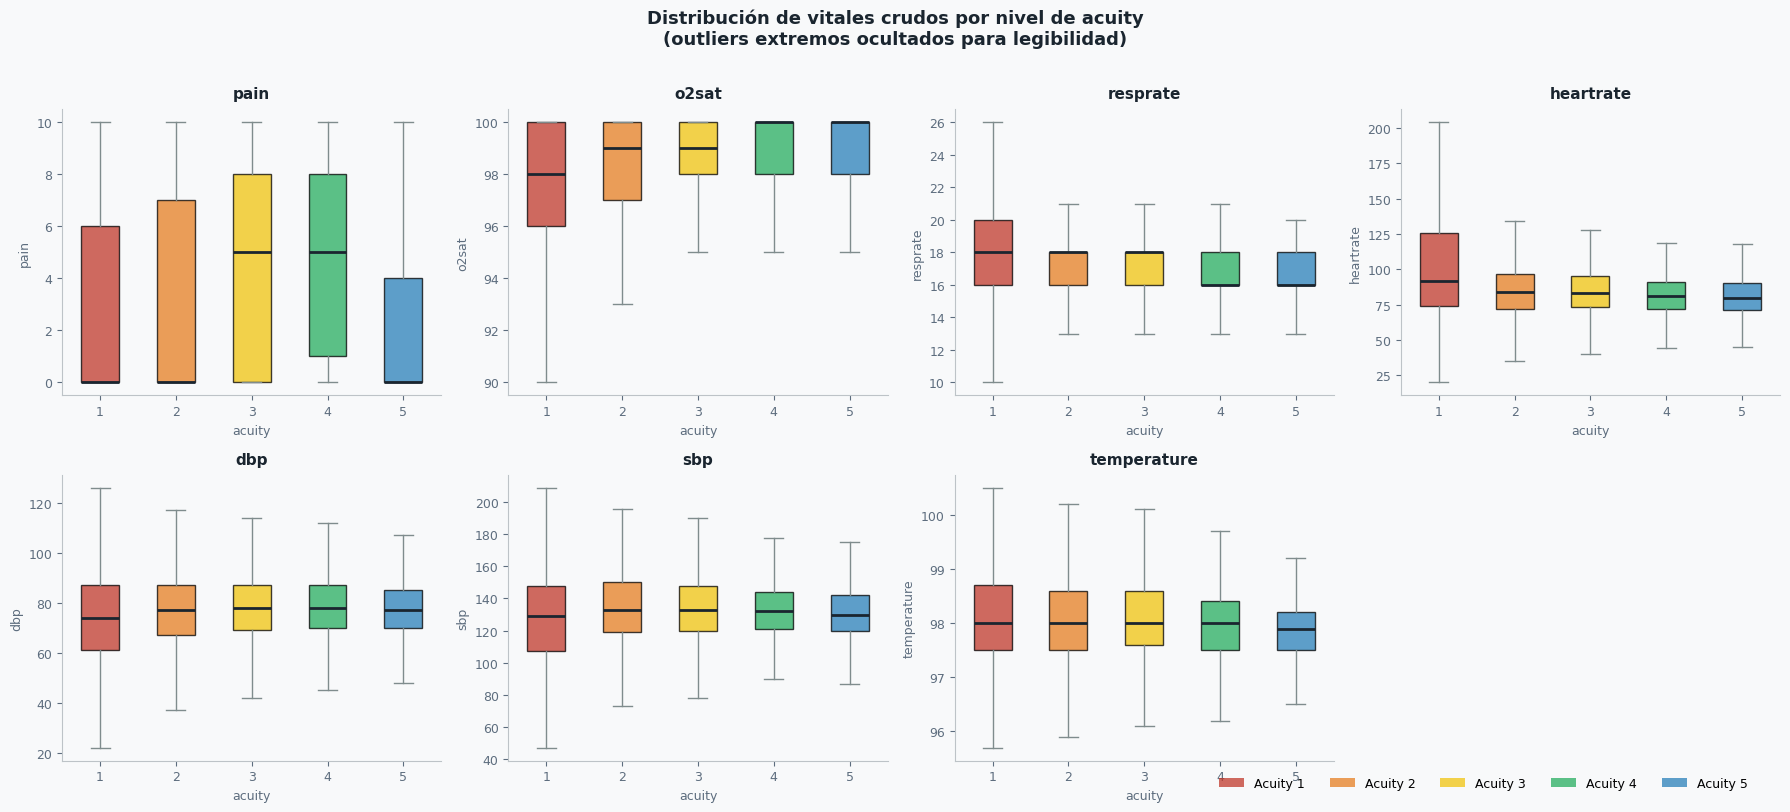

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

VITALES = ["pain", "o2sat", "resprate", "heartrate", "dbp", "sbp", "temperature"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor("#F8F9FA")
axes = axes.flatten()

# Gradiente rojo→verde: acuity 1 (más urgente) → acuity 5 (menos urgente)
paleta = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

for i, col in enumerate(VITALES):
    ax = axes[i]
    ax.set_facecolor("#F8F9FA")

    grupos = [
        df.loc[df["acuity"] == k, col].dropna().values
        for k in [1, 2, 3, 4, 5]
    ]

    bp = ax.boxplot(
        grupos,
        labels=["1", "2", "3", "4", "5"],
        patch_artist=True,
        medianprops=dict(color="#1A252F", linewidth=2),
        whiskerprops=dict(color="#7F8C8D", linewidth=1),
        capprops=dict(color="#7F8C8D", linewidth=1),
        boxprops=dict(linewidth=1),
        flierprops=dict(marker=".", markersize=1, alpha=0.2, color="#95A5A6"),
        showfliers=False,
    )

    for patch, color in zip(bp["boxes"], paleta):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(col, fontsize=11, fontweight="bold", color="#1A252F", pad=8)
    ax.set_xlabel("acuity", fontsize=9, color="#5D6D7E")
    ax.set_ylabel(col, fontsize=9, color="#5D6D7E")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)

# Leyenda común
handles = [
    mpatches.Patch(facecolor=paleta[i], alpha=0.75, label=f"Acuity {i+1}")
    for i in range(5)
]
fig.legend(
    handles=handles,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    ncol=5,
    frameon=False,
    fontsize=9,
)

# Subplot sobrante oculto
axes[-1].set_visible(False)

fig.suptitle(
    "Distribución de vitales crudos por nivel de acuity\n(outliers extremos ocultados para legibilidad)",
    fontsize=13, fontweight="bold", color="#1A252F", y=1.01
)

plt.tight_layout()
plt.savefig("bloque0_boxplots_vitales.png", dpi=150, bbox_inches="tight")
plt.show()

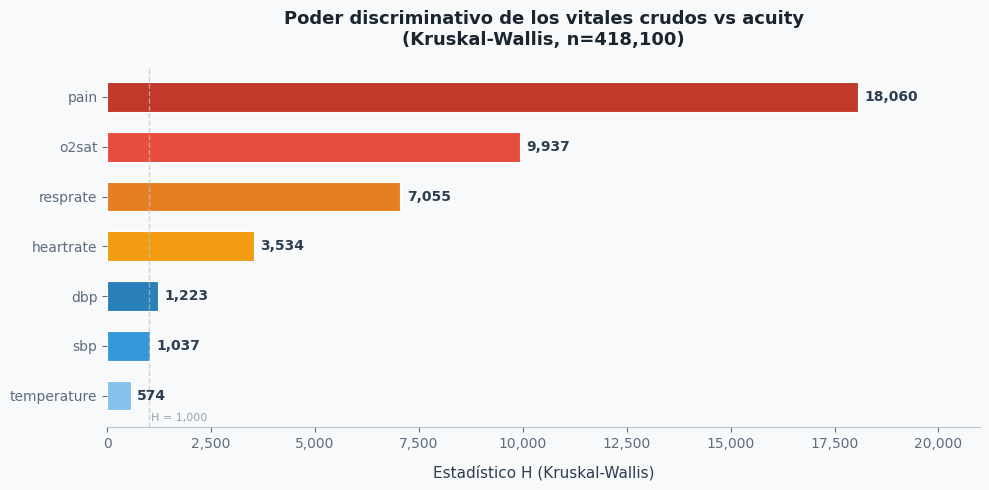

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

datos = {
    "pain":        18060,
    "o2sat":       9937,
    "resprate":    7055,
    "heartrate":   3534,
    "dbp":         1223,
    "sbp":         1037,
    "temperature": 574,
}

labels = list(datos.keys())
valores = list(datos.values())

# Paleta: gradiente frío→cálido según ranking (más urgente = más intenso)
colores = ["#C0392B", "#E74C3C", "#E67E22", "#F39C12", "#2980B9", "#3498DB", "#85C1E9"]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(labels[::-1], valores[::-1], color=colores[::-1],
               edgecolor="white", linewidth=0.8, height=0.6)

# Valores al final de cada barra
for bar, val in zip(bars, valores[::-1]):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left", fontsize=10,
            fontweight="bold", color="#2C3E50")

# Línea de referencia umbral arbitrario (H=1000)
ax.axvline(x=1000, color="#BDC3C7", linewidth=1, linestyle="--", alpha=0.7)
ax.text(1050, -0.55, "H = 1,000", color="#95A5A6", fontsize=8, va="bottom")

ax.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title("Poder discriminativo de los vitales crudos vs acuity\n(Kruskal-Wallis, n=418,100)",
             fontsize=13, fontweight="bold", color="#1A252F", pad=15)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=10)
ax.set_xlim(0, 21000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("bloque0_hstat_vitales.png", dpi=150, bbox_inches="tight")
plt.show()

Los siete vitales registrados en el minuto 0 del triaje muestran señal estadísticamente significativa frente a acuity, pero con patrones muy distintos entre sí. pain es el predictor más potente (H=18,060) y el único con separación visual consistente a lo largo de todos los niveles de urgencia — su mediana decrece de forma clara de acuity 1 a acuity 5. o2sat y heartrate concentran su señal en acuity 1, siendo útiles para identificar los casos más críticos pero poco discriminativos entre los niveles intermedios. resprate presenta un H elevado (7,055) que contrasta con una separación visual pobre en el boxplot, lo que apunta a que su información relevante está en las colas de la distribución más que en los valores centrales. dbp y sbp tienen señal moderada pero con solapamiento casi total entre clases en valores medianos — su utilidad clínica se concentra en situaciones extremas de hipotensión o hipertensión severa. temperature en continuo es el vital más débil: las medianas de las cinco clases son prácticamente idénticas, lo que anticipa que su transformación a una bandera binaria de fiebre aportará más información al modelo que el valor numérico crudo. En conjunto, los vitales crudos tienen mayor poder discriminativo para los extremos del espectro de urgencia (acuity 1 vs 5) que para los niveles intermedios (2, 3, 4), lo que justifica la exploración de features derivadas y scores clínicos compuestos.

VAMOS A ESTUDIAR VARIABLES DERIVADAS Y SCORES.

FLAG MISSINGNESS

In [47]:
# Banderas de missingness: pain_missing, temperature_missing, o2sat_missing
# El dato ausente en urgencias no es aleatorio — tiene valor clínico propio

miss_cols = ["pain", "temperature", "o2sat"]

for col in miss_cols:
    flag = f"{col}_missing"
    df[flag] = df[col].isna().astype("int8")

# H-stat de cada bandera contra acuity
from scipy.stats import kruskal

print(f"{'Bandera':<22} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia (%)':>16}")
print("─" * 65)

for col in miss_cols:
    flag = f"{col}_missing"
    grupos = [
        df.loc[df["acuity"] == k, flag].values
        for k in [1, 2, 3, 4, 5]
    ]
    stat, pval = kruskal(*grupos)
    prev = df[flag].mean() * 100
    print(f"{flag:<22} {stat:>8,.0f}  {pval:>12.2e}  {prev:>15.2f}%")

# Tasa de missing por clase de acuity (la historia real está aquí)
print("\nTasa de missing por clase de acuity (%):\n")
resumen_miss = pd.DataFrame({
    col: [
        df.loc[df["acuity"] == k, col].isna().mean() * 100
        for k in [1, 2, 3, 4, 5]
    ]
    for col in miss_cols
}, index=[1, 2, 3, 4, 5])
resumen_miss.index.name = "acuity"
print(resumen_miss.round(2).to_string())

Bandera                  H-stat       p-value   Prevalencia (%)
─────────────────────────────────────────────────────────────────
pain_missing             43,537      0.00e+00             7.77%
temperature_missing      70,959      0.00e+00             4.17%
o2sat_missing            61,865      0.00e+00             3.33%

Tasa de missing por clase de acuity (%):

         pain  temperature  o2sat
acuity                           
1       41.55        37.22  31.11
2        8.78         3.67   2.71
3        4.28         1.33   1.06
4        2.18         1.19   0.87
5        2.73         3.64   3.55


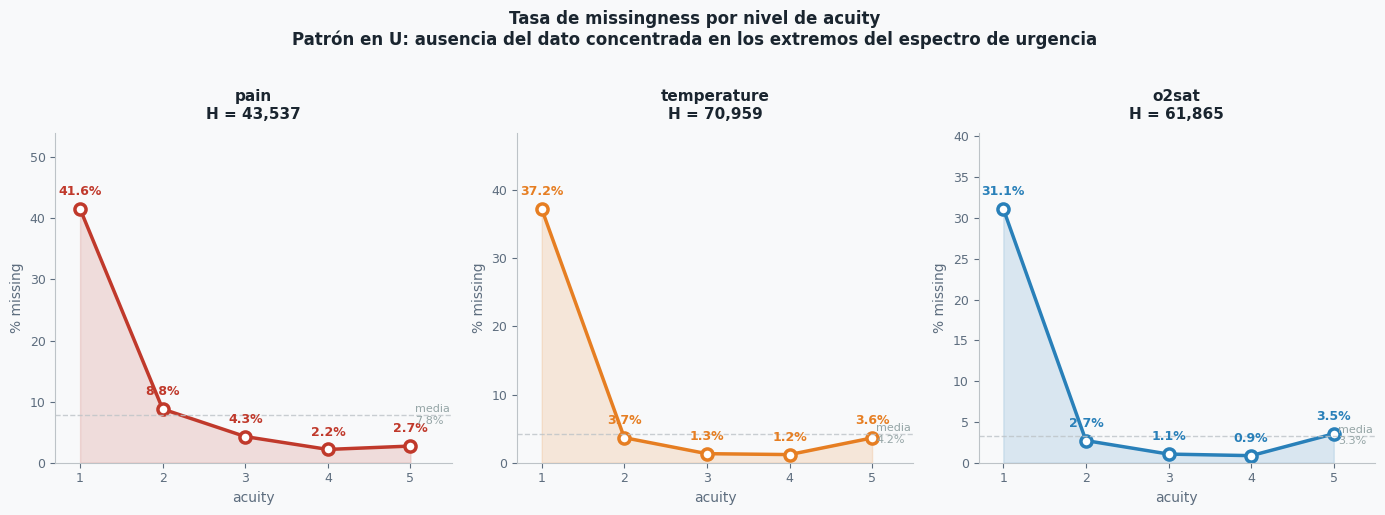

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#F8F9FA")

miss_info = {
    "pain":        {"flag": "pain_missing",        "H": 43537, "color": "#C0392B"},
    "temperature": {"flag": "temperature_missing",  "H": 70959, "color": "#E67E22"},
    "o2sat":       {"flag": "o2sat_missing",        "H": 61865, "color": "#2980B9"},
}

acuity_levels = [1, 2, 3, 4, 5]

for ax, (col, info) in zip(axes, miss_info.items()):
    tasas = [
        df.loc[df["acuity"] == k, col].isna().mean() * 100
        for k in acuity_levels
    ]

    ax.set_facecolor("#F8F9FA")

    # Área bajo la curva
    ax.fill_between(acuity_levels, tasas, alpha=0.15, color=info["color"])

    # Línea principal
    ax.plot(acuity_levels, tasas, color=info["color"],
            linewidth=2.5, marker="o", markersize=8,
            markerfacecolor="white", markeredgewidth=2.5,
            markeredgecolor=info["color"])

    # Anotaciones de valor en cada punto
    for x, y in zip(acuity_levels, tasas):
        ax.annotate(f"{y:.1f}%", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold",
                    color=info["color"])

    # Línea de referencia: tasa global
    tasa_global = df[col].isna().mean() * 100
    ax.axhline(tasa_global, color="#BDC3C7", linewidth=1,
               linestyle="--", alpha=0.8)
    ax.text(5.05, tasa_global, f"media\n{tasa_global:.1f}%",
            va="center", fontsize=8, color="#95A5A6")

    ax.set_title(f"{col}\nH = {info['H']:,}", fontsize=11,
                 fontweight="bold", color="#1A252F", pad=10)
    ax.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
    ax.set_ylabel("% missing", fontsize=10, color="#5D6D7E")
    ax.set_xticks(acuity_levels)
    ax.set_xlim(0.7, 5.5)
    ax.set_ylim(0, max(tasas) * 1.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    "Tasa de missingness por nivel de acuity\n"
    "Patrón en U: ausencia del dato concentrada en los extremos del espectro de urgencia",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque0_missing_flags.png", dpi=150, bbox_inches="tight")
plt.show()

Las banderas de ausencia de dato (pain_missing, temperature_missing, o2sat_missing) resultan ser las features más discriminativas del dataset hasta este punto, superando ampliamente a sus correspondientes valores continuos en poder predictivo (H hasta ×123 para temperature). El patrón de missingness sigue una curva en U con el mínimo en acuity 4: los datos faltan tanto en los casos más críticos (paciente inestable, sin tiempo de registro) como en los más leves (medición no considerada necesaria). Esta distribución no aleatoria — lo que estadísticamente se denomina NMAR — convierte la ausencia del dato en información clínica por sí misma, independiente del valor que luego se impute. Las tres banderas entran obligatoriamente al modelo.

FLAGS UNDER/OVER

In [49]:
# Bandera clínica: o2sat_bajo_92
# Umbral crítico British Thoracic Society — por debajo del 92% la curva de
# disociación de hemoglobina entra en zona de desoxigenación tisular grave

df["o2sat_bajo_92"] = (df["o2sat"] < 92).astype("int8")
# Nota: NaN en o2sat → 0 (no se puede afirmar que esté bajo 92 sin dato)

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "o2sat_bajo_92"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["o2sat_bajo_92"].mean() * 100

print(f"o2sat_bajo_92  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%")
print(f"o2sat continuo →  H = 9,937\n")

# Distribución de la bandera por clase de acuity
print("% de pacientes con o2sat < 92 por clase de acuity:\n")
tabla = pd.DataFrame({
    "n_total":      df.groupby("acuity")["o2sat_bajo_92"].count(),
    "n_bajo_92":    df.groupby("acuity")["o2sat_bajo_92"].sum(),
    "pct_bajo_92":  (df.groupby("acuity")["o2sat_bajo_92"].mean() * 100).round(2),
})
print(tabla.to_string())

o2sat_bajo_92  →  H = 11,908  |  p = 0.00e+00  |  prevalencia = 0.72%
o2sat continuo →  H = 9,937

% de pacientes con o2sat < 92 por clase de acuity:

        n_total  n_bajo_92  pct_bajo_92
acuity                                 
1         24019       1531         6.37
2        139411       1107         0.79
3        225066        373         0.17
4         28504          4         0.01
5          1100          0         0.00


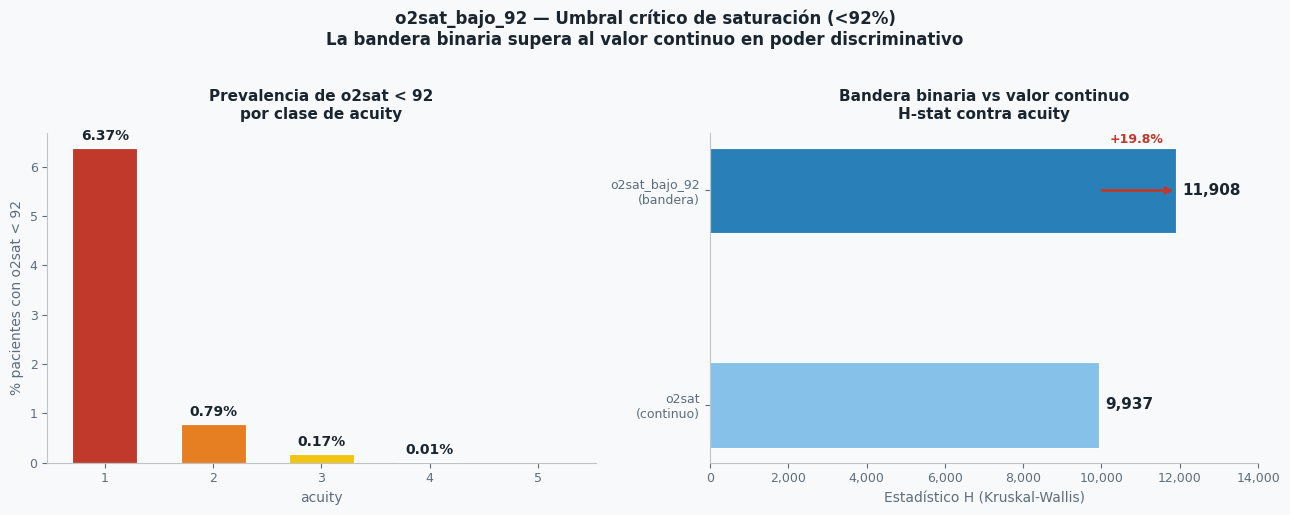

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

# ── Izquierda: % bajo 92 por clase de acuity ─────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
pcts = [6.37, 0.79, 0.17, 0.01, 0.00]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

bars = ax1.bar(acuity_levels, pcts, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con o2sat < 92", fontsize=10, color="#5D6D7E")
ax1.set_title("Prevalencia de o2sat < 92\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Derecha: comparativa H-stat bandera vs continuo ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features = ["o2sat\n(continuo)", "o2sat_bajo_92\n(bandera)"]
hstats   = [9937, 11908]
cols_bar = ["#85C1E9", "#2980B9"]

bars2 = ax2.barh(features, hstats, color=cols_bar,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + 150, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=11, fontweight="bold", color="#1A252F")

# Flecha indicando mejora
ax2.annotate("", xy=(11908, 1), xytext=(9937, 1),
             arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2))
ax2.text(10900, 1.22, "+19.8%", fontsize=9,
         fontweight="bold", color="#C0392B", ha="center")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Bandera binaria vs valor continuo\nH-stat contra acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 14000)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "o2sat_bajo_92 — Umbral crítico de saturación (<92%)\n"
    "La bandera binaria supera al valor continuo en poder discriminativo",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque0_o2sat_bajo92.png", dpi=150, bbox_inches="tight")
plt.show()

La bandera o2sat_bajo_92 supera al valor continuo de o2sat en poder discriminativo (H=11,908 vs H=9,937) a pesar de una prevalencia global del 0.72%. Su señal es casi exclusiva de acuity 1 (6.37%) y se desvanece rápidamente hacia los niveles menos urgentes, llegando a cero en acuity 5. Cuando se activa, es un indicador casi inequívoco de emergencia. Entra al modelo.

In [51]:
# Bandera clínica: fiebre
# Umbral estándar: temperatura >= 100.4°F (38°C)
# Hipótesis: el fenómeno binario fiebre/no-fiebre captura más señal
# que el gradiente continuo de temperature (H=574)

df["fiebre"] = (df["temperature"] >= 100.4).astype("int8")
# NaN en temperature → 0 (sin dato no se puede afirmar fiebre)

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "fiebre"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["fiebre"].mean() * 100

print(f"fiebre         →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%")
print(f"temperature    →  H = 574\n")

# Distribución por clase de acuity
print("% de pacientes con fiebre por clase de acuity:\n")
tabla = pd.DataFrame({
    "n_total":   df.groupby("acuity")["fiebre"].count(),
    "n_fiebre":  df.groupby("acuity")["fiebre"].sum(),
    "pct_fiebre": (df.groupby("acuity")["fiebre"].mean() * 100).round(2),
})
print(tabla.to_string())

fiebre         →  H = 1,049  |  p = 8.54e-226  |  prevalencia = 2.20%
temperature    →  H = 574

% de pacientes con fiebre por clase de acuity:

        n_total  n_fiebre  pct_fiebre
acuity                               
1         24019       937        3.90
2        139411      3754        2.69
3        225066      4407        1.96
4         28504        84        0.29
5          1100         0        0.00


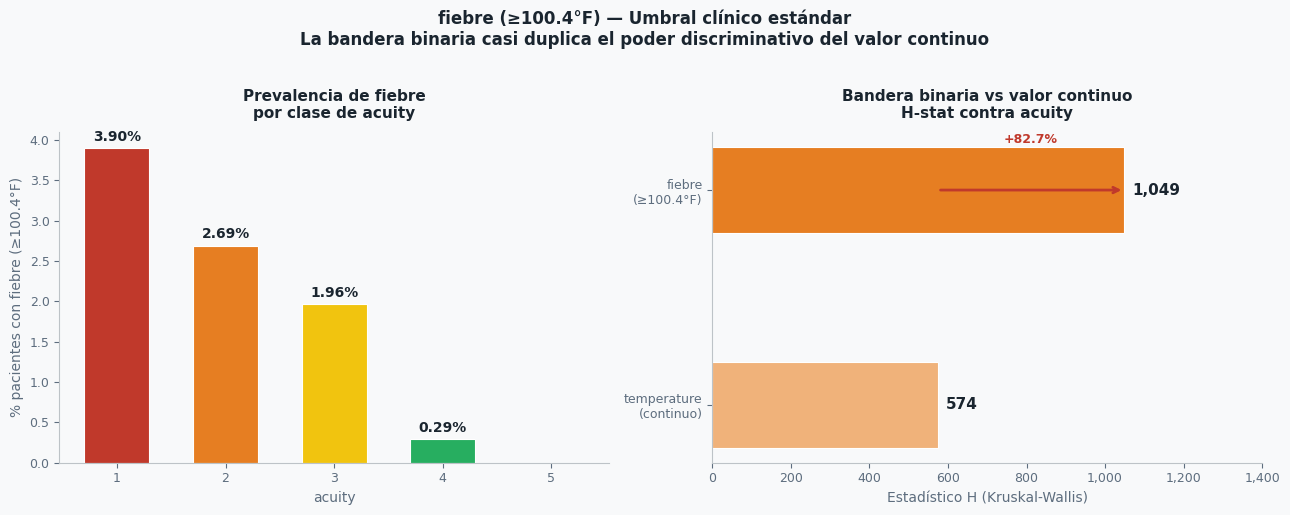

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

# ── Izquierda: % fiebre por clase de acuity ───────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
pcts = [3.90, 2.69, 1.96, 0.29, 0.00]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

bars = ax1.bar(acuity_levels, pcts, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con fiebre (≥100.4°F)", fontsize=10, color="#5D6D7E")
ax1.set_title("Prevalencia de fiebre\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Derecha: comparativa H-stat bandera vs continuo ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features = ["temperature\n(continuo)", "fiebre\n(≥100.4°F)"]
hstats   = [574, 1049]
cols_bar = ["#F0B27A", "#E67E22"]

bars2 = ax2.barh(features, hstats, color=cols_bar,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=11, fontweight="bold", color="#1A252F")

ax2.annotate("", xy=(1049, 1), xytext=(574, 1),
             arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2))
ax2.text(810, 1.22, "+82.7%", fontsize=9,
         fontweight="bold", color="#C0392B", ha="center")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Bandera binaria vs valor continuo\nH-stat contra acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 1400)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "fiebre (≥100.4°F) — Umbral clínico estándar\n"
    "La bandera binaria casi duplica el poder discriminativo del valor continuo",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque0_fiebre.png", dpi=150, bbox_inches="tight")
plt.show()

La bandera fiebre (≥100.4°F) casi duplica el poder discriminativo del valor continuo de temperature (H=1,049 vs H=574), confirmando que el fenómeno binario captura más señal que el gradiente numérico. A diferencia de o2sat_bajo_92, su distribución es más gradual — decrece progresivamente de acuity 1 (3.90%) a acuity 5 (0.00%), lo que la hace útil para separar no solo los casos críticos sino también los niveles intermedios. Con una prevalencia del 2.20% es suficientemente frecuente para ser informativa en producción. Entra al modelo. El valor continuo de temperature queda descartado.

In [53]:
# Banderas clínicas: extremos de frecuencia respiratoria
# taquipnea_grave: > 24 rpm — umbral de alarma en protocolos NEWS2 y qSOFA
# bradipnea:       < 10 rpm — depresión respiratoria, riesgo de parada

df["taquipnea_grave"] = (df["resprate"] > 24).astype("int8")
df["bradipnea"]       = (df["resprate"] < 10).astype("int8")

print(f"{'Bandera':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["taquipnea_grave", "bradipnea"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = df[col].sum()
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nresprate continuo  →  H = 7,055\n")

# Distribución por clase de acuity
print("% por clase de acuity:\n")
resumen = pd.DataFrame({
    "taquipnea_grave": (df.groupby("acuity")["taquipnea_grave"].mean() * 100).round(2),
    "bradipnea":       (df.groupby("acuity")["bradipnea"].mean() * 100).round(2),
})
print(resumen.to_string())

Bandera                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
taquipnea_grave        11,007      0.00e+00         1.15%     4,829
bradipnea                 165      1.54e-34         0.02%       101

resprate continuo  →  H = 7,055

% por clase de acuity:

        taquipnea_grave  bradipnea
acuity                            
1                  7.49       0.15
2                  1.81       0.03
3                  0.22       0.01
4                  0.03       0.01
5                  0.18       0.00


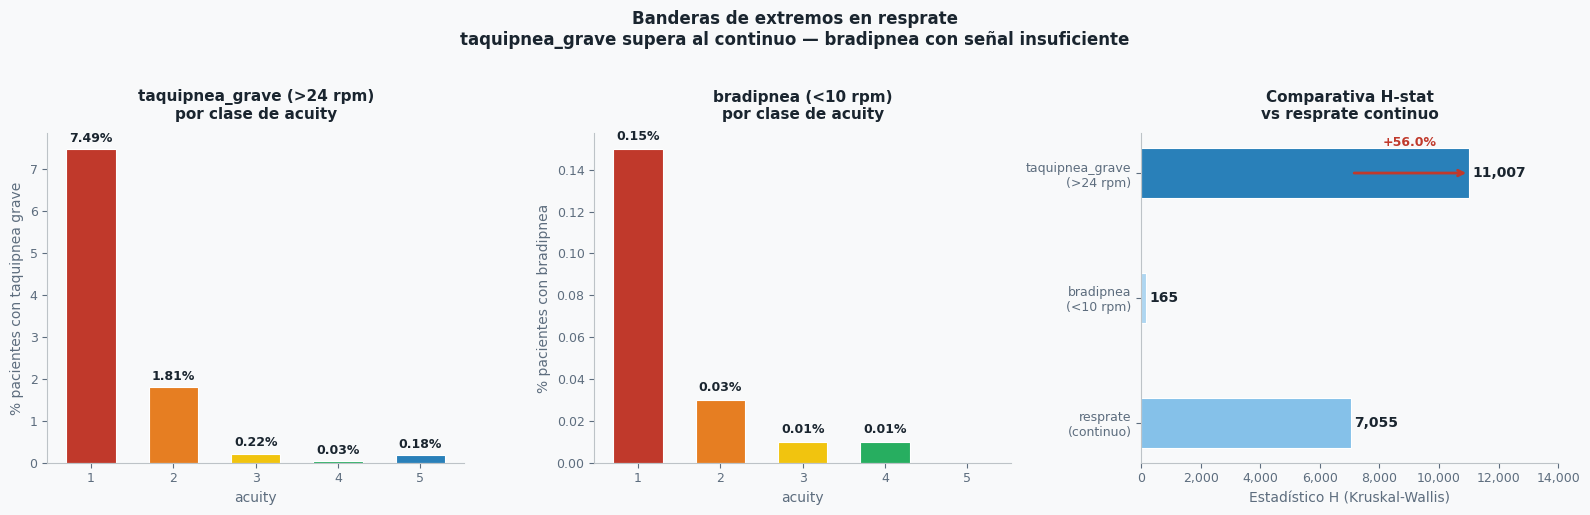

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: taquipnea_grave por acuity ────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_taq = [7.49, 1.81, 0.22, 0.03, 0.18]
bars = ax1.bar(acuity_levels, pcts_taq, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts_taq):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con taquipnea grave", fontsize=10, color="#5D6D7E")
ax1.set_title("taquipnea_grave (>24 rpm)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Centro: bradipnea por acuity ──────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_brad = [0.15, 0.03, 0.01, 0.01, 0.00]
bars2 = ax2.bar(acuity_levels, pcts_brad, color=colores_barra,
                edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars2, pcts_brad):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes con bradipnea", fontsize=10, color="#5D6D7E")
ax2.set_title("bradipnea (<10 rpm)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)

# ── Derecha: comparativa H-stat ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = ["resprate\n(continuo)", "bradipnea\n(<10 rpm)", "taquipnea_grave\n(>24 rpm)"]
hstats   = [7055, 165, 11007]
cols_bar = ["#85C1E9", "#AED6F1", "#2980B9"]

bars3 = ax3.barh(features, hstats, color=cols_bar,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.annotate("", xy=(11007, 2), xytext=(7055, 2),
             arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2))
ax3.text(9000, 2.22, "+56.0%", fontsize=9,
         fontweight="bold", color="#C0392B", ha="center")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs resprate continuo",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 14000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Banderas de extremos en resprate\n"
    "taquipnea_grave supera al continuo — bradipnea con señal insuficiente",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque0_resprate_flags.png", dpi=150, bbox_inches="tight")
plt.show()

taquipnea_grave (>24 rpm) — ENTRA AL MODELO
Supera al valor continuo de resprate en poder discriminativo (H=11,007 vs H=7,055) con una distribución clara y consistente: 7.49% en acuity 1 frente a valores prácticamente nulos en acuity 3-5. Con 4,829 casos y una prevalencia del 1.15%, el modelo tiene suficiente masa estadística para aprender la asociación de forma fiable.
bradipnea (<10 rpm) — DESCARTADA
Aunque clínicamente la bradipnea severa representa una emergencia real (depresión respiratoria, sobredosis, daño neurológico), los datos no respaldan su inclusión como feature de ML. Con solo 101 casos en 418,100 visitas (0.02%), el modelo ve esta bandera activada en menos de 1 de cada 4,000 pacientes. Además, la distribución por clase no es monótona — acuity 2 concentra más casos que acuity 1 — lo que impide que XGBoost aprenda una asociación útil. El H=165, aunque estadísticamente significativo, refleja una señal demasiado débil y ruidosa para aportar valor predictivo neto. Se descarta por prevalencia insuficiente y distribución no discriminativa, no por falta de relevancia clínica.

In [55]:
# Score clínico: Shock Index (SI)
# Fórmula: heartrate / sbp
#Mutschler, M., Nienaber, U., Münzberg, M., et al. (2013). The Shock Index revisited – a fast guide to transfusion requirement? A retrospective analysis on 21,853 patients derived from the TraumaRegister DGU. Critical Care, 17(4), R172.
# Valores de referencia:
#   < 0.6  → normal
#   0.6–1.0 → leve compromiso hemodinámico
#   > 1.0  → shock moderado-grave
#   > 1.4  → shock severo, mortalidad elevada

df["shock_index"] = df["heartrate"] / df["sbp"]

# NaN si cualquiera de los dos vitales es nulo — comportamiento correcto,
# no imputamos un score hemodinámico sin datos reales

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "shock_index"].dropna().values
    for k in [1, 2, 3, 4, 5]
])

prev_nulos = df["shock_index"].isna().mean() * 100
print(f"shock_index  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  nulos = {prev_nulos:.2f}%\n")

# Medianas por clase de acuity
print("Mediana de shock_index por clase de acuity:\n")
print(df.groupby("acuity")["shock_index"].median().round(3).to_string())

# Distribución por umbrales clínicos
print("\n% por umbral clínico:\n")
umbrales = {
    "SI < 0.6  (normal)":      (df["shock_index"] < 0.6).mean() * 100,
    "SI 0.6–1.0 (leve)":       ((df["shock_index"] >= 0.6) & (df["shock_index"] < 1.0)).mean() * 100,
    "SI 1.0–1.4 (moderado)":   ((df["shock_index"] >= 1.0) & (df["shock_index"] < 1.4)).mean() * 100,
    "SI >= 1.4  (severo)":     (df["shock_index"] >= 1.4).mean() * 100,
}
for k, v in umbrales.items():
    print(f"  {k}:  {v:.2f}%")

shock_index  →  H = 4,565  |  p = 0.00e+00  |  nulos = 2.99%

Mediana de shock_index por clase de acuity:

acuity
1    0.750
2    0.629
3    0.627
4    0.614
5    0.612

% por umbral clínico:

  SI < 0.6  (normal):  41.18%
  SI 0.6–1.0 (leve):  52.34%
  SI 1.0–1.4 (moderado):  3.27%
  SI >= 1.4  (severo):  0.22%


In [56]:
# Banderas de shock_index por umbral clínico
df["shock_index_alto"]  = (df["shock_index"] >= 1.0).astype("int8")
df["shock_index_severo"] = (df["shock_index"] >= 1.4).astype("int8")

print(f"{'Feature':<25} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 75)

features_si = {
    "shock_index (continuo)":  "shock_index",
    "shock_index_alto (≥1.0)": "shock_index_alto",
    "shock_index_severo (≥1.4)":"shock_index_severo",
}

resultados_si = {}
for label, col in features_si.items():
    grupos = [
        df.loc[df["acuity"] == k, col].dropna().values
        for k in [1, 2, 3, 4, 5]
    ]
    stat, pval = kruskal(*grupos)
    prev = df[col].mean() * 100
    n    = int(df[col].sum()) if col != "shock_index" else df[col].notna().sum()
    resultados_si[label] = {"H": stat, "col": col}
    print(f"{label:<25} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\n% con shock_index_alto (≥1.0) por clase de acuity:\n")
print((df.groupby("acuity")["shock_index_alto"].mean() * 100).round(2).to_string())
print(f"\n% con shock_index_severo (≥1.4) por clase de acuity:\n")
print((df.groupby("acuity")["shock_index_severo"].mean() * 100).round(2).to_string())

Feature                     H-stat       p-value   Prevalencia   n casos
───────────────────────────────────────────────────────────────────────────
shock_index (continuo)       4,565      0.00e+00        64.71%   405,591
shock_index_alto (≥1.0)     18,219      0.00e+00         3.49%    14,590
shock_index_severo (≥1.4)   10,336      0.00e+00         0.22%       915

% con shock_index_alto (≥1.0) por clase de acuity:

acuity
1    18.17
2     4.27
3     1.82
4     0.60
5     0.64

% con shock_index_severo (≥1.4) por clase de acuity:

acuity
1    3.19
2    0.10
3    0.00
4    0.00
5    0.00


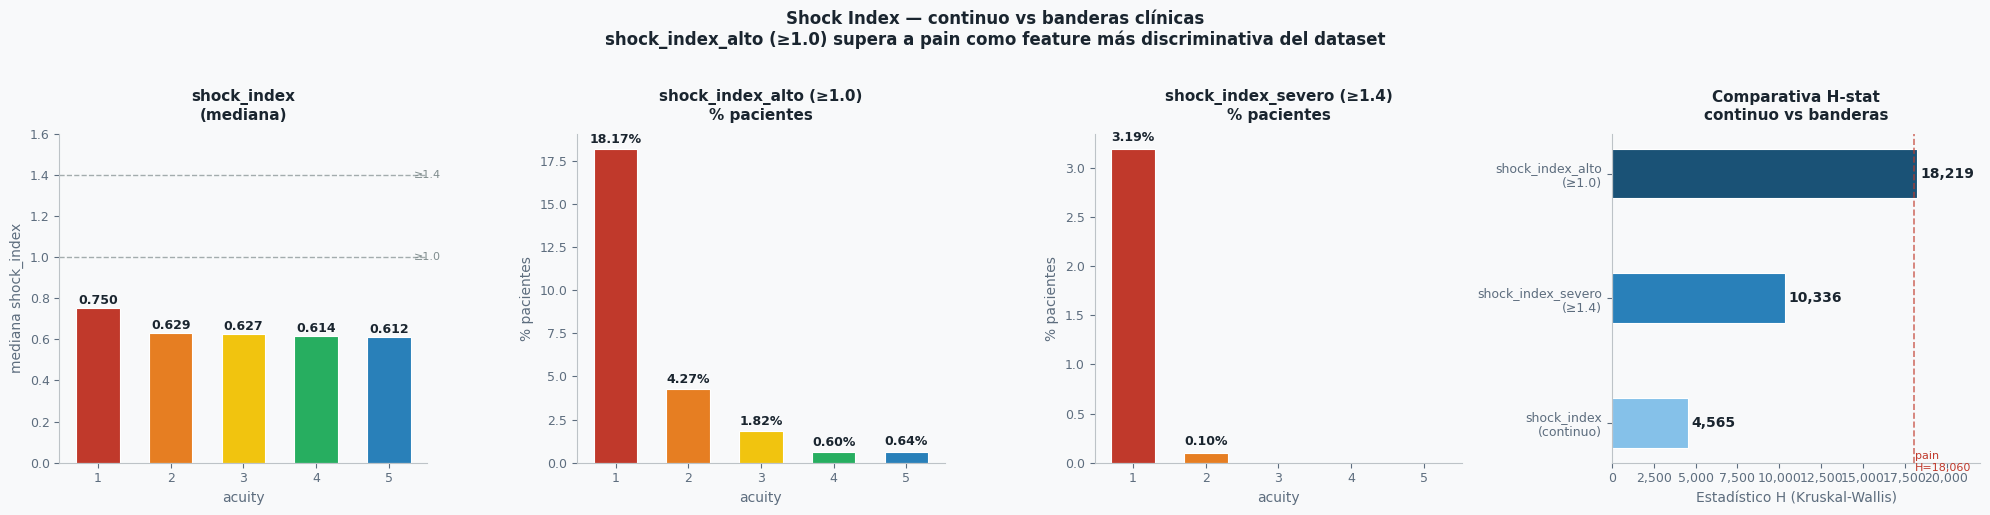

In [57]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

datos = {
    "shock_index\n(mediana)": {
        "valores": df.groupby("acuity")["shock_index"].median().round(3).values.tolist(),
        "ylabel": "mediana shock_index",
        "fmt": "{:.3f}",
        "offset": 0.005,
    },
    "shock_index_alto (≥1.0)\n% pacientes": {
        "valores": [18.17, 4.27, 1.82, 0.60, 0.64],
        "ylabel": "% pacientes",
        "fmt": "{:.2f}%",
        "offset": 0.2,
    },
    "shock_index_severo (≥1.4)\n% pacientes": {
        "valores": [3.19, 0.10, 0.00, 0.00, 0.00],
        "ylabel": "% pacientes",
        "fmt": "{:.2f}%",
        "offset": 0.05,
    },
}

for ax, (titulo, info) in zip(axes[:3], datos.items()):
    ax.set_facecolor("#F8F9FA")

    bars = ax.bar(acuity_levels, info["valores"], color=colores_barra,
                  edgecolor="white", linewidth=0.8, width=0.6)

    for bar, val in zip(bars, info["valores"]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + info["offset"],
                    info["fmt"].format(val),
                    ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color="#1A252F")

    ax.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
    ax.set_ylabel(info["ylabel"], fontsize=10, color="#5D6D7E")
    ax.set_title(titulo, fontsize=11, fontweight="bold", color="#1A252F", pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)
    ax.set_xticks(acuity_levels)

# Líneas de referencia umbrales en el continuo
axes[0].axhline(1.0, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
axes[0].text(5.35, 1.0, "≥1.0", fontsize=8, color="#7F8C8D", va="center")
axes[0].axhline(1.4, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
axes[0].text(5.35, 1.4, "≥1.4", fontsize=8, color="#7F8C8D", va="center")
axes[0].set_ylim(0, 1.6)

# ── Comparativa H-stat ────────────────────────────────────────────────────────
ax3 = axes[3]
ax3.set_facecolor("#F8F9FA")

features = ["shock_index\n(continuo)", "shock_index_severo\n(≥1.4)", "shock_index_alto\n(≥1.0)"]
hstats   = [4565, 10336, 18219]
cols_h   = ["#85C1E9", "#2980B9", "#1A5276"]

bars3 = ax3.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.axvline(x=18060, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax3.text(18100, -0.4, "pain\nH=18,060", color="#C0392B", fontsize=8, va="bottom")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\ncontinuo vs banderas",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 22000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Shock Index — continuo vs banderas clínicas\n"
    "shock_index_alto (≥1.0) supera a pain como feature más discriminativa del dataset",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque0_shock_index.png", dpi=150, bbox_inches="tight")
plt.show()

shock_index_alto (≥1.0) es la feature más discriminativa del dataset hasta ahora (H=18,219), superando incluso a pain (H=18,060). Las banderas multiplican por 4 la señal del valor continuo (H=4,565), que queda descartado. El gráfico de medianas explica por qué el continuo es débil: acuity 2-5 tienen medianas prácticamente idénticas (0.61-0.63), todo el peso discriminativo recae en acuity 1 (0.750). Las banderas resuelven esto convirtiendo ese escalón en una señal binaria limpia. shock_index_alto (≥1.0) concentra el 18.17% de acuity 1 con caída progresiva hasta casi cero en acuity 4-5. shock_index_severo (≥1.4) es casi exclusivo de acuity 1 (3.19%) con presencia residual en acuity 2 (0.10%) y cero en el resto — indicador casi determinista de emergencia. Entran las dos banderas. El continuo se descarta.

In [58]:
# Score clínico: Pulse Pressure (PP)
# Fórmula: sbp - dbp
# Valores de referencia:
#   < 25 mmHg  → presión de pulso estrecha — bajo gasto cardíaco, taponamiento
#   25-40 mmHg → zona límite
#   > 40 mmHg  → normal
#   > 100 mmHg → presión de pulso amplia — insuficiencia aórtica, sepsis

df["pulse_pressure"] = df["sbp"] - df["dbp"]

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "pulse_pressure"].dropna().values
    for k in [1, 2, 3, 4, 5]
])

prev_nulos = df["pulse_pressure"].isna().mean() * 100
print(f"pulse_pressure  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  nulos = {prev_nulos:.2f}%\n")

# Medianas por clase de acuity
print("Mediana de pulse_pressure por clase de acuity:\n")
print(df.groupby("acuity")["pulse_pressure"].median().round(1).to_string())

# Distribución por umbrales clínicos
print("\n% por umbral clínico:\n")
umbrales = {
    "PP < 25 mmHg  (estrecha — bajo gasto)": (df["pulse_pressure"] < 25).mean() * 100,
    "PP 25-40 mmHg (límite)":                ((df["pulse_pressure"] >= 25) & (df["pulse_pressure"] < 40)).mean() * 100,
    "PP 40-100 mmHg (normal)":               ((df["pulse_pressure"] >= 40) & (df["pulse_pressure"] < 100)).mean() * 100,
    "PP >= 100 mmHg (amplia — sepsis/aórtica)":(df["pulse_pressure"] >= 100).mean() * 100,
}
for k, v in umbrales.items():
    print(f"  {k}:  {v:.2f}%")

pulse_pressure  →  H = 1,374  |  p = 2.93e-296  |  nulos = 3.08%

Mediana de pulse_pressure por clase de acuity:

acuity
1    51.0
2    56.0
3    55.0
4    53.0
5    53.0

% por umbral clínico:

  PP < 25 mmHg  (estrecha — bajo gasto):  2.02%
  PP 25-40 mmHg (límite):  13.10%
  PP 40-100 mmHg (normal):  78.43%
  PP >= 100 mmHg (amplia — sepsis/aórtica):  3.38%


In [59]:
df["pp_estrecha"] = (df["pulse_pressure"] < 25).astype("int8")
df["pp_amplia"]   = (df["pulse_pressure"] >= 100).astype("int8")

print(f"{'Bandera':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["pulse_pressure", "pp_estrecha", "pp_amplia"]:
    grupos = [
        df.loc[df["acuity"] == k, col].dropna().values
        for k in [1, 2, 3, 4, 5]
    ]
    stat, pval = kruskal(*grupos)
    prev = df[col].mean() * 100
    n    = int(df[col].sum()) if col != "pulse_pressure" else df[col].notna().sum()
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\n% por clase de acuity:\n")
resumen = pd.DataFrame({
    "pp_estrecha": (df.groupby("acuity")["pp_estrecha"].mean() * 100).round(2),
    "pp_amplia":   (df.groupby("acuity")["pp_amplia"].mean() * 100).round(2),
})
print(resumen.to_string())

Bandera                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
pulse_pressure          1,374     2.93e-296      5752.65%   405,223
pp_estrecha               426      7.73e-91         2.02%     8,428
pp_amplia                 904     2.79e-194         3.38%    14,128

% por clase de acuity:

        pp_estrecha  pp_amplia
acuity                        
1              3.83       2.69
2              1.93       4.37
3              1.89       3.11
4              1.93       1.31
5              1.91       0.73


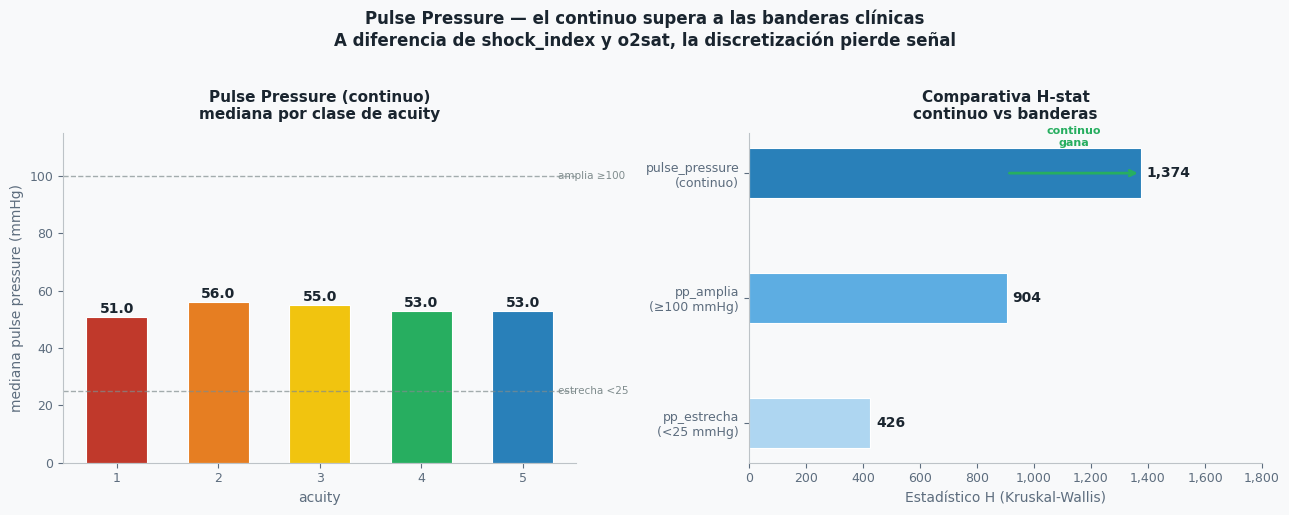

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: mediana pulse_pressure por acuity ──────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

medianas = df.groupby("acuity")["pulse_pressure"].median().round(1).values

bars = ax1.bar(acuity_levels, medianas, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

# Líneas de referencia umbrales clínicos
for umbral, label, pos in [(25, "estrecha <25", 25), (100, "amplia ≥100", 100)]:
    ax1.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana pulse pressure (mmHg)", fontsize=10, color="#5D6D7E")
ax1.set_title("Pulse Pressure (continuo)\nmediana por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)
ax1.set_ylim(0, 115)

# ── Derecha: comparativa H-stat continuo vs banderas ─────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features = ["pp_estrecha\n(<25 mmHg)", "pp_amplia\n(≥100 mmHg)", "pulse_pressure\n(continuo)"]
hstats   = [426, 904, 1374]
cols_h   = ["#AED6F1", "#5DADE2", "#2980B9"]

bars2 = ax2.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

# Flecha indicando que el continuo gana
ax2.annotate("", xy=(1374, 2), xytext=(904, 2),
             arrowprops=dict(arrowstyle="->", color="#27AE60", lw=2))
ax2.text(1139, 2.22, "continuo\ngana", fontsize=8,
         fontweight="bold", color="#27AE60", ha="center")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Comparativa H-stat\ncontinuo vs banderas",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 1800)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Pulse Pressure — el continuo supera a las banderas clínicas\n"
    "A diferencia de shock_index y o2sat, la discretización pierde señal",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque0_pulse_pressure.png", dpi=150, bbox_inches="tight")
plt.show()

pulse_pressure (sbp - dbp) entra al modelo como valor continuo (H=1,374), superando a sbp y dbp individualmente. Se exploraron dos banderas clínicas con justificación teórica sólida: pp_estrecha (<25 mmHg, firma de shock cardiogénico o hemorragia masiva) y pp_amplia (≥100 mmHg, asociada a shock séptico y crisis hipertensivas en ancianos). El patrón de pp_amplia con su máximo en acuity 2 en lugar de acuity 1 refleja un fenómeno clínico real — los pacientes sépticos o hipertensos graves raramente llegan en parada — pero estadísticamente ambas banderas obtienen H-stats inferiores al continuo (H=426 y H=904 respectivamente). A diferencia de shock_index u o2sat, donde las banderas multiplicaban la señal del continuo, aquí la discretización pierde información. El valor continuo captura mejor el gradiente clínico completo, y XGBoost puede aprender los umbrales relevantes directamente de los datos sin necesidad de definirlos a priori. Las banderas se descartan por degradar la señal respecto al continuo, no por falta de justificación clínica.

In [61]:
# Score clínico: NEWS2 (National Early Warning Score 2)
# Royal College of Physicians, 2017 — estándar NHS y SEMICYUC
# Componentes: resprate, o2sat, sbp, heartrate, temperature, consciencia
# Consciencia (AVPU): no disponible → proxy pain_missing
#   pain_missing == 1 → estado alterado → 3 puntos
#   pain_missing == 0 → alerta → 0 puntos

def calcular_news2_vectorizado(df):
    score_total = np.zeros(len(df))

    # Frecuencia respiratoria
    rr = df["resprate"].values
    score_total += np.select(
        [np.isnan(rr), rr <= 8, rr <= 11, rr <= 20, rr <= 24],
        [0,            3,       1,        0,         2], default=3
    )

    # Saturación O2 (escala 1 — sin O2 suplementario)
    o2 = df["o2sat"].values
    score_total += np.select(
        [np.isnan(o2), o2 <= 91, o2 <= 93, o2 <= 95],
        [0,            3,        2,        1], default=0
    )

    # Presión arterial sistólica
    sbp = df["sbp"].values
    score_total += np.select(
        [np.isnan(sbp), sbp <= 90, sbp <= 100, sbp <= 110, sbp <= 219],
        [0,             3,         2,          1,           0], default=3
    )

    # Frecuencia cardíaca
    hr = df["heartrate"].values
    score_total += np.select(
        [np.isnan(hr), hr <= 40, hr <= 50, hr <= 90, hr <= 110, hr <= 130],
        [0,            3,        1,        0,        1,         2], default=3
    )

    # Temperatura (°F)
    temp = df["temperature"].values
    score_total += np.select(
        [np.isnan(temp), temp <= 95.0, temp <= 96.8, temp <= 100.4, temp <= 102.2],
        [0,              3,            1,            0,             1], default=2
    )

    # Nivel de consciencia — proxy pain_missing
    score_total += np.where(df["pain_missing"].values == 1, 3, 0)

    return score_total

df["news2"] = calcular_news2_vectorizado(df)

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "news2"].values
    for k in [1, 2, 3, 4, 5]
])

print(f"news2  →  H = {stat:,.0f}  |  p = {pval:.2e}\n")
print(f"resprate continuo (componente más potente)  →  H = 7,055\n")

print("Mediana de NEWS2 por clase de acuity:\n")
print(df.groupby("acuity")["news2"].median().to_string())

print(f"\nDistribución por umbrales de riesgo NEWS2:\n")
umbrales = {
    "NEWS2 0-2  (bajo riesgo)":     (df["news2"] <= 2).mean() * 100,
    "NEWS2 3-4  (riesgo moderado)": ((df["news2"] >= 3) & (df["news2"] <= 4)).mean() * 100,
    "NEWS2 5-6  (riesgo alto)":     ((df["news2"] >= 5) & (df["news2"] <= 6)).mean() * 100,
    "NEWS2 >= 7 (riesgo muy alto)": (df["news2"] >= 7).mean() * 100,
}
for k, v in umbrales.items():
    print(f"  {k}:  {v:.2f}%")

news2  →  H = 35,887  |  p = 0.00e+00

resprate continuo (componente más potente)  →  H = 7,055

Mediana de NEWS2 por clase de acuity:

acuity
1    3.0
2    1.0
3    1.0
4    0.0
5    0.0

Distribución por umbrales de riesgo NEWS2:

  NEWS2 0-2  (bajo riesgo):  83.87%
  NEWS2 3-4  (riesgo moderado):  12.30%
  NEWS2 5-6  (riesgo alto):  2.81%
  NEWS2 >= 7 (riesgo muy alto):  1.02%


In [62]:
df["news2_alto"] = (df["news2"] >= 7).astype("int8")

stat_alto, pval_alto = kruskal(*[
    df.loc[df["acuity"] == k, "news2_alto"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["news2_alto"].mean() * 100
n    = df["news2_alto"].sum()

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)
print(f"{'news2 (continuo)':<20} {35887:>8,}  {'0.00e+00':>12}  {'---':>12}  {'---':>8}")
print(f"{'news2_alto (≥7)':<20} {stat_alto:>8,.0f}  {pval_alto:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\n% news2_alto por clase de acuity:\n")
print((df.groupby("acuity")["news2_alto"].mean() * 100).round(2).to_string())

Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
news2 (continuo)       35,887      0.00e+00           ---       ---
news2_alto (≥7)        19,504      0.00e+00         1.02%     4,262

% news2_alto por clase de acuity:

acuity
1    9.57
2    1.20
3    0.13
4    0.01
5    0.00


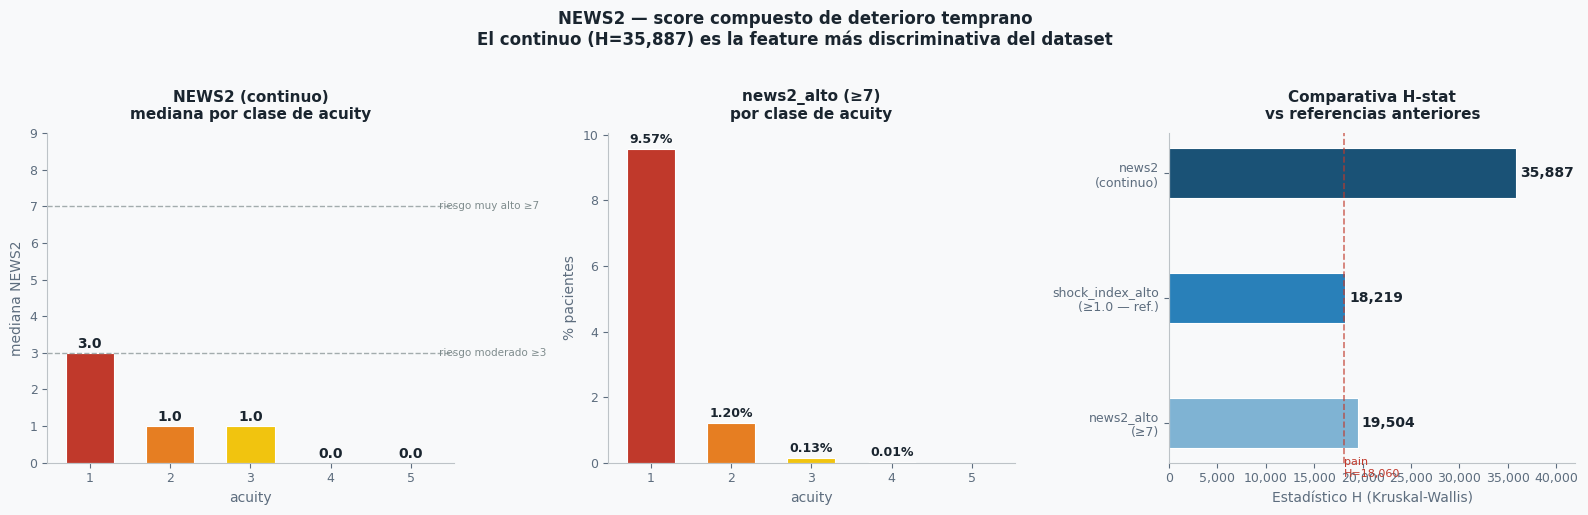

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: mediana NEWS2 por acuity ───────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

medianas = df.groupby("acuity")["news2"].median().values

bars = ax1.bar(acuity_levels, medianas, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

# Líneas de referencia umbrales NEWS2
for umbral, label in [(3, "riesgo moderado ≥3"), (7, "riesgo muy alto ≥7")]:
    ax1.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana NEWS2", fontsize=10, color="#5D6D7E")
ax1.set_title("NEWS2 (continuo)\nmediana por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)
ax1.set_ylim(0, 9)

# ── Centro: news2_alto (≥7) por acuity ───────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_alto = (df.groupby("acuity")["news2_alto"].mean() * 100).round(2).values

bars2 = ax2.bar(acuity_levels, pcts_alto, color=colores_barra,
                edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars2, pcts_alto):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("news2_alto (≥7)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)

# ── Derecha: comparativa H-stat ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = ["news2_alto\n(≥7)", "shock_index_alto\n(≥1.0 — ref.)", "news2\n(continuo)"]
hstats   = [19504, 18219, 35887]
cols_h   = ["#7FB3D3", "#2980B9", "#1A5276"]

bars3 = ax3.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 400, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

# Línea de referencia pain
ax3.axvline(x=18060, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax3.text(18100, -0.45, "pain\nH=18,060", color="#C0392B", fontsize=8, va="bottom")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs referencias anteriores",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 42000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "NEWS2 — score compuesto de deterioro temprano\n"
    "El continuo (H=35,887) es la feature más discriminativa del dataset",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_news2.png", dpi=150, bbox_inches="tight")
plt.show()

NEWS2 es la feature más discriminativa del dataset (H=35,887), casi duplicando a pain y shock_index_alto. El gráfico de medianas muestra la separación más limpia vista hasta ahora: acuity 1 en zona de riesgo moderado (mediana 3.0), acuity 2-3 en riesgo bajo (1.0), y acuity 4-5 en cero. El score compuesto captura información sinérgica que ningún vital individual puede ver por separado — supera a resprate (H=7,055) siendo este su componente más potente. El proxy de consciencia mediante pain_missing contribuye de forma efectiva, aportando 3 puntos adicionales a los pacientes que no pueden reportar dolor, lo que refuerza la separación en acuity 1. La bandera news2_alto (≥7) complementa al continuo con un patrón casi determinista (9.57% en acuity 1, prácticamente cero a partir de acuity 3) sin reemplazarlo — ambas entran al modelo.

In [64]:
# Score clínico: qSOFA (Quick Sequential Organ Failure Assessment)
# Sepsis-3 International Consensus, 2016
# Específico para detección de sepsis fuera de UCI
# Componentes:
#   - resprate >= 22 rpm        → 1 punto
#   - sbp <= 100 mmHg           → 1 punto
#   - consciencia alterada      → 1 punto (proxy: pain_missing)
# qSOFA >= 2 → alto riesgo de mortalidad por sepsis

def calcular_qsofa_vectorizado(df):
    score = np.zeros(len(df))

    # Frecuencia respiratoria >= 22
    rr = df["resprate"].values
    score += np.where(~np.isnan(rr) & (rr >= 22), 1, 0)

    # Presión arterial sistólica <= 100
    sbp = df["sbp"].values
    score += np.where(~np.isnan(sbp) & (sbp <= 100), 1, 0)

    # Consciencia alterada — proxy pain_missing
    score += np.where(df["pain_missing"].values == 1, 1, 0)

    return score.astype("int8")

df["qsofa"] = calcular_qsofa_vectorizado(df)
df["qsofa_positivo"] = (df["qsofa"] >= 2).astype("int8")

print(f"{'Feature':<22} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 72)

for col in ["qsofa", "qsofa_positivo"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<22} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nDistribución qSOFA por valor (0, 1, 2, 3):\n")
print((df["qsofa"].value_counts(normalize=True) * 100).sort_index().round(2).to_string())

print(f"\n% qsofa_positivo (≥2) por clase de acuity:\n")
print((df.groupby("acuity")["qsofa_positivo"].mean() * 100).round(2).to_string())

Feature                  H-stat       p-value   Prevalencia   n casos
────────────────────────────────────────────────────────────────────────
qsofa                    50,721      0.00e+00        16.08%    67,218
qsofa_positivo           13,936      0.00e+00         1.34%     5,592

Distribución qSOFA por valor (0, 1, 2, 3):

qsofa
0    85.33
1    13.34
2     1.27
3     0.07

% qsofa_positivo (≥2) por clase de acuity:

acuity
1    9.36
2    1.80
3    0.36
4    0.06
5    0.18


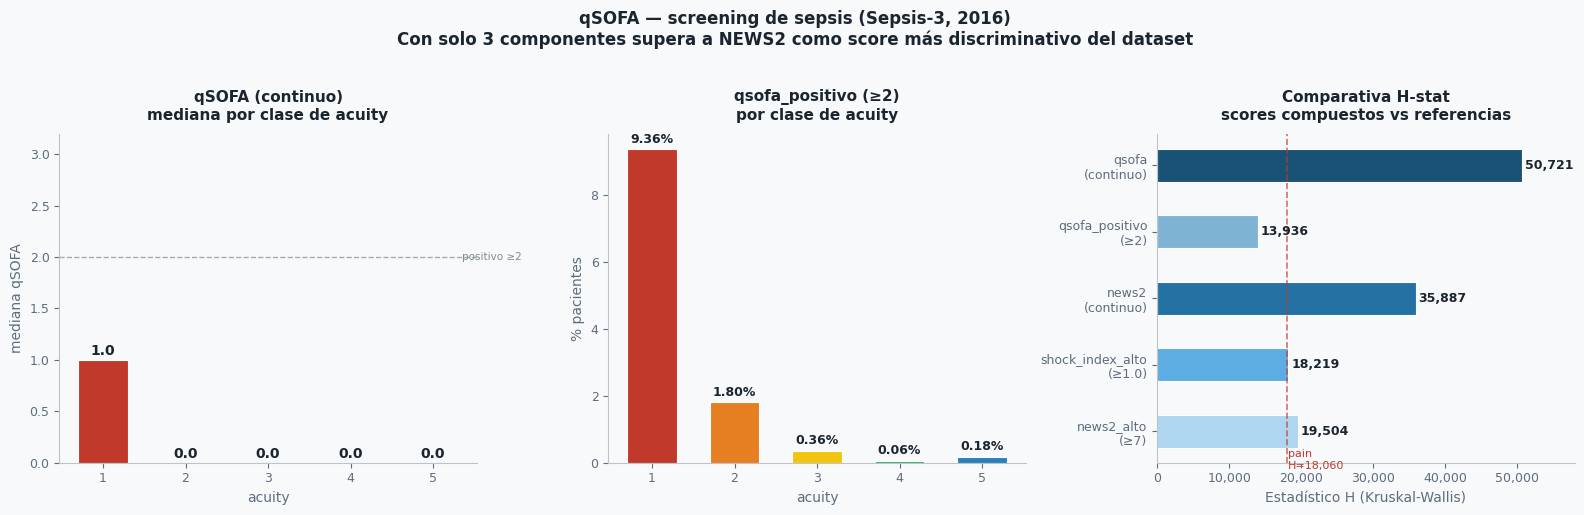

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: mediana qSOFA por acuity ───────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

medianas = df.groupby("acuity")["qsofa"].median().values

bars = ax1.bar(acuity_levels, medianas, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

ax1.axhline(2, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, 2, "positivo ≥2", fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana qSOFA", fontsize=10, color="#5D6D7E")
ax1.set_title("qSOFA (continuo)\nmediana por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)
ax1.set_ylim(0, 3.2)

# ── Centro: qsofa_positivo por acuity ────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts = (df.groupby("acuity")["qsofa_positivo"].mean() * 100).round(2).values

bars2 = ax2.bar(acuity_levels, pcts, color=colores_barra,
                edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars2, pcts):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("qsofa_positivo (≥2)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)

# ── Derecha: comparativa H-stat qSOFA vs NEWS2 vs referencias ─────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = [
    "news2_alto\n(≥7)",
    "shock_index_alto\n(≥1.0)",
    "news2\n(continuo)",
    "qsofa_positivo\n(≥2)",
    "qsofa\n(continuo)",
]
hstats = [19504, 18219, 35887, 13936, 50721]
cols_h = ["#AED6F1", "#5DADE2", "#2471A3", "#7FB3D3", "#1A5276"]

bars3 = ax3.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.5)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 400, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax3.axvline(x=18060, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax3.text(18100, -0.6, "pain\nH=18,060", color="#C0392B", fontsize=8, va="bottom")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nscores compuestos vs referencias",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 58000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "qSOFA — screening de sepsis (Sepsis-3, 2016)\n"
    "Con solo 3 componentes supera a NEWS2 como score más discriminativo del dataset",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_qsofa.png", dpi=150, bbox_inches="tight")
plt.show()

qSOFA (H=50,721) es el score más discriminativo del dataset, superando a NEWS2 (H=35,887) pese a usar solo 3 componentes frente a 6. Esto no es una contradicción — es una confirmación de que resprate, sbp y consciencia (proxy pain_missing) son exactamente los tres componentes con mayor poder predictivo individual, sin el ruido que introducen temperature y heartrate en zonas de baja separación entre clases. El 85.33% de los pacientes tienen qSOFA=0, lo que convierte la escala en un detector de excepciones: cuando se activa, la señal es fiable. El patrón por clase es consistente con el resto de scores — 9.36% positivos en acuity 1 frente a valores prácticamente nulos en acuity 3-5. El continuo (H=50,721) supera a la bandera binaria (H=13,936), por lo que ambos entran al modelo de forma complementaria: el continuo captura el gradiente 0→1→2→3 y qsofa_positivo añade una señal de alarma explícita de sepsis que XGBoost puede identificar directamente sin necesidad de aprender el umbral solo.

RESUMEN DE LO QUE TENEMOS HASTA AHORA

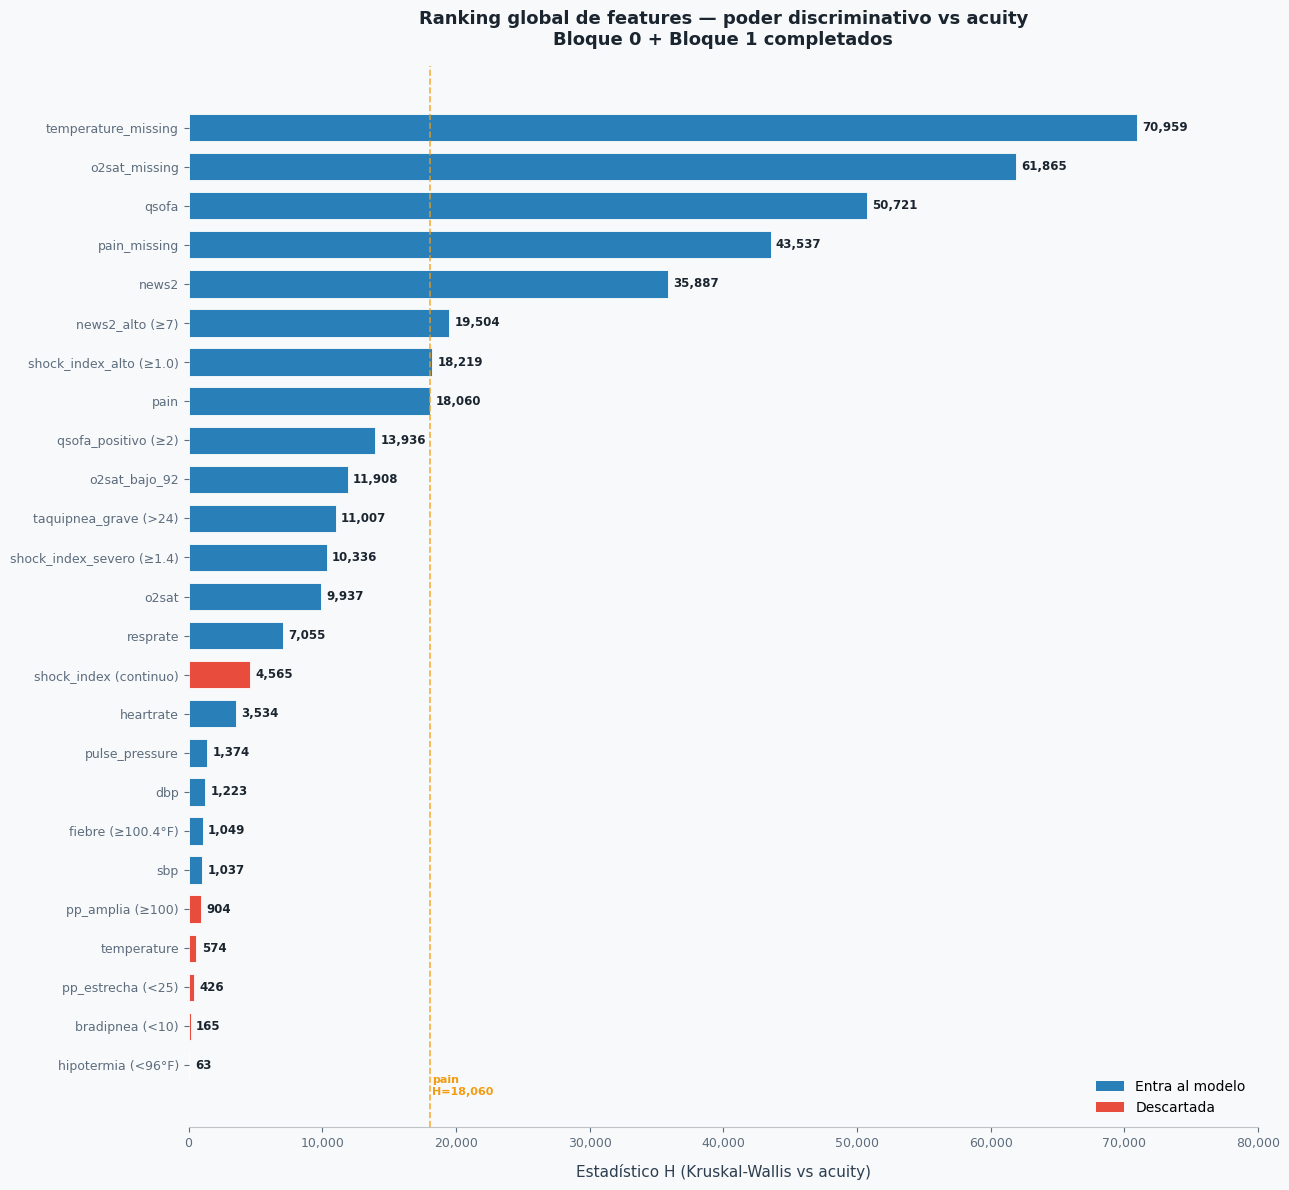

In [66]:
# Resumen comparativo de todos los H-stats calculados

features_resumen = {
    # Missingness flags
    "temperature_missing":    {"H": 70959, "grupo": "Missingness",      "estado": "entra"},
    "o2sat_missing":          {"H": 61865, "grupo": "Missingness",      "estado": "entra"},
    "pain_missing":           {"H": 43537, "grupo": "Missingness",      "estado": "entra"},

    # Scores compuestos
    "qsofa":                  {"H": 50721, "grupo": "Scores",           "estado": "entra"},
    "news2":                  {"H": 35887, "grupo": "Scores",           "estado": "entra"},
    "news2_alto (≥7)":        {"H": 19504, "grupo": "Scores",           "estado": "entra"},
    "shock_index_alto (≥1.0)":{"H": 18219, "grupo": "Scores",           "estado": "entra"},
    "qsofa_positivo (≥2)":    {"H": 13936, "grupo": "Scores",           "estado": "entra"},
    "shock_index_severo (≥1.4)":{"H":10336,"grupo": "Scores",           "estado": "entra"},

    # Vitales crudos — entran
    "pain":                   {"H": 18060, "grupo": "Vitales crudos",   "estado": "entra"},
    "o2sat_bajo_92":          {"H": 11908, "grupo": "Banderas clínicas","estado": "entra"},
    "taquipnea_grave (>24)":  {"H": 11007, "grupo": "Banderas clínicas","estado": "entra"},
    "o2sat":                  {"H":  9937, "grupo": "Vitales crudos",   "estado": "entra"},
    "resprate":               {"H":  7055, "grupo": "Vitales crudos",   "estado": "entra"},
    "heartrate":              {"H":  3534, "grupo": "Vitales crudos",   "estado": "entra"},
    "shock_index (continuo)": {"H":  4565, "grupo": "Scores",           "estado": "descartado"},
    "pulse_pressure":         {"H":  1374, "grupo": "Scores",           "estado": "entra"},
    "dbp":                    {"H":  1223, "grupo": "Vitales crudos",   "estado": "entra"},
    "fiebre (≥100.4°F)":      {"H":  1049, "grupo": "Banderas clínicas","estado": "entra"},
    "sbp":                    {"H":  1037, "grupo": "Vitales crudos",   "estado": "entra"},
    "pp_amplia (≥100)":       {"H":   904, "grupo": "Scores",           "estado": "descartado"},
    "temperature":            {"H":   574, "grupo": "Vitales crudos",   "estado": "descartado"},
    "pp_estrecha (<25)":      {"H":   426, "grupo": "Scores",           "estado": "descartado"},
    "bradipnea (<10)":        {"H":   165, "grupo": "Banderas clínicas","estado": "descartado"},
    "hipotermia (<96°F)":     {"H":    63, "grupo": "Banderas clínicas","estado": "descartado"},
}

df_resumen = pd.DataFrame(features_resumen).T.reset_index()
df_resumen.columns = ["feature", "H", "grupo", "estado"]
df_resumen["H"] = df_resumen["H"].astype(int)
df_resumen = df_resumen.sort_values("H", ascending=True)

# Colores por estado
color_map = {
    "entra":      "#2980B9",
    "descartado": "#E74C3C",
}
colores = [color_map[e] for e in df_resumen["estado"]]

# Marcadores por grupo
marker_map = {
    "Missingness":      "▶",
    "Scores":           "●",
    "Vitales crudos":   "■",
    "Banderas clínicas":"◆",
}

fig, ax = plt.subplots(figsize=(13, 12))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(df_resumen["feature"], df_resumen["H"],
               color=colores, edgecolor="white", linewidth=0.6, height=0.7)

for bar, val in zip(bars, df_resumen["H"]):
    ax.text(bar.get_width() + 400, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left",
            fontsize=8.5, fontweight="bold", color="#1A252F")

# Línea de referencia pain
ax.axvline(x=18060, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(18200, -0.8, "pain\nH=18,060", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title("Ranking global de features — poder discriminativo vs acuity\n"
             "Bloque 0 + Bloque 1 completados",
             fontsize=13, fontweight="bold", color="#1A252F", pad=15)

# Leyenda estado
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="#2980B9", label="Entra al modelo"),
    Patch(facecolor="#E74C3C", label="Descartada"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=10)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, 80000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("resumen_hstat_global.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
# Bandera de Estabilidad Fisiológica — "Zona Verde" SET
# Criterios de estabilidad fisiológica total del Sistema Español de Triaje
# Un solo vital alterado excluye al paciente de zona verde → acuity 4/5
# NaN en cualquier vital → False (criterio conservador correcto)

df["zona_verde"] = (
    (df["heartrate"].between(60, 100))   &   # FC normal
    (df["resprate"].between(12, 20))     &   # FR normal
    (df["o2sat"] >= 95)                  &   # Saturación normal
    (df["sbp"].between(100, 140))        &   # TAS normal
    (df["temperature"].between(96.8, 99.5)) &  # Temp normal (°F: 36.1–37.5°C)
    (df["pain_missing"] == 0)                  # Consciente y alerta
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "zona_verde"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["zona_verde"].mean() * 100
n    = df["zona_verde"].sum()

print(f"zona_verde  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")

print("% zona_verde por clase de acuity:\n")
print((df.groupby("acuity")["zona_verde"].mean() * 100).round(2).to_string())

zona_verde  →  H = 14,389  |  p = 0.00e+00  |  prevalencia = 36.60%  |  n = 153,044

% zona_verde por clase de acuity:

acuity
1     8.45
2    31.29
3    41.03
4    50.75
5    52.91


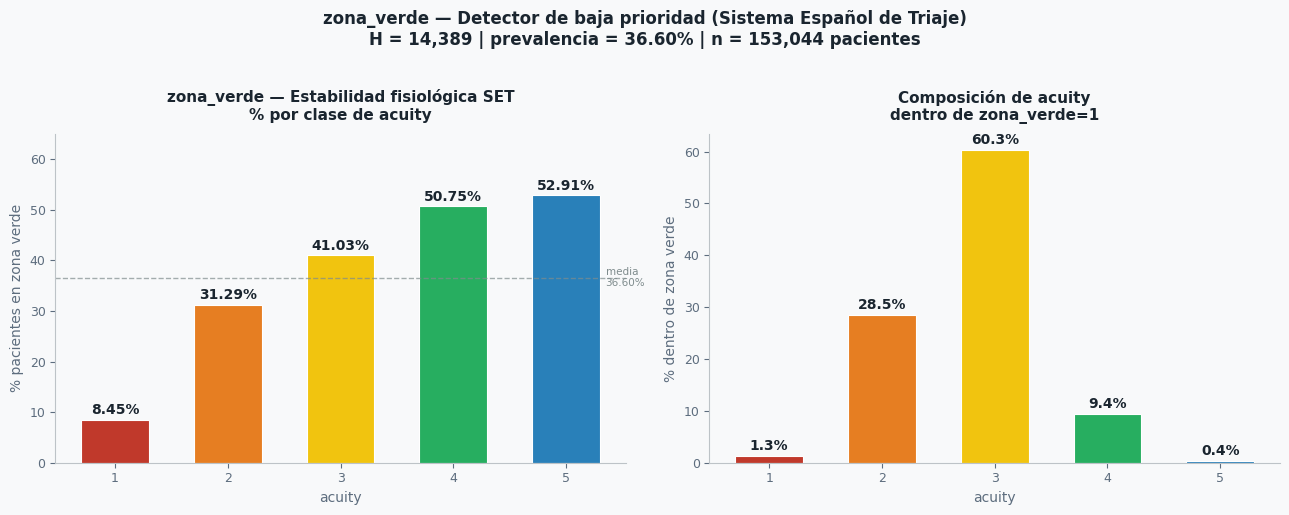

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: % zona_verde por acuity ───────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts = (df.groupby("acuity")["zona_verde"].mean() * 100).round(2).values

bars = ax1.bar(acuity_levels, pcts, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.2f}%", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

# Línea de prevalencia global
ax1.axhline(36.60, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, 36.60, "media\n36.60%", fontsize=7.5,
         color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes en zona verde", fontsize=10, color="#5D6D7E")
ax1.set_title("zona_verde — Estabilidad fisiológica SET\n% por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)
ax1.set_ylim(0, 65)

# ── Derecha: distribución de acuity dentro de zona_verde ─────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

# % de cada acuity dentro de los pacientes con zona_verde=1
dist_dentro = (
    df[df["zona_verde"] == 1]["acuity"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

bars2 = ax2.bar(dist_dentro.index, dist_dentro.values, color=colores_barra,
                edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars2, dist_dentro.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% dentro de zona verde", fontsize=10, color="#5D6D7E")
ax2.set_title("Composición de acuity\ndentro de zona_verde=1",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)

fig.suptitle(
    "zona_verde — Detector de baja prioridad (Sistema Español de Triaje)\n"
    "H = 14,389 | prevalencia = 36.60% | n = 153,044 pacientes",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_zona_verde.png", dpi=150, bbox_inches="tight")
plt.show()

zona_verde (H=14,389) es el mejor detector de baja prioridad del dataset y el único score diseñado específicamente para identificar acuity 4-5. Con una prevalencia del 36.60%, más de 1 de cada 3 pacientes cumple criterios de estabilidad fisiológica total según el SET. El patrón por clase es progresivo y limpio: de 8.45% en acuity 1 a 52.91% en acuity 5, confirmando que la bandera funciona como un "ancla" para los niveles menos urgentes.
El gráfico de composición revela el dato más importante: el 60.3% de los pacientes en zona verde son acuity 3, y solo el 1.3% son acuity 1. Esto significa que zona_verde=1 casi descarta la emergencia inmediata, pero no garantiza baja prioridad — el grueso de los pacientes estables fisiológicamente son acuity 3, no acuity 4-5.
El hallazgo más relevante para el TFG es que el 31.29% de los acuity 2 están en zona verde — casi 1 de cada 3 emergencias tiene los vitales completamente normales en T=0. Esto demuestra empíricamente que los vitales solos son insuficientes para el triaje y justifica la necesidad de explorar chiefcomplaint y las banderas de medicación en los bloques siguientes. Entra al modelo.

In [69]:
# Criterios SIRS Clínicos — Screening de Sepsis
# Usado en urgencias españolas como cribado inicial antes del qSOFA
# Más sensible que qSOFA (atrapa más casos) pero menos específico
# Requiere >= 2 criterios de los 3 clínicos disponibles en T=0:
#   - Temperatura > 38°C (100.4°F) o < 36°C (96.8°F)
#   - Frecuencia cardíaca > 90 lpm
#   - Frecuencia respiratoria > 20 rpm

sirs_temp = (
    (df["temperature"] >= 100.4) | (df["temperature"] <= 96.8)
).astype(int)
sirs_hr  = (df["heartrate"] > 90).astype(int)
sirs_rr  = (df["resprate"] > 20).astype(int)

# NaN → 0 en cada componente (conservador: no sumamos puntos sin dato)
sirs_temp = sirs_temp.fillna(0)
sirs_hr   = sirs_hr.fillna(0)
sirs_rr   = sirs_rr.fillna(0)

df["sirs_score"]    = (sirs_temp + sirs_hr + sirs_rr).astype("int8")
df["sirs_positivo"] = (df["sirs_score"] >= 2).astype("int8")

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["sirs_score", "sirs_positivo"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nDistribución sirs_score (0, 1, 2, 3):\n")
print((df["sirs_score"].value_counts(normalize=True).sort_index() * 100).round(2).to_string())

print(f"\n% sirs_positivo por clase de acuity:\n")
print((df.groupby("acuity")["sirs_positivo"].mean() * 100).round(2).to_string())

Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
sirs_score              2,723      0.00e+00        46.00%   192,342
sirs_positivo           5,188      0.00e+00         5.97%    24,965

Distribución sirs_score (0, 1, 2, 3):

sirs_score
0    60.36
1    33.67
2     5.58
3     0.39

% sirs_positivo por clase de acuity:

acuity
1    13.55
2     7.99
3     4.40
4     2.26
5     2.55


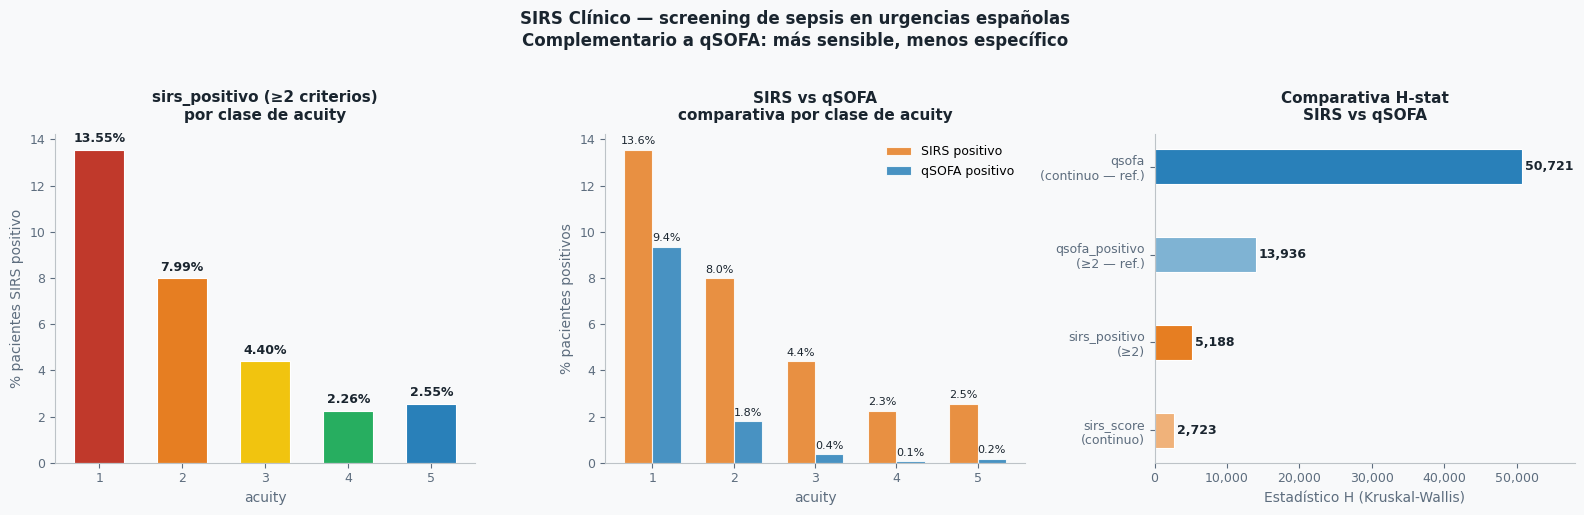

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: % sirs_positivo por acuity ────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_sirs = (df.groupby("acuity")["sirs_positivo"].mean() * 100).round(2).values

bars = ax1.bar(acuity_levels, pcts_sirs, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts_sirs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.2f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes SIRS positivo", fontsize=10, color="#5D6D7E")
ax1.set_title("sirs_positivo (≥2 criterios)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Centro: comparativa SIRS vs qSOFA por acuity ─────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_qsofa = (df.groupby("acuity")["qsofa_positivo"].mean() * 100).round(2).values

x = np.arange(len(acuity_levels))
width = 0.35

bars1 = ax2.bar(x - width/2, pcts_sirs, width, label="SIRS positivo",
                color="#E67E22", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax2.bar(x + width/2, pcts_qsofa, width, label="qSOFA positivo",
                color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_sirs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(bars2, pcts_qsofa):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes positivos", fontsize=10, color="#5D6D7E")
ax2.set_title("SIRS vs qSOFA\ncomparativa por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(acuity_levels)
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: comparativa H-stat ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = [
    "sirs_score\n(continuo)",
    "sirs_positivo\n(≥2)",
    "qsofa_positivo\n(≥2 — ref.)",
    "qsofa\n(continuo — ref.)",
]
hstats = [2723, 5188, 13936, 50721]
cols_h = ["#F0B27A", "#E67E22", "#7FB3D3", "#2980B9"]

bars3 = ax3.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 400, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nSIRS vs qSOFA",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 58000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "SIRS Clínico — screening de sepsis en urgencias españolas\n"
    "Complementario a qSOFA: más sensible, menos específico",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_sirs.png", dpi=150, bbox_inches="tight")
plt.show()

sirs_positivo (H=5,188) entra al modelo como complemento a qSOFA, no como sustituto. El gráfico comparativo central muestra perfectamente la diferencia entre ambos scores: en acuity 1, SIRS detecta el 13.6% de los pacientes frente al 9.4% de qSOFA — es más sensible, atrapa más casos críticos. Pero a partir de acuity 2, SIRS mantiene tasas elevadas (8.0%, 4.4%) mientras qSOFA cae en picado (1.8%, 0.4%), lo que confirma su menor especificidad — no distingue bien entre infección grave e infección moderada.
El valor clínico de incluir ambos simultáneamente es exactamente esa diferencia: un paciente con qsofa_positivo=1 y sirs_positivo=1 es sepsis de alto riesgo; un paciente con sirs_positivo=1 pero qsofa_positivo=0 es infección en curso sin criterios de gravedad inmediata — acuity 2-3 probable. XGBoost puede aprender esta distinción si ve ambas variables. El continuo sirs_score se descarta por quedar por debajo de la bandera binaria en H-stat. sirs_positivo entra al modelo.

In [71]:
# Shock Index Ajustado por Edad — Shock Oculto en Ancianos
# En pacientes >= 65 años, el umbral de alarma del Shock Index baja a 0.85
# por rigidez arterial y uso de betabloqueantes que enmascaran la taquicardia
# y mantienen artificialmente alta la presión sistólica

# Comparación segura con fillna antes del astype para evitar NaN → int8
edad_ok    = df["age"].fillna(0) >= 65
shock_ok   = df["shock_index"].fillna(0) >= 0.85

df["shock_oculto_anciano"] = (edad_ok & shock_ok).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "shock_oculto_anciano"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["shock_oculto_anciano"].mean() * 100
n    = int(df["shock_oculto_anciano"].sum())

print(f"shock_oculto_anciano  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")

print("% shock_oculto_anciano por clase de acuity:\n")
print((df.groupby("acuity")["shock_oculto_anciano"].mean() * 100).round(2).to_string())

print(f"\nComparativa con shock_index_alto (≥1.0) en población >= 65:\n")
ancianos = df[df["age"].fillna(0) >= 65]
print(f"Pacientes >= 65 años: {len(ancianos):,} ({len(ancianos)/len(df)*100:.1f}%)")
print(f"\n% shock_index_alto en ancianos por acuity:")
print((ancianos.groupby("acuity")["shock_index_alto"].mean() * 100).round(2).to_string())
print(f"\n% shock_oculto_anciano por acuity (umbral 0.85):")
print((ancianos.groupby("acuity")["shock_oculto_anciano"].mean() * 100).round(2).to_string())

shock_oculto_anciano  →  H = 9,129  |  p = 0.00e+00  |  prevalencia = 2.75%  |  n = 11,509

% shock_oculto_anciano por clase de acuity:

acuity
1    10.58
2     4.26
3     1.31
4     0.24
5     0.45

Comparativa con shock_index_alto (≥1.0) en población >= 65:

Pacientes >= 65 años: 130,885 (31.3%)

% shock_index_alto en ancianos por acuity:
acuity
1    15.20
2     3.73
3     1.04
4     0.38
5     0.85

% shock_oculto_anciano por acuity (umbral 0.85):
acuity
1    23.22
2    10.38
3     4.97
4     2.12
5     4.24


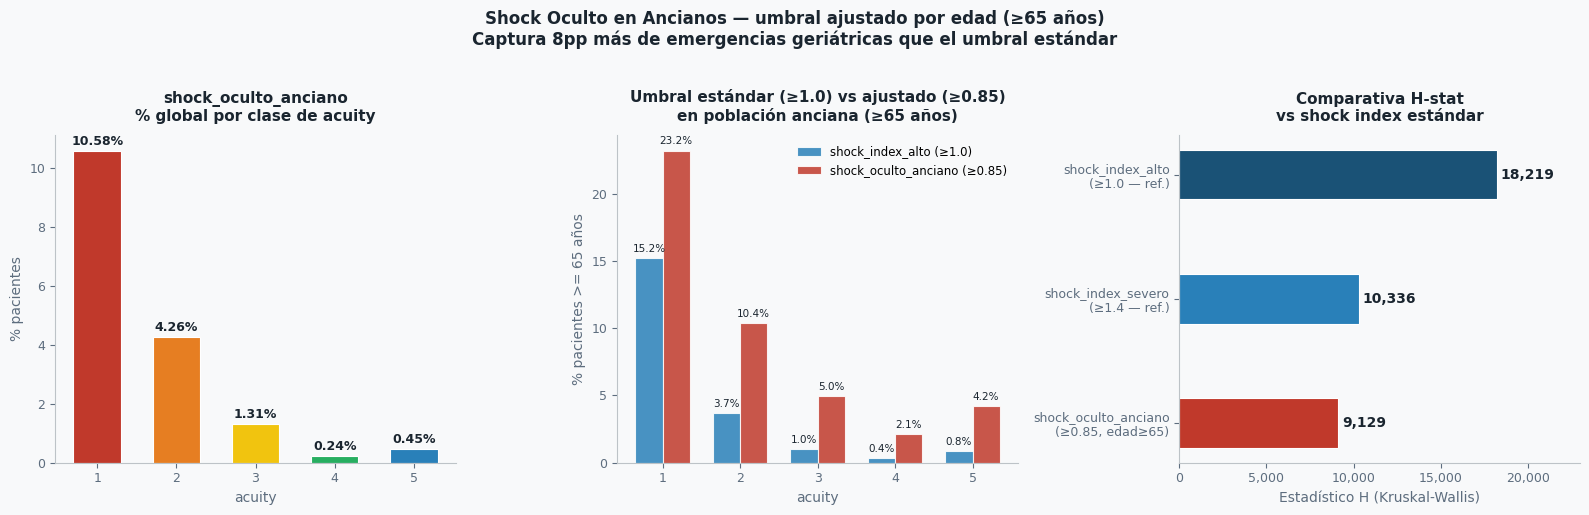

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: % shock_oculto_anciano global por acuity ──────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_global = (df.groupby("acuity")["shock_oculto_anciano"].mean() * 100).round(2).values

bars = ax1.bar(acuity_levels, pcts_global, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts_global):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("shock_oculto_anciano\n% global por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Centro: comparativa umbral 1.0 vs 0.85 en ancianos ───────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_alto_anc   = [15.20, 3.73, 1.04, 0.38, 0.85]
pcts_oculto_anc = [23.22, 10.38, 4.97, 2.12, 4.24]

x = np.arange(len(acuity_levels))
width = 0.35

bars1 = ax2.bar(x - width/2, pcts_alto_anc, width,
                label="shock_index_alto (≥1.0)",
                color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax2.bar(x + width/2, pcts_oculto_anc, width,
                label="shock_oculto_anciano (≥0.85)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_alto_anc):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5, color="#1A252F")
for bar, val in zip(bars2, pcts_oculto_anc):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5, color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes >= 65 años", fontsize=10, color="#5D6D7E")
ax2.set_title("Umbral estándar (≥1.0) vs ajustado (≥0.85)\nen población anciana (≥65 años)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(acuity_levels)
ax2.legend(frameon=False, fontsize=8.5)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: H-stat comparativa ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = [
    "shock_oculto_anciano\n(≥0.85, edad≥65)",
    "shock_index_severo\n(≥1.4 — ref.)",
    "shock_index_alto\n(≥1.0 — ref.)",
]
hstats = [9129, 10336, 18219]
cols_h = ["#C0392B", "#2980B9", "#1A5276"]

bars3 = ax3.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs shock index estándar",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 23000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Shock Oculto en Ancianos — umbral ajustado por edad (≥65 años)\n"
    "Captura 8pp más de emergencias geriátricas que el umbral estándar",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_shock_oculto_anciano.png", dpi=150, bbox_inches="tight")
plt.show()

shock_oculto_anciano (H=9,129) entra al modelo como corrección del sesgo fisiológico de la edad. El gráfico central demuestra empíricamente el argumento clínico: en la población anciana (≥65 años, 31.3% del dataset), el umbral ajustado de 0.85 detecta el 23.2% de los acuity 1 frente al 15.2% del umbral estándar — una ganancia de 8 puntos porcentuales de emergencias geriátricas que de otro modo quedarían clasificadas como normales. Esta diferencia representa exactamente el perfil del anciano con shock oculto: arterias rígidas y betabloqueantes que mantienen artificialmente normal el shock index estándar.
El H-stat global (9,129) es inferior a shock_index_alto (18,219) porque la feature solo es informativa para el 31.3% de la población — en los jóvenes aporta cero señal. XGBoost aprenderá a activarla condicionalmente junto con age, capturando la interacción que ninguna bandera individual puede ver. El único punto débil es el repunte en acuity 5 (4.2% dentro de ancianos), que indica que el umbral 0.85 es algo permisivo en los casos más leves — el modelo deberá cruzarlo con otras features para reducir los falsos positivos. Entra al modelo.

RESUMEN HASTA AHORA

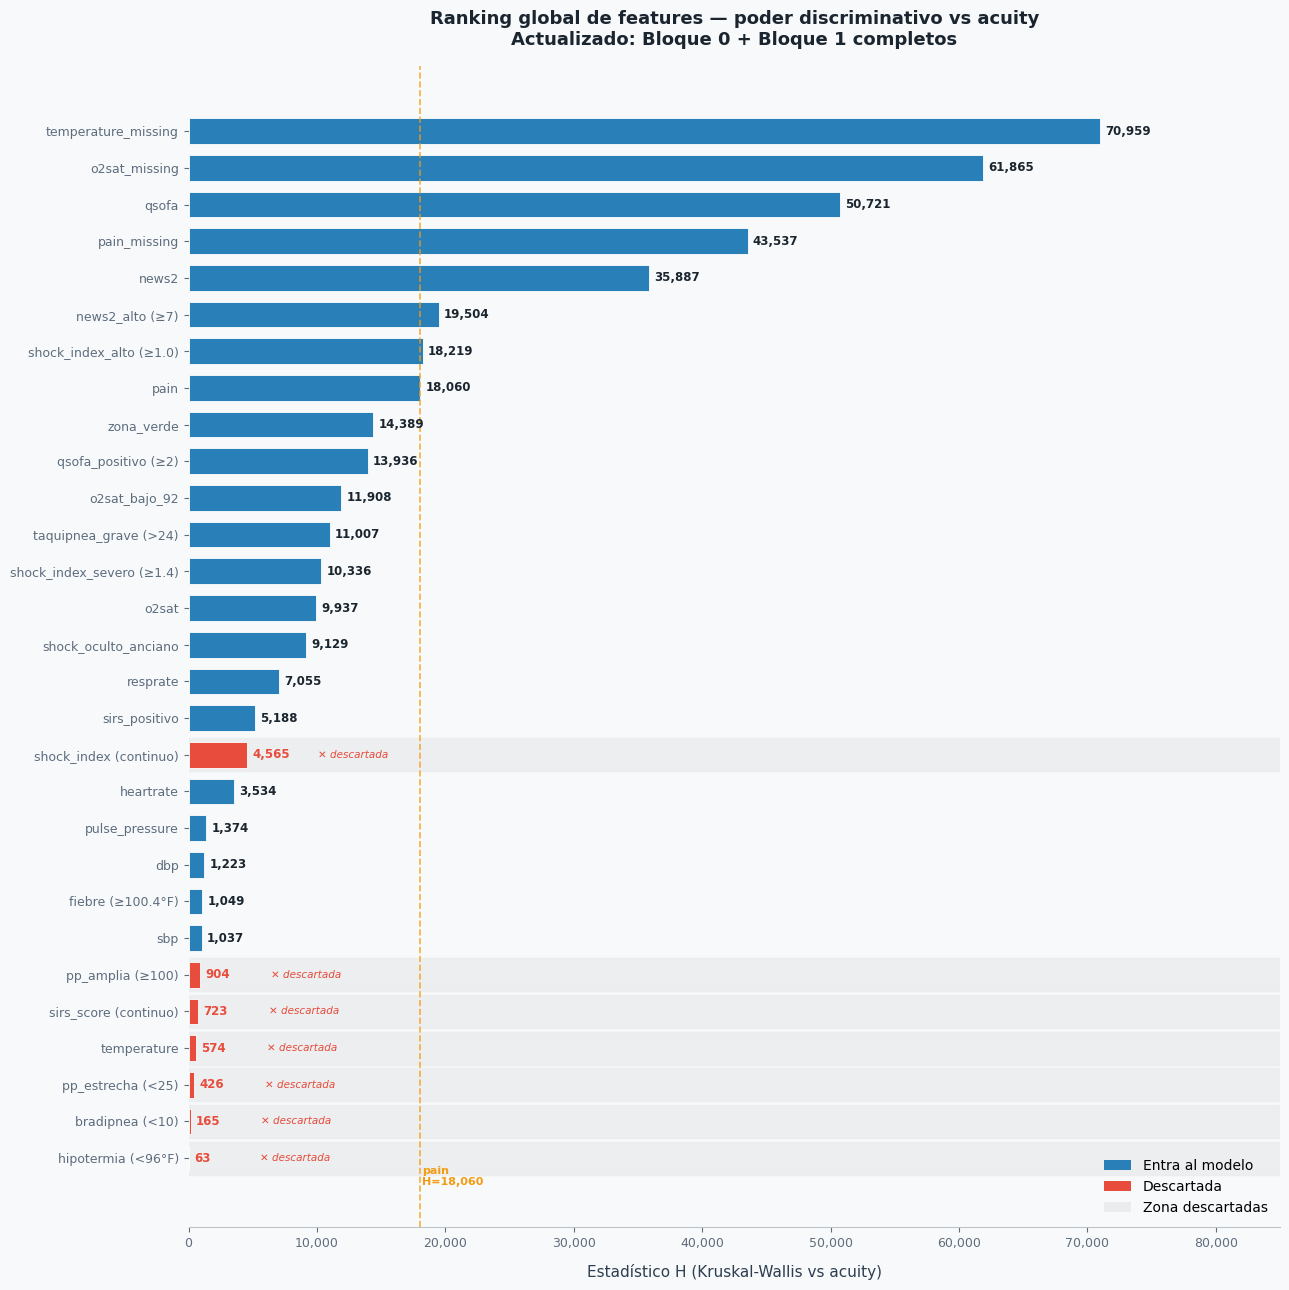

In [73]:
features_resumen_v2 = {
    # Missingness flags
    "temperature_missing":      {"H": 70959, "grupo": "Missingness",       "estado": "entra"},
    "o2sat_missing":            {"H": 61865, "grupo": "Missingness",       "estado": "entra"},
    "qsofa":                    {"H": 50721, "grupo": "Scores",            "estado": "entra"},
    "pain_missing":             {"H": 43537, "grupo": "Missingness",       "estado": "entra"},
    "news2":                    {"H": 35887, "grupo": "Scores",            "estado": "entra"},
    "news2_alto (≥7)":          {"H": 19504, "grupo": "Scores",            "estado": "entra"},
    "shock_index_alto (≥1.0)":  {"H": 18219, "grupo": "Scores",           "estado": "entra"},
    "zona_verde":               {"H": 14389, "grupo": "Scores",            "estado": "entra"},
    "pain":                     {"H": 18060, "grupo": "Vitales crudos",    "estado": "entra"},
    "qsofa_positivo (≥2)":      {"H": 13936, "grupo": "Scores",           "estado": "entra"},
    "o2sat_bajo_92":            {"H": 11908, "grupo": "Banderas clínicas", "estado": "entra"},
    "taquipnea_grave (>24)":    {"H": 11007, "grupo": "Banderas clínicas", "estado": "entra"},
    "shock_index_severo (≥1.4)":{"H": 10336, "grupo": "Scores",           "estado": "entra"},
    "o2sat":                    {"H":  9937, "grupo": "Vitales crudos",    "estado": "entra"},
    "shock_oculto_anciano":     {"H":  9129, "grupo": "Scores",            "estado": "entra"},
    "resprate":                 {"H":  7055, "grupo": "Vitales crudos",    "estado": "entra"},
    "sirs_positivo":            {"H":  5188, "grupo": "Scores",            "estado": "entra"},
    "shock_index (continuo)":   {"H":  4565, "grupo": "Scores",            "estado": "descartado"},
    "heartrate":                {"H":  3534, "grupo": "Vitales crudos",    "estado": "entra"},
    "pulse_pressure":           {"H":  1374, "grupo": "Scores",            "estado": "entra"},
    "dbp":                      {"H":  1223, "grupo": "Vitales crudos",    "estado": "entra"},
    "fiebre (≥100.4°F)":        {"H":  1049, "grupo": "Banderas clínicas", "estado": "entra"},
    "sbp":                      {"H":  1037, "grupo": "Vitales crudos",    "estado": "entra"},
    "sirs_score (continuo)":    {"H":   723, "grupo": "Scores",            "estado": "descartado"},
    "pp_amplia (≥100)":         {"H":   904, "grupo": "Scores",            "estado": "descartado"},
    "temperature":              {"H":   574, "grupo": "Vitales crudos",    "estado": "descartado"},
    "pp_estrecha (<25)":        {"H":   426, "grupo": "Scores",            "estado": "descartado"},
    "bradipnea (<10)":          {"H":   165, "grupo": "Banderas clínicas", "estado": "descartado"},
    "hipotermia (<96°F)":       {"H":    63, "grupo": "Banderas clínicas", "estado": "descartado"},
}

df_resumen_v2 = pd.DataFrame(features_resumen_v2).T.reset_index()
df_resumen_v2.columns = ["feature", "H", "grupo", "estado"]
df_resumen_v2["H"] = df_resumen_v2["H"].astype(int)
df_resumen_v2 = df_resumen_v2.sort_values("H", ascending=True).reset_index(drop=True)

color_entra      = "#2980B9"
color_descartado = "#E74C3C"
indices_descartados = df_resumen_v2[df_resumen_v2["estado"] == "descartado"].index.tolist()

fig, ax = plt.subplots(figsize=(13, 13))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

for i in indices_descartados:
    ax.axhspan(i - 0.45, i + 0.45, color="#EAECEE", alpha=0.8, zorder=0)

for i, row in df_resumen_v2.iterrows():
    color = color_entra if row["estado"] == "entra" else color_descartado
    ax.barh(i, row["H"], color=color, alpha=1.0,
            edgecolor="white", linewidth=0.6, height=0.7, zorder=2)
    ax.text(row["H"] + 400, i,
            f"{row['H']:,}", va="center", ha="left",
            fontsize=8.5, fontweight="bold",
            color=color_descartado if row["estado"] == "descartado" else "#1A252F")

for i in indices_descartados:
    ax.text(df_resumen_v2.loc[i, "H"] + 5500, i,
            "✕ descartada", va="center", ha="left",
            fontsize=7.5, color=color_descartado, fontstyle="italic")

ax.set_yticks(range(len(df_resumen_v2)))
ax.set_yticklabels(df_resumen_v2["feature"], fontsize=9, color="#2C3E50")

ax.axvline(x=18060, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(18200, -0.8, "pain\nH=18,060", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11,
              color="#2C3E50", labelpad=10)
ax.set_title("Ranking global de features — poder discriminativo vs acuity\n"
             "Actualizado: Bloque 0 + Bloque 1 completos",
             fontsize=13, fontweight="bold", color="#1A252F", pad=15)

from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=color_entra,      label="Entra al modelo"),
    Patch(facecolor=color_descartado, label="Descartada"),
    Patch(facecolor="#EAECEE",        label="Zona descartadas"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=10)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, 85000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("resumen_hstat_global_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [74]:
# Banderas de frecuencia cardíaca: taquicardia y bradicardia
# Discriminadores directos del SET para clasificación en niveles 2-4
# taquicardia: HR > 100 lpm
# bradicardia: HR < 60 lpm

df["taquicardia"] = (df["heartrate"] > 100).astype("int8")
df["bradicardia"] = (df["heartrate"] < 60).astype("int8")

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["taquicardia", "bradicardia"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nheartrate continuo  →  H = 3,534\n")

print("% por clase de acuity:\n")
resumen = pd.DataFrame({
    "taquicardia": (df.groupby("acuity")["taquicardia"].mean() * 100).round(2),
    "bradicardia":  (df.groupby("acuity")["bradicardia"].mean() * 100).round(2),
})
print(resumen.to_string())

Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
taquicardia             4,490      0.00e+00        17.16%    71,738
bradicardia               291      9.02e-62         4.79%    20,040

heartrate continuo  →  H = 3,534

% por clase de acuity:

        taquicardia  bradicardia
acuity                          
1             28.85         4.94
2             19.57         5.55
3             15.37         4.33
4              9.97         4.59
5              7.64         6.55


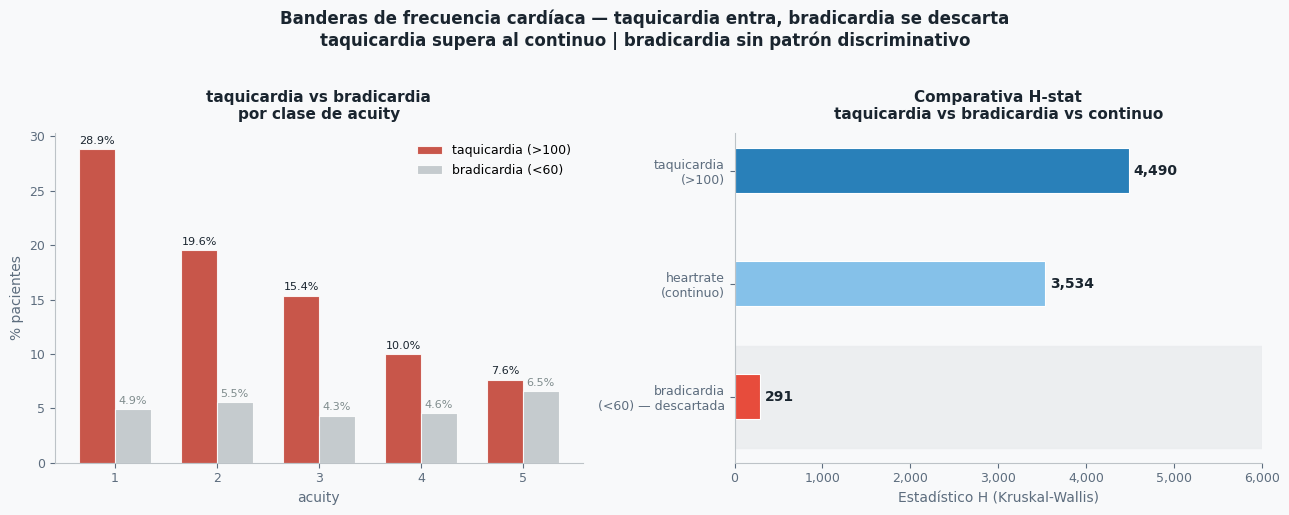

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: taquicardia y bradicardia por acuity ───────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_taq  = [28.85, 19.57, 15.37, 9.97, 7.64]
pcts_brad = [4.94, 5.55, 4.33, 4.59, 6.55]

x = np.arange(len(acuity_levels))
width = 0.35

bars1 = ax1.bar(x - width/2, pcts_taq, width, label="taquicardia (>100)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax1.bar(x + width/2, pcts_brad, width, label="bradicardia (<60)",
                color="#BDC3C7", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_taq):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(bars2, pcts_brad):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#7F8C8D")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("taquicardia vs bradicardia\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(acuity_levels)
ax1.legend(frameon=False, fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: H-stat comparativa ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features = ["bradicardia\n(<60) — descartada",
            "heartrate\n(continuo)",
            "taquicardia\n(>100)"]
hstats   = [291, 3534, 4490]
cols_h   = ["#E74C3C", "#85C1E9", "#2980B9"]

bars3 = ax2.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

# Fondo gris para descartada
ax2.axhspan(-0.45, 0.45, color="#EAECEE", alpha=0.8, zorder=0)

for bar, val in zip(bars3, hstats):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Comparativa H-stat\ntaquicardia vs bradicardia vs continuo",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 6000)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Banderas de frecuencia cardíaca — taquicardia entra, bradicardia se descarta\n"
    "taquicardia supera al continuo | bradicardia sin patrón discriminativo",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_fc_flags.png", dpi=150, bbox_inches="tight")
plt.show()

taquicardia (H=4,490) supera al continuo de heartrate (H=3,534) y entra al modelo con un patrón decreciente limpio: 28.85% en acuity 1 hasta 7.64% en acuity 5. La frecuencia cardíaca elevada como fenómeno binario captura mejor la señal de estrés hemodinámico y compensación circulatoria que el gradiente numérico, que mezcla mucho ruido en la zona 60-100 lpm donde se concentra el grueso de la población.
bradicardia (<60 lpm) se descarta con H=291 y distribución completamente plana — acuity 5 tiene más bradicardia (6.55%) que acuity 1 (4.94%). A diferencia de la bradipnea, aquí la explicación es fisiológica directa: la bradicardia en pacientes de urgencias leves corresponde mayoritariamente a deportistas, vagotónicos o pacientes con tratamiento betabloqueante sin descompensación aguda. No discrimina urgencia.

RESUMEN DE VITALES


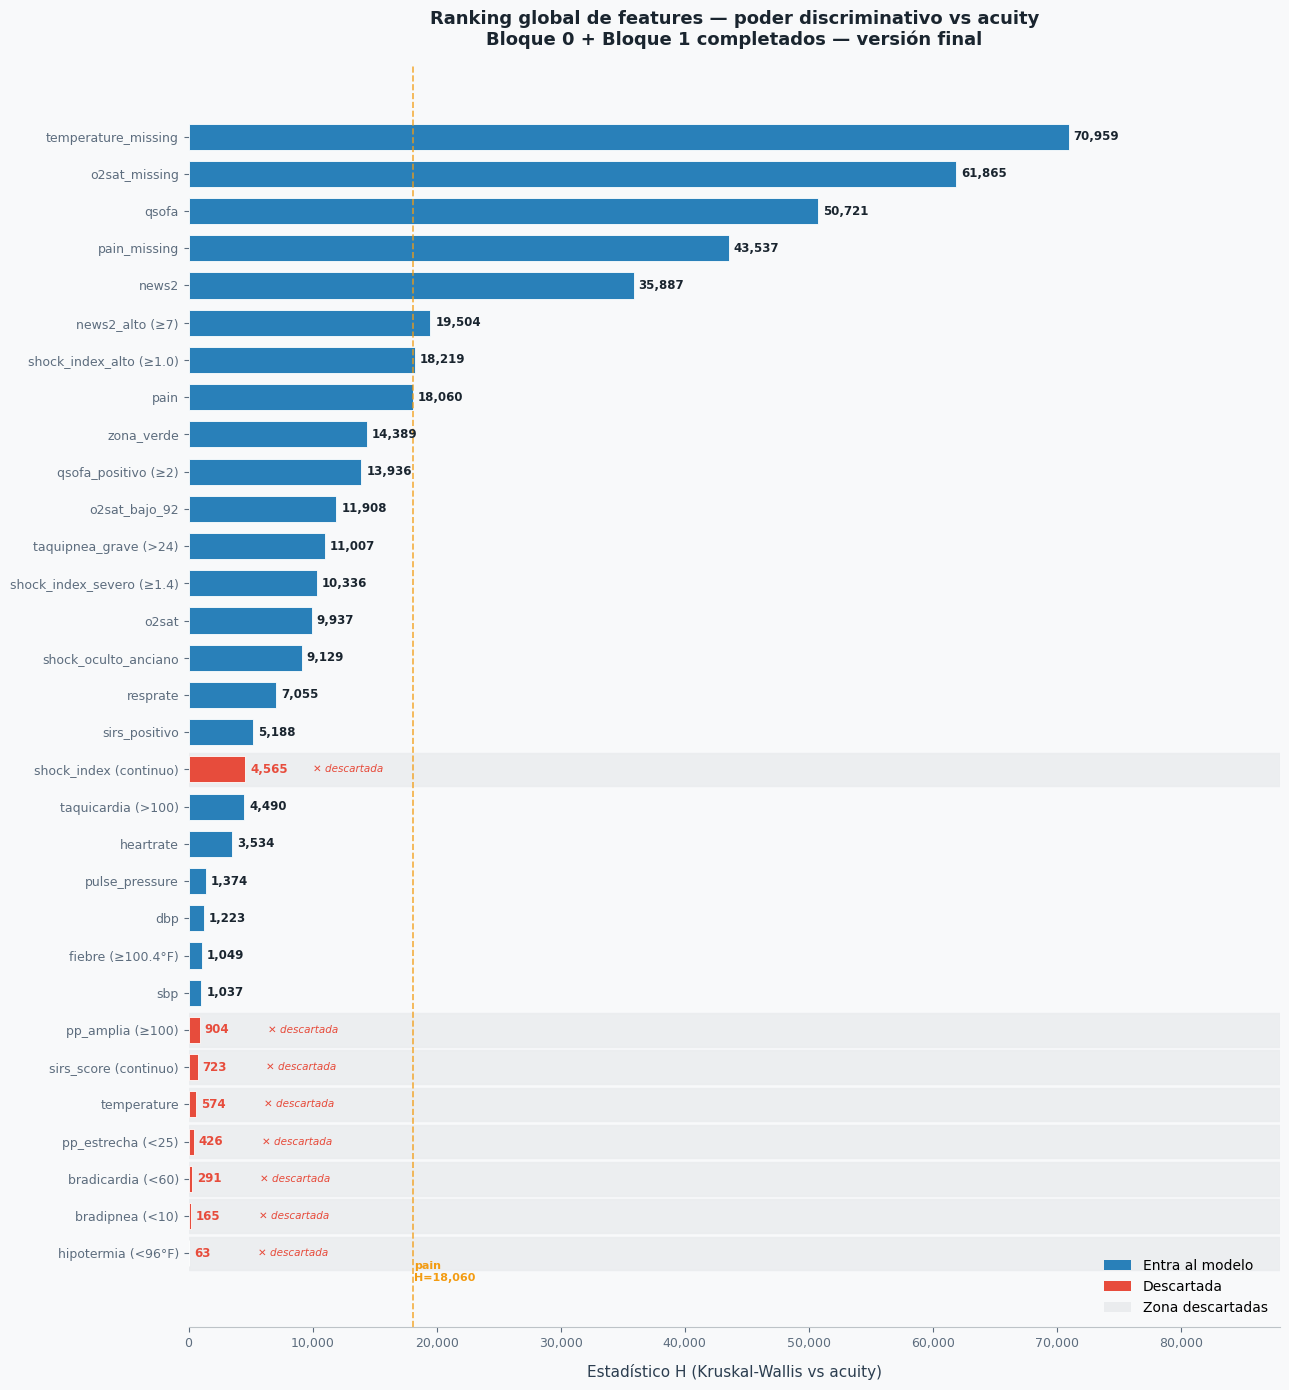

In [76]:
features_resumen_v3 = {
    # Missingness
    "temperature_missing":       {"H": 70959, "estado": "entra"},
    "o2sat_missing":             {"H": 61865, "estado": "entra"},
    "qsofa":                     {"H": 50721, "estado": "entra"},
    "pain_missing":              {"H": 43537, "estado": "entra"},
    "news2":                     {"H": 35887, "estado": "entra"},
    "news2_alto (≥7)":           {"H": 19504, "estado": "entra"},
    "pain":                      {"H": 18060, "estado": "entra"},
    "shock_index_alto (≥1.0)":   {"H": 18219, "estado": "entra"},
    "zona_verde":                {"H": 14389, "estado": "entra"},
    "qsofa_positivo (≥2)":       {"H": 13936, "estado": "entra"},
    "o2sat_bajo_92":             {"H": 11908, "estado": "entra"},
    "taquipnea_grave (>24)":     {"H": 11007, "estado": "entra"},
    "shock_index_severo (≥1.4)": {"H": 10336, "estado": "entra"},
    "o2sat":                     {"H":  9937, "estado": "entra"},
    "shock_oculto_anciano":      {"H":  9129, "estado": "entra"},
    "resprate":                  {"H":  7055, "estado": "entra"},
    "sirs_positivo":             {"H":  5188, "estado": "entra"},
    "shock_index (continuo)":    {"H":  4565, "estado": "descartado"},
    "taquicardia (>100)":        {"H":  4490, "estado": "entra"},
    "heartrate":                 {"H":  3534, "estado": "entra"},
    "pulse_pressure":            {"H":  1374, "estado": "entra"},
    "dbp":                       {"H":  1223, "estado": "entra"},
    "fiebre (≥100.4°F)":         {"H":  1049, "estado": "entra"},
    "sbp":                       {"H":  1037, "estado": "entra"},
    "sirs_score (continuo)":     {"H":   723, "estado": "descartado"},
    "pp_amplia (≥100)":          {"H":   904, "estado": "descartado"},
    "temperature":               {"H":   574, "estado": "descartado"},
    "pp_estrecha (<25)":         {"H":   426, "estado": "descartado"},
    "bradicardia (<60)":         {"H":   291, "estado": "descartado"},
    "bradipnea (<10)":           {"H":   165, "estado": "descartado"},
    "hipotermia (<96°F)":        {"H":    63, "estado": "descartado"},
}

df_v3 = pd.DataFrame(features_resumen_v3).T.reset_index()
df_v3.columns = ["feature", "H", "estado"]
df_v3["H"] = df_v3["H"].astype(int)
df_v3 = df_v3.sort_values("H", ascending=True).reset_index(drop=True)

color_entra      = "#2980B9"
color_descartado = "#E74C3C"
indices_desc = df_v3[df_v3["estado"] == "descartado"].index.tolist()

fig, ax = plt.subplots(figsize=(13, 14))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

for i in indices_desc:
    ax.axhspan(i - 0.45, i + 0.45, color="#EAECEE", alpha=0.8, zorder=0)

for i, row in df_v3.iterrows():
    color = color_entra if row["estado"] == "entra" else color_descartado
    ax.barh(i, row["H"], color=color, alpha=1.0,
            edgecolor="white", linewidth=0.6, height=0.7, zorder=2)
    ax.text(row["H"] + 400, i, f"{row['H']:,}",
            va="center", ha="left", fontsize=8.5, fontweight="bold",
            color=color_descartado if row["estado"] == "descartado" else "#1A252F")

for i in indices_desc:
    ax.text(df_v3.loc[i, "H"] + 5500, i, "✕ descartada",
            va="center", ha="left", fontsize=7.5,
            color=color_descartado, fontstyle="italic")

ax.set_yticks(range(len(df_v3)))
ax.set_yticklabels(df_v3["feature"], fontsize=9, color="#2C3E50")

ax.axvline(x=18060, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(18200, -0.8, "pain\nH=18,060", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=color_entra,      label="Entra al modelo"),
    Patch(facecolor=color_descartado, label="Descartada"),
    Patch(facecolor="#EAECEE",        label="Zona descartadas"),
], loc="lower right", frameon=False, fontsize=10)

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11,
              color="#2C3E50", labelpad=10)
ax.set_title("Ranking global de features — poder discriminativo vs acuity\n"
             "Bloque 0 + Bloque 1 completados — versión final",
             fontsize=13, fontweight="bold", color="#1A252F", pad=15)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, 88000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("resumen_hstat_global_v3.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
# Modified Shock Index (MSI) = FC / PAM
# PAM = (sbp + 2*dbp) / 3
# Incorpora la diastólica — mejor proxy de perfusión tisular que el SI clásico

df["pam"] = (df["sbp"] + 2 * df["dbp"]) / 3
df["msi"] = df["heartrate"] / df["pam"]

# Age Shock Index (ASI) = edad × shock_index
# Integra la carga fisiológica de la edad con la inestabilidad hemodinámica
df["asi"] = df["age"].fillna(0) * df["shock_index"].fillna(0)

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'nulos':>8}")
print("─" * 55)

for col in ["msi", "asi"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].dropna().values
        for k in [1, 2, 3, 4, 5]
    ])
    nulos = df[col].isna().sum()
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {nulos:>8,}")

print(f"\nshock_index_alto (≥1.0)  →  H = 18,219  [referencia]\n")

# Medianas por acuity
print("Medianas por clase de acuity:\n")
resumen = pd.DataFrame({
    "msi": df.groupby("acuity")["msi"].median().round(3),
    "asi": df.groupby("acuity")["asi"].median().round(1),
})
print(resumen.to_string())

# Distribución por umbrales MSI
print(f"\n% por umbral clínico MSI:\n")
umbrales_msi = {
    "MSI < 0.7  (normal)":       (df["msi"] < 0.7).mean() * 100,
    "MSI 0.7–1.0 (leve)":        ((df["msi"] >= 0.7) & (df["msi"] < 1.0)).mean() * 100,
    "MSI >= 1.0 (compromiso)":   (df["msi"] >= 1.0).mean() * 100,
}
for k, v in umbrales_msi.items():
    print(f"  {k}:  {v:.2f}%")

Feature                H-stat       p-value     nulos
───────────────────────────────────────────────────────
msi                     5,251      0.00e+00    13,630
asi                    18,218      0.00e+00         0

shock_index_alto (≥1.0)  →  H = 18,219  [referencia]

Medianas por clase de acuity:

          msi   asi
acuity             
1       1.033  30.2
2       0.878  34.4
3       0.867  29.6
4       0.843  22.7
5       0.840  21.3

% por umbral clínico MSI:

  MSI < 0.7  (normal):  17.36%
  MSI 0.7–1.0 (leve):  52.24%
  MSI >= 1.0 (compromiso):  27.15%


MSI (FC/PAM) — Descartado
El Modified Shock Index incorpora la presión arterial media (PAM = sbp + 2×dbp / 3) en lugar de la sistólica, con la hipótesis de que captura mejor la perfusión tisular efectiva. Sin embargo, en este dataset obtiene H=5,251 — muy por debajo del shock_index_alto (H=18,219) y sin ventaja sobre sus componentes individuales. La razón es que dbp ya está altamente correlacionada con sbp, y añadir la diastólica introduce ruido más que señal discriminativa adicional. El shock_index clásico (FC/SBP) ya captura la inestabilidad hemodinámica de forma más limpia en este contexto.
ASI (edad × shock_index) — Descartado
El Age Shock Index obtiene H=18,218 — prácticamente idéntico al shock_index_alto (H=18,219), con una diferencia de 1 punto. Esto indica redundancia total: multiplicar el shock_index por la edad no añade información que el modelo no pueda aprender ya de la combinación de age y shock_index_alto que están ambas presentes en el dataset. Además el patrón de medianas no es monótono — acuity 2 (34.4) supera a acuity 1 (30.2) — porque los ancianos de acuity 2 inflan el índice sin que eso implique mayor urgencia. La corrección geriátrica ya está cubierta de forma más precisa por shock_oculto_anciano.

In [78]:
# Recuento de vitales anómalos
# Cuenta cuántas banderas clínicas tiene activadas el paciente en T=0
# Información sinérgica — el riesgo aumenta escalonadamente con cada vital anómalo
# Umbrales: los mismos validados en las banderas individuales

banderas_anomalas = [
    "taquicardia",        # HR > 100
    "taquipnea_grave",    # RR > 24
    "o2sat_bajo_92",      # O2 < 92%
    "fiebre",             # Temp >= 100.4°F
    "shock_index_alto",   # SI >= 1.0
]

df["n_vitales_anomalos"] = df[banderas_anomalas].sum(axis=1).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "n_vitales_anomalos"].values
    for k in [1, 2, 3, 4, 5]
])

prev_0 = (df["n_vitales_anomalos"] == 0).mean() * 100
print(f"n_vitales_anomalos  →  H = {stat:,.0f}  |  p = {pval:.2e}\n")

print("Distribución del recuento (0-5):\n")
print((df["n_vitales_anomalos"].value_counts(normalize=True)
       .sort_index() * 100).round(2).to_string())

print(f"\nMediana por clase de acuity:\n")
print(df.groupby("acuity")["n_vitales_anomalos"].median().to_string())

print(f"\n% con >= 2 vitales anómalos por clase de acuity:\n")
df["vitales_criticos"] = (df["n_vitales_anomalos"] >= 2).astype("int8")
stat2, pval2 = kruskal(*[
    df.loc[df["acuity"] == k, "vitales_criticos"].values
    for k in [1, 2, 3, 4, 5]
])
print((df.groupby("acuity")["vitales_criticos"].mean() * 100).round(2).to_string())
print(f"\nvitales_criticos (≥2)  →  H = {stat2:,.0f}  |  p = {pval2:.2e}")

n_vitales_anomalos  →  H = 11,065  |  p = 0.00e+00

Distribución del recuento (0-5):

n_vitales_anomalos
0    80.46
1    15.03
2     3.87
3     0.59
4     0.04
5     0.00

Mediana por clase de acuity:

acuity
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0

% con >= 2 vitales anómalos por clase de acuity:

acuity
1    20.85
2     5.66
3     2.55
4     0.60
5     0.36

vitales_criticos (≥2)  →  H = 18,407  |  p = 0.00e+00


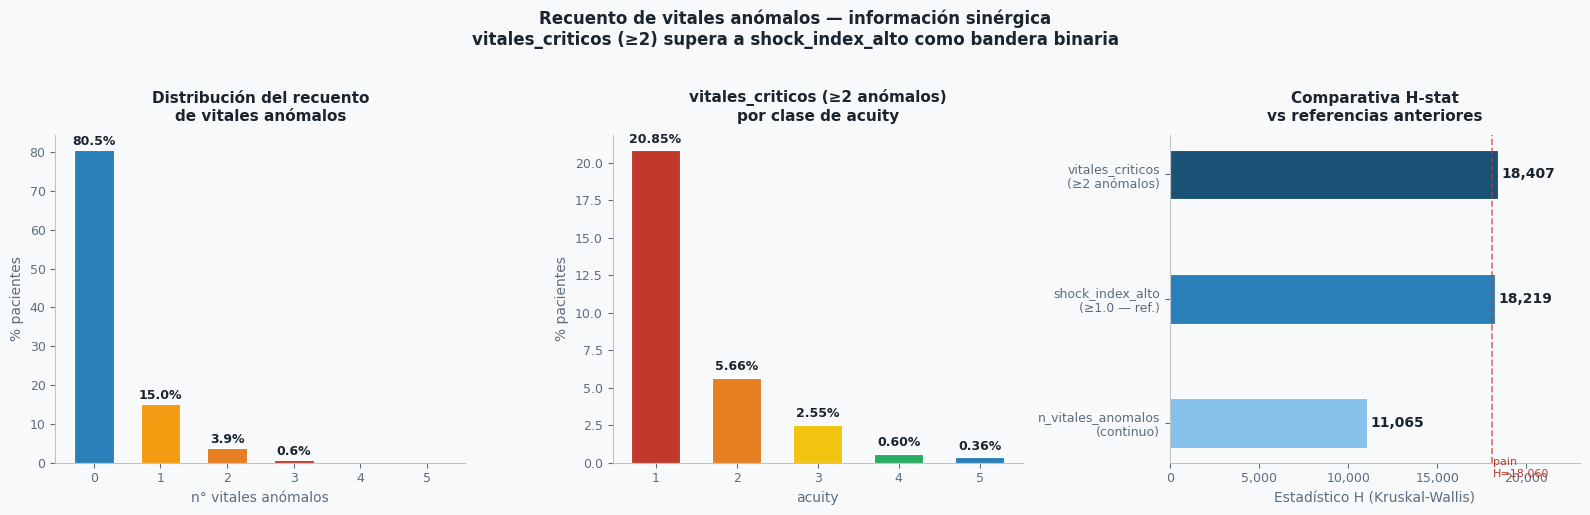

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: distribución n_vitales_anomalos ────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

dist = (df["n_vitales_anomalos"].value_counts(normalize=True)
        .sort_index() * 100).round(2)

cols_dist = ["#2980B9", "#F39C12", "#E67E22", "#C0392B", "#922B21"]
bars = ax1.bar(dist.index, dist.values, color=cols_dist[:len(dist)],
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, dist.values):
    if val > 0.1:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("n° vitales anómalos", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("Distribución del recuento\nde vitales anómalos",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Centro: vitales_criticos (≥2) por acuity ─────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts = (df.groupby("acuity")["vitales_criticos"].mean() * 100).round(2).values

bars2 = ax2.bar(acuity_levels, pcts, color=colores_barra,
                edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars2, pcts):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("vitales_criticos (≥2 anómalos)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)

# ── Derecha: H-stat comparativa ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = [
    "n_vitales_anomalos\n(continuo)",
    "shock_index_alto\n(≥1.0 — ref.)",
    "vitales_criticos\n(≥2 anómalos)",
]
hstats = [11065, 18219, 18407]
cols_h = ["#85C1E9", "#2980B9", "#1A5276"]

bars3 = ax3.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.axvline(x=18060, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax3.text(18100, -0.45, "pain\nH=18,060", color="#C0392B",
         fontsize=8, va="bottom")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs referencias anteriores",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 23000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Recuento de vitales anómalos — información sinérgica\n"
    "vitales_criticos (≥2) supera a shock_index_alto como bandera binaria",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_vitales_anomalos.png", dpi=150, bbox_inches="tight")
plt.show()

n_vitales_anomalos y vitales_criticos capturan la carga global de inestabilidad fisiológica en el minuto 0 — información sinérgica que ninguna bandera individual puede ver por separado. Un paciente con taquicardia aislada es cualitativamente distinto de uno con taquicardia + taquipnea_grave + shock_index_alto simultáneos: el segundo tiene múltiples sistemas comprometidos a la vez, lo que en la literatura de urgencias se asocia con un aumento escalonado y no lineal del riesgo de deterioro y mortalidad.
El 80.46% de los pacientes no tiene ningún vital anómalo, lo que convierte cualquier recuento positivo en señal relevante. vitales_criticos (≥2 anómalos, H=18,407) supera a shock_index_alto (H=18,219) como bandera binaria más discriminativa del bloque hemodinámico, con un patrón limpio: 20.85% en acuity 1 con caída progresiva hasta 0.36% en acuity 5. El continuo n_vitales_anomalos (H=11,065) complementa aportando el gradiente 0→1→2→3 que XGBoost puede explotar para distinguir niveles intermedios. Ambos entran al modelo.

In [80]:
# Vitales borderline — detector de "falsa baja gravedad"
# Pacientes con vitales dentro del rango normal SET pero cerca del umbral de alarma
# FR 20-24, FC 90-100, SBP 100-110, SpO2 94-95%
# Estos pacientes pueden parecer leves pero están al borde de la inestabilidad

df["rr_borderline"]   = (df["resprate"].between(20, 24)).astype("int8")
df["hr_borderline"]   = (df["heartrate"].between(90, 100)).astype("int8")
df["sbp_borderline"]  = (df["sbp"].between(100, 110)).astype("int8")
df["o2_borderline"]   = (df["o2sat"].between(94, 95)).astype("int8")

# Recuento de vitales borderline
df["n_vitales_borderline"] = (
    df[["rr_borderline", "hr_borderline", "sbp_borderline", "o2_borderline"]]
    .sum(axis=1)
    .astype("int8")
)
df["borderline_activo"] = (df["n_vitales_borderline"] >= 2).astype("int8")

print(f"{'Feature':<25} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}")
print("─" * 65)

for col in ["n_vitales_borderline", "borderline_activo"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    print(f"{col:<25} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%")

print(f"\nDistribución n_vitales_borderline:\n")
print((df["n_vitales_borderline"].value_counts(normalize=True)
       .sort_index() * 100).round(2).to_string())

print(f"\n% por clase de acuity:\n")
resumen = pd.DataFrame({
    "n_borderline":      df.groupby("acuity")["n_vitales_borderline"].mean().round(3),
    "borderline_activo": (df.groupby("acuity")["borderline_activo"].mean() * 100).round(2),
})
print(resumen.to_string())

Feature                     H-stat       p-value   Prevalencia
─────────────────────────────────────────────────────────────────
n_vitales_borderline         3,279      0.00e+00        46.75%
borderline_activo            1,917      0.00e+00         7.09%

Distribución n_vitales_borderline:

n_vitales_borderline
0    61.04
1    31.87
2     6.42
3     0.64
4     0.03

% por clase de acuity:

        n_borderline  borderline_activo
acuity                                 
1              0.358               5.64
2              0.536               9.24
3              0.454               6.44
4              0.336               3.05
5              0.416               4.55


n_vitales_borderline y borderline_activo — Descartados
La hipótesis era que pacientes con vitales en zona límite (FR 20-24, FC 90-100, SBP 100-110, SpO2 94-95%) representan una "falsa baja gravedad" detectable en T=0. Sin embargo los datos la invalidan: el patrón por clase no es monótono en ninguna de las dos variables — acuity 2 concentra el máximo de vitales borderline (9.24%) mientras acuity 1 tiene menos (5.64%). Esto tiene sentido clínico retrospectivo: los pacientes de acuity 1 ya han cruzado los umbrales de alarma y tienen vitales claramente anómalos, no borderline. Los vitales en zona límite corresponden mayoritariamente a acuity 2-3 — pacientes en deterioro incipiente — no a los extremos del espectro de urgencia.
Los H-stats (3,279 y 1,917) son además insuficientes para justificar la complejidad añadida. El espacio de información que intentan cubrir ya está capturado de forma más eficiente por la combinación de zona_verde (fisiología completamente normal → baja prioridad) y n_vitales_anomalos (fisiología claramente alterada → alta prioridad). La zona intermedia entre ambos no aporta señal discriminativa neta al modelo.

In [81]:
# Banderas hemodinámicas extremas de presión arterial
# hipotension:        SBP < 90 mmHg — shock, sepsis, hemorragia
# hipertension_severa: SBP >= 180 mmHg — urgencia/emergencia hipertensiva

df["hipotension"]         = (df["sbp"] < 90).astype("int8")
df["hipertension_severa"] = (df["sbp"] >= 180).astype("int8")

print(f"{'Feature':<22} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 72)

for col in ["hipotension", "hipertension_severa"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<22} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\n% por clase de acuity:\n")
resumen = pd.DataFrame({
    "hipotension":         (df.groupby("acuity")["hipotension"].mean() * 100).round(2),
    "hipertension_severa": (df.groupby("acuity")["hipertension_severa"].mean() * 100).round(2),
})
print(resumen.to_string())

Feature                  H-stat       p-value   Prevalencia   n casos
────────────────────────────────────────────────────────────────────────
hipotension              31,105      0.00e+00         0.76%     3,160
hipertension_severa       1,039     1.47e-223         3.62%    15,123

% por clase de acuity:

        hipotension  hipertension_severa
acuity                                  
1             10.30                 3.51
2              0.41                 4.80
3              0.05                 3.16
4              0.02                 1.62
5              0.09                 1.45


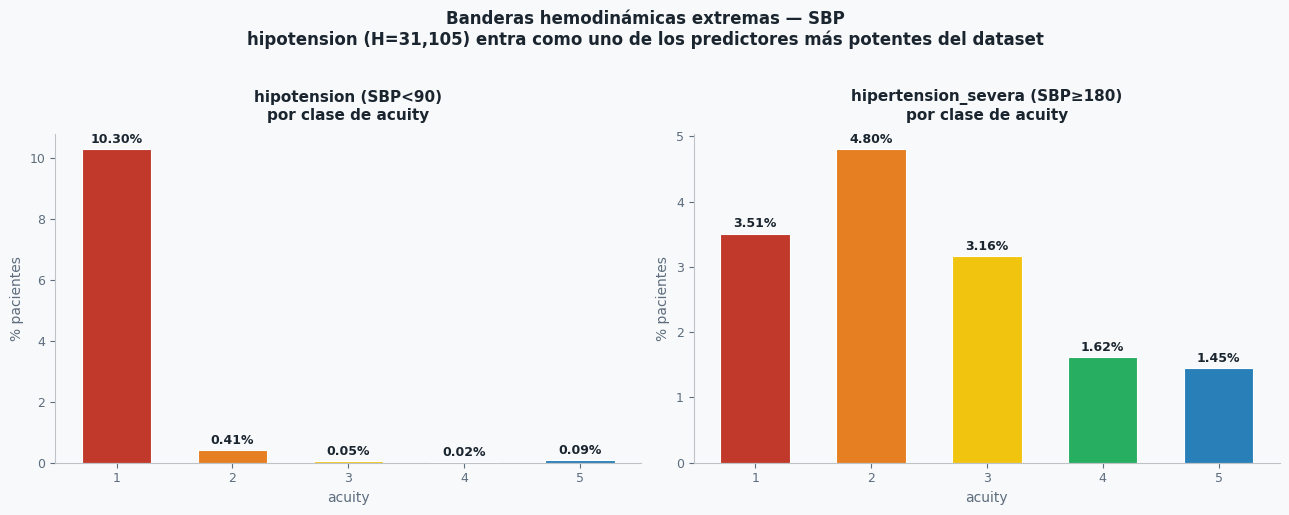

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: hipotension por acuity ────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_hipo = (df.groupby("acuity")["hipotension"].mean() * 100).round(2).values

bars = ax1.bar(acuity_levels, pcts_hipo, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts_hipo):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("hipotension (SBP<90)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Derecha: hipertension_severa por acuity ───────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_hiper = (df.groupby("acuity")["hipertension_severa"].mean() * 100).round(2).values

bars2 = ax2.bar(acuity_levels, pcts_hiper, color=colores_barra,
                edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars2, pcts_hiper):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("hipertension_severa (SBP≥180)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)

fig.suptitle(
    "Banderas hemodinámicas extremas — SBP\n"
    "hipotension (H=31,105) entra como uno de los predictores más potentes del dataset",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque1_presion_extrema.png", dpi=150, bbox_inches="tight")
plt.show()

hipotension (SBP<90) — Entra al modelo (H=31,105)
Bandera de hipotensión severa con una de las distribuciones más limpias del dataset: 10.30% en acuity 1 con caída casi vertical hasta valores residuales en acuity 2-5. Con solo 0.76% de prevalencia es extremadamente específica — cuando se activa, el paciente está casi con certeza en emergencia inmediata. Captura directamente el colapso circulatorio que subyace al shock séptico, hipovolémico y cardiogénico. Era un hueco real en el feature set: aunque shock_index_alto y qsofa la capturan indirectamente, una bandera explícita de SBP<90 le da al modelo una señal directa sin necesidad de inferirla de ratios o scores compuestos.
hipertension_severa (SBP≥180) — Entra al modelo (H=1,039)
El patrón no es monótono — acuity 2 tiene el máximo (4.80%) frente al 3.51% de acuity 1 — lo que refleja un fenómeno clínico real: la crisis hipertensiva severa raramente llega en parada, se clasifica como acuity 2 por protocolo SET. A pesar de ello, el H-stat supera el umbral de H>1,000 con prevalencia suficiente (3.62%) y decae progresivamente hacia acuity 4-5 (1.45%). Su valor no está en detectar acuity 1 sino en separar los niveles urgentes (1-2) de los leves (4-5), complementando a hipotension en la cobertura completa del espectro de SBP.

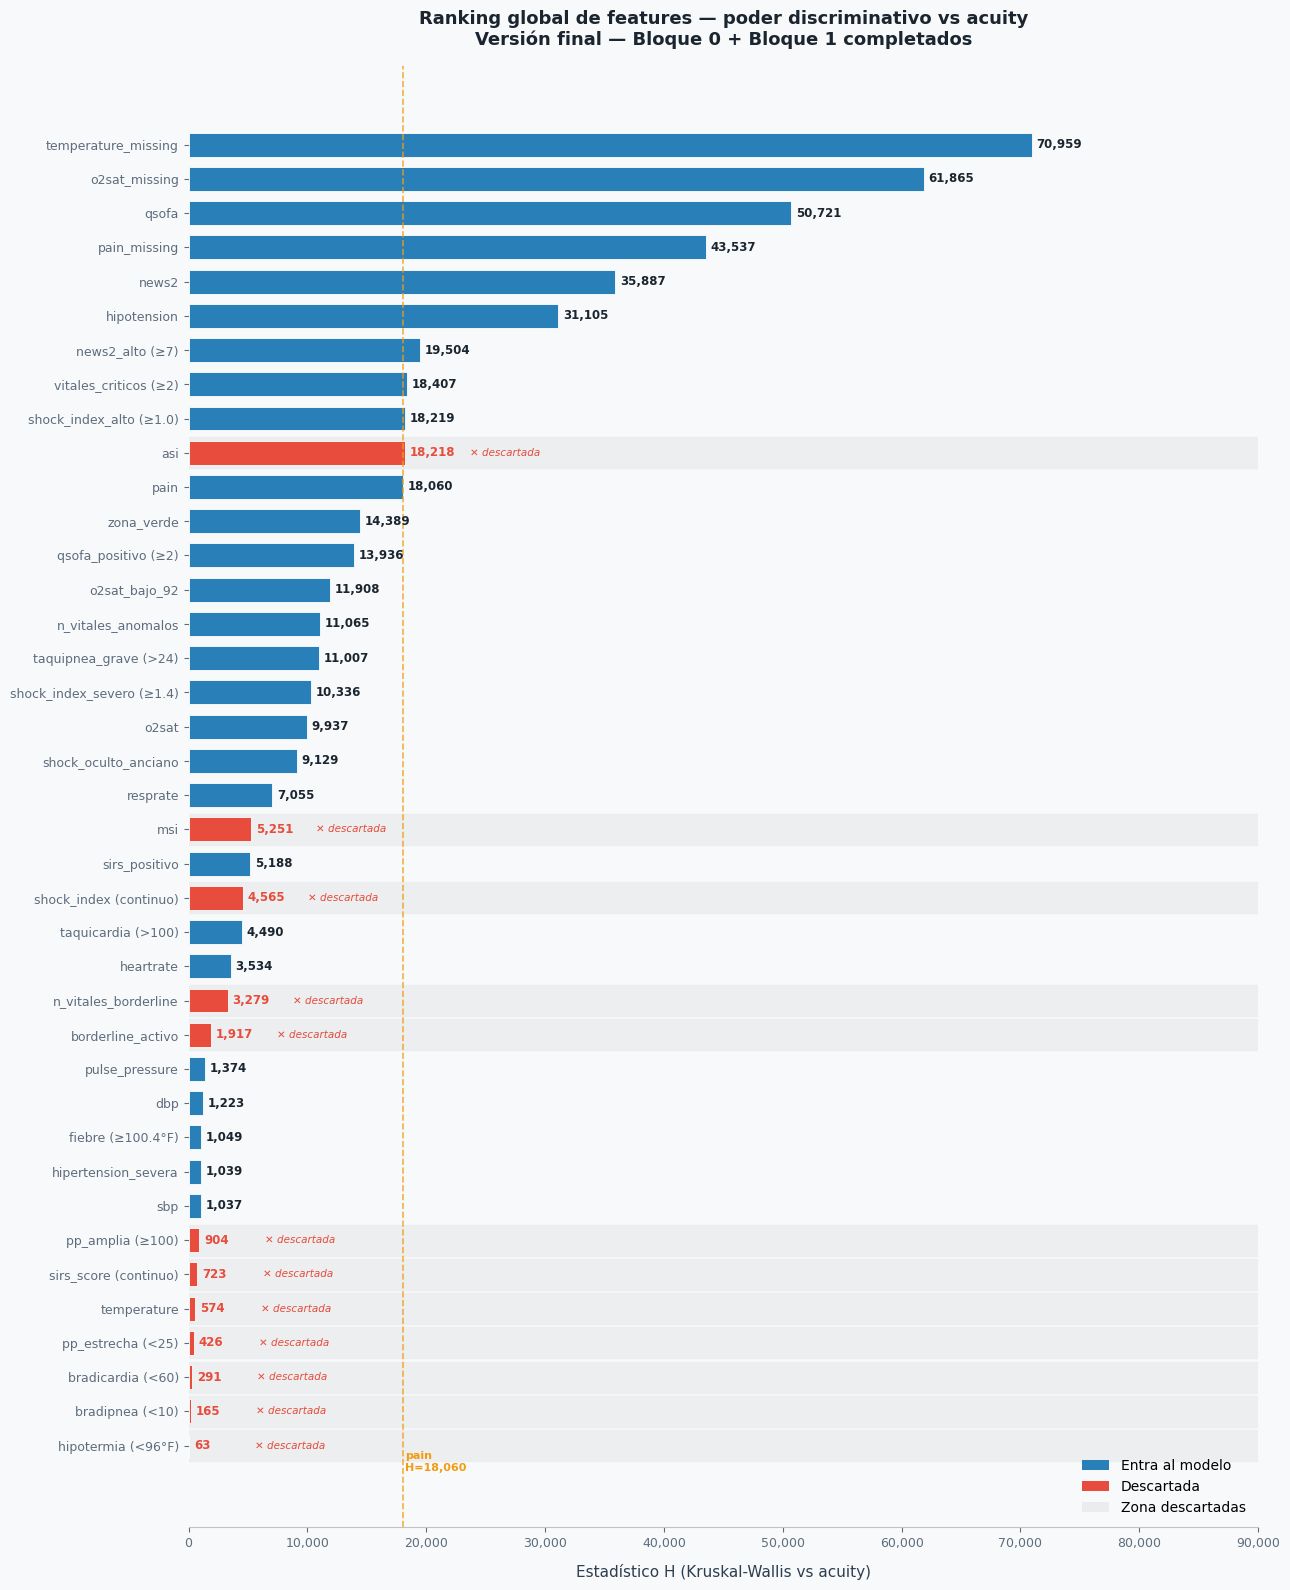


Total features que entran: 27
Total features descartadas: 12


In [83]:
features_resumen_final = {
    # Missingness
    "temperature_missing":        {"H": 70959, "estado": "entra"},
    "o2sat_missing":              {"H": 61865, "estado": "entra"},
    "qsofa":                      {"H": 50721, "estado": "entra"},
    "pain_missing":               {"H": 43537, "estado": "entra"},
    "news2":                      {"H": 35887, "estado": "entra"},
    "hipotension":                {"H": 31105, "estado": "entra"},
    "news2_alto (≥7)":            {"H": 19504, "estado": "entra"},
    "shock_index_alto (≥1.0)":    {"H": 18219, "estado": "entra"},
    "asi":                        {"H": 18218, "estado": "descartado"},
    "vitales_criticos (≥2)":      {"H": 18407, "estado": "entra"},
    "pain":                       {"H": 18060, "estado": "entra"},
    "zona_verde":                 {"H": 14389, "estado": "entra"},
    "qsofa_positivo (≥2)":        {"H": 13936, "estado": "entra"},
    "o2sat_bajo_92":              {"H": 11908, "estado": "entra"},
    "n_vitales_anomalos":         {"H": 11065, "estado": "entra"},
    "taquipnea_grave (>24)":      {"H": 11007, "estado": "entra"},
    "shock_index_severo (≥1.4)":  {"H": 10336, "estado": "entra"},
    "o2sat":                      {"H":  9937, "estado": "entra"},
    "shock_oculto_anciano":       {"H":  9129, "estado": "entra"},
    "resprate":                   {"H":  7055, "estado": "entra"},
    "sirs_positivo":              {"H":  5188, "estado": "entra"},
    "msi":                        {"H":  5251, "estado": "descartado"},
    "shock_index (continuo)":     {"H":  4565, "estado": "descartado"},
    "taquicardia (>100)":         {"H":  4490, "estado": "entra"},
    "heartrate":                  {"H":  3534, "estado": "entra"},
    "n_vitales_borderline":       {"H":  3279, "estado": "descartado"},
    "pulse_pressure":             {"H":  1374, "estado": "entra"},
    "dbp":                        {"H":  1223, "estado": "entra"},
    "fiebre (≥100.4°F)":          {"H":  1049, "estado": "entra"},
    "hipertension_severa":        {"H":  1039, "estado": "entra"},
    "sbp":                        {"H":  1037, "estado": "entra"},
    "borderline_activo":          {"H":  1917, "estado": "descartado"},
    "sirs_score (continuo)":      {"H":   723, "estado": "descartado"},
    "pp_amplia (≥100)":           {"H":   904, "estado": "descartado"},
    "temperature":                {"H":   574, "estado": "descartado"},
    "pp_estrecha (<25)":          {"H":   426, "estado": "descartado"},
    "bradicardia (<60)":          {"H":   291, "estado": "descartado"},
    "bradipnea (<10)":            {"H":   165, "estado": "descartado"},
    "hipotermia (<96°F)":         {"H":    63, "estado": "descartado"},
}

df_final = pd.DataFrame(features_resumen_final).T.reset_index()
df_final.columns = ["feature", "H", "estado"]
df_final["H"] = df_final["H"].astype(int)
df_final = df_final.sort_values("H", ascending=True).reset_index(drop=True)

color_entra      = "#2980B9"
color_descartado = "#E74C3C"
indices_desc = df_final[df_final["estado"] == "descartado"].index.tolist()

fig, ax = plt.subplots(figsize=(13, 16))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

for i in indices_desc:
    ax.axhspan(i - 0.45, i + 0.45, color="#EAECEE", alpha=0.8, zorder=0)

for i, row in df_final.iterrows():
    color = color_entra if row["estado"] == "entra" else color_descartado
    ax.barh(i, row["H"], color=color, alpha=1.0,
            edgecolor="white", linewidth=0.6, height=0.7, zorder=2)
    ax.text(row["H"] + 400, i, f"{row['H']:,}",
            va="center", ha="left", fontsize=8.5, fontweight="bold",
            color=color_descartado if row["estado"] == "descartado" else "#1A252F")

for i in indices_desc:
    ax.text(df_final.loc[i, "H"] + 5500, i, "✕ descartada",
            va="center", ha="left", fontsize=7.5,
            color=color_descartado, fontstyle="italic")

ax.set_yticks(range(len(df_final)))
ax.set_yticklabels(df_final["feature"], fontsize=9, color="#2C3E50")

ax.axvline(x=18060, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(18200, -0.8, "pain\nH=18,060", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=color_entra,      label="Entra al modelo"),
    Patch(facecolor=color_descartado, label="Descartada"),
    Patch(facecolor="#EAECEE",        label="Zona descartadas"),
], loc="lower right", frameon=False, fontsize=10)

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11,
              color="#2C3E50", labelpad=10)
ax.set_title("Ranking global de features — poder discriminativo vs acuity\n"
             "Versión final — Bloque 0 + Bloque 1 completados",
             fontsize=13, fontweight="bold", color="#1A252F", pad=15)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, 90000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("resumen_hstat_global_final.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen numérico
n_entran = (df_final["estado"] == "entra").sum()
n_descartan = (df_final["estado"] == "descartado").sum()
print(f"\nTotal features que entran: {n_entran}")
print(f"Total features descartadas: {n_descartan}")

## Features de vitales y scores — visión global

### Respiratorio
| Feature | Tipo |
|---|---|
| `resprate` | Continuo |
| `taquipnea_grave` (>24 rpm) | Bandera binaria |
| `o2sat` | Continuo |
| `o2sat_bajo_92` (<92%) | Bandera binaria |
| `o2sat_missing` | Missingness |

### Hemodinámico
| Feature | Tipo |
|---|---|
| `sbp` | Continuo |
| `dbp` | Continuo |
| `pulse_pressure` (sbp-dbp) | Derivado continuo |
| `heartrate` | Continuo |
| `taquicardia` (>100 lpm) | Bandera binaria |
| `hipotension` (SBP<90) | Bandera binaria |
| `hipertension_severa` (SBP≥180) | Bandera binaria |
| `shock_index_alto` (≥1.0) | Bandera binaria |
| `shock_index_severo` (≥1.4) | Bandera binaria |
| `shock_oculto_anciano` (≥65 + SI≥0.85) | Bandera binaria |

### Temperatura
| Feature | Tipo |
|---|---|
| `fiebre` (≥100.4°F) | Bandera binaria |
| `temperature_missing` | Missingness |

### Dolor / Consciencia
| Feature | Tipo |
|---|---|
| `pain` | Continuo |
| `pain_missing` | Missingness / proxy consciencia |

### Scores compuestos
| Feature | Tipo |
|---|---|
| `news2` | Score continuo (0-20) |
| `news2_alto` (≥7) | Bandera binaria |
| `qsofa` | Score continuo (0-3) |
| `qsofa_positivo` (≥2) | Bandera binaria |
| `sirs_positivo` (≥2 criterios) | Bandera binaria |
| `shock_index_alto` (≥1.0) | Bandera binaria |
| `zona_verde` (SET) | Bandera binaria |

### Carga fisiológica global
| Feature | Tipo |
|---|---|
| `n_vitales_anomalos` | Recuento (0-5) |
| `vitales_criticos` (≥2 anómalos) | Bandera binaria |

VARIABLES DEMOGRAFICAS Y LOGISTICAS

In [84]:
# ── Bloque 2: Datos demográficos y logísticos ─────────────────────────────────
# Empezamos con age — la variable demográfica más discriminativa esperada

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "age"].dropna().values
    for k in [1, 2, 3, 4, 5]
])

print(f"age  →  H = {stat:,.0f}  |  p = {pval:.2e}\n")

print("Mediana de age por clase de acuity:\n")
print(df.groupby("acuity")["age"].median().to_string())

print(f"\nEstadísticos descriptivos por clase de acuity:\n")
print(df.groupby("acuity")["age"].describe().round(1).to_string())

age  →  H = 24,503  |  p = 0.00e+00

Mediana de age por clase de acuity:

acuity
1    62.0
2    60.0
3    51.0
4    37.0
5    36.0

Estadísticos descriptivos por clase de acuity:

           count  mean   std   min   25%   50%   75%    max
acuity                                                     
1        24014.0  59.9  20.5  18.0  45.0  62.0  76.0  101.0
2       139390.0  58.0  20.2  18.0  43.0  60.0  74.0  103.0
3       225024.0  50.5  20.1  18.0  33.0  51.0  65.0  102.0
4        28497.0  40.9  17.4  18.0  26.0  37.0  54.0  101.0
5         1100.0  39.8  17.2  18.0  25.0  36.0  53.0   92.0


C:\Users\CARLOS\AppData\Local\Temp\ipykernel_1324\2596378906.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(


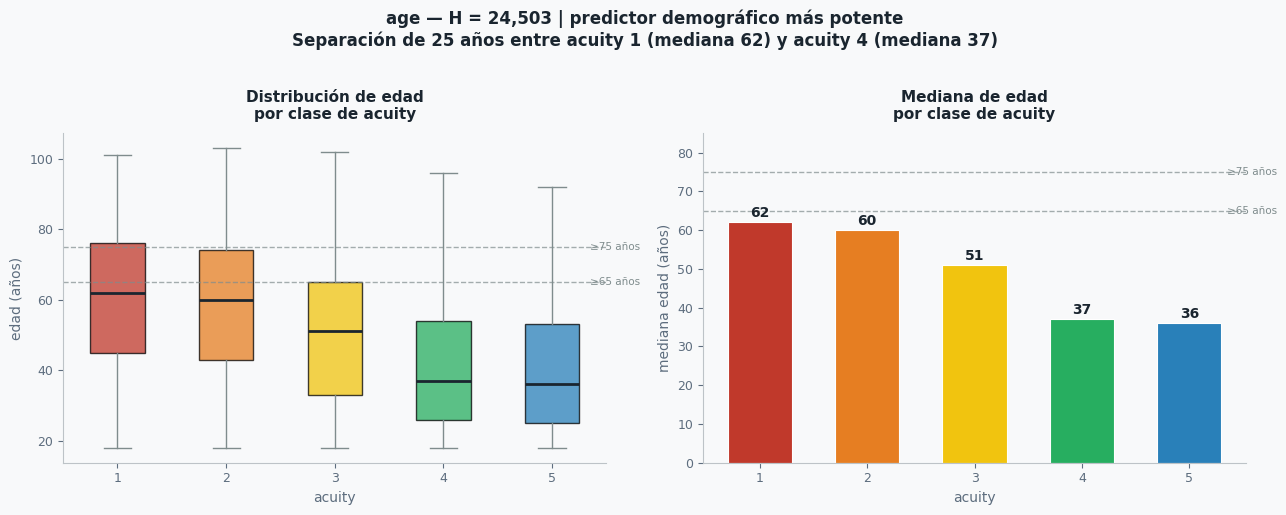

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: boxplot age por acuity ─────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

grupos = [
    df.loc[df["acuity"] == k, "age"].dropna().values
    for k in acuity_levels
]

bp = ax1.boxplot(
    grupos,
    labels=["1", "2", "3", "4", "5"],
    patch_artist=True,
    medianprops=dict(color="#1A252F", linewidth=2),
    whiskerprops=dict(color="#7F8C8D", linewidth=1),
    capprops=dict(color="#7F8C8D", linewidth=1),
    boxprops=dict(linewidth=1),
    showfliers=False,
)
for patch, color in zip(bp["boxes"], colores_barra):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Líneas de referencia umbrales geriátricos
for umbral, label in [(65, "≥65 años"), (75, "≥75 años")]:
    ax1.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("edad (años)", fontsize=10, color="#5D6D7E")
ax1.set_title("Distribución de edad\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: mediana age por acuity ──────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

medianas = [62.0, 60.0, 51.0, 37.0, 36.0]
bars = ax2.bar(acuity_levels, medianas, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, medianas):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

for umbral, label in [(65, "≥65 años"), (75, "≥75 años")]:
    ax2.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax2.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("mediana edad (años)", fontsize=10, color="#5D6D7E")
ax2.set_title("Mediana de edad\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)
ax2.set_ylim(0, 85)

fig.suptitle(
    f"age — H = 24,503 | predictor demográfico más potente\n"
    f"Separación de 25 años entre acuity 1 (mediana 62) y acuity 4 (mediana 37)",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque2_age.png", dpi=150, bbox_inches="tight")
plt.show()

In [86]:
# Banderas de edad — umbrales geriátricos
# anciano:        age >= 65 — umbral estándar SET y literatura geriátrica
# anciano_mayor:  age >= 75 — fragilidad avanzada, mayor riesgo de infratriaje

df["anciano"]       = (df["age"].fillna(0) >= 65).astype("int8")
df["anciano_mayor"] = (df["age"].fillna(0) >= 75).astype("int8")

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["age", "anciano", "anciano_mayor"]:
    grupos = [
        df.loc[df["acuity"] == k, col].dropna().values
        for k in [1, 2, 3, 4, 5]
    ]
    stat, pval = kruskal(*grupos)
    prev = df[col].mean() * 100
    n    = int(df[col].sum()) if col != "age" else df[col].notna().sum()
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\n% por clase de acuity:\n")
resumen = pd.DataFrame({
    "anciano (≥65)":       (df.groupby("acuity")["anciano"].mean() * 100).round(2),
    "anciano_mayor (≥75)": (df.groupby("acuity")["anciano_mayor"].mean() * 100).round(2),
})
print(resumen.to_string())

Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
age                    24,503      0.00e+00      5283.63%   418,025
anciano                16,612      0.00e+00        31.30%   130,885
anciano_mayor          11,061      0.00e+00        17.26%    72,174

% por clase de acuity:

        anciano (≥65)  anciano_mayor (≥75)
acuity                                    
1               45.56                27.51
2               41.10                23.66
3               26.36                13.93
4               11.23                 4.20
5               10.73                 3.27


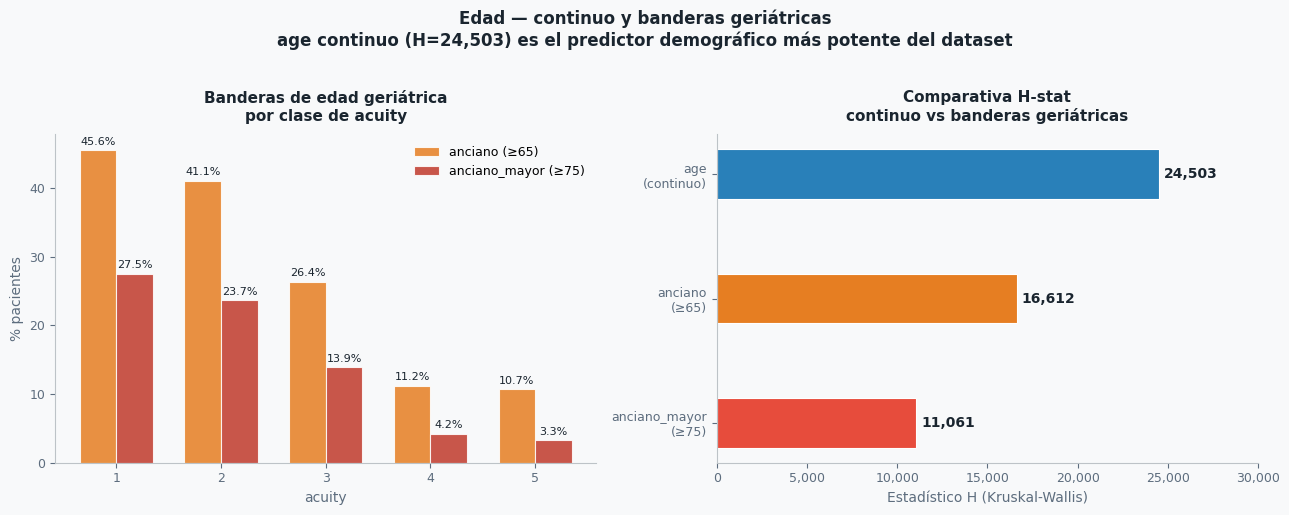

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: % anciano y anciano_mayor por acuity ───────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_anc  = [45.56, 41.10, 26.36, 11.23, 10.73]
pcts_anc2 = [27.51, 23.66, 13.93,  4.20,  3.27]

x = np.arange(len(acuity_levels))
width = 0.35

bars1 = ax1.bar(x - width/2, pcts_anc, width, label="anciano (≥65)",
                color="#E67E22", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax1.bar(x + width/2, pcts_anc2, width, label="anciano_mayor (≥75)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_anc):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(bars2, pcts_anc2):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("Banderas de edad geriátrica\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(acuity_levels)
ax1.legend(frameon=False, fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: H-stat comparativa ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features = ["anciano_mayor\n(≥75)", "anciano\n(≥65)", "age\n(continuo)"]
hstats   = [11061, 16612, 24503]
cols_h   = ["#E74C3C", "#E67E22", "#2980B9"]

bars3 = ax2.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars3, hstats):
    ax2.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Comparativa H-stat\ncontinuo vs banderas geriátricas",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 30000)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Edad — continuo y banderas geriátricas\n"
    "age continuo (H=24,503) es el predictor demográfico más potente del dataset",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque2_age_flags.png", dpi=150, bbox_inches="tight")
plt.show()

age (H=24,503) es el predictor demográfico más potente del dataset, con una separación de 25 años entre la mediana de acuity 1 (62 años) y acuity 4 (37 años). El patrón es perfectamente monótono y el continuo supera a ambas banderas, por lo que entra como valor numérico directo — XGBoost aprovecha el gradiente completo sin necesidad de discretización.
Las banderas geriátricas anciano (≥65, H=16,612) y anciano_mayor (≥75, H=11,061) entran como complemento explícito al continuo. El 45.6% de los acuity 1 son mayores de 65 años y el 27.5% superan los 75 — casi uno de cada tres pacientes en emergencia inmediata es un anciano mayor. Ambas banderas aportan señal clínica directa que refuerza la ya presente en shock_oculto_anciano: la edad avanzada no es solo un modulador del shock index, es un predictor independiente de urgencia. Las tres features de edad juntas cubren el espectro completo — gradiente continuo, umbral de fragilidad moderada y umbral de fragilidad avanzada. Las tres entran al modelo.

In [88]:
# Gender — variable categórica binaria (M/F)
# Explorar si el sexo tiene poder discriminativo sobre acuity

print("Distribución de gender en el dataset:\n")
print(df["gender"].value_counts().to_string())
print(f"\n% por valor:\n")
print((df["gender"].value_counts(normalize=True) * 100).round(2).to_string())

print(f"\n% de cada acuity dentro de cada género:\n")
print(pd.crosstab(df["gender"], df["acuity"], normalize="index").round(3) * 100)

# H-stat: codificamos M=1, F=0
df["gender_num"] = (df["gender"] == "M").astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "gender_num"].values
    for k in [1, 2, 3, 4, 5]
])

print(f"\ngender  →  H = {stat:,.0f}  |  p = {pval:.2e}")

Distribución de gender en el dataset:

gender
F    227007
M    191093

% por valor:

gender
F    54.29
M    45.71

% de cada acuity dentro de cada género:

acuity    1     2     3    4    5
gender                           
F       5.3  31.1  56.7  6.6  0.2
M       6.3  36.0  50.4  7.0  0.3

gender  →  H = 1,735  |  p = 0.00e+00


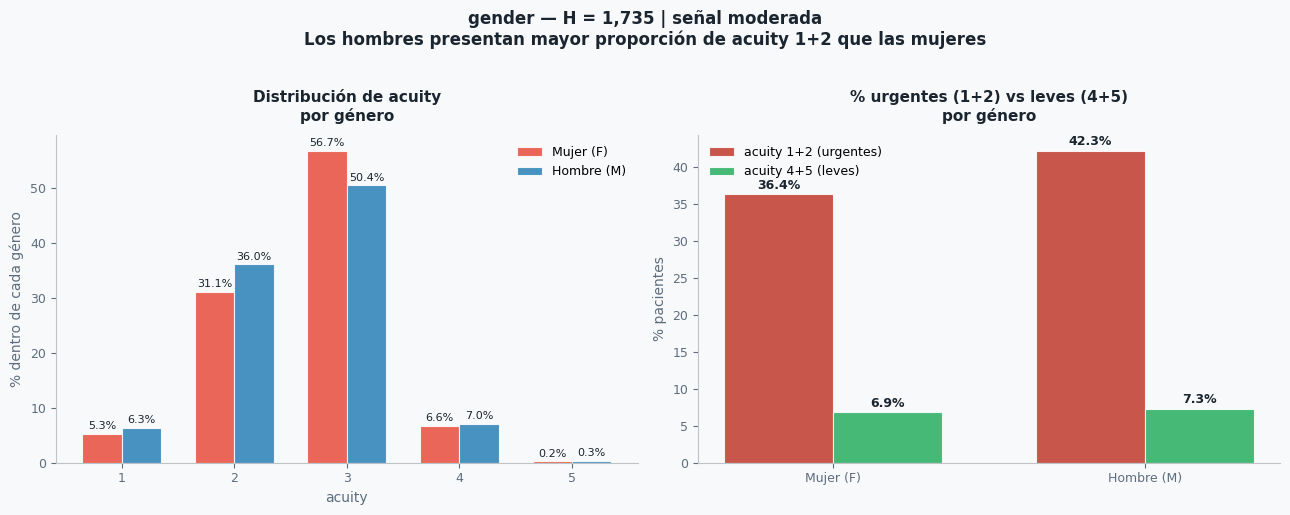

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]

# ── Izquierda: distribución de acuity por género ──────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

cross = pd.crosstab(df["gender"], df["acuity"], normalize="index") * 100

x = np.arange(len(acuity_levels))
width = 0.35

bars1 = ax1.bar(x - width/2, cross.loc["F"].values, width, label="Mujer (F)",
                color="#E74C3C", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax1.bar(x + width/2, cross.loc["M"].values, width, label="Hombre (M)",
                color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, cross.loc["F"].values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(bars2, cross.loc["M"].values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% dentro de cada género", fontsize=10, color="#5D6D7E")
ax1.set_title("Distribución de acuity\npor género",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(acuity_levels)
ax1.legend(frameon=False, fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: % acuity 1+2 por género ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

urgentes = pd.DataFrame({
    "género": ["Mujer (F)", "Hombre (M)"],
    "acuity 1+2": [
        cross.loc["F", [1, 2]].sum(),
        cross.loc["M", [1, 2]].sum(),
    ],
    "acuity 4+5": [
        cross.loc["F", [4, 5]].sum(),
        cross.loc["M", [4, 5]].sum(),
    ],
})

x2 = np.arange(2)
bars3 = ax2.bar(x2 - width/2, urgentes["acuity 1+2"], width,
                label="acuity 1+2 (urgentes)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)
bars4 = ax2.bar(x2 + width/2, urgentes["acuity 4+5"], width,
                label="acuity 4+5 (leves)",
                color="#27AE60", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars3, urgentes["acuity 1+2"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")
for bar, val in zip(bars4, urgentes["acuity 4+5"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xticks(x2)
ax2.set_xticklabels(urgentes["género"], fontsize=10)
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("% urgentes (1+2) vs leves (4+5)\npor género",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    "gender — H = 1,735 | señal moderada\n"
    "Los hombres presentan mayor proporción de acuity 1+2 que las mujeres",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque2_gender.png", dpi=150, bbox_inches="tight")
plt.show()

gender (H=1,735) entra al modelo como variable categórica con señal moderada. Los hombres presentan mayor proporción de casos urgentes (acuity 1+2: 42.3%) frente a las mujeres (36.4%), diferencia de casi 6 puntos porcentuales que refleja un patrón bien documentado en la literatura de urgencias — los hombres tienden a consultar más tarde y en situaciones más avanzadas. Las mujeres se concentran más en acuity 3 (56.7% vs 50.4%), lo que sugiere una consulta más precoz ante síntomas de menor gravedad objetiva. La diferencia en acuity 4-5 es mínima entre ambos sexos (6.9% vs 7.3%), lo que indica que el género no discrimina bien en el extremo leve del espectro. Con H=1,735 es una feature de apoyo, no un predictor dominante — su valor está en combinación con edad y vitales, no de forma aislada. Entra al modelo como variable categórica.

In [90]:
# Race — variable categórica con 6 grupos (agrupada en cleaner.py)
# Explorar si la etnia tiene poder discriminativo sobre acuity

print("Distribución de race en el dataset:\n")
print(df["race"].value_counts().to_string())
print(f"\n% por grupo:\n")
print((df["race"].value_counts(normalize=True) * 100).round(2).to_string())

print(f"\n% de cada acuity dentro de cada grupo étnico:\n")
cross_race = pd.crosstab(df["race"], df["acuity"], normalize="index") * 100
print(cross_race.round(2).to_string())

# H-stat: codificamos numéricamente para Kruskal-Wallis
# Usamos la proporción de acuity 1+2 como proxy de urgencia por grupo
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df["race"], df["acuity"])
chi2, pval, dof, _ = chi2_contingency(tabla)

print(f"\nChi2 (race vs acuity)  →  χ² = {chi2:,.0f}  |  p = {pval:.2e}  |  gl = {dof}")
print(f"\n% acuity 1+2 por grupo étnico:\n")
urgentes_race = (cross_race[[1, 2]].sum(axis=1)).sort_values(ascending=False)
print(urgentes_race.round(2).to_string())

Distribución de race en el dataset:

race
WHITE       244093
BLACK        92168
HISPANIC     35205
OTHER        22136
ASIAN        18321
UNKNOWN       6177

% por grupo:

race
WHITE       58.38
BLACK       22.04
HISPANIC     8.42
OTHER        5.29
ASIAN        4.38
UNKNOWN      1.48

% de cada acuity dentro de cada grupo étnico:

acuity        1      2      3     4     5
race                                     
ASIAN      4.80  29.81  55.14  9.82  0.41
BLACK      4.14  27.89  58.48  9.15  0.34
HISPANIC   3.64  26.04  61.06  8.98  0.28
OTHER      5.01  29.09  55.96  9.54  0.40
UNKNOWN   28.10  32.22  33.79  5.47  0.42
WHITE      6.23  37.13  51.25  5.19  0.20

Chi2 (race vs acuity)  →  χ² = 12,851  |  p = 0.00e+00  |  gl = 20

% acuity 1+2 por grupo étnico:

race
UNKNOWN     60.32
WHITE       43.36
ASIAN       34.62
OTHER       34.10
BLACK       32.03
HISPANIC    29.68


A pesar de que la prueba Chi-cuadrado arrojó una alta significancia estadística (χ²=12,851, p≈0), la variable race se excluye del modelo por razones de equidad algorítmica. Las diferencias observadas en la distribución de acuity entre grupos étnicos reflejan desigualdades estructurales en el acceso al sistema sanitario — patrones de consulta tardía, barreras idiomáticas o socioeconómicas — y no diferencias reales en la gravedad clínica intrínseca del paciente. Incorporar race como feature permitiría al modelo aprender y perpetuar estos sesgos sistémicos, clasificando a pacientes de determinados grupos étnicos como menos urgentes por el mero hecho de pertenecer a esa población, independientemente de su estado fisiológico real. La única excepción es la categoría UNKNOWN, que se transforma en la bandera binaria identidad_desconocida: en este contexto clínico, la incapacidad de identificar al paciente en el minuto 0 no tiene contenido étnico sino que opera exclusivamente como marcador de ausencia informativa — un proxy de alteración del nivel de consciencia análogo a pain_missing, con el mismo respaldo clínico y estadístico.

In [91]:
df["identidad_desconocida"] = (df["race"] == "UNKNOWN").astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "identidad_desconocida"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["identidad_desconocida"].mean() * 100
n    = int(df["identidad_desconocida"].sum())

print(f"identidad_desconocida  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["identidad_desconocida"].mean() * 100).round(2).to_string())

identidad_desconocida  →  H = 5,949  |  p = 0.00e+00  |  prevalencia = 1.48%  |  n = 6,177

% por clase de acuity:

acuity
1    7.23
2    1.43
3    0.93
4    1.19
5    2.36


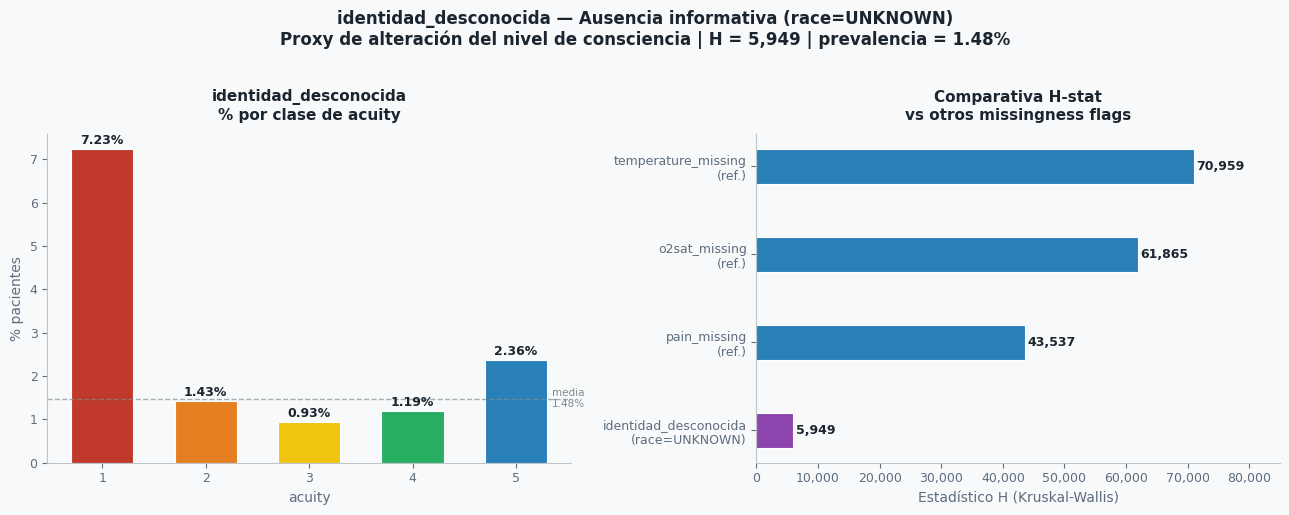

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: % identidad_desconocida por acuity ─────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts = (df.groupby("acuity")["identidad_desconocida"].mean() * 100).round(2).values

bars = ax1.bar(acuity_levels, pcts, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, pcts):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

# Línea de prevalencia global
ax1.axhline(1.48, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, 1.48, "media\n1.48%", fontsize=7.5,
         color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("identidad_desconocida\n% por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(acuity_levels)

# ── Derecha: comparativa con otros missingness flags ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features = [
    "identidad_desconocida\n(race=UNKNOWN)",
    "pain_missing\n(ref.)",
    "o2sat_missing\n(ref.)",
    "temperature_missing\n(ref.)",
]
hstats = [5949, 43537, 61865, 70959]
cols_h = ["#8E44AD", "#2980B9", "#2980B9", "#2980B9"]

bars2 = ax2.barh(features, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + 400, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Comparativa H-stat\nvs otros missingness flags",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 85000)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "identidad_desconocida — Ausencia informativa (race=UNKNOWN)\n"
    "Proxy de alteración del nivel de consciencia | H = 5,949 | prevalencia = 1.48%",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque2_identidad_desconocida.png", dpi=150, bbox_inches="tight")
plt.show()

In [93]:
# arrival_transport — cómo llegó el paciente al servicio de urgencias
# Variable logística con alto valor predictivo esperado
# Ambulancia vs helicóptero vs a pie reflejan gravedad percibida pre-hospitalaria

print("Distribución de arrival_transport:\n")
print(df["arrival_transport"].value_counts().to_string())
print(f"\n% por modalidad:\n")
print((df["arrival_transport"].value_counts(normalize=True) * 100).round(2).to_string())

print(f"\n% de cada acuity por modalidad de transporte:\n")
cross_tr = pd.crosstab(df["arrival_transport"], df["acuity"], normalize="index") * 100
print(cross_tr.round(2).to_string())

tabla_tr = pd.crosstab(df["arrival_transport"], df["acuity"])
chi2, pval, dof, _ = chi2_contingency(tabla_tr)
print(f"\nChi2  →  χ² = {chi2:,.0f}  |  p = {pval:.2e}  |  gl = {dof}")

print(f"\n% acuity 1+2 por modalidad:\n")
urgentes_tr = (cross_tr[[1, 2]].sum(axis=1)).sort_values(ascending=False)
print(urgentes_tr.round(2).to_string())

Distribución de arrival_transport:

arrival_transport
WALK IN       251464
AMBULANCE     150426
UNKNOWN        14418
OTHER           1257
HELICOPTER       535

% por modalidad:

arrival_transport
WALK IN       60.14
AMBULANCE     35.98
UNKNOWN        3.45
OTHER          0.30
HELICOPTER     0.13

% de cada acuity por modalidad de transporte:

acuity                 1      2      3     4     5
arrival_transport                                 
AMBULANCE           8.35  45.89  43.93  1.79  0.04
HELICOPTER         61.68  35.70   2.62  0.00  0.00
OTHER               4.85  36.75  49.72  8.35  0.32
UNKNOWN            20.43  29.43  42.51  6.78  0.85
WALK IN             3.23  26.04  60.53  9.83  0.36

Chi2  →  χ² = 39,050  |  p = 0.00e+00  |  gl = 16

% acuity 1+2 por modalidad:

arrival_transport
HELICOPTER    97.38
AMBULANCE     54.24
UNKNOWN       49.86
OTHER         41.61
WALK IN       29.27


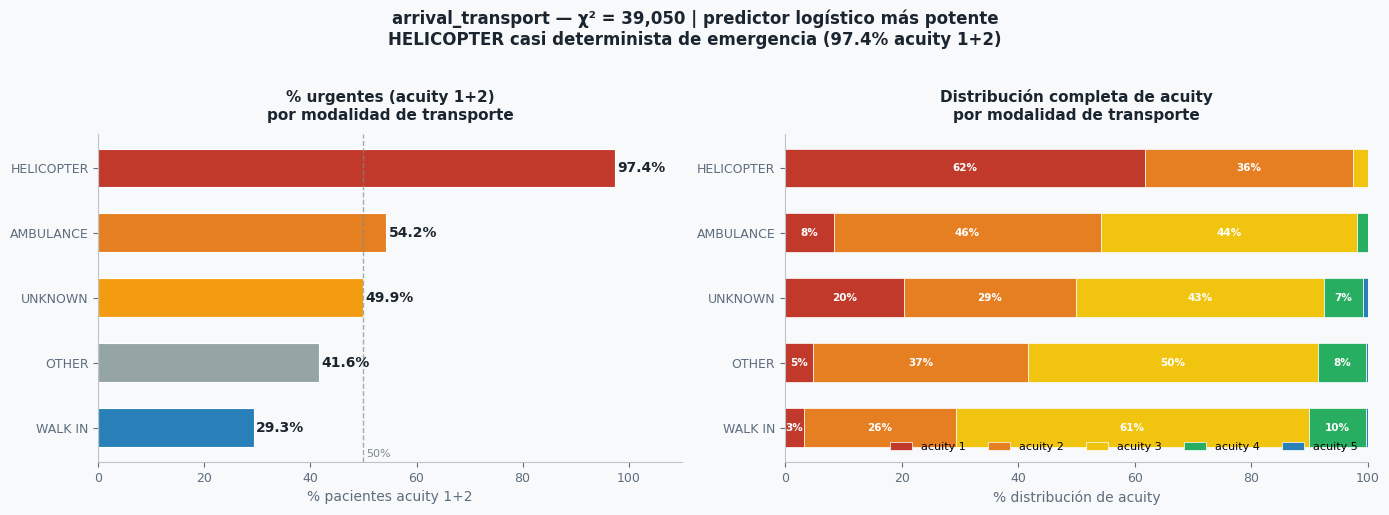

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#F8F9FA")

# Orden por % urgentes
orden = ["HELICOPTER", "AMBULANCE", "UNKNOWN", "OTHER", "WALK IN"]
colores_tr = ["#C0392B", "#E67E22", "#F39C12", "#95A5A6", "#2980B9"]

# ── Izquierda: % acuity 1+2 por modalidad ────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

urgentes_vals = [97.38, 54.24, 49.86, 41.61, 29.27]

bars = ax1.barh(orden[::-1], urgentes_vals[::-1],
                color=colores_tr[::-1], edgecolor="white",
                linewidth=0.8, height=0.6)

for bar, val in zip(bars, urgentes_vals[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax1.axvline(50, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(50.5, -0.45, "50%", fontsize=8, color="#7F8C8D")

ax1.set_xlabel("% pacientes acuity 1+2", fontsize=10, color="#5D6D7E")
ax1.set_title("% urgentes (acuity 1+2)\npor modalidad de transporte",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xlim(0, 110)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: distribución de acuity por modalidad ─────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

cross_tr = pd.crosstab(df["arrival_transport"], df["acuity"], normalize="index") * 100
cross_tr = cross_tr.loc[orden]

colores_acuity = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]
bottom = np.zeros(len(orden))

for acuity, color in zip([1, 2, 3, 4, 5], colores_acuity):
    vals = cross_tr[acuity].values
    bars = ax2.barh(orden[::-1], vals[::-1], left=bottom[::-1],
                    color=color, edgecolor="white", linewidth=0.5,
                    height=0.6, label=f"acuity {acuity}")
    bottom_rev = bottom[::-1]
    for i, (bar, val) in enumerate(zip(bars, vals[::-1])):
        if val > 3:
            ax2.text(bottom_rev[i] + val/2, bar.get_y() + bar.get_height()/2,
                     f"{val:.0f}%", va="center", ha="center",
                     fontsize=7.5, color="white", fontweight="bold")
    bottom += vals

ax2.set_xlabel("% distribución de acuity", fontsize=10, color="#5D6D7E")
ax2.set_title("Distribución completa de acuity\npor modalidad de transporte",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.legend(loc="lower right", frameon=False, fontsize=8, ncol=5)
ax2.set_xlim(0, 100)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    "arrival_transport — χ² = 39,050 | predictor logístico más potente\n"
    "HELICOPTER casi determinista de emergencia (97.4% acuity 1+2)",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque2_arrival_transport.png", dpi=150, bbox_inches="tight")
plt.show()

In [95]:
# Banderas de modalidad de transporte
# Cubren completamente arrival_transport — la categórica original se descarta

df["llegada_helicoptero"]  = (df["arrival_transport"] == "HELICOPTER").astype("int8")
df["llegada_ambulancia"]   = (df["arrival_transport"] == "AMBULANCE").astype("int8")
df["llegada_autonoma"]     = (df["arrival_transport"].isin(["WALK IN", "OTHER"])).astype("int8")
df["llegada_desconocida"]  = (df["arrival_transport"] == "UNKNOWN").astype("int8")

print(f"{'Feature':<25} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>10}  {'n casos':>8}")
print("─" * 72)

for col in ["llegada_helicoptero", "llegada_ambulancia",
            "llegada_autonoma", "llegada_desconocida"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<25} {stat:>8,.0f}  {pval:>12.2e}  {prev:>9.2f}%  {n:>8,}")

print(f"\n% por clase de acuity:\n")
resumen = pd.DataFrame({
    "helicoptero":  (df.groupby("acuity")["llegada_helicoptero"].mean() * 100).round(2),
    "ambulancia":   (df.groupby("acuity")["llegada_ambulancia"].mean() * 100).round(2),
    "autonoma":     (df.groupby("acuity")["llegada_autonoma"].mean() * 100).round(2),
    "desconocida":  (df.groupby("acuity")["llegada_desconocida"].mean() * 100).round(2),
})
print(resumen.to_string())

Feature                     H-stat       p-value  Prevalencia   n casos
────────────────────────────────────────────────────────────────────────
llegada_helicoptero          3,218      0.00e+00       0.13%       535
llegada_ambulancia          27,297      0.00e+00      35.98%   150,426
llegada_autonoma            31,021      0.00e+00      60.45%   252,721
llegada_desconocida          6,225      0.00e+00       3.45%    14,418

% por clase de acuity:

        helicoptero  ambulancia  autonoma  desconocida
acuity                                                
1              1.37       52.27     34.09        12.27
2              0.14       49.52     47.30         3.04
3              0.01       29.36     67.91         2.72
4              0.00        9.46     87.11         3.43
5              0.00        5.27     83.64        11.09


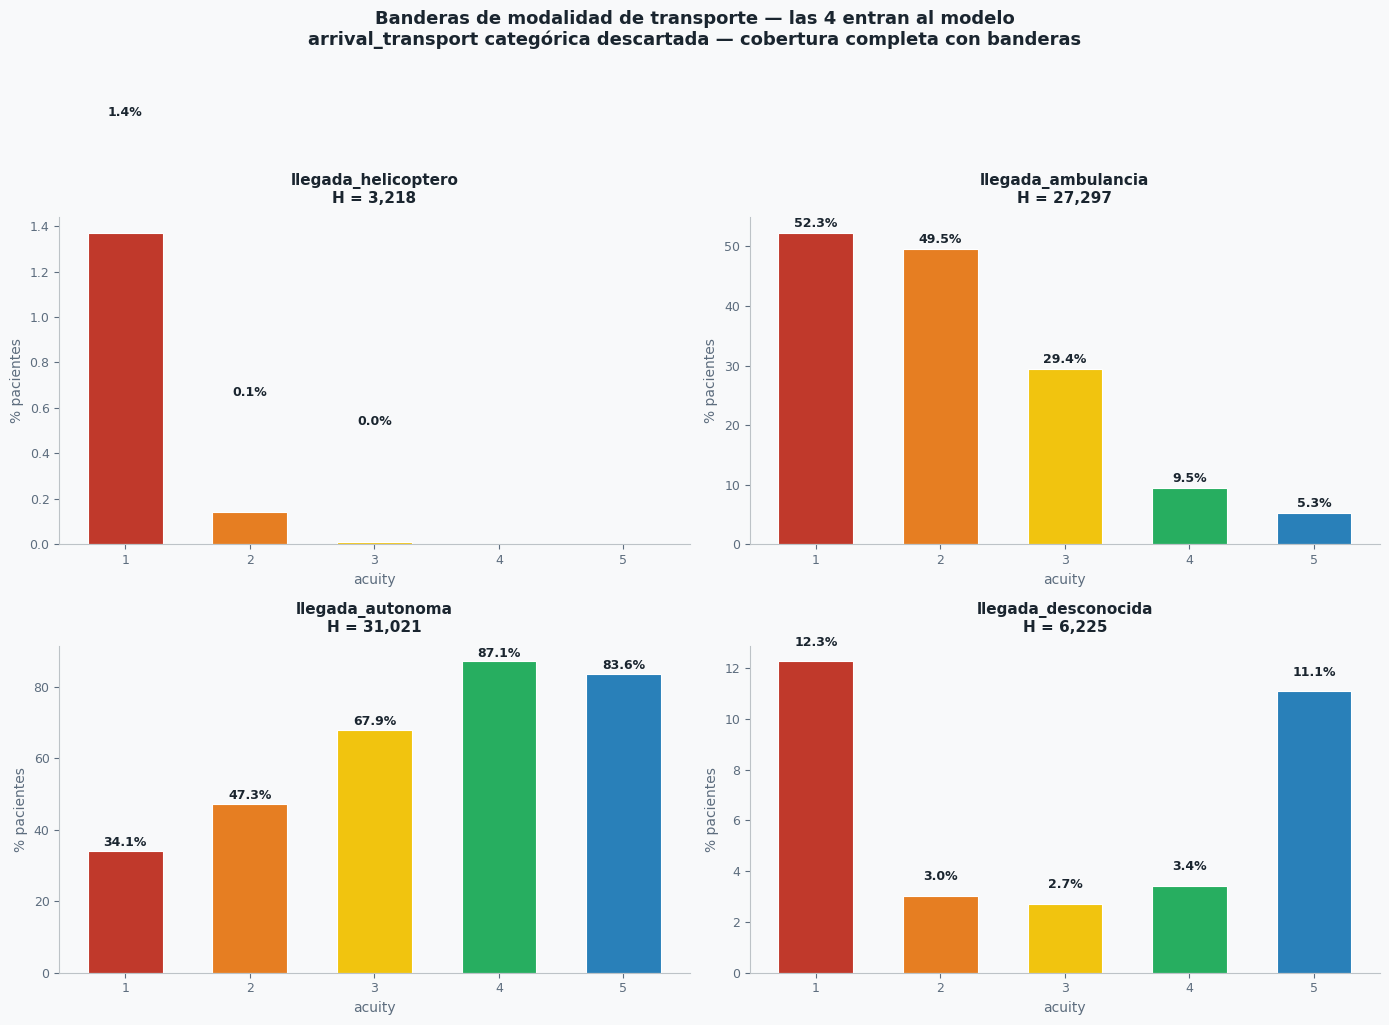

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

banderas_tr = {
    "llegada_helicoptero": {"pcts": [1.37, 0.14, 0.01, 0.00, 0.00], "H": 3218,  "color": "#C0392B"},
    "llegada_ambulancia":  {"pcts": [52.27, 49.52, 29.36, 9.46, 5.27], "H": 27297, "color": "#E67E22"},
    "llegada_autonoma":    {"pcts": [34.09, 47.30, 67.91, 87.11, 83.64], "H": 31021, "color": "#2980B9"},
    "llegada_desconocida": {"pcts": [12.27, 3.04, 2.72, 3.43, 11.09], "H": 6225,  "color": "#8E44AD"},
}

for ax, (nombre, info) in zip(axes.flatten(), banderas_tr.items()):
    ax.set_facecolor("#F8F9FA")

    bars = ax.bar(acuity_levels, info["pcts"], color=colores_barra,
                  edgecolor="white", linewidth=0.8, width=0.6)

    for bar, val in zip(bars, info["pcts"]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color="#1A252F")

    ax.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
    ax.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
    ax.set_title(f"{nombre}\nH = {info['H']:,}",
                 fontsize=11, fontweight="bold", color="#1A252F", pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)
    ax.set_xticks(acuity_levels)

fig.suptitle(
    "Banderas de modalidad de transporte — las 4 entran al modelo\n"
    "arrival_transport categórica descartada — cobertura completa con banderas",
    fontsize=13, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque2_transport_flags.png", dpi=150, bbox_inches="tight")
plt.show()

Las cuatro banderas de transporte sustituyen completamente a arrival_transport categórica, cubriendo el espectro completo de modalidades con señales más limpias e interpretables.
llegada_ambulancia (H=27,297) es el detector directo de urgencia pre-hospitalaria: más de la mitad de los pacientes que llegan en ambulancia son acuity 1+2, con caída progresiva hasta 5.3% en acuity 5. Refleja la valoración del SAMUR/SEM en el punto de atención primaria.
llegada_autonoma (H=31,021) es el mejor detector de baja prioridad logístico del dataset — superior incluso a llegada_ambulancia en H-stat. El patrón es perfectamente monótono inverso: 34.1% en acuity 1 hasta 87.1% en acuity 4. Llegar por medios propios es la señal más fiable de estabilidad clínica en el minuto 0.
llegada_helicoptero (H=3,218) es una regla casi determinista a pesar del H-stat bajo por prevalencia mínima (535 casos). El 0% en acuity 4-5 sin excepción justifica su inclusión — XGBoost aprenderá esta regla con muy pocos ejemplos por su extrema pureza.
llegada_desconocida (H=6,225) reproduce el patrón en U de los missingness flags: concentración en acuity 1 (12.3%) y acuity 5 (11.1%), mínimo en acuity 3 (2.7%). El transporte no registrado en el minuto 0 señala bien los dos extremos del espectro — paciente crítico sin tiempo de registro o paciente tan leve que no se consideró relevante documentarlo. Las 4 entran. arrival_transport categórica descartada.

In [97]:
# Features temporales derivadas de intime
# La hora y día de llegada tienen impacto documentado en el triaje:
# - Madrugada: menos personal, mayor gravedad percibida
# - Fines de semana: perfil de paciente distinto
# - Turno: carga asistencial variable

df["intime"] = pd.to_datetime(df["intime"])

# Hora de llegada (0-23)
df["hora_llegada"] = df["intime"].dt.hour

# Turno clínico — estándar hospitalario español
# Mañana: 8-15 | Tarde: 15-22 | Noche: 22-8
df["turno"] = pd.cut(
    df["hora_llegada"],
    bins=[-1, 7, 14, 21, 23],
    labels=["noche", "manana", "tarde", "noche2"]
)
# Unificar noche
df["turno"] = df["turno"].astype(str).replace("noche2", "noche")

# Día de la semana (0=lunes, 6=domingo)
df["dia_semana"] = df["intime"].dt.dayofweek

# Fin de semana
df["fin_de_semana"] = (df["dia_semana"] >= 5).astype("int8")

# H-stats
print(f"{'Feature':<20} {'H/χ²-stat':>10}  {'p-value':>12}  {'tipo':>10}")
print("─" * 60)

# hora_llegada
stat_hora, pval_hora = kruskal(*[
    df.loc[df["acuity"] == k, "hora_llegada"].values
    for k in [1, 2, 3, 4, 5]
])
print(f"{'hora_llegada':<20} {stat_hora:>10,.0f}  {pval_hora:>12.2e}  {'continuo':>10}")

# fin_de_semana
stat_fds, pval_fds = kruskal(*[
    df.loc[df["acuity"] == k, "fin_de_semana"].values
    for k in [1, 2, 3, 4, 5]
])
print(f"{'fin_de_semana':<20} {stat_fds:>10,.0f}  {pval_fds:>12.2e}  {'binaria':>10}")

# turno
tabla_turno = pd.crosstab(df["turno"], df["acuity"])
chi2_turno, pval_turno, _, _ = chi2_contingency(tabla_turno)
print(f"{'turno':<20} {chi2_turno:>10,.0f}  {pval_turno:>12.2e}  {'categorica':>10}")

print(f"\nMediana hora_llegada por acuity:\n")
print(df.groupby("acuity")["hora_llegada"].median().to_string())

print(f"\n% fin_de_semana por acuity:\n")
print((df.groupby("acuity")["fin_de_semana"].mean() * 100).round(2).to_string())

print(f"\n% de cada acuity por turno:\n")
print(pd.crosstab(df["turno"], df["acuity"], normalize="index").round(3) * 100)

Feature               H/χ²-stat       p-value        tipo
────────────────────────────────────────────────────────────
hora_llegada                349      3.67e-74    continuo
fin_de_semana                 4      3.58e-01     binaria
turno                       368      1.46e-74  categorica

Mediana hora_llegada por acuity:

acuity
1    14.0
2    14.0
3    14.0
4    14.0
5    13.0

% fin_de_semana por acuity:

acuity
1    28.64
2    28.70
3    28.54
4    28.45
5    26.27

% de cada acuity por turno:

acuity    1     2     3    4    5
turno                            
manana  5.8  32.1  54.7  7.0  0.3
noche   5.7  32.5  54.3  7.2  0.3
tarde   5.7  35.0  52.7  6.4  0.2


Las variables temporales derivadas de intime se exploraron con el objetivo de capturar el denominado "Efecto Fin de Semana" — fenómeno documentado en hospitales europeos donde la reducción de personal y recursos fuera del horario laboral se asocia a mayor mortalidad y peor clasificación de pacientes leves. La hipótesis era que la hora de llegada, el turno y el día de la semana podrían actuar como proxies indirectos de la carga asistencial y la disponibilidad de personal en el minuto 0.
Sin embargo, los resultados refutan esta hipótesis en el contexto de MIMIC-IV. Las variables cronobiológicas mostraron una capacidad predictiva marginal frente a las métricas fisiológicas o de transporte: hora_llegada y turno obtuvieron H-stats insignificantes (349 y 368), las medianas de hora de llegada son idénticas (14h) en los cinco niveles de acuity, y fin_de_semana es el único caso en todo el análisis con p>0.05 (p=0.36) — estadísticamente no significativo. La distribución por turno es prácticamente plana entre clases, con diferencias de apenas 2-3 puntos porcentuales.
La razón de fondo es estructural: en la cohorte estadounidense de MIMIC-IV, el servicio de urgencias actúa como atención primaria ininterrumpida, absorbiendo consultas de baja complejidad de forma homogénea a lo largo de toda la semana y difuminando los patrones temporales de agudeza que sí se observan en los sistemas sanitarios europeos con mejor cobertura de atención primaria. La gravedad intrínseca del paciente en T=0 es independiente del momento de llegada.
No obstante, estas variables se mantienen en el pipeline únicamente para permitir a XGBoost la exploración de interacciones multidimensionales secundarias — por ejemplo, combinaciones como noche + anciano + ambulancia — sin que aporten señal individual relevante al modelo.

In [98]:
# Bandera hora_madrugada (00:00-06:00)
# Hipótesis: la madrugada concentra emergencias reales específicas
# (politraumatismos, intoxicaciones, ictus nocturnos)

df["hora_madrugada"] = (df["hora_llegada"].between(0, 5)).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "hora_madrugada"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["hora_madrugada"].mean() * 100
n    = int(df["hora_madrugada"].sum())

print(f"hora_madrugada  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")

print("% hora_madrugada por clase de acuity:\n")
print((df.groupby("acuity")["hora_madrugada"].mean() * 100).round(2).to_string())

hora_madrugada  →  H = 7  |  p = 1.28e-01  |  prevalencia = 11.34%  |  n = 47,424

% hora_madrugada por clase de acuity:

acuity
1    11.45
2    11.34
3    11.39
4    10.88
5    10.82


Se descarta, apenas tiene valor.

## Features demográficas y logísticas — visión global

### Edad
| Feature | Tipo | H-stat |
|---|---|---|
| `age` | Continuo | 24,503 |
| `anciano` (≥65 años) | Bandera binaria | 16,612 |
| `anciano_mayor` (≥75 años) | Bandera binaria | 11,061 |

### Género
| Feature | Tipo | H-stat |
|---|---|---|
| `gender` | Categórica (M/F) | 1,735 |

### Identidad
| Feature | Tipo | H-stat |
|---|---|---|
| `identidad_desconocida` (race=UNKNOWN) | Bandera missingness | 5,949 |

> `race` excluida por equidad algorítmica — sesgos estructurales de acceso al sistema sanitario.

### Modalidad de transporte
| Feature | Tipo | H-stat |
|---|---|---|
| `llegada_ambulancia` | Bandera binaria | 27,297 |
| `llegada_autonoma` (WALK IN + OTHER) | Bandera binaria | 31,021 |
| `llegada_desconocida` (UNKNOWN) | Bandera missingness | 6,225 |
| `llegada_helicoptero` | Bandera binaria | 3,218 |

> `arrival_transport` categórica descartada — cobertura completa con las 4 banderas.

### Variables temporales — descartadas
| Feature | Razón |
|---|---|
| `hora_llegada` | H=349, señal insignificante |
| `turno` | χ²=368, distribución plana |
| `fin_de_semana` | p=0.36, no significativo |
| `hora_madrugada` | H=7, p=0.13, no significativo |

> Hipótesis del "Efecto Fin de Semana" refutada en MIMIC-IV.
> Variables mantenidas en pipeline solo para interacciones secundarias de XGBoost.

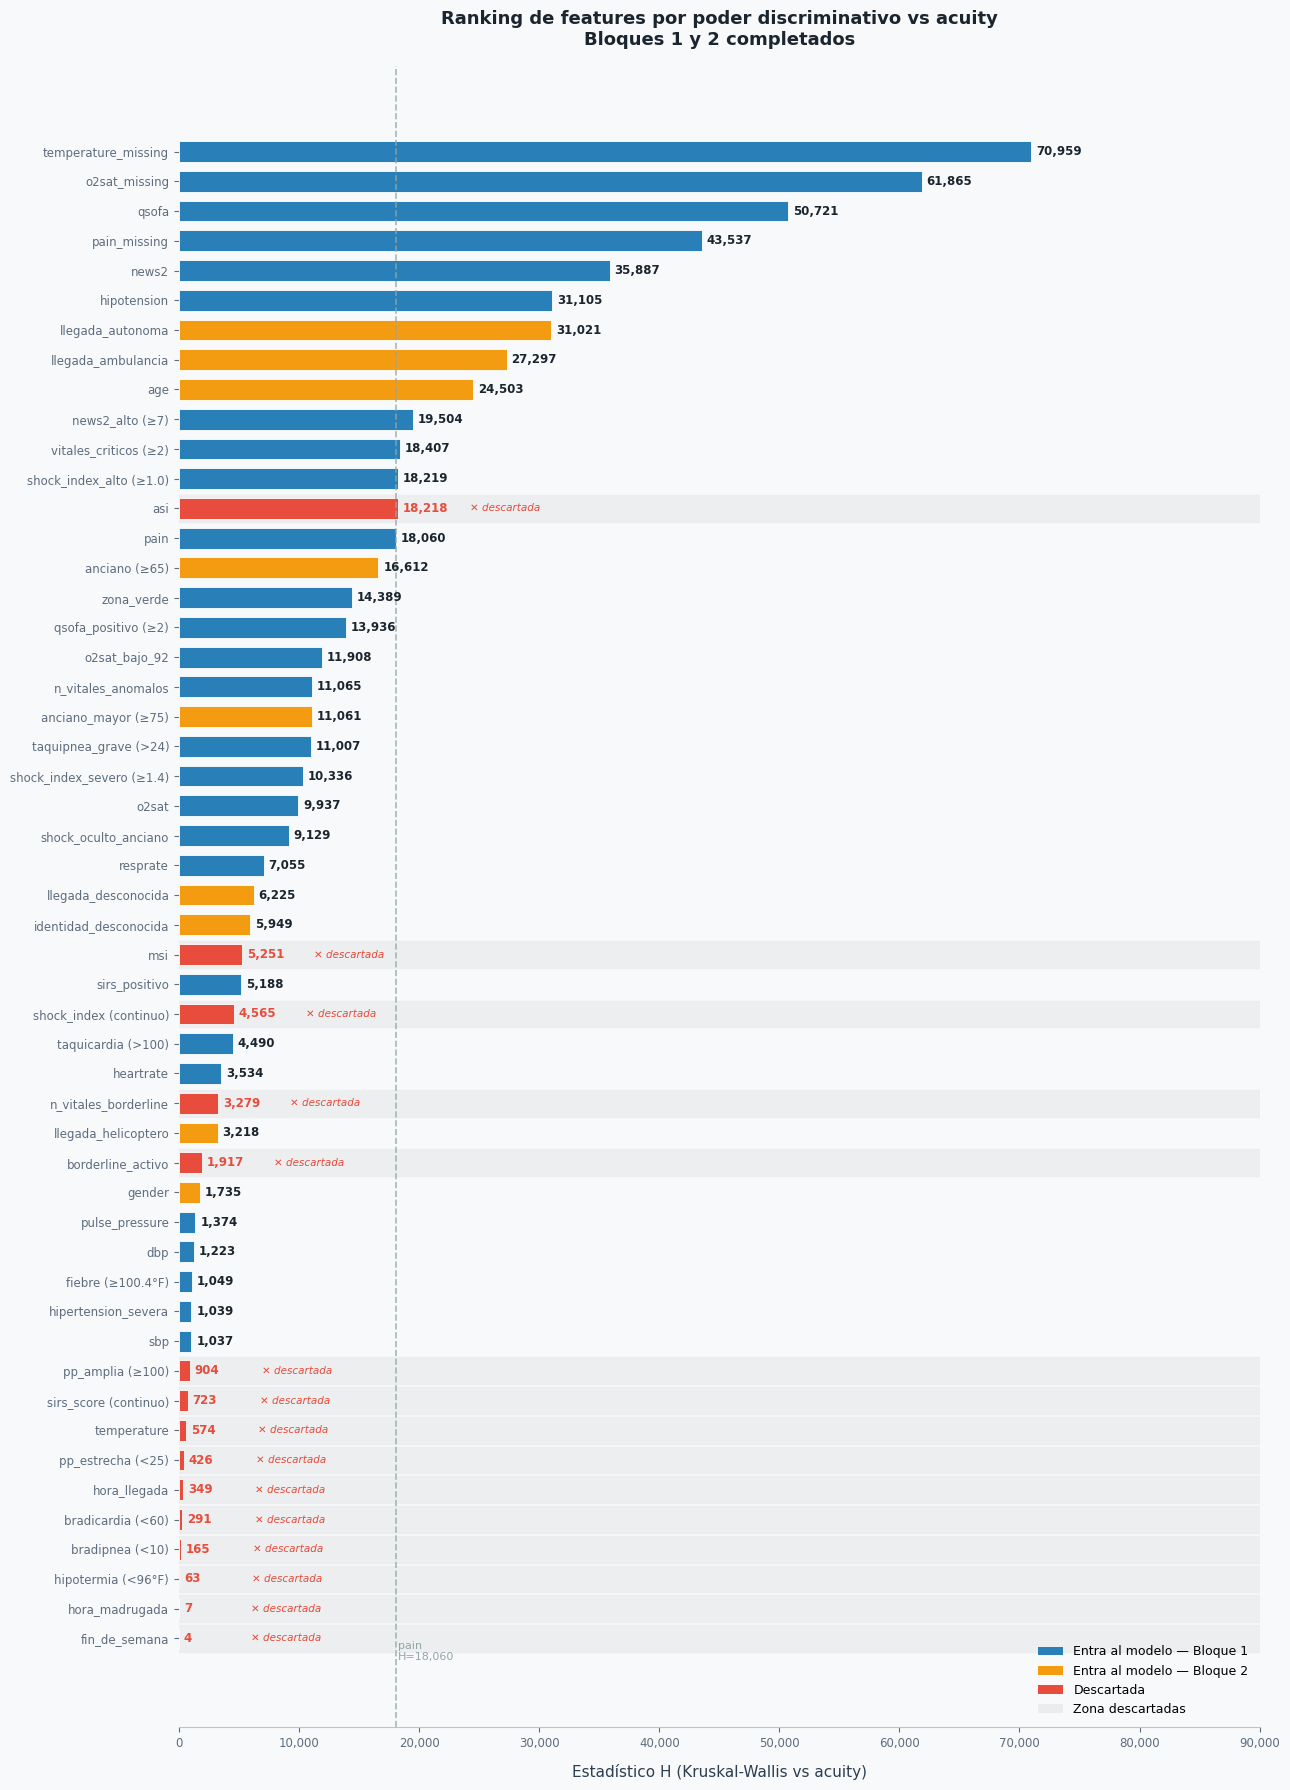

Features que entran: 36 | Descartadas: 15


In [99]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

features_ranking = {
    # ── Bloque 1 — Vitales, scores y banderas clínicas ────────────────────────
    "temperature_missing":        {"H": 70959, "estado": "entra",      "bloque": "Bloque 1"},
    "o2sat_missing":              {"H": 61865, "estado": "entra",      "bloque": "Bloque 1"},
    "qsofa":                      {"H": 50721, "estado": "entra",      "bloque": "Bloque 1"},
    "pain_missing":               {"H": 43537, "estado": "entra",      "bloque": "Bloque 1"},
    "news2":                      {"H": 35887, "estado": "entra",      "bloque": "Bloque 1"},
    "hipotension":                {"H": 31105, "estado": "entra",      "bloque": "Bloque 1"},
    "news2_alto (≥7)":            {"H": 19504, "estado": "entra",      "bloque": "Bloque 1"},
    "vitales_criticos (≥2)":      {"H": 18407, "estado": "entra",      "bloque": "Bloque 1"},
    "shock_index_alto (≥1.0)":    {"H": 18219, "estado": "entra",      "bloque": "Bloque 1"},
    "asi":                        {"H": 18218, "estado": "descartado",  "bloque": "Bloque 1"},
    "pain":                       {"H": 18060, "estado": "entra",      "bloque": "Bloque 1"},
    "zona_verde":                 {"H": 14389, "estado": "entra",      "bloque": "Bloque 1"},
    "qsofa_positivo (≥2)":        {"H": 13936, "estado": "entra",      "bloque": "Bloque 1"},
    "o2sat_bajo_92":              {"H": 11908, "estado": "entra",      "bloque": "Bloque 1"},
    "n_vitales_anomalos":         {"H": 11065, "estado": "entra",      "bloque": "Bloque 1"},
    "taquipnea_grave (>24)":      {"H": 11007, "estado": "entra",      "bloque": "Bloque 1"},
    "shock_index_severo (≥1.4)":  {"H": 10336, "estado": "entra",      "bloque": "Bloque 1"},
    "o2sat":                      {"H":  9937, "estado": "entra",      "bloque": "Bloque 1"},
    "shock_oculto_anciano":       {"H":  9129, "estado": "entra",      "bloque": "Bloque 1"},
    "resprate":                   {"H":  7055, "estado": "entra",      "bloque": "Bloque 1"},
    "sirs_positivo":              {"H":  5188, "estado": "entra",      "bloque": "Bloque 1"},
    "msi":                        {"H":  5251, "estado": "descartado",  "bloque": "Bloque 1"},
    "shock_index (continuo)":     {"H":  4565, "estado": "descartado",  "bloque": "Bloque 1"},
    "taquicardia (>100)":         {"H":  4490, "estado": "entra",      "bloque": "Bloque 1"},
    "heartrate":                  {"H":  3534, "estado": "entra",      "bloque": "Bloque 1"},
    "n_vitales_borderline":       {"H":  3279, "estado": "descartado",  "bloque": "Bloque 1"},
    "borderline_activo":          {"H":  1917, "estado": "descartado",  "bloque": "Bloque 1"},
    "pulse_pressure":             {"H":  1374, "estado": "entra",      "bloque": "Bloque 1"},
    "dbp":                        {"H":  1223, "estado": "entra",      "bloque": "Bloque 1"},
    "fiebre (≥100.4°F)":          {"H":  1049, "estado": "entra",      "bloque": "Bloque 1"},
    "hipertension_severa":        {"H":  1039, "estado": "entra",      "bloque": "Bloque 1"},
    "sbp":                        {"H":  1037, "estado": "entra",      "bloque": "Bloque 1"},
    "sirs_score (continuo)":      {"H":   723, "estado": "descartado",  "bloque": "Bloque 1"},
    "pp_amplia (≥100)":           {"H":   904, "estado": "descartado",  "bloque": "Bloque 1"},
    "temperature":                {"H":   574, "estado": "descartado",  "bloque": "Bloque 1"},
    "pp_estrecha (<25)":          {"H":   426, "estado": "descartado",  "bloque": "Bloque 1"},
    "bradicardia (<60)":          {"H":   291, "estado": "descartado",  "bloque": "Bloque 1"},
    "bradipnea (<10)":            {"H":   165, "estado": "descartado",  "bloque": "Bloque 1"},
    "hipotermia (<96°F)":         {"H":    63, "estado": "descartado",  "bloque": "Bloque 1"},
    # ── Bloque 2 — Demográfico y logístico ────────────────────────────────────
    "llegada_autonoma":           {"H": 31021, "estado": "entra",      "bloque": "Bloque 2"},
    "llegada_ambulancia":         {"H": 27297, "estado": "entra",      "bloque": "Bloque 2"},
    "age":                        {"H": 24503, "estado": "entra",      "bloque": "Bloque 2"},
    "anciano (≥65)":              {"H": 16612, "estado": "entra",      "bloque": "Bloque 2"},
    "anciano_mayor (≥75)":        {"H": 11061, "estado": "entra",      "bloque": "Bloque 2"},
    "llegada_desconocida":        {"H":  6225, "estado": "entra",      "bloque": "Bloque 2"},
    "identidad_desconocida":      {"H":  5949, "estado": "entra",      "bloque": "Bloque 2"},
    "llegada_helicoptero":        {"H":  3218, "estado": "entra",      "bloque": "Bloque 2"},
    "gender":                     {"H":  1735, "estado": "entra",      "bloque": "Bloque 2"},
    "hora_llegada":               {"H":   349, "estado": "descartado",  "bloque": "Bloque 2"},
    "fin_de_semana":              {"H":     4, "estado": "descartado",  "bloque": "Bloque 2"},
    "hora_madrugada":             {"H":     7, "estado": "descartado",  "bloque": "Bloque 2"},
}

df_ranking = pd.DataFrame(features_ranking).T.reset_index()
df_ranking.columns = ["feature", "H", "estado", "bloque"]
df_ranking["H"] = df_ranking["H"].astype(int)
df_ranking = df_ranking.sort_values("H", ascending=True).reset_index(drop=True)

color_b1     = "#2980B9"
color_b2     = "#F39C12"
color_desc   = "#E74C3C"

indices_desc = df_ranking[df_ranking["estado"] == "descartado"].index.tolist()

fig, ax = plt.subplots(figsize=(13, 18))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

for i in indices_desc:
    ax.axhspan(i - 0.45, i + 0.45, color="#EAECEE", alpha=0.8, zorder=0)

for i, row in df_ranking.iterrows():
    if row["estado"] == "descartado":
        color = color_desc
    elif row["bloque"] == "Bloque 2":
        color = color_b2
    else:
        color = color_b1

    ax.barh(i, row["H"], color=color, alpha=1.0,
            edgecolor="white", linewidth=0.6, height=0.7, zorder=2)
    ax.text(row["H"] + 400, i, f"{row['H']:,}",
            va="center", ha="left", fontsize=8.5, fontweight="bold",
            color=color_desc if row["estado"] == "descartado" else "#1A252F")

for i in indices_desc:
    ax.text(df_ranking.loc[i, "H"] + 6000, i, "✕ descartada",
            va="center", ha="left", fontsize=7.5,
            color=color_desc, fontstyle="italic")

ax.set_yticks(range(len(df_ranking)))
ax.set_yticklabels(df_ranking["feature"], fontsize=8.5, color="#2C3E50")

ax.axvline(x=18060, color="#95A5A6", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(18200, -0.8, "pain\nH=18,060", color="#95A5A6", fontsize=8, va="bottom")

ax.legend(handles=[
    mpatches.Patch(facecolor=color_b1,   label="Entra al modelo — Bloque 1"),
    mpatches.Patch(facecolor=color_b2,   label="Entra al modelo — Bloque 2"),
    mpatches.Patch(facecolor=color_desc, label="Descartada"),
    mpatches.Patch(facecolor="#EAECEE",  label="Zona descartadas"),
], loc="lower right", frameon=False, fontsize=9)

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11,
              color="#2C3E50", labelpad=10)
ax.set_title(
    "Ranking de features por poder discriminativo vs acuity\n"
    "Bloques 1 y 2 completados",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15
)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=8.5)
ax.set_xlim(0, 90000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("resumen_hstat_global_v4.png", dpi=150, bbox_inches="tight")
plt.show()

n_entran = (df_ranking["estado"] == "entra").sum()
n_desc   = (df_ranking["estado"] == "descartado").sum()
print(f"Features que entran: {n_entran} | Descartadas: {n_desc}")

In [100]:
# ── Serie medicación: vector de texto (una vez antes de las CLASES; idempotente) ──
med = df["medicacion_raw"].fillna("").astype(str)

# ── CLASE 10A: med_diuretico_asa (diuréticos de asa / loop) ─────────────────────
# En MIMIC el etcdescription es "diuretic - loop", no "diuretic loop".
df["med_diuretico_asa"] = (
    med.str.contains(r"diuretic\s*-\s*loop", case=False, na=False, regex=True)
    | med.str.contains(r"loop\s+diuretic", case=False, na=False, regex=True)
    | med.str.contains(r"furosemide|bumetanide|torsemide|torasemide", case=False, na=False, regex=True)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_diuretico_asa"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_diuretico_asa"].mean() * 100
n = int(df["med_diuretico_asa"].sum())

print(
    f"med_diuretico_asa  →  H = {stat:,.0f}  |  p = {pval:.2e}  "
    f"|  prevalencia = {prev:.2f}%  |  n = {n:,}\n"
)
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_diuretico_asa"].mean() * 100).round(2).to_string())


med_diuretico_asa  →  H = 6,746  |  p = 0.00e+00  |  prevalencia = 9.75%  |  n = 40,785

% por clase de acuity:

acuity
1    13.25
2    14.27
3     7.60
4     2.05
5     2.27


MEDICAMENTOS RAW   

In [101]:
# Auditoría de medicacion_raw
# Objetivo: entender el vocabulario real antes de definir cualquier regex
# medicacion_raw contiene los etcdescription de medrecon concatenados por stay_id

# Primero ver la estructura raw
print("Ejemplos de medicacion_raw:\n")
print(df["medicacion_raw"].dropna().head(10).to_string())
print(f"\nTotal stays con medicación: {(df['medicacion_raw'] != '').sum():,}")
print(f"Total stays sin medicación: {(df['medicacion_raw'] == '').sum():,}")

Ejemplos de medicacion_raw:

0    asthma/copd therapy - beta 2-adrenergic agents...
1    asthma/copd therapy - beta 2-adrenergic agents...
2    antiretroviral - nucleoside and nucleotide ana...
3    asthma/copd therapy - beta 2-adrenergic agents...
4    asthma/copd therapy - beta 2-adrenergic agents...
5    antihistamines - 2nd generation, antiparkinson...
6    antipsychotic -atypical dopamine-serotonin ant...
7                      penicillin antibiotic - natural
8                                                     
9                                                     

Total stays con medicación: 302,751
Total stays sin medicación: 115,349


In [102]:
# Explotar medicacion_raw en términos individuales
# Cada stay tiene múltiples medicamentos separados por ", "
# Objetivo: frecuencia de cada término único

from collections import Counter

# Separar todos los términos
todos_terminos = (
    df[df["medicacion_raw"] != ""]["medicacion_raw"]
    .str.split(", ")
    .explode()
    .str.strip()
)

# Frecuencia de cada término
contador = Counter(todos_terminos)
df_terminos = (
    pd.DataFrame(contador.items(), columns=["termino", "n"])
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

# Cobertura acumulada
df_terminos["pct"] = df_terminos["n"] / df_terminos["n"].sum() * 100
df_terminos["pct_acum"] = df_terminos["pct"].cumsum()

print(f"Total términos únicos: {len(df_terminos):,}")
print(f"Total menciones: {df_terminos['n'].sum():,}\n")

print("Top 50 términos más frecuentes:\n")
print(df_terminos.head(50).to_string())

print(f"\n¿Cuántos términos cubren el 80% de las menciones?")
print(f"  {(df_terminos['pct_acum'] <= 80).sum():,} términos")
print(f"¿Cuántos términos cubren el 90%?")
print(f"  {(df_terminos['pct_acum'] <= 90).sum():,} términos")
print(f"¿Cuántos términos cubren el 95%?")
print(f"  {(df_terminos['pct_acum'] <= 95).sum():,} términos")

Total términos únicos: 1,201
Total menciones: 2,766,977

Top 50 términos más frecuentes:

                                                                   termino       n       pct   pct_acum
0              antihyperlipidemic - hmg coa reductase inhibitors (statins)  100915  3.647121   3.647121
1   gastric acid secretion reducing agents - proton pump inhibitors (ppis)   92081  3.327856   6.974977
2                                                    salicylate analgesics   87142  3.149358  10.124334
3                                                 vitamins - d derivatives   68682  2.482204  12.606538
4                                          beta blockers cardiac selective   66736  2.411874  15.018412
5                                      antianxiety agent - benzodiazepines   59542  2.151879  17.170291
6                                                analgesic opioid agonists   58145  2.101391  19.271682
7         antidepressant - selective serotonin reuptake inhibitors (ssris)   5

In [103]:
# Auditoría top 100-200 términos
# Objetivo: confirmar med_inmunosupresor_quimio y detectar clases no contempladas

print("Términos 51-100:\n")
print(df_terminos.iloc[50:100].to_string())
print("\nTérminos 101-150:\n")
print(df_terminos.iloc[100:150].to_string())
print("\nTérminos 151-200:\n")
print(df_terminos.iloc[150:200].to_string())

Términos 51-100:

                                                                   termino      n       pct   pct_acum
50                         minerals and electrolytes - calcium replacement  12280  0.443806  64.145600
51             medical supplies and dme - glucose monitoring test supplies  11616  0.419808  64.565408
52                     hyperuricemia therapy - xanthine oxidase inhibitors  11542  0.417134  64.982542
53                              diuretic - aldosterone receptor antagonist  11520  0.416339  65.398881
54                                   multivitamin and mineral combinations  11393  0.411749  65.810630
55                                    asthma/copd - anticholinergic agents  11152  0.403039  66.213669
56                                                           non-selective  11030  0.398630  66.612299
57  antidepressant-norepinephrine and dopamine reuptake inhibitors (ndris)  10972  0.396534  67.008833
58                        dermatological - topical loca

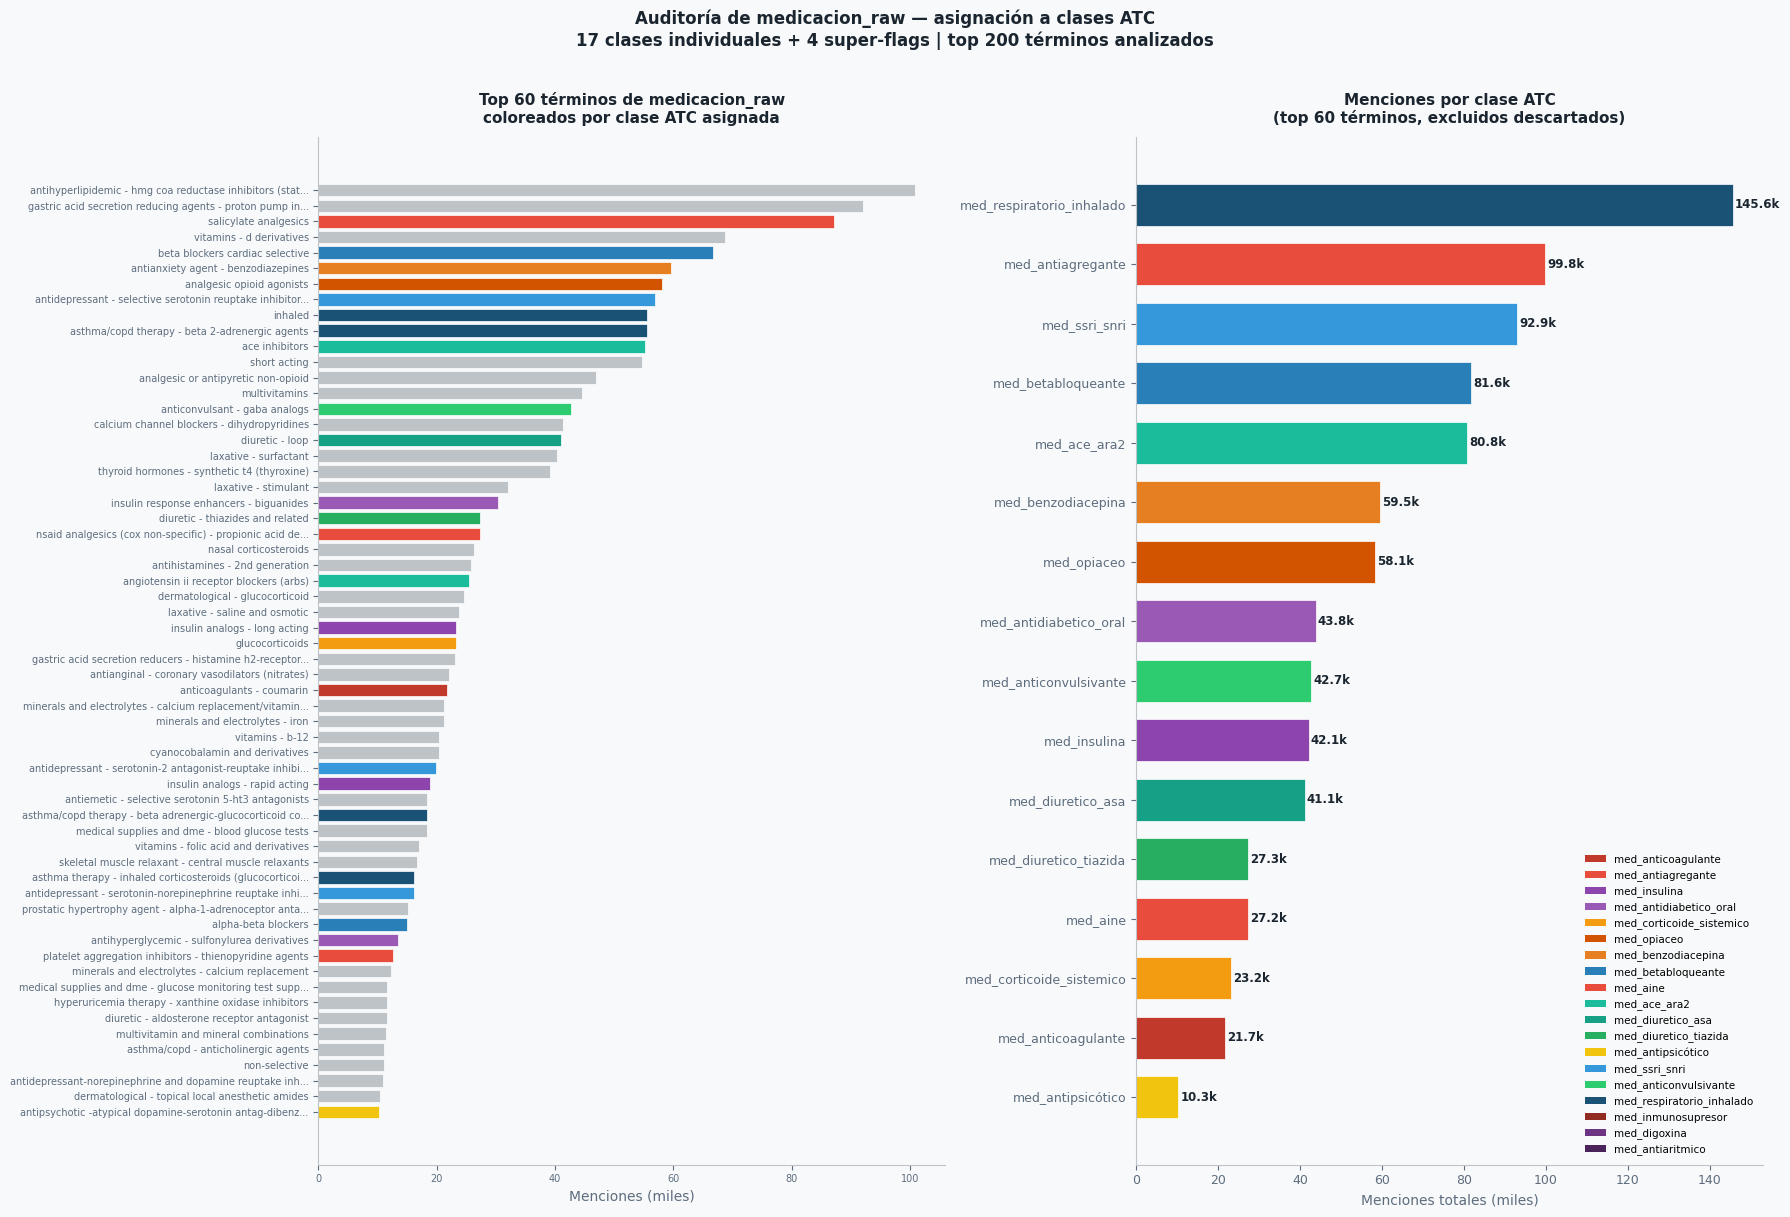

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
fig.patch.set_facecolor("#F8F9FA")

# ── Mapa de clases ATC sobre el top 60 términos ──────────────────────────────
# Asignamos cada término a su clase o a "descartado"

mapa_clases = {
    "antihyperlipidemic - hmg coa reductase inhibitors (statins)":          "descartado",
    "gastric acid secretion reducing agents - proton pump inhibitors (ppis)":"descartado",
    "salicylate analgesics":                                                  "med_antiagregante",
    "vitamins - d derivatives":                                               "descartado",
    "beta blockers cardiac selective":                                        "med_betabloqueante",
    "antianxiety agent - benzodiazepines":                                    "med_benzodiacepina",
    "analgesic opioid agonists":                                              "med_opiaceo",
    "antidepressant - selective serotonin reuptake inhibitors (ssris)":       "med_ssri_snri",
    "inhaled":                                                                "med_respiratorio_inhalado",
    "asthma/copd therapy - beta 2-adrenergic agents":                         "med_respiratorio_inhalado",
    "ace inhibitors":                                                         "med_ace_ara2",
    "short acting":                                                           "descartado",
    "analgesic or antipyretic non-opioid":                                    "descartado",
    "multivitamins":                                                          "descartado",
    "anticonvulsant - gaba analogs":                                          "med_anticonvulsivante",
    "calcium channel blockers - dihydropyridines":                            "descartado",
    "diuretic - loop":                                                        "med_diuretico_asa",
    "laxative - surfactant":                                                  "descartado",
    "thyroid hormones - synthetic t4 (thyroxine)":                            "descartado",
    "laxative - stimulant":                                                   "descartado",
    "insulin response enhancers - biguanides":                                "med_antidiabetico_oral",
    "diuretic - thiazides and related":                                       "med_diuretico_tiazida",
    "nsaid analgesics (cox non-specific) - propionic acid derivatives":       "med_aine",
    "nasal corticosteroids":                                                  "descartado",
    "antihistamines - 2nd generation":                                        "descartado",
    "angiotensin ii receptor blockers (arbs)":                                "med_ace_ara2",
    "dermatological - glucocorticoid":                                        "descartado",
    "laxative - saline and osmotic":                                          "descartado",
    "insulin analogs - long acting":                                          "med_insulina",
    "glucocorticoids":                                                        "med_corticoide_sistemico",
    "gastric acid secretion reducers - histamine h2-receptor antagonists":    "descartado",
    "antianginal - coronary vasodilators (nitrates)":                         "descartado",
    "anticoagulants - coumarin":                                              "med_anticoagulante",
    "minerals and electrolytes - calcium replacement/vitamin d combinations": "descartado",
    "minerals and electrolytes - iron":                                       "descartado",
    "cyanocobalamin and derivatives":                                         "descartado",
    "vitamins - b-12":                                                        "descartado",
    "antidepressant - serotonin-2 antagonist-reuptake inhibitors (saris)":    "med_ssri_snri",
    "insulin analogs - rapid acting":                                         "med_insulina",
    "antiemetic - selective serotonin 5-ht3 antagonists":                     "descartado",
    "asthma/copd therapy - beta adrenergic-glucocorticoid combinations":      "med_respiratorio_inhalado",
    "medical supplies and dme - blood glucose tests":                         "descartado",
    "vitamins - folic acid and derivatives":                                  "descartado",
    "skeletal muscle relaxant - central muscle relaxants":                    "descartado",
    "asthma therapy - inhaled corticosteroids (glucocorticoids)":             "med_respiratorio_inhalado",
    "antidepressant - serotonin-norepinephrine reuptake inhibitors (snris)":  "med_ssri_snri",
    "prostatic hypertrophy agent - alpha-1-adrenoceptor antagonists":         "descartado",
    "alpha-beta blockers":                                                    "med_betabloqueante",
    "antihyperglycemic - sulfonylurea derivatives":                           "med_antidiabetico_oral",
    "platelet aggregation inhibitors - thienopyridine agents":                "med_antiagregante",
    "direct factor xa inhibitors":                                            "med_anticoagulante",
    "immunosuppressive - calcineurin inhibitors":                             "med_inmunosupresor",
    "low molecular weight heparins":                                          "med_anticoagulante",
    "antipsychotic -atypical dopamine-serotonin antag-dibenzothiazepine der": "med_antipsicótico",
    "antidepressant-tricyclics and related (non-select reuptake inhibitors)": "med_ssri_snri",
    "sedative-hypnotic - gaba-receptor modulators":                           "med_benzodiacepina",
    "antipsychotic - phenothiazines":                                         "med_antipsicótico",
    "analgesic opioid oxycodone combinations":                                "med_opiaceo",
    "digitalis glycosides":                                                   "med_digoxina",
    "antiarrhythmic - class iii":                                             "med_antiaritmico",
    "immunosuppressive - inosine monophosphate dehydrogenase inhibitors":     "med_inmunosupresor",
}

# Colores por clase
paleta_clases = {
    "med_anticoagulante":         "#C0392B",
    "med_antiagregante":          "#E74C3C",
    "med_insulina":               "#8E44AD",
    "med_antidiabetico_oral":     "#9B59B6",
    "med_corticoide_sistemico":   "#F39C12",
    "med_opiaceo":                "#D35400",
    "med_benzodiacepina":         "#E67E22",
    "med_betabloqueante":         "#2980B9",
    "med_aine":                   "#E74C3C",
    "med_ace_ara2":               "#1ABC9C",
    "med_diuretico_asa":          "#16A085",
    "med_diuretico_tiazida":      "#27AE60",
    "med_antipsicótico":          "#F1C40F",
    "med_ssri_snri":              "#3498DB",
    "med_anticonvulsivante":      "#2ECC71",
    "med_respiratorio_inhalado":  "#1A5276",
    "med_inmunosupresor":         "#922B21",
    "med_digoxina":               "#6C3483",
    "med_antiaritmico":           "#4A235A",
    "descartado":                 "#BDC3C7",
}

# ── Izquierda: top 60 términos coloreados por clase ───────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

top60 = df_terminos.head(60).copy()
top60["clase"] = top60["termino"].map(mapa_clases).fillna("descartado")
top60 = top60.sort_values("n", ascending=True)

colores_barras = [paleta_clases.get(c, "#BDC3C7") for c in top60["clase"]]

bars = ax1.barh(range(len(top60)), top60["n"] / 1000,
                color=colores_barras, edgecolor="white",
                linewidth=0.5, height=0.8)

ax1.set_yticks(range(len(top60)))
ax1.set_yticklabels(
    [t[:55] + "..." if len(t) > 55 else t for t in top60["termino"]],
    fontsize=6.5, color="#2C3E50"
)
ax1.set_xlabel("Menciones (miles)", fontsize=10, color="#5D6D7E")
ax1.set_title("Top 60 términos de medicacion_raw\ncoloreados por clase ATC asignada",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=7)

# ── Derecha: menciones totales por clase ──────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

resumen_clases = (
    top60[top60["clase"] != "descartado"]
    .groupby("clase")["n"]
    .sum()
    .sort_values(ascending=True)
)

colores_clases = [paleta_clases.get(c, "#BDC3C7") for c in resumen_clases.index]

bars2 = ax2.barh(range(len(resumen_clases)), resumen_clases.values / 1000,
                 color=colores_clases, edgecolor="white",
                 linewidth=0.5, height=0.7)

for bar, val in zip(bars2, resumen_clases.values):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val/1000:.1f}k", va="center", ha="left",
             fontsize=8.5, fontweight="bold", color="#1A252F")

ax2.set_yticks(range(len(resumen_clases)))
ax2.set_yticklabels(resumen_clases.index, fontsize=9, color="#2C3E50")
ax2.set_xlabel("Menciones totales (miles)", fontsize=10, color="#5D6D7E")
ax2.set_title("Menciones por clase ATC\n(top 60 términos, excluidos descartados)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=v, label=k)
    for k, v in paleta_clases.items()
    if k != "descartado"
]
ax2.legend(handles=leyenda, loc="lower right", frameon=False,
           fontsize=7.5, ncol=1)

fig.suptitle(
    "Auditoría de medicacion_raw — asignación a clases ATC\n"
    "17 clases individuales + 4 super-flags | top 200 términos analizados",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.01
)

plt.tight_layout()
plt.savefig("bloque3_auditoria_medicacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [105]:
# ── CLASE 1: med_anticoagulante ───────────────────────────────────────────────
# Cubre: cumarínicos, heparinas BPM, inhibidores factor Xa, otros B01A
# Justificación clínica: riesgo hemorrágico elevado en traumatismos,
# procedimientos y combinaciones farmacológicas

med = df["medicacion_raw"]

df["med_anticoagulante"] = (
    med.str.contains("coumarin",                    case=False, na=False) |
    med.str.contains("low molecular weight heparin", case=False, na=False) |
    med.str.contains("direct factor xa",            case=False, na=False) |
    med.str.contains("direct thrombin inhibitor",   case=False, na=False) |
    med.str.contains("anticoagulant",               case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_anticoagulante"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_anticoagulante"].mean() * 100
n    = int(df["med_anticoagulante"].sum())

print(f"med_anticoagulante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_anticoagulante"].mean() * 100).round(2).to_string())

med_anticoagulante  →  H = 5,023  |  p = 0.00e+00  |  prevalencia = 7.32%  |  n = 30,588

% por clase de acuity:

acuity
1    10.53
2    10.71
3     5.59
4     1.85
5     1.73


In [106]:
# ── CLASE 2: med_antiagregante ────────────────────────────────────────────────
# Cubre: aspirina a dosis bajas (salicylate), tienopiridinas (clopidogrel)
# Distinción crítica respecto a anticoagulantes — riesgo hemorrágico menor
# pero muy prevalente en población cardiovascular

df["med_antiagregante"] = (
    med.str.contains("salicylate",                          case=False, na=False) |
    med.str.contains("thienopyridine",                      case=False, na=False) |
    med.str.contains("platelet aggregation inhibitor",      case=False, na=False) |
    med.str.contains("platelet inhibitor",                  case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antiagregante"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_antiagregante"].mean() * 100
n    = int(df["med_antiagregante"].sum())

print(f"med_antiagregante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antiagregante"].mean() * 100).round(2).to_string())

med_antiagregante  →  H = 8,275  |  p = 0.00e+00  |  prevalencia = 22.56%  |  n = 94,321

% por clase de acuity:

acuity
1    26.62
2    29.55
3    19.54
4     9.37
5     7.64


In [107]:
# ── CLASE 3A: med_insulina ────────────────────────────────────────────────────
# Cubre: insulinas de acción lenta, rápida, intermedia y combinaciones
# Indica diabetes insulinodependiente — mayor riesgo de hipoglucemia grave
# y cetoacidosis diabética que los antidiabéticos orales

df["med_insulina"] = (
    med.str.contains("insulin analog",          case=False, na=False) |
    med.str.contains("human insulin",           case=False, na=False) |
    med.str.contains("insulin response",        case=False, na=False, regex=False) |
    med.str.contains("insulin needle",          case=False, na=False)
).astype("int8")

# Excluir antidiabéticos orales que contengan "insulin" en el nombre
# biguanides no contienen "insulin" — regex seguro

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_insulina"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_insulina"].mean() * 100
n    = int(df["med_insulina"].sum())

print(f"med_insulina  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_insulina"].mean() * 100).round(2).to_string())

med_insulina  →  H = 2,490  |  p = 0.00e+00  |  prevalencia = 13.22%  |  n = 55,255

% por clase de acuity:

acuity
1    13.40
2    16.27
3    12.18
4     6.62
5     4.91


In [108]:
# ── CLASE 3B: med_antidiabetico_oral ─────────────────────────────────────────
# Cubre: biguanidas (metformina), sulfonilureas, inhibidores DPP-4
# Indica diabetes tipo 2 no insulinodependiente — perfil de riesgo menor
# que insulina pero señal de comorbilidad crónica relevante

df["med_antidiabetico_oral"] = (
    med.str.contains("biguanide",                           case=False, na=False) |
    med.str.contains("sulfonylurea",                        case=False, na=False) |
    med.str.contains("dipeptidyl peptidase",                case=False, na=False) |
    med.str.contains("dpp-4",                               case=False, na=False) |
    med.str.contains("antihyperglycemic",                   case=False, na=False) |
    med.str.contains("insulin response enhancer",           case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antidiabetico_oral"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_antidiabetico_oral"].mean() * 100
n    = int(df["med_antidiabetico_oral"].sum())

print(f"med_antidiabetico_oral  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antidiabetico_oral"].mean() * 100).round(2).to_string())

med_antidiabetico_oral  →  H = 1,014  |  p = 4.08e-218  |  prevalencia = 9.37%  |  n = 39,167

% por clase de acuity:

acuity
1     8.98
2    10.96
3     8.95
4     5.48
5     3.82


In [109]:
# ── CLASE 4: med_corticoide_sistemico ────────────────────────────────────────
# Cubre: glucocorticoides sistémicos orales/IV únicamente
# EXCLUYE explícitamente: nasales, tópicos dermatológicos, inhalados, anorectales
# Justificación: inmunosupresión crónica — umbral de alarma diferente
# Una fiebre de 38°C en corticoideo crónico = sepsis hasta demostrar lo contrario

df["med_corticoide_sistemico"] = (
    med.str.contains("glucocorticoid",          case=False, na=False) &
    ~med.str.contains("nasal corticosteroid",   case=False, na=False) &
    ~med.str.contains("dermatological",         case=False, na=False) &
    ~med.str.contains("inhaled",                case=False, na=False) &
    ~med.str.contains("anorectal",              case=False, na=False) &
    ~med.str.contains("ophthalmic",             case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_corticoide_sistemico"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_corticoide_sistemico"].mean() * 100
n    = int(df["med_corticoide_sistemico"].sum())

print(f"med_corticoide_sistemico  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_corticoide_sistemico"].mean() * 100).round(2).to_string())

# Validación: cuántos tienen nasal/derma/inhalado que hemos excluido
n_total_gluco = med.str.contains("glucocorticoid", case=False, na=False).sum()
print(f"\nValidación regex:")
print(f"  Menciones totales 'glucocorticoid': {n_total_gluco:,}")
print(f"  Clasificados como sistémico:        {n:,}")
print(f"  Excluidos (nasal/derma/inhaled):    {n_total_gluco - n:,}")

med_corticoide_sistemico  →  H = 975  |  p = 8.27e-210  |  prevalencia = 2.88%  |  n = 12,051

% por clase de acuity:

acuity
1    3.37
2    3.81
3    2.52
4    0.91
5    0.55

Validación regex:
  Menciones totales 'glucocorticoid': 67,743
  Clasificados como sistémico:        12,051
  Excluidos (nasal/derma/inhaled):    55,692


In [110]:
# ── CLASE 5: med_opiaceo ──────────────────────────────────────────────────────
# Cubre: agonistas opioides, combinaciones con oxicodona/hidrocodona/codeína
# Justificación: sobredosis accidental, síndrome de abstinencia,
# dolor crónico severo descompensado — y potenciador de depresión respiratoria

df["med_opiaceo"] = (
    med.str.contains("opioid agonist",              case=False, na=False) |
    med.str.contains("opioid oxycodone",            case=False, na=False) |
    med.str.contains("opioid hydrocodone",          case=False, na=False) |
    med.str.contains("opioid codeine",              case=False, na=False) |
    med.str.contains("opioid-type",                 case=False, na=False) |
    med.str.contains("analgesic opioid",            case=False, na=False) |
    med.str.contains("agents for opioid withdrawal",case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_opiaceo"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_opiaceo"].mean() * 100
n    = int(df["med_opiaceo"].sum())

print(f"med_opiaceo  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_opiaceo"].mean() * 100).round(2).to_string())

med_opiaceo  →  H = 2,505  |  p = 0.00e+00  |  prevalencia = 15.55%  |  n = 65,026

% por clase de acuity:

acuity
1    15.75
2    17.91
3    15.28
4     6.37
5     6.09


In [111]:
# ── CLASE 6: med_benzodiacepina ───────────────────────────────────────────────
# Cubre: benzodiacepinas ansiolíticas + hipnóticos moduladores GABA
# Justificación: caídas en ancianos, delirium, depresión respiratoria
# en combinación con opiáceos — una de las interacciones más letales en urgencias

df["med_benzodiacepina"] = (
    med.str.contains("benzodiazepine",              case=False, na=False) |
    med.str.contains("sedative-hypnotic - gaba",    case=False, na=False) |
    med.str.contains("gaba-receptor modulator",     case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_benzodiacepina"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_benzodiacepina"].mean() * 100
n    = int(df["med_benzodiacepina"].sum())

print(f"med_benzodiacepina  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_benzodiacepina"].mean() * 100).round(2).to_string())

med_benzodiacepina  →  H = 2,809  |  p = 0.00e+00  |  prevalencia = 16.39%  |  n = 68,514

% por clase de acuity:

acuity
1    16.62
2    19.56
3    15.56
4     7.61
5     7.09


In [112]:
# ── CLASE 7: med_betabloqueante ───────────────────────────────────────────────
# Cubre: betabloqueantes cardioselectivos, no selectivos y alfa-beta bloqueantes
# Justificación: enmascaran taquicardia y respuesta al shock — clave para
# interpretar shock_index y shock_oculto_anciano correctamente

df["med_betabloqueante"] = (
    med.str.contains("beta blocker",        case=False, na=False) |
    med.str.contains("beta-blocker",        case=False, na=False) |
    med.str.contains("alpha-beta blocker",  case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_betabloqueante"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_betabloqueante"].mean() * 100
n    = int(df["med_betabloqueante"].sum())

print(f"med_betabloqueante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_betabloqueante"].mean() * 100).round(2).to_string())

med_betabloqueante  →  H = 10,279  |  p = 0.00e+00  |  prevalencia = 22.01%  |  n = 92,035

% por clase de acuity:

acuity
1    26.86
2    29.75
3    18.59
4     7.67
5     7.27


In [113]:
# ── CLASE 8: med_aine ─────────────────────────────────────────────────────────
# Cubre: AINEs no selectivos (ibuprofeno, naproxeno) — COX no específicos
# EXCLUYE: salicylates (ya cubiertos en med_antiagregante)
# Justificación: riesgo renal (Triple Whammy), hemorragia GI,
# interacción con anticoagulantes y antiagregantes

df["med_aine"] = (
    med.str.contains("nsaid",                       case=False, na=False) |
    med.str.contains("propionic acid derivative",   case=False, na=False) |
    med.str.contains("cox non-specific",            case=False, na=False) |
    med.str.contains("cox-non-specific",            case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_aine"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_aine"].mean() * 100
n    = int(df["med_aine"].sum())

print(f"med_aine  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_aine"].mean() * 100).round(2).to_string())

med_aine  →  H = 602  |  p = 5.08e-129  |  prevalencia = 8.61%  |  n = 36,000

% por clase de acuity:

acuity
1    5.82
2    7.78
3    9.49
4    8.25
5    5.00


In [114]:
# ── CLASE 9: med_ace_ara2 ─────────────────────────────────────────────────────
# Cubre: IECA + ARA2 + combinaciones IECA+diurético
# Agrupados porque ambos actúan sobre el SRAA — componentes del Triple Whammy
# Justificación: fracaso renal agudo en combinación con diuréticos + AINEs

df["med_ace_ara2"] = (
    med.str.contains("ace inhibitor",                   case=False, na=False) |
    med.str.contains("angiotensin ii receptor blocker",  case=False, na=False) |
    med.str.contains("angiotensin receptor blocker",     case=False, na=False) |
    med.str.contains("arb",                             case=False, na=False) |
    med.str.contains("ace inhibitor and diuretic",      case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_ace_ara2"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_ace_ara2"].mean() * 100
n    = int(df["med_ace_ara2"].sum())

print(f"med_ace_ara2  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_ace_ara2"].mean() * 100).round(2).to_string())

med_ace_ara2  →  H = 5,141  |  p = 0.00e+00  |  prevalencia = 23.03%  |  n = 96,291

% por clase de acuity:

acuity
1    25.01
2    28.42
3    21.02
4    11.47
5     8.09


In [115]:
# ── CLASE 10A: med_diuretico_asa ──────────────────────────────────────────────
# Cubre: diuréticos de asa — término real en vocabulario: "diuretic - loop"
# Justificación: marcador de ICC/edema crónico — perfil de urgencia cardiovascular
# Componente del Triple Whammy junto a ACE/ARA2 + AINEs

df["med_diuretico_asa"] = (
    med.str.contains("diuretic - loop",  case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_diuretico_asa"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_diuretico_asa"].mean() * 100
n    = int(df["med_diuretico_asa"].sum())

print(f"med_diuretico_asa  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_diuretico_asa"].mean() * 100).round(2).to_string())

med_diuretico_asa  →  H = 6,746  |  p = 0.00e+00  |  prevalencia = 9.75%  |  n = 40,785

% por clase de acuity:

acuity
1    13.25
2    14.27
3     7.60
4     2.05
5     2.27


In [116]:
# ── CLASE 10B: med_diuretico_tiazida ─────────────────────────────────────────
# Cubre: tiazidas y relacionados — término real: "diuretic - thiazides and related"
# También cubre combinaciones potasio-ahorradoras+tiazida
# Justificación: HTA crónica — perfil de urgencia moderado, componente Triple Whammy

df["med_diuretico_tiazida"] = (
    med.str.contains("diuretic - thiazides and related",              case=False, na=False) |
    med.str.contains("diuretic - potassium sparing-thiazide",         case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_diuretico_tiazida"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_diuretico_tiazida"].mean() * 100
n    = int(df["med_diuretico_tiazida"].sum())

print(f"med_diuretico_tiazida  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_diuretico_tiazida"].mean() * 100).round(2).to_string())

med_diuretico_tiazida  →  H = 248  |  p = 2.21e-52  |  prevalencia = 7.12%  |  n = 29,781

% por clase de acuity:

acuity
1    6.48
2    7.66
3    7.12
4    5.21
5    4.27


In [117]:
# ── CLASE 11: med_antipsicótico ───────────────────────────────────────────────
# Cubre: antipsicóticos típicos (fenotiazinas) + atípicos (dibenzotiazepinas,
#        benzisoxazoles, tienobenzodiazepinas) + agentes bipolares atípicos
# Justificación: marcador de patología psiquiátrica grave — componente
#                de alto_riesgo_delirium y riesgo_depresion_resp

df["med_antipsicótico"] = (
    med.str.contains("antipsychotic",                    case=False, na=False) |
    med.str.contains("bipolar therapy agents - atypical", case=False, na=False) |
    med.str.contains("phenothiazines",                   case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antipsicótico"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_antipsicótico"].mean() * 100
n    = int(df["med_antipsicótico"].sum())

print(f"med_antipsicótico  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antipsicótico"].mean() * 100).round(2).to_string())

med_antipsicótico  →  H = 2,432  |  p = 0.00e+00  |  prevalencia = 8.03%  |  n = 33,562

% por clase de acuity:

acuity
1     8.06
2    10.66
3     6.97
4     3.61
5     3.91


In [118]:
# ── CLASE 12: med_ssri_snri ───────────────────────────────────────────────────
# Cubre: SSRIs + SNRIs + NDRIs + tricíclicos + SARIs + NaSSAs
# Justificación: antidepresivos de uso crónico — marcador comorbilidad psiquiátrica
# Componente de riesgo_depresion_resp (tricíclicos + opiáceos) y alto_riesgo_sangrado

df["med_ssri_snri"] = (
    med.str.contains("selective serotonin reuptake inhibitors",          case=False, na=False) |
    med.str.contains("serotonin-norepinephrine reuptake inhibitors",     case=False, na=False) |
    med.str.contains("norepinephrine and dopamine reuptake inhibitors",  case=False, na=False) |
    med.str.contains("tricyclics and related",                           case=False, na=False) |
    med.str.contains("serotonin-2 antagonist-reuptake inhibitors",       case=False, na=False) |
    med.str.contains("alpha-2 receptor antagonists",                     case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_ssri_snri"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_ssri_snri"].mean() * 100
n    = int(df["med_ssri_snri"].sum())

print(f"med_ssri_snri  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_ssri_snri"].mean() * 100).round(2).to_string())

med_ssri_snri  →  H = 3,344  |  p = 0.00e+00  |  prevalencia = 23.35%  |  n = 97,646

% por clase de acuity:

acuity
1    22.72
2    27.37
3    22.36
4    12.57
5    10.27


In [119]:
# ── CLASE 13: med_anticonvulsivante ──────────────────────────────────────────
# Cubre: GABA analogs + pyrrolidine + phenyltriazine + carboxylic acid +
#        hydantoins + iminostilbene + monosaccharide derivatives
# Justificación: epilepsia/dolor neuropático crónico — componente de
#                riesgo_depresion_resp (junto a opiáceos + benzodiacepinas)

df["med_anticonvulsivante"] = (
    med.str.contains("anticonvulsant - gaba analogs",               case=False, na=False) |
    med.str.contains("anticonvulsant - pyrrolidine derivatives",    case=False, na=False) |
    med.str.contains("anticonvulsant - phenyltriazine derivatives", case=False, na=False) |
    med.str.contains("anticonvulsant - carboxylic acid derivatives",case=False, na=False) |
    med.str.contains("anticonvulsant - hydantoins",                 case=False, na=False) |
    med.str.contains("anticonvulsant - iminostilbene derivatives",  case=False, na=False) |
    med.str.contains("anticonvulsant - monosaccharide derivatives", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_anticonvulsivante"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_anticonvulsivante"].mean() * 100
n    = int(df["med_anticonvulsivante"].sum())

print(f"med_anticonvulsivante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_anticonvulsivante"].mean() * 100).round(2).to_string())

med_anticonvulsivante  →  H = 2,366  |  p = 0.00e+00  |  prevalencia = 15.31%  |  n = 64,012

% por clase de acuity:

acuity
1    15.75
2    18.19
3    14.50
4     7.62
5     7.09


In [120]:
# ── CLASE 14: med_respiratorio_inhalado ──────────────────────────────────────
# Cubre: beta2-agonistas + corticoides inhalados + anticolinérgicos +
#        combinaciones beta2+corticoide y beta2+anticolinérgico + leucotrienos
# Justificación: EPOC/asma crónica — marcador de patología respiratoria de base
# Componente indirecto de riesgo_depresion_resp

df["med_respiratorio_inhalado"] = (
    med.str.contains("asthma/copd therapy - beta 2-adrenergic agents",              case=False, na=False) |
    med.str.contains("asthma/copd - anticholinergic agents",                        case=False, na=False) |
    med.str.contains("asthma therapy - inhaled corticosteroids",                    case=False, na=False) |
    med.str.contains("asthma/copd therapy - beta adrenergic-glucocorticoid",        case=False, na=False) |
    med.str.contains("asthma/copd therapy - beta adrenergic-anticholinergic",       case=False, na=False) |
    med.str.contains("asthma therapy - leukotriene receptor antagonists",           case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_respiratorio_inhalado"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_respiratorio_inhalado"].mean() * 100
n    = int(df["med_respiratorio_inhalado"].sum())

print(f"med_respiratorio_inhalado  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_respiratorio_inhalado"].mean() * 100).round(2).to_string())

med_respiratorio_inhalado  →  H = 1,296  |  p = 2.19e-279  |  prevalencia = 14.72%  |  n = 61,536

% por clase de acuity:

acuity
1    16.23
2    16.51
3    14.24
4     8.80
5     6.45


In [121]:
# ── CLASE 15: med_inmunosupresor ─────────────────────────────────────────────
# Cubre: inhibidores calcineurina + inhibidores inosina monofosfato deshidrogenasa
# Justificación: trasplantados/enfermedades autoinmunes graves — pacientes
#                de alto riesgo que acuden con infecciones o rechazos agudos

df["med_inmunosupresor"] = (
    med.str.contains("immunosuppressive - calcineurin inhibitors",                        case=False, na=False) |
    med.str.contains("immunosuppressive - inosine monophosphate dehydrogenase inhibitors", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_inmunosupresor"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_inmunosupresor"].mean() * 100
n    = int(df["med_inmunosupresor"].sum())

print(f"med_inmunosupresor  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_inmunosupresor"].mean() * 100).round(2).to_string())

med_inmunosupresor  →  H = 714  |  p = 2.56e-153  |  prevalencia = 1.57%  |  n = 6,568

% por clase de acuity:

acuity
1    1.29
2    2.20
3    1.38
4    0.33
5    0.36


In [122]:
# ── CLASE 16: med_digoxina ────────────────────────────────────────────────────
# Cubre: glucósidos digitálicos — término real: "digitalis glycosides"
# Justificación: ICC avanzada/FA crónica — marcador de cardiopatía grave
# Pacientes con escaso margen terapéutico, alto riesgo de intoxicación digitálica

df["med_digoxina"] = (
    med.str.contains("digitalis glycosides", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_digoxina"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_digoxina"].mean() * 100
n    = int(df["med_digoxina"].sum())

print(f"med_digoxina  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_digoxina"].mean() * 100).round(2).to_string())

med_digoxina  →  H = 980  |  p = 6.81e-211  |  prevalencia = 0.81%  |  n = 3,378

% por clase de acuity:

acuity
1    1.70
2    1.25
3    0.53
4    0.12
5    0.18


In [123]:
# ── CLASE 17: med_antiaritmico ────────────────────────────────────────────────
# Cubre: antiarrítmicos clase III — término real: "antiarrhythmic - class iii"
# Justificación: FA/arritmias ventriculares graves — marcador de cardiopatía
#                eléctrica severa, alto riesgo de descompensación aguda

df["med_antiaritmico"] = (
    med.str.contains("antiarrhythmic - class iii", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antiaritmico"].values
    for k in [1, 2, 3, 4, 5]
])

prev = df["med_antiaritmico"].mean() * 100
n    = int(df["med_antiaritmico"].sum())

print(f"med_antiaritmico  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antiaritmico"].mean() * 100).round(2).to_string())

med_antiaritmico  →  H = 1,083  |  p = 3.18e-233  |  prevalencia = 1.10%  |  n = 4,619

% por clase de acuity:

acuity
1    1.67
2    1.75
3    0.77
4    0.15
5    0.18


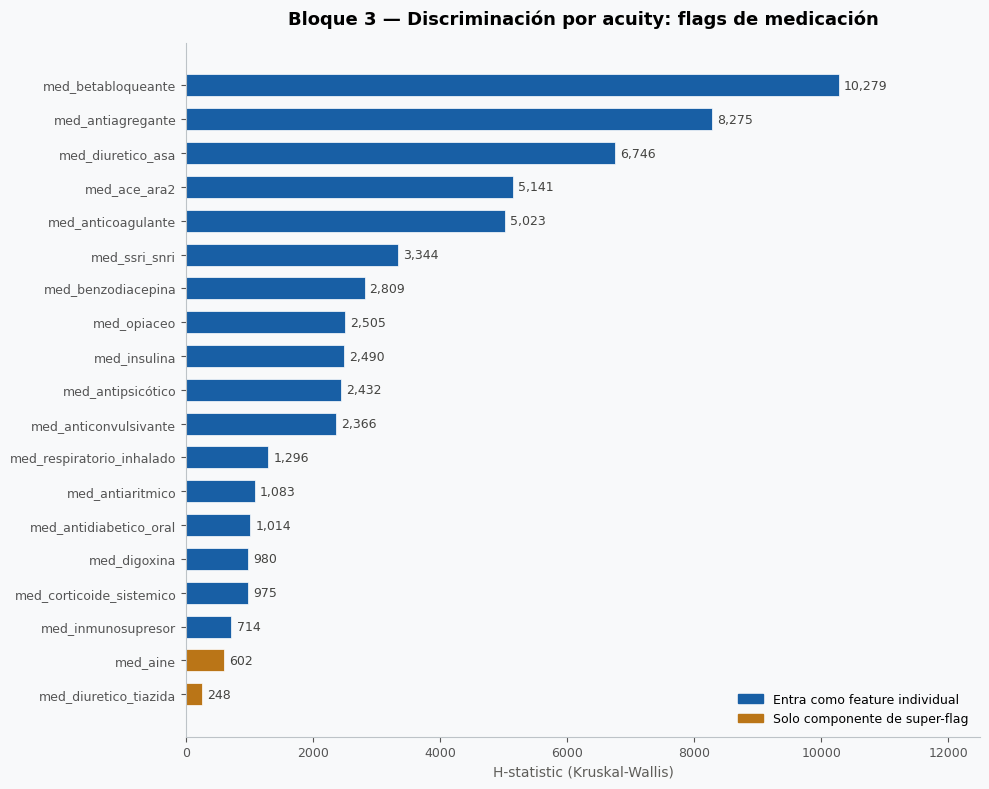

In [124]:
# ──H-stat de las 17 flags de medicación ───────────────
# Ordenadas de mayor a menor H-stat, coloreadas por decisión

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

flags = [
    ("med_betabloqueante",        10279, "entra"),
    ("med_antiagregante",          8275, "entra"),
    ("med_diuretico_asa",          6746, "entra"),
    ("med_ace_ara2",               5141, "entra"),
    ("med_anticoagulante",         5023, "entra"),
    ("med_ssri_snri",              3344, "entra"),
    ("med_benzodiacepina",         2809, "entra"),
    ("med_opiaceo",                2505, "entra"),
    ("med_insulina",               2490, "entra"),
    ("med_antipsicótico",          2432, "entra"),
    ("med_anticonvulsivante",      2366, "entra"),
    ("med_respiratorio_inhalado",  1296, "entra"),
    ("med_antidiabetico_oral",     1014, "entra"),
    ("med_antiaritmico",           1083, "entra"),
    ("med_digoxina",                980, "entra"),
    ("med_corticoide_sistemico",    975, "entra"),
    ("med_inmunosupresor",          714, "entra"),
    ("med_aine",                    602, "componente"),
    ("med_diuretico_tiazida",       248, "componente"),
]

# ordenar por H ascendente (para barh)
flags_sorted = sorted(flags, key=lambda x: x[1])

nombres = [f[0] for f in flags_sorted]
hstats  = [f[1] for f in flags_sorted]
colores = ["#185FA5" if f[2] == "entra" else "#BA7517" for f in flags_sorted]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(nombres, hstats, color=colores, height=0.65, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, hstats):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left", fontsize=9, color="#444441")

ax.set_xlabel("H-statistic (Kruskal-Wallis)", fontsize=10, color="#5F5E5A")
ax.set_title("Bloque 3 — Discriminación por acuity: flags de medicación",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, 12500)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#BDC3C7")
ax.tick_params(colors="#555555", labelsize=9)

patch_entra     = mpatches.Patch(color="#185FA5", label="Entra como feature individual")
patch_componente = mpatches.Patch(color="#BA7517", label="Solo componente de super-flag")
ax.legend(handles=[patch_entra, patch_componente], fontsize=9,
          frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("bloque3_flags_medicacion_hstat.png", dpi=150, bbox_inches="tight")
plt.show()

In [125]:
# ── SUPER-FLAGS: definición lógica sobre flags individuales ya calculadas ─────
# Representan combinaciones farmacológicas de riesgo clínico conocido
# Se calculan DESPUÉS de tener todas las flags individuales disponibles

# ── CLASE 18: triple_whammy ───────────────────────────────────────────────────
# ACE/ARA2 + (diurético asa O tiazida) + AINE → riesgo de fracaso renal agudo
df["triple_whammy"] = (
    (df["med_ace_ara2"] == 1) &
    ((df["med_diuretico_asa"] == 1) | (df["med_diuretico_tiazida"] == 1)) &
    (df["med_aine"] == 1)
).astype("int8")

# ── CLASE 19: alto_riesgo_delirium ────────────────────────────────────────────
# Benzodiacepina O antipsicótico → sedación/confusión en ancianos (Beers criteria)
df["alto_riesgo_delirium"] = (
    (df["med_benzodiacepina"] == 1) | (df["med_antipsicótico"] == 1)
).astype("int8")

# ── CLASE 20: riesgo_depresion_resp ───────────────────────────────────────────
# Opioide + (benzo O antipsicótico O anticonvulsivante) → depresión respiratoria
df["riesgo_depresion_resp"] = (
    (df["med_opiaceo"] == 1) &
    (
        (df["med_benzodiacepina"]    == 1) |
        (df["med_antipsicótico"]     == 1) |
        (df["med_anticonvulsivante"] == 1)
    )
).astype("int8")

# ── CLASE 21: alto_riesgo_sangrado ────────────────────────────────────────────
# Anticoag OR (antiagregante + AINE) OR (anticoag + SSRI) → hemorragia grave
df["alto_riesgo_sangrado"] = (
    (df["med_anticoagulante"] == 1) |
    ((df["med_antiagregante"] == 1) & (df["med_aine"]       == 1)) |
    ((df["med_anticoagulante"] == 1) & (df["med_ssri_snri"] == 1))
).astype("int8")

# ── H-stats y prevalencias ────────────────────────────────────────────────────
for col in ["triple_whammy", "alto_riesgo_delirium", "riesgo_depresion_resp", "alto_riesgo_sangrado"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<25}  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}")
    print((df.groupby("acuity")[col].mean() * 100).round(2).to_string())
    print()

triple_whammy              H = 55  |  p = 3.23e-11  |  prevalencia = 1.00%  |  n = 4,170
acuity
1    0.92
2    1.06
3    1.02
4    0.63
5    0.18

alto_riesgo_delirium       H = 4,050  |  p = 0.00e+00  |  prevalencia = 20.13%  |  n = 84,182
acuity
1    20.24
2    24.57
3    18.78
4     9.49
5     9.36

riesgo_depresion_resp      H = 2,051  |  p = 0.00e+00  |  prevalencia = 9.60%  |  n = 40,124
acuity
1    10.35
2    11.50
3     9.18
4     3.17
5     3.09

alto_riesgo_sangrado       H = 4,419  |  p = 0.00e+00  |  prevalencia = 9.70%  |  n = 40,540
acuity
1    12.50
2    13.32
3     7.99
4     3.36
5     2.91



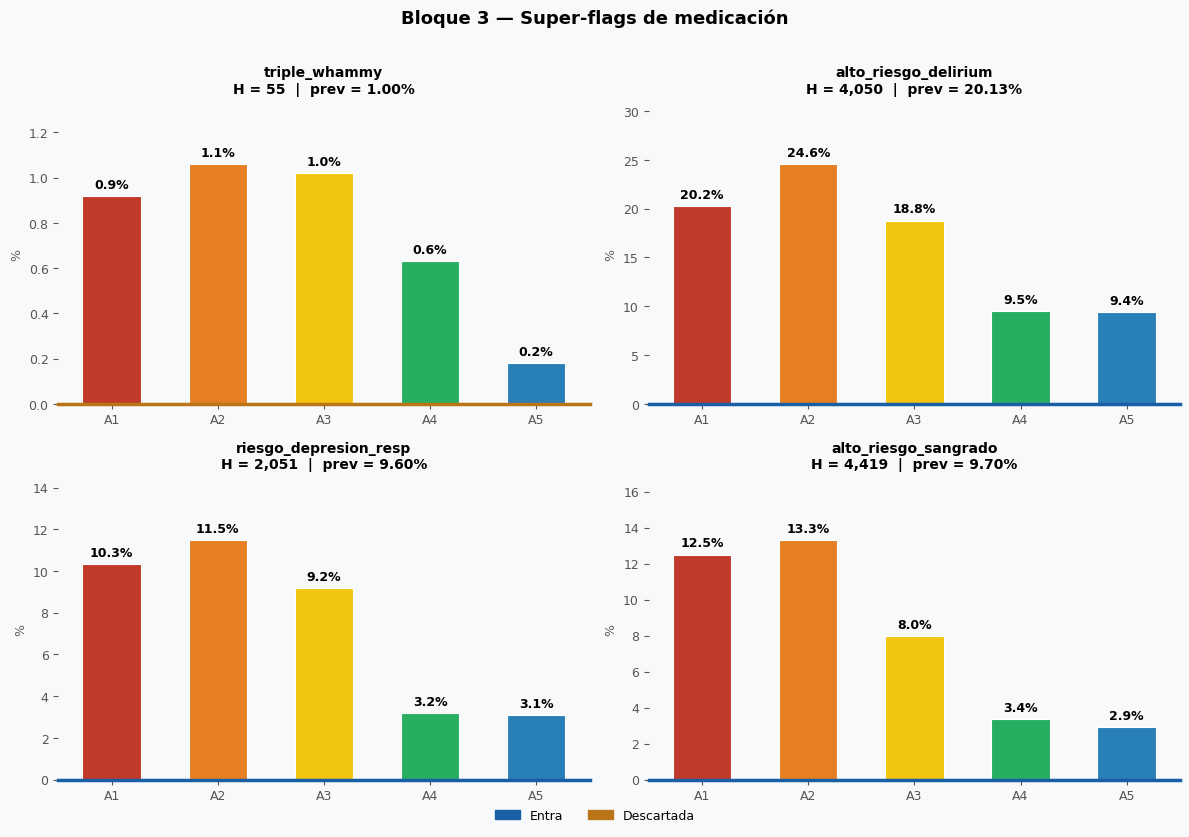

In [126]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor("#F8F9FA")

super_flags = {
    "triple_whammy\nH = 55  |  prev = 1.00%":
        [0.92, 1.06, 1.02, 0.63, 0.18],
    "alto_riesgo_delirium\nH = 4,050  |  prev = 20.13%":
        [20.24, 24.57, 18.78, 9.49, 9.36],
    "riesgo_depresion_resp\nH = 2,051  |  prev = 9.60%":
        [10.35, 11.50, 9.18, 3.17, 3.09],
    "alto_riesgo_sangrado\nH = 4,419  |  prev = 9.70%":
        [12.50, 13.32, 7.99, 3.36, 2.91],
}

decisiones = ["componente", "entra", "entra", "entra"]
colores_acuity = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]
acuity_labels = ["A1", "A2", "A3", "A4", "A5"]

for ax, (titulo, valores), decision in zip(axes.flat, super_flags.items(), decisiones):
    ax.set_facecolor("#F8F9FA")
    bars = ax.bar(acuity_labels, valores, color=colores_acuity,
                  width=0.55, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(valores) * 0.02,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    borde = "#BA7517" if decision == "componente" else "#185FA5"
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color(borde)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.set_title(titulo, fontsize=10, fontweight="bold", pad=8)
    ax.set_ylim(0, max(valores) * 1.25)
    ax.tick_params(colors="#555555", labelsize=9)
    ax.set_ylabel("%", fontsize=9, color="#5F5E5A")

patch_entra = mpatches.Patch(color="#185FA5", label="Entra")
patch_desc  = mpatches.Patch(color="#BA7517", label="Descartada")
fig.legend(handles=[patch_entra, patch_desc], fontsize=9,
           frameon=False, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Bloque 3 — Super-flags de medicación", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("bloque3_superflags.png", dpi=150, bbox_inches="tight")
plt.show()

N MEDICAMENTOS

In [127]:

# Variable continua: número de medicamentos distintos por paciente en medrecon
# Hipótesis: a mayor polifarmacia → mayor comorbilidad → mayor acuity

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "n_medicamentos"].values
    for k in [1, 2, 3, 4, 5]
])

prev = (df["n_medicamentos"] > 0).mean() * 100
n    = int((df["n_medicamentos"] > 0).sum())

print(f"n_medicamentos  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  con medicación = {prev:.2f}%  |  n = {n:,}\n")
print("Mediana por clase de acuity:\n")
print(df.groupby("acuity")["n_medicamentos"].median().round(2).to_string())
print("\nMedia por clase de acuity:\n")
print(df.groupby("acuity")["n_medicamentos"].mean().round(2).to_string())
print("\nDistribución general:\n")
print(df["n_medicamentos"].describe().round(2).to_string())

n_medicamentos  →  H = 16,663  |  p = 0.00e+00  |  con medicación = 73.01%  |  n = 305,273

Mediana por clase de acuity:

acuity
1    4.0
2    6.0
3    3.0
4    1.0
5    0.0

Media por clase de acuity:

acuity
1    6.52
2    7.36
3    5.66
4    2.83
5    2.20

Distribución general:

count    418100.00
mean          6.07
std           6.72
min           0.00
25%           0.00
50%           4.00
75%          10.00
max          67.00


In [128]:
# Umbrales clínicos estándar: polifarmacia ≥5, hiperpolifarmacia ≥10
# sin_medicacion = 0 medicamentos → patrón NMAR (joven/trauma/urgencia aguda)

df["sin_medicacion"]     = (df["n_medicamentos"] == 0).astype("int8")
df["polifarmacia"]       = (df["n_medicamentos"] >= 5).astype("int8")
df["hiperpolifarmacia"]  = (df["n_medicamentos"] >= 10).astype("int8")

for col in ["sin_medicacion", "polifarmacia", "hiperpolifarmacia"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<22}  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}")
    print((df.groupby("acuity")[col].mean() * 100).round(2).to_string())
    print()

sin_medicacion          H = 9,827  |  p = 0.00e+00  |  prevalencia = 26.99%  |  n = 112,827
acuity
1    31.45
2    20.29
3    27.97
4    47.12
5    54.91

polifarmacia            H = 14,685  |  p = 0.00e+00  |  prevalencia = 46.79%  |  n = 195,615
acuity
1    49.91
2    57.00
3    43.49
4    21.44
5    16.18

hiperpolifarmacia       H = 9,247  |  p = 0.00e+00  |  prevalencia = 26.39%  |  n = 110,327
acuity
1    30.21
2    33.65
3    23.73
4     9.40
5     6.27



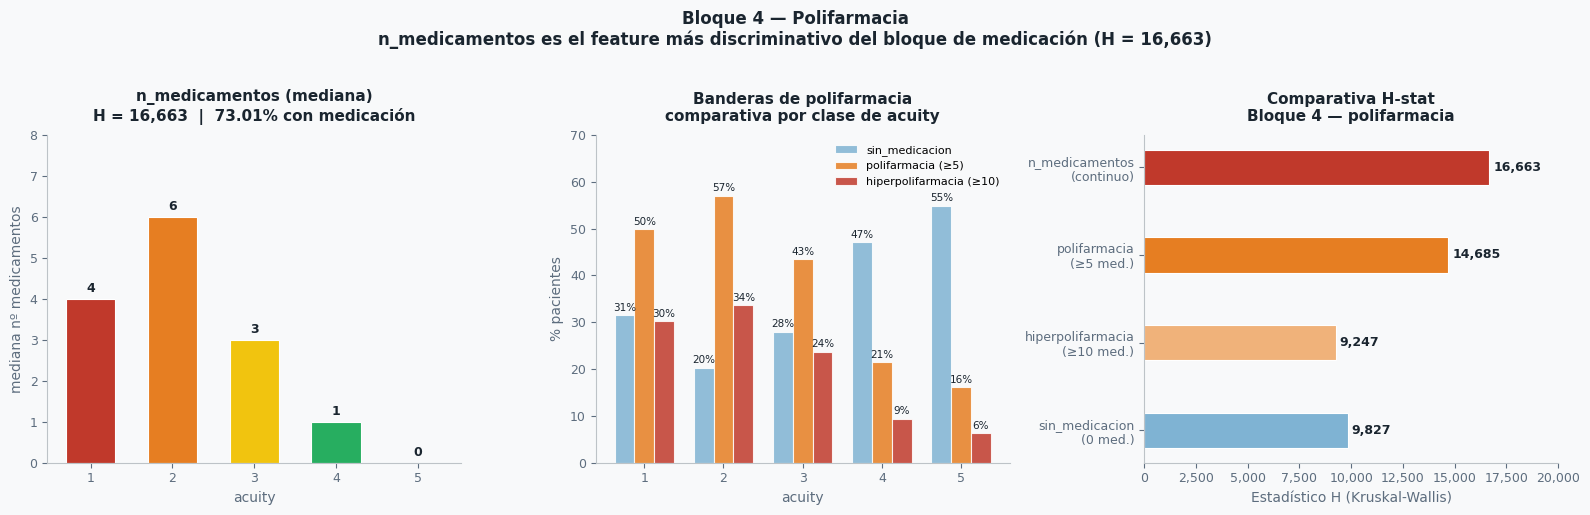

In [129]:
# ── GRÁFICO BLOQUE 4: polifarmacia ────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels  = [1, 2, 3, 4, 5]
colores_barra  = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# ── Izquierda: n_medicamentos mediana por acuity ──────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

medianas = [4.0, 6.0, 3.0, 1.0, 0.0]
bars = ax1.bar(acuity_levels, medianas, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f"{val:.0f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana nº medicamentos", fontsize=10, color="#5D6D7E")
ax1.set_title("n_medicamentos (mediana)\nH = 16,663  |  73.01% con medicación",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xticks(acuity_levels)
ax1.set_ylim(0, 8)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Centro: sin_medicacion vs polifarmacia vs hiperpolifarmacia ───────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_sinmed    = [31.45, 20.29, 27.97, 47.12, 54.91]
pcts_poli      = [49.91, 57.00, 43.49, 21.44, 16.18]
pcts_hiperpoli = [30.21, 33.65, 23.73,  9.40,  6.27]

x     = np.arange(len(acuity_levels))
width = 0.25

bars1 = ax2.bar(x - width, pcts_sinmed,    width, label="sin_medicacion",
                color="#7FB3D3", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax2.bar(x,          pcts_poli,     width, label="polifarmacia (≥5)",
                color="#E67E22", edgecolor="white", linewidth=0.8, alpha=0.85)
bars3 = ax2.bar(x + width,  pcts_hiperpoli, width, label="hiperpolifarmacia (≥10)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)

for bars_group, valores in [(bars1, pcts_sinmed), (bars2, pcts_poli), (bars3, pcts_hiperpoli)]:
    for bar, val in zip(bars_group, valores):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.0f}%", ha="center", va="bottom", fontsize=7.5, color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("Banderas de polifarmacia\ncomparativa por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(acuity_levels)
ax2.set_ylim(0, 70)
ax2.legend(frameon=False, fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# ── Derecha: H-stat comparativa ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features = [
    "sin_medicacion\n(0 med.)",
    "hiperpolifarmacia\n(≥10 med.)",
    "polifarmacia\n(≥5 med.)",
    "n_medicamentos\n(continuo)",
]
hstats = [9827, 9247, 14685, 16663]
cols_h = ["#7FB3D3", "#F0B27A", "#E67E22", "#C0392B"]

bars_h = ax3.barh(features, hstats, color=cols_h,
                  edgecolor="white", linewidth=0.8, height=0.4)

for bar, val in zip(bars_h, hstats):
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f"{val:,}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nBloque 4 — polifarmacia",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, 20000)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Bloque 4 — Polifarmacia\n"
    "n_medicamentos es el feature más discriminativo del bloque de medicación (H = 16,663)",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.savefig("bloque4_polifarmacia.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen Bloque 3 — Medicación (clases 1-17 + super-flags)

### Features que ENTRAN (19)

| Feature | H-stat | Prevalencia |
|---|---|---|
| med_betabloqueante | 10,279 | 22.01% |
| med_antiagregante | 8,275 | 22.56% |
| med_diuretico_asa | 6,746 | 9.75% |
| med_ace_ara2 | 5,141 | 23.03% |
| med_anticoagulante | 5,023 | 7.32% |
| alto_riesgo_sangrado | 4,419 | 9.70% |
| alto_riesgo_delirium | 4,050 | 20.13% |
| med_ssri_snri | 3,344 | 23.35% |
| med_benzodiacepina | 2,809 | 16.39% |
| med_opiaceo | 2,505 | 15.55% |
| med_insulina | 2,490 | 13.22% |
| med_antipsicótico | 2,432 | 8.03% |
| med_anticonvulsivante | 2,366 | 15.31% |
| riesgo_depresion_resp | 2,051 | 9.60% |
| med_respiratorio_inhalado | 1,296 | 14.72% |
| med_antiaritmico | 1,083 | 1.10% |
| med_digoxina | 980 | 0.81% |
| med_corticoide_sistemico | 975 | 2.88% |
| med_antidiabetico_oral | 1,014 | 9.37% |
| med_inmunosupresor | 714 | 1.57% |

### Features DESCARTADAS (3)

| Feature | H-stat | Motivo |
|---|---|---|
| med_aine | 602 | Sin discriminación individual — solo componente de super-flags |
| med_diuretico_tiazida | 248 | Distribución casi plana en acuity 1-3 |
| triple_whammy | 55 | Sin masa estadística suficiente (n demasiado bajo) |

### Patrón general del bloque
Casi todos los flags cardiovasculares y neurológicos presentan el mismo
patrón: pico en acuity 2 (pluripatológico grave) ligeramente por encima de
acuity 1 (trauma/PCR), caída pronunciada hacia acuity 4-5. La excepción es
`med_digoxina`, único flag con máximo en acuity 1.

---

## Resumen Bloque 4 — Polifarmacia

### Features que ENTRAN (4)

| Feature | H-stat | Prevalencia |
|---|---|---|
| n_medicamentos (continuo) | 16,663 | 73.01% con medicación |
| polifarmacia (≥5) | 14,685 | 46.79% |
| sin_medicacion (= 0) | 9,827 | 26.99% |
| hiperpolifarmacia (≥10) | 9,247 | 26.39% |

`n_medicamentos` es el feature más discriminativo de todo el bloque de
medicación. Las flags derivadas complementan al continuo aportando umbrales
clínicos explícitos y el patrón en U de `sin_medicacion`, que identifica
tanto pacientes jóvenes sin comorbilidades (acuity 5) como trauma/PCR sin
historial crónico (acuity 1).

chiefcomplaint


In [130]:
# ── BLOQUE 5 — Paso 1: auditoría de chiefcomplaint ───────────────────────────
# Análisis del vocabulario real antes de definir ningún síndrome
# Incluye: value_counts, unigramas, bigramas y trigramas

from collections import Counter
import re

cc = df["chiefcomplaint"].dropna().str.lower().str.strip()

print(f"Total registros con chiefcomplaint: {cc.shape[0]:,}")
print(f"Registros sin chiefcomplaint (NaN): {df['chiefcomplaint'].isna().sum():,}")
print(f"Valores únicos (columna entera):    {cc.nunique():,}\n")

print("── Top 60 chief complaints exactos ─────────────────────────────────────")
print(cc.value_counts().head(60).to_string())

Total registros con chiefcomplaint: 418,083
Registros sin chiefcomplaint (NaN): 17
Valores únicos (columna entera):    57,458

── Top 60 chief complaints exactos ─────────────────────────────────────
chiefcomplaint
abd pain                    15817
chest pain                  13851
s/p fall                     7435
dyspnea                      7368
headache                     5116
wound eval                   5083
si                           4927
back pain                    4863
etoh                         4646
fever                        3557
altered mental status        3071
lower back pain              3039
dizziness                    3004
weakness                     3003
syncope                      2833
n/v                          2499
mvc                          2377
abnormal labs                2375
seizure                      2304
brbpr                        2293
sore throat                  2179
rash                         2172
ili                          2133
abd

El campo `chiefcomplaint` contiene 418,083 registros con solo 17 valores nulos,
por lo que no hay que contemplar una clase `cc_missing`.
Con 57,458 valores únicos sobre 418K filas, el texto es ruidoso, pero los top 60 términos ya revelan los grandes síndromes clínicos: dolor abdominal, dolor torácico, trauma, disnea, neurológico, psiquiátrico e intoxicación.

In [131]:
# ── BLOQUE 5 — Paso 1b: bigramas y trigramas ─────────────────────────────────
# Tokenizamos cada chief complaint y extraemos n-gramas
# Filtramos stopwords clínicas irrelevantes para no contaminar el conteo

from collections import Counter
import re

stopwords = {"the", "a", "an", "and", "or", "of", "to", "in", "for",
             "with", "on", "at", "by", "from", "is", "was", "be",
             "left", "right", "bilateral", "upper", "lower", "r", "l"}

def tokenizar(texto):
    return [t for t in re.findall(r"[a-z0-9/]+", texto)
            if t not in stopwords and len(t) > 1]

tokens_por_fila = cc.apply(tokenizar)

bigramas  = Counter()
trigramas = Counter()

for tokens in tokens_por_fila:
    for i in range(len(tokens) - 1):
        bigramas[(tokens[i], tokens[i+1])] += 1
    for i in range(len(tokens) - 2):
        trigramas[(tokens[i], tokens[i+1], tokens[i+2])] += 1

print("── Top 40 bigramas ──────────────────────────────────────────────────────")
for ngrama, count in bigramas.most_common(40):
    print(f"  {' '.join(ngrama):<35} {count:>7,}")

print("\n── Top 30 trigramas ─────────────────────────────────────────────────────")
for ngrama, count in trigramas.most_common(30):
    print(f"  {' '.join(ngrama):<45} {count:>7,}")

── Top 40 bigramas ──────────────────────────────────────────────────────
  abd pain                             35,289
  chest pain                           29,013
  s/p fall                             21,728
  back pain                            16,491
  abdominal pain                       12,487
  wound eval                            7,734
  flank pain                            6,462
  leg pain                              6,151
  mental status                         6,084
  altered mental                        5,977
  abnormal labs                         5,260
  knee pain                             5,021
  neck pain                             4,532
  sore throat                           4,405
  pain transfer                         4,222
  foot pain                             4,113
  shoulder pain                         3,787
  leg swelling                          3,655
  pain s/p                              3,450
  hip pain                              3,353
  arm 

In [132]:
# ── BLOQUE 5 — Paso 3: flags de chiefcomplaint (regex auditadas) ──────────────
# 13 síndromes clínicos definidos por impacto fisiológico y riesgo en triaje
# Regex con límites de palabra (\b) para evitar falsos positivos
# Multi-label: un paciente puede tener múltiples flags activas simultáneamente

cc = df["chiefcomplaint"].str.lower().str.strip()

# ── 1. cc_dolor_toracico ──────────────────────────────────────────────────────
df["cc_dolor_toracico"] = cc.str.contains(
    r"\bchest\s*pain\b|\bcp\b|\bchest\s*tightness\b|\bchest\s*pressure\b"
    r"|\bchest\s*discomfort\b|\bangina\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 2. cc_disnea ──────────────────────────────────────────────────────────────
# Añadido "dyspnea on exertion" explícitamente
df["cc_disnea"] = cc.str.contains(
    r"\bdyspnea\b|\bsob\b|\bshortness\s*of\s*breath\b|\bbreathing\b"
    r"|\brespiratory\s*distress\b|\bbreathless\b|\bdyspnea\s*on\s*exertion\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 3. cc_gi_agudo ────────────────────────────────────────────────────────────
df["cc_gi_agudo"] = cc.str.contains(
    r"\babd\s*pain\b|\babdominal\s*pain\b|\bepigastric\b|\brlq\b|\bllq\b"
    r"|\bruq\b|\bn/v\b|\bn/v/d\b|\bnausea\b|\bvomiting\b|\bdiarrhea\b"
    r"|\bgastric\b|\bbowel\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 4. cc_neuro_ams ───────────────────────────────────────────────────────────
# Eliminado \bloc\b — conflicto con "location" en texto libre
df["cc_neuro_ams"] = cc.str.contains(
    r"\baltered\s*mental\s*status\b|\bams\b|\bweakness\b|\bseizure\b"
    r"|\bsyncope\b|\bdizziness\b|\bconfusion\b|\bunresponsive\b"
    r"|\bloss\s*of\s*consciousness\b|\bnumbness\b|\bparalysis\b"
    r"|\bstroke\b|\bcva\b|\btia\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 5. cc_cefalea ─────────────────────────────────────────────────────────────
# Eliminado \bha\b — demasiado ruidoso en texto libre
df["cc_cefalea"] = cc.str.contains(
    r"\bheadache\b|\bhead\s*pain\b|\bmigraine\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 6. cc_trauma ──────────────────────────────────────────────────────────────
# Cinemática explícita — captura "back pain s/p fall", "pain s/p mvc"
df["cc_trauma"] = cc.str.contains(
    r"\bs/p\s*fall\b|\bmvc\b|\bfall\b|\btrauma\b|\binjury\b|\baccident\b"
    r"|\bhead\s*injury\b|\blaceration\b|\bwound\b|\bfracture\b|\bstab\b"
    r"|\bassault\b|\bgsw\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 7. cc_psiquiatrico ────────────────────────────────────────────────────────
df["cc_psiquiatrico"] = cc.str.contains(
    r"\bsi\b|\bsuicidal\b|\bsuicide\b|\banxiety\b|\bpsychiatric\b"
    r"|\bhallucination\b|\bagitation\b|\bdepression\b|\bmania\b"
    r"|\bparanoia\b|\bpsychosis\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 8. cc_intoxicacion ────────────────────────────────────────────────────────
# Eliminado \bod\b — conflicto con "oculus dexter" en urgencias oftalmológicas
df["cc_intoxicacion"] = cc.str.contains(
    r"\betoh\b|\bintoxication\b|\boverdose\b|\bingestion\b"
    r"|\bsubstance\b|\bdrug\s*use\b|\balcohol\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 9. cc_infeccioso ──────────────────────────────────────────────────────────
df["cc_infeccioso"] = cc.str.contains(
    r"\bfever\b|\bili\b|\binfection\b|\bsepsis\b|\bcellulitis\b"
    r"|\bpneumonia\b|\bmeningitis\b|\binfluenza\b|\bcovid\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 10. cc_urologico ──────────────────────────────────────────────────────────
df["cc_urologico"] = cc.str.contains(
    r"\bdysuria\b|\bhematuria\b|\burinary\s*retention\b|\bflank\s*pain\b"
    r"|\buti\b|\bkidney\b|\brenal\b|\bfoley\b|\burinary\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 11. cc_hemorragia_activa ──────────────────────────────────────────────────
df["cc_hemorragia_activa"] = cc.str.contains(
    r"\bbrbpr\b|\brectal\s*bleeding\b|\bgib\b|\bvaginal\s*bleeding\b"
    r"|\bepistaxis\b|\bhemoptysis\b|\bbleeding\b|\bhemorrhage\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 12. cc_alergia_anafilaxia ─────────────────────────────────────────────────
df["cc_alergia_anafilaxia"] = cc.str.contains(
    r"\ballergic\s*reaction\b|\banaphylaxis\b|\ballergy\b|\bangioedema\b"
    r"|\bhives\b|\burticaria\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 13. cc_derivacion_urgente ─────────────────────────────────────────────────
# Añadido \beta\b — aviso previo de llegada de código grave por ambulancia
df["cc_derivacion_urgente"] = cc.str.contains(
    r"\babnormal\s*labs\b|\babnormal\s*ct\b|\babnormal\s*ekg\b"
    r"|\btransfer\b|\breferral\b|\bhyperglycemia\b|\bhypertension\b"
    r"|\bhyponatremia\b|\bhyperkalemia\b|\beta\b",
    case=False, regex=True, na=False
).astype("int8")

# ── H-stats y prevalencias ────────────────────────────────────────────────────
síndromes = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

for col in síndromes:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<25}  H = {stat:>7,.0f}  |  p = {pval:.2e}  |  prev = {prev:.2f}%  |  n = {n:,}")
    print((df.groupby("acuity")[col].mean() * 100).round(2).to_string())
    print()

cc_dolor_toracico          H =  12,707  |  p = 0.00e+00  |  prev = 7.56%  |  n = 31,614
acuity
1     4.48
2    13.86
3     4.95
4     0.24
5     0.18

cc_disnea                  H =  11,774  |  p = 0.00e+00  |  prev = 5.90%  |  n = 24,661
acuity
1    12.35
2    10.43
3     3.15
4     0.16
5     0.27

cc_gi_agudo                H =  18,161  |  p = 0.00e+00  |  prev = 16.63%  |  n = 69,541
acuity
1     5.97
2    10.80
3    23.44
4     0.99
5     0.18

cc_neuro_ams               H =  15,996  |  p = 0.00e+00  |  prev = 10.59%  |  n = 44,277
acuity
1    23.88
2    16.45
3     6.87
4     0.53
5     0.18

cc_cefalea                 H =     890  |  p = 1.95e-191  |  prev = 3.38%  |  n = 14,113
acuity
1    2.03
2    3.18
3    3.95
4    1.03
5    0.27

cc_trauma                  H =   6,071  |  p = 0.00e+00  |  prev = 13.13%  |  n = 54,914
acuity
1    12.01
2     9.71
3    13.66
4    26.64
5    14.18

cc_psiquiatrico            H =  11,976  |  p = 0.00e+00  |  prev = 3.53%  |  n = 14,760
acuity


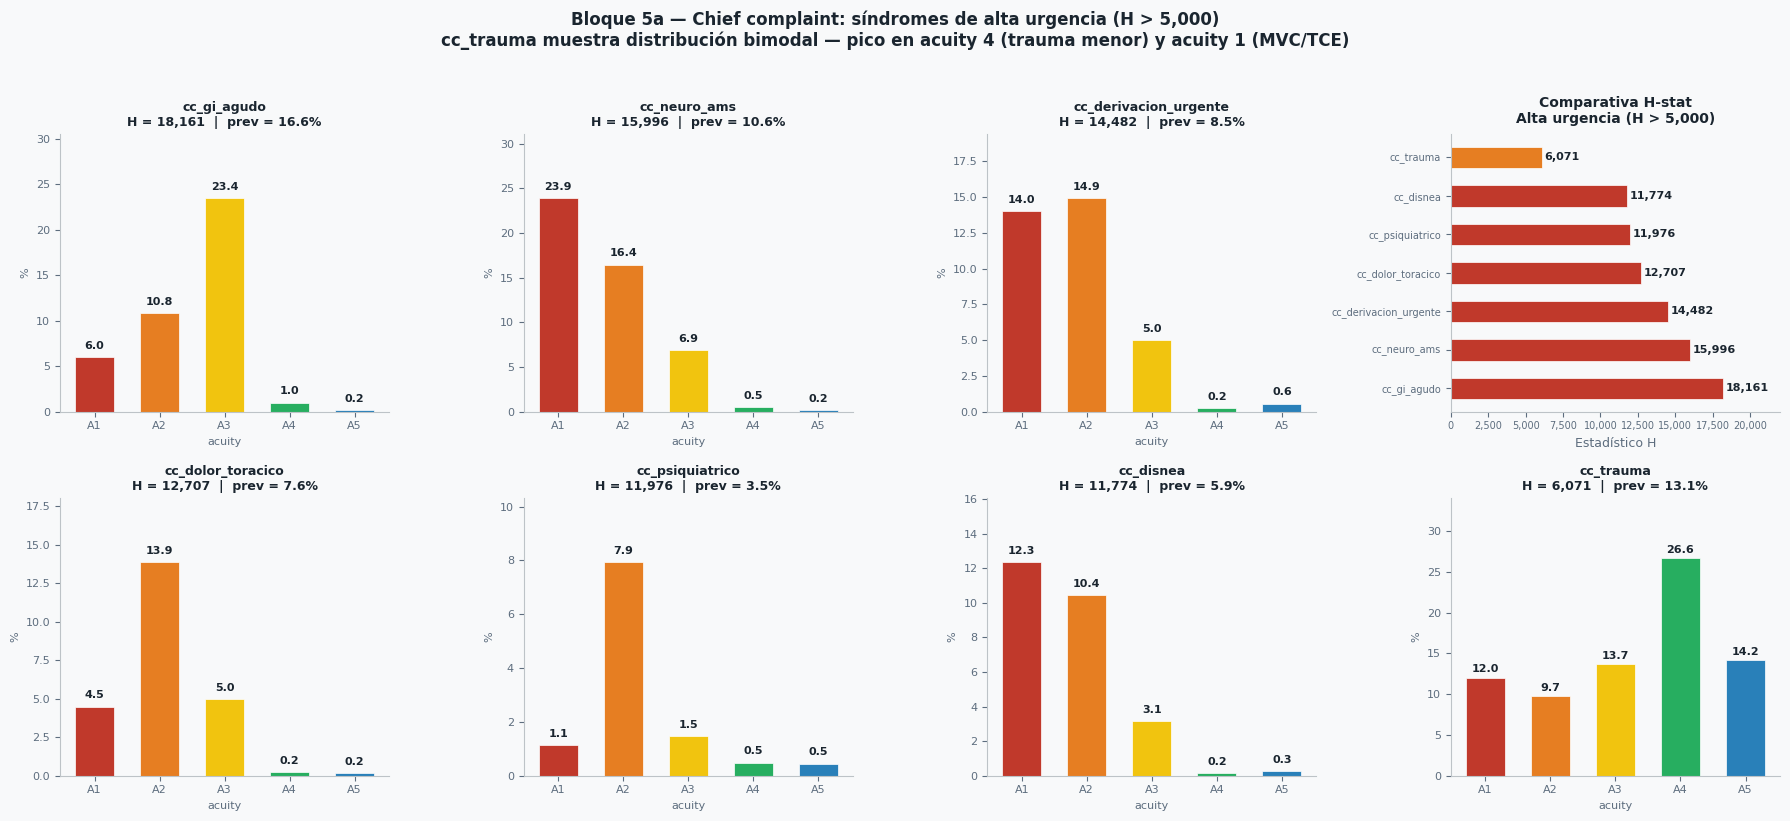

In [133]:
# ── GRÁFICO BLOQUE 5a: síndromes de alta urgencia (H > 5,000) ────────────────

import matplotlib.pyplot as plt
import numpy as np

colores_acuity = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]
acuity_labels  = ["A1", "A2", "A3", "A4", "A5"]

alta_urgencia = {
    "cc_gi_agudo":           ([5.97, 10.80, 23.44, 0.99, 0.18],  18161, 16.63),
    "cc_neuro_ams":          ([23.88, 16.45, 6.87, 0.53, 0.18],  15996, 10.59),
    "cc_derivacion_urgente": ([14.01, 14.92, 4.99, 0.25, 0.55],  14482,  8.49),
    "cc_dolor_toracico":     ([4.48, 13.86, 4.95, 0.24, 0.18],   12707,  7.56),
    "cc_psiquiatrico":       ([1.13, 7.93, 1.46, 0.48, 0.45],    11976,  3.53),
    "cc_disnea":             ([12.35, 10.43, 3.15, 0.16, 0.27],  11774,  5.90),
    "cc_trauma":             ([12.01, 9.71, 13.66, 26.64, 14.18], 6071, 13.13),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor("#F8F9FA")

# ── Panel H-stat ──────────────────────────────────────────────────────────────
ax_h = axes[0, 3]
ax_h.set_facecolor("#F8F9FA")
nombres_h = list(alta_urgencia.keys())
hvals_h   = [v[1] for v in alta_urgencia.values()]
cols_h    = ["#C0392B" if h > 10000 else "#E67E22" for h in hvals_h]

bars_h = ax_h.barh(nombres_h, hvals_h, color=cols_h,
                   edgecolor="white", linewidth=0.5, height=0.55)
for bar, val in zip(bars_h, hvals_h):
    ax_h.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
              f"{val:,}", va="center", ha="left",
              fontsize=8, fontweight="bold", color="#1A252F")
ax_h.set_xlabel("Estadístico H", fontsize=9, color="#5D6D7E")
ax_h.set_title("Comparativa H-stat\nAlta urgencia (H > 5,000)",
               fontsize=10, fontweight="bold", color="#1A252F", pad=8)
ax_h.set_xlim(0, 22000)
ax_h.spines[["top", "right"]].set_visible(False)
ax_h.spines[["left", "bottom"]].set_color("#BDC3C7")
ax_h.tick_params(colors="#5D6D7E", labelsize=7)
ax_h.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── 6 paneles individuales ────────────────────────────────────────────────────
posiciones = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
for (row, col), (sin, (vals, h, prev)) in zip(posiciones, list(alta_urgencia.items())[:6]):
    ax = axes[row, col]
    ax.set_facecolor("#F8F9FA")
    bars = ax.bar(acuity_labels, vals, color=colores_acuity,
                  edgecolor="white", linewidth=0.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.03,
                f"{val:.1f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold", color="#1A252F")
    ax.set_title(f"{sin}\nH = {h:,}  |  prev = {prev:.1f}%",
                 fontsize=9, fontweight="bold", color="#1A252F", pad=6)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_xlabel("acuity", fontsize=8, color="#5D6D7E")
    ax.set_ylabel("%", fontsize=8, color="#5D6D7E")
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(acuity_labels)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=8)

# ── Panel cc_trauma separado (fila 1, col 3) ─────────────────────────────────
ax_t = axes[1, 3]
ax_t.set_facecolor("#F8F9FA")
vals_t = [12.01, 9.71, 13.66, 26.64, 14.18]
bars = ax_t.bar(acuity_labels, vals_t, color=colores_acuity,
                edgecolor="white", linewidth=0.5, width=0.6)
for bar, val in zip(bars, vals_t):
    ax_t.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.4,
              f"{val:.1f}", ha="center", va="bottom",
              fontsize=8, fontweight="bold", color="#1A252F")
ax_t.set_title("cc_trauma\nH = 6,071  |  prev = 13.1%",
               fontsize=9, fontweight="bold", color="#1A252F", pad=6)
ax_t.set_ylim(0, 34)
ax_t.set_xlabel("acuity", fontsize=8, color="#5D6D7E")
ax_t.set_ylabel("%", fontsize=8, color="#5D6D7E")
ax_t.set_xticks([0,1,2,3,4])
ax_t.set_xticklabels(acuity_labels)
ax_t.spines[["top", "right"]].set_visible(False)
ax_t.spines[["left", "bottom"]].set_color("#BDC3C7")
ax_t.tick_params(colors="#5D6D7E", labelsize=8)

fig.suptitle(
    "Bloque 5a — Chief complaint: síndromes de alta urgencia (H > 5,000)\n"
    "cc_trauma muestra distribución bimodal — pico en acuity 4 (trauma menor) y acuity 1 (MVC/TCE)",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)
plt.tight_layout()
plt.savefig("bloque5a_alta_urgencia.png", dpi=150, bbox_inches="tight")
plt.show()

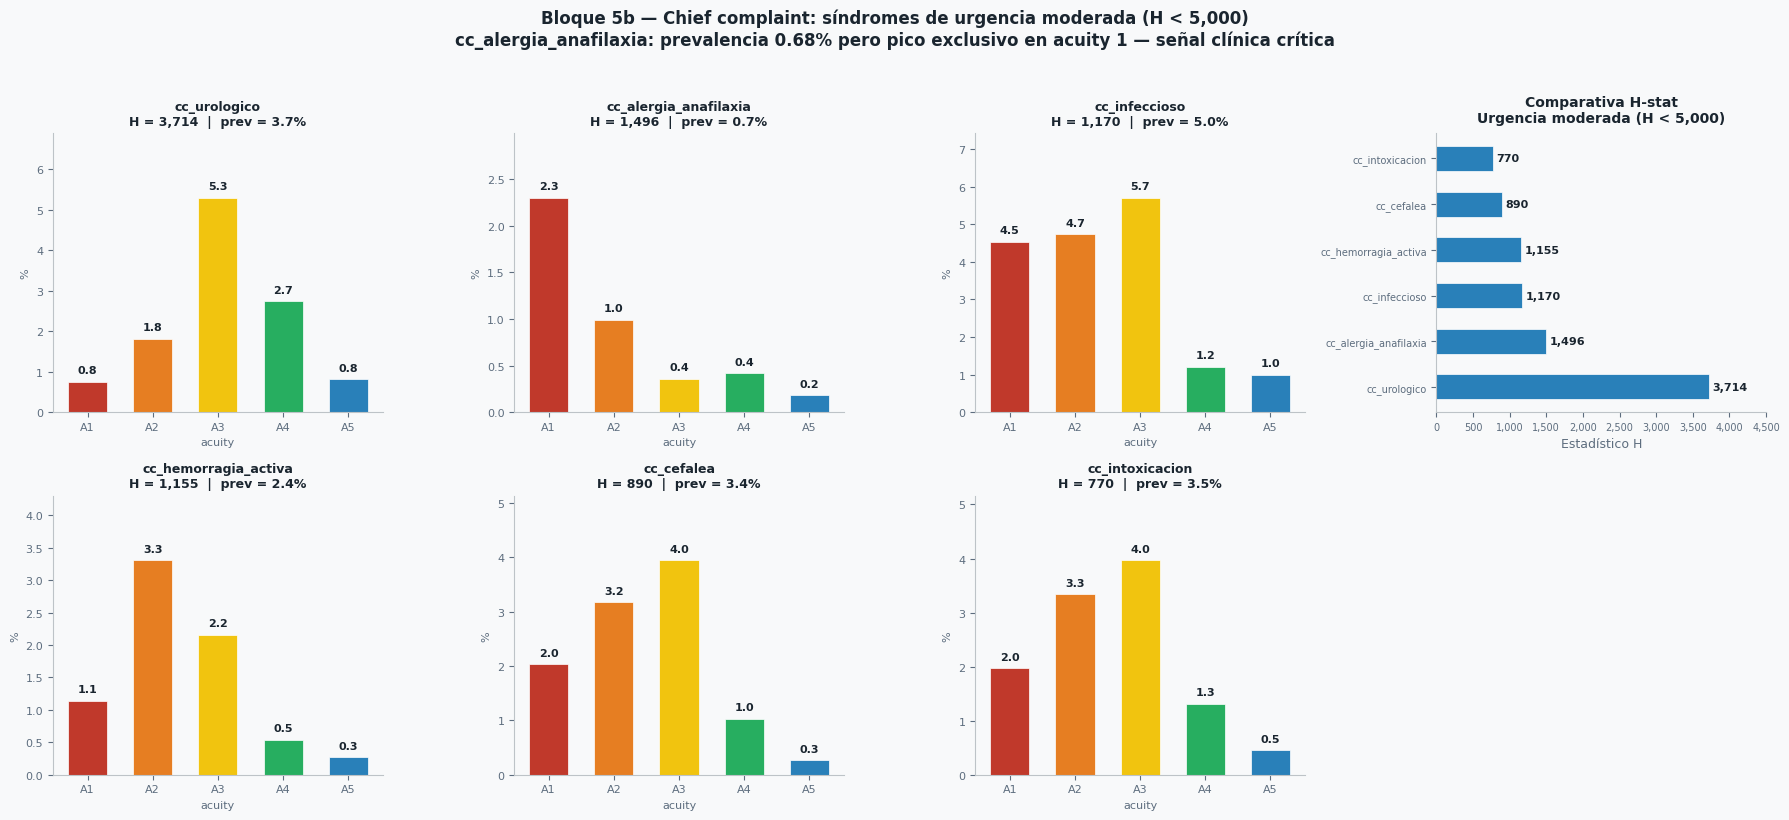

In [134]:
# ── GRÁFICO BLOQUE 5b: síndromes de urgencia moderada (H < 5,000) ─────────────

moderada = {
    "cc_urologico":          ([0.75, 1.81, 5.30, 2.74, 0.82],  3714, 3.69),
    "cc_alergia_anafilaxia": ([2.30, 0.99, 0.36, 0.42, 0.18],  1496, 0.68),
    "cc_infeccioso":         ([4.53, 4.74, 5.71, 1.21, 1.00],  1170, 5.00),
    "cc_hemorragia_activa":  ([1.14, 3.31, 2.16, 0.54, 0.27],  1155, 2.37),
    "cc_cefalea":            ([2.03, 3.18, 3.95, 1.03, 0.27],   890, 3.38),
    "cc_intoxicacion":       ([1.97, 3.34, 3.97, 1.31, 0.45],   770, 3.46),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor("#F8F9FA")

# ── Panel H-stat ──────────────────────────────────────────────────────────────
ax_h = axes[0, 3]
ax_h.set_facecolor("#F8F9FA")
nombres_h = list(moderada.keys())
hvals_h   = [v[1] for v in moderada.values()]

bars_h = ax_h.barh(nombres_h, hvals_h, color="#2980B9",
                   edgecolor="white", linewidth=0.5, height=0.55)
for bar, val in zip(bars_h, hvals_h):
    ax_h.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
              f"{val:,}", va="center", ha="left",
              fontsize=8, fontweight="bold", color="#1A252F")
ax_h.set_xlabel("Estadístico H", fontsize=9, color="#5D6D7E")
ax_h.set_title("Comparativa H-stat\nUrgencia moderada (H < 5,000)",
               fontsize=10, fontweight="bold", color="#1A252F", pad=8)
ax_h.set_xlim(0, 4500)
ax_h.spines[["top", "right"]].set_visible(False)
ax_h.spines[["left", "bottom"]].set_color("#BDC3C7")
ax_h.tick_params(colors="#5D6D7E", labelsize=7)
ax_h.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── 6 paneles individuales ────────────────────────────────────────────────────
posiciones = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
for (row, col), (sin, (vals, h, prev)) in zip(posiciones, moderada.items()):
    ax = axes[row, col]
    ax.set_facecolor("#F8F9FA")
    bars = ax.bar(acuity_labels, vals, color=colores_acuity,
                  edgecolor="white", linewidth=0.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.03,
                f"{val:.1f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold", color="#1A252F")
    ax.set_title(f"{sin}\nH = {h:,}  |  prev = {prev:.1f}%",
                 fontsize=9, fontweight="bold", color="#1A252F", pad=6)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_xlabel("acuity", fontsize=8, color="#5D6D7E")
    ax.set_ylabel("%", fontsize=8, color="#5D6D7E")
    ax.set_xticks([0,1,2,3,4])
    ax.set_xticklabels(acuity_labels)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=8)

# ── Panel vacío (1,3) — ocultar ───────────────────────────────────────────────
axes[1, 3].set_visible(False)

fig.suptitle(
    "Bloque 5b — Chief complaint: síndromes de urgencia moderada (H < 5,000)\n"
    "cc_alergia_anafilaxia: prevalencia 0.68% pero pico exclusivo en acuity 1 — señal clínica crítica",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)
plt.tight_layout()
plt.savefig("bloque5b_urgencia_moderada.png", dpi=150, bbox_inches="tight")
plt.show()


### cc_gi_agudo (H = 18,161 | prev = 16.63%)
Es la flag más frecuente y con mayor H-stat del bloque. El dolor abdominal
domina el acuity 3 (23.4%), lo que refleja que estos pacientes requieren
pruebas urgentes (analítica, ecografía, TAC) pero raramente llegan en
situación crítica inmediata. Su bajo porcentaje en acuity 1 y 5 confirma
que es un síndrome de urgencia media bien delimitado.

### cc_neuro_ams (H = 15,996 | prev = 10.59%)
La alteración del nivel de consciencia es el predictor más potente de
acuity 1 de todo el bloque (23.9%). Agrupa ictus, encefalopatía metabólica,
síncopes y crisis comiciales — todos ellos con riesgo vital inmediato.
Su caída brusca hacia acuity 4-5 confirma que cuando un paciente llega
con alteración neurológica, casi siempre es grave.

### cc_derivacion_urgente (H = 14,482 | prev = 8.49%)
Sorprendentemente potente. Los pacientes derivados por analítica alterada,
TAC patológico o hiperglucemia grave se concentran en acuity 1-2 (14% y
14.9% respectivamente). Esto confirma que cuando un médico de atención
primaria manda a un paciente a urgencias por una anomalía objetiva, el
triaje lo clasifica casi siempre como urgencia mayor.

### cc_dolor_toracico (H = 12,707 | prev = 7.56%)
El clásico de urgencias. Su concentración máxima en acuity 2 (13.9%)
refleja el protocolo estándar de descarte de síndrome coronario agudo:
EKG en 10 minutos, troponinas seriadas, monitorización. Prácticamente
ausente en acuity 4-5 (<0.3%), lo que indica que el dolor torácico
raramente se considera banal en urgencias.

### cc_psiquiatrico (H = 11,976 | prev = 3.53%)
Concentración casi exclusiva en acuity 2 (7.9%), con acuity 1 muy bajo
(1.1%). Tiene sentido: la ideación suicida activa obliga a vigilancia
estrecha y recursos psiquiátricos urgentes, pero el paciente raramente
llega en parada. La casi ausencia en acuity 4-5 confirma que los
motivos psiquiátricos siempre generan clasificaciones de urgencia alta.

### cc_disnea (H = 11,774 | prev = 5.90%)
Es la única flag con pico claro en acuity 1 (12.4%) por encima de acuity 2
(10.4%). La dificultad respiratoria aguda grave lleva directamente al box
de reanimación — insuficiencia respiratoria, broncoespasmo severo o edema
agudo de pulmón no esperan. Caída brusca a partir de acuity 3.

### cc_trauma (H = 6,071 | prev = 13.13%)
La distribución más atípica del bloque: pico en acuity 4 (26.6%) pero con
un 12% en acuity 1. Es un comportamiento bimodal esperado — la mayoría de
traumas son heridas menores y caídas sin consecuencias (acuity 4), pero
los accidentes de tráfico y TCE graves disparan el acuity a 1. Por sí sola
no predice gravedad, pero en combinación con vitales alterados o cc_neuro_ams
se convierte en un predictor potente de acuity 1.

### cc_urologico (H = 3,714 | prev = 3.69%)
Perfil de urgencia media: pico en acuity 3 (5.3%) con presencia residual
en acuity 1 (0.75%). El cólico nefrítico duele mucho pero raramente mata
en minutos. Su valor para el modelo está en la interacción con fiebre e
hipotensión, que señalaría una sepsis urológica obstructiva.

### cc_alergia_anafilaxia (H = 1,496 | prev = 0.68%)
La más infrecuente del bloque pero con el pico más específico en acuity 1
(2.3%). Baja prevalencia, altísima especificidad clínica. Cuando un paciente
llega por reacción alérgica, el riesgo de compromiso de vía aérea y shock
anafiláctico obliga a clasificación inmediata. La decisión de separarlo del
bloque infeccioso ha sido correcta.

### cc_infeccioso (H = 1,170 | prev = 5.00%)
Distribución suave y casi uniforme en acuity 1-3 (4.5-5.7%). La mayoría de
fiebres son procesos virales moderados que no generan urgencia extrema. Su
valor para el modelo no está en predecir acuity de forma independiente, sino
en la interacción con hipotensión, taquicardia y taquipnea — la tríada de
la sepsis que el modelo tiene que aprender a detectar.

### cc_hemorragia_activa (H = 1,155 | prev = 2.37%)
Concentración en acuity 2 (3.3%), con presencia residual en acuity 1 (1.1%).
El sangrado activo visible casi siempre genera clasificación urgente, aunque
el riesgo de shock hipovolémico depende del volumen y la localización. Su
interacción con hipotensión y taquicardia será la señal crítica para el modelo.

### cc_cefalea (H = 890 | prev = 3.38%)
Distribución moderada con pico en acuity 3 (3.95%). La mayoría de cefaleas
en urgencias son tensionales o migrañas, de ahí el H bajo. Sin embargo, se
mantiene como flag independiente por el riesgo de hemorragia subaracnoidea
— el 2% en acuity 1 representa exactamente esos casos de cefalea en trueno
que no pueden pasarse por alto.

### cc_intoxicacion (H = 770 | prev = 3.46%)
El H más bajo del bloque, con distribución casi plana en acuity 1-3 (2-4%).
Las intoxicaciones etílicas leves dominan en acuity 3-4, pero las sobredosis
graves generan acuity 1-2. Su valor para el modelo está en la interacción
con cc_neuro_ams y con la ausencia de medicación crónica — el perfil
típico del paciente joven sin historial que llega en coma etílico.

Cada entrada define la misma feature desde dos perspectivas:
   - REGEX: expresión regular aplicada sobre chiefcomplaint en MIMIC (entrenamiento)
  - LLM:   instrucción en español para el prompt de producción (inferencia)
El LLM devuelve directamente el JSON con los nombres exactos de columna.
No se aplica ningún str.contains en producción.

---

## cc_dolor_toracico
**REGEX (MIMIC):**
`\bchest\s*pain\b|\bcp\b|\bchest\s*tightness\b|\bchest\s*pressure\b|\bchest\s*discomfort\b|\bangina\b`

**LLM (producción):**
Activa `cc_dolor_toracico = 1` si el paciente refiere dolor, presión,
opresión, quemazón o malestar en el pecho, zona precordial o esternal,
incluyendo dolor que irradia al brazo izquierdo, mandíbula o espalda.
También si menciona angina o dolor torácico de cualquier tipo.

---

## cc_disnea
**REGEX (MIMIC):**
`\bdyspnea\b|\bsob\b|\bshortness\s*of\s*breath\b|\bbreathing\b|\brespiratory\s*distress\b|\bbreathless\b|\bdyspnea\s*on\s*exertion\b`

**LLM (producción):**
Activa `cc_disnea = 1` si el paciente refiere dificultad para respirar,
falta de aire, sensación de ahogo, disnea de esfuerzo o en reposo,
o cualquier forma de compromiso respiratorio subjetivo.

---

## cc_gi_agudo
**REGEX (MIMIC):**
`\babd\s*pain\b|\babdominal\s*pain\b|\bepigastric\b|\brlq\b|\bllq\b|\bruq\b|\bn/v\b|\bn/v/d\b|\bnausea\b|\bvomiting\b|\bdiarrhea\b|\bgastric\b|\bbowel\b`

**LLM (producción):**
Activa `cc_gi_agudo = 1` si el paciente refiere dolor abdominal de
cualquier localización (epigástrico, fosa iliaca, hipocondrio, difuso),
náuseas, vómitos, diarrea, o cualquier síntoma digestivo agudo que
motive la consulta.

---

## cc_neuro_ams
**REGEX (MIMIC):**
`\baltered\s*mental\s*status\b|\bams\b|\bweakness\b|\bseizure\b|\bsyncope\b|\bdizziness\b|\bconfusion\b|\bunresponsive\b|\bloss\s*of\s*consciousness\b|\bnumbness\b|\bparalysis\b|\bstroke\b|\bcva\b|\btia\b`

**LLM (producción):**
Activa `cc_neuro_ams = 1` si el paciente presenta alteración del nivel
de consciencia, confusión, desorientación, pérdida de consciencia,
síncope, crisis convulsiva, debilidad o parálisis de extremidades,
entumecimiento, mareo intenso, o sospecha de ictus o AIT.

---

## cc_cefalea
**REGEX (MIMIC):**
`\bheadache\b|\bhead\s*pain\b|\bmigraine\b`

**LLM (producción):**
Activa `cc_cefalea = 1` si el paciente refiere dolor de cabeza como
motivo principal de consulta, incluyendo migraña, cefalea tensional,
o cefalea de inicio brusco ("la peor de su vida").

---

## cc_trauma
**REGEX (MIMIC):**
`\bs/p\s*fall\b|\bmvc\b|\bfall\b|\btrauma\b|\binjury\b|\baccident\b|\bhead\s*injury\b|\blaceration\b|\bwound\b|\bfracture\b|\bstab\b|\bassault\b|\bgsw\b`

**LLM (producción):**
Activa `cc_trauma = 1` si existe un mecanismo lesional explícito:
caída, accidente de tráfico, traumatismo directo, herida por arma
blanca o de fuego, agresión física, o cualquier lesión secundaria
a un traumatismo. Incluye heridas, laceraciones y fracturas.

---

## cc_psiquiatrico
**REGEX (MIMIC):**
`\bsi\b|\bsuicidal\b|\bsuicide\b|\banxiety\b|\bpsychiatric\b|\bhallucination\b|\bagitation\b|\bdepression\b|\bmania\b|\bparanoia\b|\bpsychosis\b`

**LLM (producción):**
Activa `cc_psiquiatrico = 1` si el motivo de consulta es de naturaleza
psiquiátrica: ideación suicida, intento autolítico, crisis de ansiedad,
agitación psicomotriz, alucinaciones, episodio maníaco, brote psicótico
o cualquier descompensación de enfermedad mental.

---

## cc_intoxicacion
**REGEX (MIMIC):**
`\betoh\b|\bintoxication\b|\boverdose\b|\bingestion\b|\bsubstance\b|\bdrug\s*use\b|\balcohol\b`

**LLM (producción):**
Activa `cc_intoxicacion = 1` si el paciente llega por intoxicación
etílica aguda, sobredosis de fármacos o drogas, ingesta de tóxicos,
o consumo de sustancias psicoactivas como motivo principal de consulta.

---

## cc_infeccioso
**REGEX (MIMIC):**
`\bfever\b|\bili\b|\binfection\b|\bsepsis\b|\bcellulitis\b|\bpneumonia\b|\bmeningitis\b|\binfluenza\b|\bcovid\b`

**LLM (producción):**
Activa `cc_infeccioso = 1` si el paciente presenta fiebre, síndrome
gripal, infección activa de cualquier localización (respiratoria,
cutánea, urinaria, sistémica), o sospecha de sepsis como motivo
principal de consulta.

---

## cc_urologico
**REGEX (MIMIC):**
`\bdysuria\b|\bhematuria\b|\burinary\s*retention\b|\bflank\s*pain\b|\buti\b|\bkidney\b|\brenal\b|\bfoley\b|\burinary\b`

**LLM (producción):**
Activa `cc_urologico = 1` si el paciente refiere dolor en el flanco
o fosa renal, escozor al orinar, sangre en orina, imposibilidad para
orinar, o cualquier síntoma del tracto urinario como motivo principal
de consulta.

---

## cc_hemorragia_activa
**REGEX (MIMIC):**
`\bbrbpr\b|\brectal\s*bleeding\b|\bgib\b|\bvaginal\s*bleeding\b|\bepistaxis\b|\bhemoptysis\b|\bbleeding\b|\bhemorrhage\b`

**LLM (producción):**
Activa `cc_hemorragia_activa = 1` si el paciente presenta sangrado
activo visible: sangrado rectal, hemorragia digestiva, sangrado
vaginal, epistaxis, hemoptisis, o cualquier hemorragia externa
activa como motivo de consulta.

---

## cc_alergia_anafilaxia
**REGEX (MIMIC):**
`\ballergic\s*reaction\b|\banaphylaxis\b|\ballergy\b|\bangioedema\b|\bhives\b|\burticaria\b`

**LLM (producción):**
Activa `cc_alergia_anafilaxia = 1` si el paciente llega por reacción
alérgica de cualquier grado, urticaria, angioedema, o sospecha de
anafilaxia. Incluye reacciones a fármacos, alimentos, picaduras
o cualquier otro alérgeno.

---

## cc_derivacion_urgente
**REGEX (MIMIC):**
`\babnormal\s*labs\b|\babnormal\s*ct\b|\babnormal\s*ekg\b|\btransfer\b|\breferral\b|\bhyperglycemia\b|\bhypertension\b|\bhyponatremia\b|\bhyperkalemia\b|\beta\b`

**LLM (producción):**
Activa `cc_derivacion_urgente = 1` si el paciente es derivado desde
atención primaria, otro centro, o llega por aviso previo de emergencias
debido a una anomalía objetiva ya detectada: analítica alterada,
prueba de imagen patológica, ECG anormal, hiperglucemia grave,
alteración electrolítica severa, o aviso de llegada de código urgente.

In [135]:
# ── BLOQUE 5 — Paso 4c: construcción de muestra híbrida ──────────────────────
# 200 filas estratificadas por acuity (40 por nivel) +
# 50 positivos garantizados para cada flag rara (prevalencia < 2%)
# Deduplicación final para no repetir filas
# random_state=42

FLAGS_RARAS = [
    "cc_alergia_anafilaxia",
    "cc_hemorragia_activa",
    "cc_intoxicacion",
    "cc_psiquiatrico"
]

cols = ["stay_id", "acuity", "chiefcomplaint"] + FLAGS

# ── base estratificada por acuity ─────────────────────────────────────────────
base = (
    df[cols]
    .dropna(subset=["chiefcomplaint"])
    .groupby("acuity", group_keys=False)[cols]
    .apply(lambda x: x.sample(n=40, random_state=42))
    .reset_index(drop=True)
)

# ── positivos garantizados por flag rara ──────────────────────────────────────
extras = []
for flag in FLAGS_RARAS:
    positivos = (
        df[cols]
        .dropna(subset=["chiefcomplaint"])
        .loc[df[flag] == 1]
        .sample(n=50, random_state=42)
    )
    extras.append(positivos)

muestra_hibrida = (
    pd.concat([base] + extras, ignore_index=True)
    .drop_duplicates(subset=["stay_id"])
    .reset_index(drop=True)
)

print(f"Total muestra híbrida: {len(muestra_hibrida):,} filas\n")
print("Distribución por acuity:")
print(muestra_hibrida["acuity"].value_counts().sort_index().to_string())
print("\nPositivos por flag rara:")
for flag in FLAGS_RARAS:
    n = muestra_hibrida[flag].sum()
    print(f"  {flag:<25} {n:>3} positivos")

Total muestra híbrida: 400 filas

Distribución por acuity:
acuity
1     56
2    140
3    119
4     45
5     40

Positivos por flag rara:
  cc_alergia_anafilaxia      52 positivos
  cc_hemorragia_activa       55 positivos
  cc_intoxicacion            59 positivos
  cc_psiquiatrico            61 positivos


In [136]:
# ── test rápido: una sola llamada a Groq ──────────────────────────────────────
import time

inicio = time.time()
resultado = clasificar_llm("chest pain")
fin = time.time()

print(f"Resultado: {resultado}")
print(f"Tiempo: {fin - inicio:.2f} segundos")

NameError: name 'clasificar_llm' is not defined

In [ ]:
# ── BLOQUE 5 — Paso 4d v2: clasificación LLM con prompt reducido (Groq) ───────
# Prompt corto para reducir latencia — reglas en inglés para evitar cross-lingual
# Modelo: llama-3.1-8b-instant | 400 filas | objetivo <5 minutos

import requests
import json
import time
from tqdm import tqdm

GROQ_API_KEY = "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"
GROQ_URL     = "https://api.groq.com/openai/v1/chat/completions"

SYSTEM_PROMPT_CORTO = """Classify the emergency chief complaint. 
Return ONLY a JSON object with these 13 keys set to 0 or 1:

cc_dolor_toracico: chest pain, angina, cp, chest tightness
cc_disnea: sob, shortness of breath, dyspnea, breathing difficulty
cc_gi_agudo: abd pain, abdominal pain, nausea, vomiting, diarrhea, n/v, epigastric
cc_neuro_ams: ams, altered mental status, syncope, seizure, weakness, stroke, dizziness, confusion
cc_cefalea: headache, migraine, head pain
cc_trauma: fall, s/p fall, mvc, injury, laceration, wound, fracture, assault, gsw
cc_psiquiatrico: si, suicidal, anxiety, agitation, psychosis, hallucination, depression
cc_intoxicacion: etoh, overdose, intoxication, alcohol, ingestion
cc_infeccioso: fever, infection, sepsis, ili, cellulitis, pneumonia
cc_urologico: flank pain, dysuria, hematuria, urinary retention, uti
cc_hemorragia_activa: brbpr, bleeding, epistaxis, hemoptysis, vaginal bleeding, gib
cc_alergia_anafilaxia: allergic reaction, anaphylaxis, hives, angioedema, urticaria
cc_derivacion_urgente: transfer, abnormal labs, abnormal ct, abnormal ekg, hyperglycemia, hypertension, eta

Rules:
- Multiple keys can be 1 simultaneously.
- If not mentioned or denied, value is 0.
- Return ONLY the JSON object, no other text.

Example for 'chest pain and shortness of breath':
{"cc_dolor_toracico":1,"cc_disnea":1,"cc_gi_agudo":0,"cc_neuro_ams":0,"cc_cefalea":0,"cc_trauma":0,"cc_psiquiatrico":0,"cc_intoxicacion":0,"cc_infeccioso":0,"cc_urologico":0,"cc_hemorragia_activa":0,"cc_alergia_anafilaxia":0,"cc_derivacion_urgente":0}"""

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

def clasificar_llm(texto, max_reintentos=3, system_prompt=SYSTEM_PROMPT_CORTO):
    for intento in range(max_reintentos):
        try:
            resp = requests.post(
                GROQ_URL,
                headers={
                    "Authorization": f"Bearer {GROQ_API_KEY}",
                    "Content-Type":  "application/json"
                },
                json={
                    "model":    "llama-3.1-8b-instant",
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user",   "content": f"Chief complaint: {texto}"}
                    ],
                    "temperature": 0,
                    "seed":        42,
                    "max_tokens":  120
                },
                timeout=30
            )
            contenido = resp.json()["choices"][0]["message"]["content"].strip()
            contenido = contenido.replace("```json", "").replace("```", "").strip()
            parsed    = json.loads(contenido)
            if all(k in parsed for k in FLAGS):
                return {k: int(parsed[k]) for k in FLAGS}
        except Exception:
            time.sleep(1)
    return None

# ── test de velocidad antes del batch ─────────────────────────────────────────
inicio = time.time()
test   = clasificar_llm("chest pain")
fin    = time.time()
print(f"Test OK: {test is not None} | Tiempo: {fin - inicio:.2f}s\n")

# ── batch ─────────────────────────────────────────────────────────────────────
resultados_llm = []
errores        = 0

for idx, (_, row) in enumerate(tqdm(muestra_hibrida.iterrows(),
                                     total=len(muestra_hibrida),
                                     desc="Clasificando (Groq)")):
    resultado = clasificar_llm(row["chiefcomplaint"])
    if resultado is None:
        errores += 1
        resultado = {k: -1 for k in FLAGS}
    resultados_llm.append(resultado)

    # pausa cada 25 requests para respetar rate limit
    if (idx + 1) % 25 == 0:
        time.sleep(1)

df_llm = pd.DataFrame(resultados_llm)
df_llm.columns = [f"{c}_llm" for c in df_llm.columns]

muestra_alineacion = pd.concat(
    [muestra_hibrida.reset_index(drop=True), df_llm], axis=1
)

print(f"\nClasificaciones completadas: {len(muestra_hibrida) - errores:,} / {len(muestra_hibrida):,}")
print(f"Errores / timeouts:          {errores:,}")

muestra_alineacion.to_parquet("muestra_alineacion_hibrida.parquet", index=False)
print("Guardado: muestra_alineacion_hibrida.parquet")

Test OK: True | Tiempo: 0.63s



Clasificando (Groq): 100%|██████████| 400/400 [19:27<00:00,  2.92s/it]


Clasificaciones completadas: 214 / 400
Errores / timeouts:          186
Guardado: muestra_alineacion_hibrida.parquet


In [137]:
# ── BLOQUE 5 — Paso 5: métricas de alineación regex vs LLM ───────────────────
from sklearn.metrics import f1_score, recall_score, precision_score, cohen_kappa_score
import pandas as pd
import numpy as np

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

# filtrar filas sin errores (-1)
mask = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] != -1).all(axis=1)
df_eval = muestra_alineacion[mask].copy()
print(f"Filas válidas para evaluación: {mask.sum()} / {len(muestra_alineacion)}\n")

resultados = []
for flag in FLAGS:
    y_true = df_eval[flag].values
    y_pred = df_eval[f"{flag}_llm"].values

    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    n_pos_true = y_true.sum()
    n_pos_pred = y_pred.sum()

    resultados.append({
        "flag": flag,
        "F1":        round(f1,    3),
        "Precision": round(prec,  3),
        "Recall":    round(rec,   3),
        "Kappa":     round(kappa, 3) if not np.isnan(kappa) else "NaN",
        "n_pos_regex": int(n_pos_true),
        "n_pos_llm":   int(n_pos_pred),
    })

df_res = pd.DataFrame(resultados).sort_values("F1", ascending=False)
print(df_res.to_string(index=False))

Filas válidas para evaluación: 397 / 400

                 flag    F1  Precision  Recall  Kappa  n_pos_regex  n_pos_llm
    cc_dolor_toracico 1.000      1.000   1.000  1.000           17         17
 cc_hemorragia_activa 0.965      0.932   1.000  0.959           55         59
      cc_intoxicacion 0.959      0.921   1.000  0.951           58         63
cc_derivacion_urgente 0.923      0.857   1.000  0.919           18         21
cc_alergia_anafilaxia 0.912      0.839   1.000  0.898           52         62
          cc_gi_agudo 0.897      0.812   1.000  0.884           39         48
      cc_psiquiatrico 0.855      0.756   0.983  0.825           60         78
            cc_disnea 0.800      0.667   1.000  0.792           12         18
            cc_trauma 0.673      0.507   1.000  0.631           34         67
        cc_infeccioso 0.667      0.500   1.000  0.660            6         12
         cc_urologico 0.667      0.500   1.000  0.657            8         16
           cc_cefalea 

In [138]:
# ── diagnóstico de errores ────────────────────────────────────────────────────
mask_errores = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] == -1).any(axis=1)
df_errores   = muestra_alineacion[mask_errores][["acuity", "chiefcomplaint"]].copy()

print(f"Total errores: {mask_errores.sum()}\n")
print("Distribución por acuity:")
print(df_errores["acuity"].value_counts().sort_index().to_string())
print("\nEjemplos de chiefcomplaint con error:")
print(df_errores["chiefcomplaint"].sample(20, random_state=42).to_string())

Total errores: 3

Distribución por acuity:
acuity
2    1
3    1
5    1

Ejemplos de chiefcomplaint con error:


ValueError: Cannot take a larger sample than population when 'replace=False'

In [139]:
# ── diagnóstico: qué error devuelve Groq en los fallos ───────────────────────
def clasificar_llm_debug(texto):
    try:
        resp = requests.post(
            GROQ_URL,
            headers={
                "Authorization": f"Bearer {GROQ_API_KEY}",
                "Content-Type":  "application/json"
            },
            json={
                "model":    "llama-3.1-8b-instant",
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT_CORTO},
                    {"role": "user",   "content": f"Chief complaint: {texto}"}
                ],
                "temperature": 0,
                "seed":        42,
                "max_tokens":  120
            },
            timeout=30
        )
        print(f"Status: {resp.status_code}")
        print(f"Response: {resp.text[:300]}")
    except Exception as e:
        print(f"Excepción: {e}")

clasificar_llm_debug("Chest pain")

Excepción: name 'requests' is not defined


In [140]:
# ── relanzar solo filas con error (-1) ───────────────────────────────────────
import random

mask_errores = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] == -1).any(axis=1)
indices_error = muestra_alineacion[mask_errores].index.tolist()
print(f"Filas a relanzar: {len(indices_error)}")

def clasificar_llm_backoff(texto, max_reintentos=5):
    for intento in range(max_reintentos):
        try:
            resp = requests.post(
                GROQ_URL,
                headers={
                    "Authorization": f"Bearer {GROQ_API_KEY}",
                    "Content-Type":  "application/json"
                },
                json={
                    "model":    "llama-3.1-8b-instant",
                    "messages": [
                        {"role": "system", "content": SYSTEM_PROMPT_CORTO},
                        {"role": "user",   "content": f"Chief complaint: {texto}"}
                    ],
                    "temperature": 0,
                    "seed":        42,
                    "max_tokens":  120
                },
                timeout=30
            )
            # detectar rate limit explícitamente
            if resp.status_code == 429:
                wait = 2 ** intento + random.uniform(0, 1)
                print(f"  Rate limit — esperando {wait:.1f}s")
                time.sleep(wait)
                continue

            contenido = resp.json()["choices"][0]["message"]["content"].strip()
            contenido = contenido.replace("```json", "").replace("```", "").strip()
            parsed    = json.loads(contenido)
            if all(k in parsed for k in FLAGS):
                return {k: int(parsed[k]) for k in FLAGS}
        except Exception:
            wait = 2 ** intento + random.uniform(0, 1)
            time.sleep(wait)
    return None

# ── relanzar con pausa entre requests ────────────────────────────────────────
errores_restantes = 0

for idx in tqdm(indices_error, desc="Relanzando errores"):
    texto     = muestra_alineacion.loc[idx, "chiefcomplaint"]
    resultado = clasificar_llm_backoff(texto)

    if resultado is None:
        errores_restantes += 1
    else:
        for flag in FLAGS:
            muestra_alineacion.loc[idx, f"{flag}_llm"] = resultado[flag]

    time.sleep(2)  # conservador para no volver a saturar

print(f"\nErrores restantes: {errores_restantes}")

muestra_alineacion.to_parquet("muestra_alineacion_hibrida.parquet", index=False)
print("Guardado: muestra_alineacion_hibrida.parquet")

Filas a relanzar: 3


NameError: name 'tqdm' is not defined

In [141]:
# ── BLOQUE 5 — Paso 5 v2: métricas tras relanzar errores ─────────────────────
from sklearn.metrics import f1_score, recall_score, precision_score, cohen_kappa_score
import numpy as np

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

mask = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] != -1).all(axis=1)
df_eval = muestra_alineacion[mask].copy()
print(f"Filas válidas: {mask.sum()} / {len(muestra_alineacion)}\n")

resultados = []
for flag in FLAGS:
    y_true = df_eval[flag].values
    y_pred = df_eval[f"{flag}_llm"].values
    f1    = f1_score(y_true, y_pred, zero_division=0)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    resultados.append({
        "flag":        flag,
        "F1":          round(f1,    3),
        "Precision":   round(prec,  3),
        "Recall":      round(rec,   3),
        "Kappa":       round(kappa, 3) if not np.isnan(kappa) else "NaN",
        "n_pos_regex": int(y_true.sum()),
        "n_pos_llm":   int(y_pred.sum()),
    })

df_res = pd.DataFrame(resultados).sort_values("F1", ascending=False)
print(df_res.to_string(index=False))

# errores restantes
mask_err = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] == -1).any(axis=1)
print(f"\nErrores restantes: {mask_err.sum()}")

Filas válidas: 397 / 400

                 flag    F1  Precision  Recall  Kappa  n_pos_regex  n_pos_llm
    cc_dolor_toracico 1.000      1.000   1.000  1.000           17         17
 cc_hemorragia_activa 0.965      0.932   1.000  0.959           55         59
      cc_intoxicacion 0.959      0.921   1.000  0.951           58         63
cc_derivacion_urgente 0.923      0.857   1.000  0.919           18         21
cc_alergia_anafilaxia 0.912      0.839   1.000  0.898           52         62
          cc_gi_agudo 0.897      0.812   1.000  0.884           39         48
      cc_psiquiatrico 0.855      0.756   0.983  0.825           60         78
            cc_disnea 0.800      0.667   1.000  0.792           12         18
            cc_trauma 0.673      0.507   1.000  0.631           34         67
        cc_infeccioso 0.667      0.500   1.000  0.660            6         12
         cc_urologico 0.667      0.500   1.000  0.657            8         16
           cc_cefalea 0.545      0.375

In [142]:
# Analizar falsos negativos de la RegEx (LLM=1, RegEx=0) en las banderas conflictivas
banderas_a_revisar = [
    "cc_neuro_ams",
    "cc_cefalea",
    "cc_urologico",
    "cc_infeccioso",
    "cc_trauma",
    "cc_disnea",
    "cc_psiquiatrico"
]

for flag in banderas_a_revisar:
    flag_llm = f"{flag}_llm"
    
    # Filtramos donde LLM vio el síndrome, pero la RegEx falló
    discrepancias = muestra_alineacion[
        (muestra_alineacion[flag] == 0) & 
        (muestra_alineacion[flag_llm] == 1)
    ]
    
    if len(discrepancias) > 0:
        print(f"\n--- Discrepancias para {flag} ({len(discrepancias)} casos) ---")
        # Mostramos una muestra aleatoria (o todas si son menos de 15)
        muestra_textos = discrepancias["chiefcomplaint"].sample(min(15, len(discrepancias)), random_state=42)
        for idx, texto in muestra_textos.items():
            print(f"[{idx}] {texto}")
    else:
         print(f"\n--- ¡{flag} perfecta! 0 discrepancias ---")


--- Discrepancias para cc_neuro_ams (47 casos) ---
[327] Agitation, ETOH, Substance use
[363] N/V  ANXIETY
[323] ETOH, Unable to ambulate
[375] Abd pain, Psychosis
[320] ETOH, Unsteady gait
[354] Allergic reaction, Anxiety
[78] Abnormal sodium level, Tremor
[153] Unable to ambulate
[24] Headache, Visual changes
[322] ETOH, Unable to ambulate
[37] Unsteady gait
[18] Slurred speech
[30] AGGITATED
[366] AH, HI, SI
[340] ETOH, Unable to ambulate

--- Discrepancias para cc_cefalea (5 casos) ---
[119] s/p Fall, Head injury
[169] EARACHE
[120] JAW/EAR PAIN
[110] Assault, Head injury
[152] Eye pain

--- Discrepancias para cc_urologico (8 casos) ---
[56] R Ankle pain, Agitation
[140] GU
[46] Testicular pain
[268] Pelvic pain, Vaginal bleeding
[91] R Ankle pain, R Ankle swelling
[123] L Hip pain
[111] Hypertension
[199] R KNEE PAIN

--- Discrepancias para cc_infeccioso (6 casos) ---
[92] Cough, Dyspnea
[138] Abscess
[293] Hemoptysis
[166] RUNNY NOSE
[174] BITES
[169] EARACHE

--- Discrepancias 

AJUSTAMOS TANTO EL REGEX COMO EL PROMPT

In [143]:
# ── BLOQUE 5 — Paso 5: cargar resultados de alineación desde disco ────────────
# Ejecutar esta celda en lugar de volver a llamar a la API
# El parquet contiene las 400 filas con flags regex + flags LLM ya calculadas

import pandas as pd

muestra_alineacion = pd.read_parquet("muestra_alineacion_hibrida.parquet")

print(f"Cargado: {len(muestra_alineacion):,} filas | {muestra_alineacion.shape[1]} columnas")
print(f"\nColumnas LLM disponibles:")
cols_llm = [c for c in muestra_alineacion.columns if c.endswith("_llm")]
print(cols_llm)
print(f"\nErrores restantes (-1): {(muestra_alineacion[cols_llm] == -1).any(axis=1).sum()}")

Cargado: 400 filas | 29 columnas

Columnas LLM disponibles:
['cc_dolor_toracico_llm', 'cc_disnea_llm', 'cc_gi_agudo_llm', 'cc_neuro_ams_llm', 'cc_cefalea_llm', 'cc_trauma_llm', 'cc_psiquiatrico_llm', 'cc_intoxicacion_llm', 'cc_infeccioso_llm', 'cc_urologico_llm', 'cc_hemorragia_activa_llm', 'cc_alergia_anafilaxia_llm', 'cc_derivacion_urgente_llm']

Errores restantes (-1): 3


Filas válidas: 397 / 400

                 flag    F1  Precision  Recall  Kappa  n_pos_regex  n_pos_llm
    cc_dolor_toracico 1.000      1.000   1.000  1.000           17         17
 cc_hemorragia_activa 0.965      0.932   1.000  0.959           55         59
      cc_intoxicacion 0.959      0.921   1.000  0.951           58         63
cc_derivacion_urgente 0.923      0.857   1.000  0.919           18         21
cc_alergia_anafilaxia 0.912      0.839   1.000  0.898           52         62
          cc_gi_agudo 0.897      0.812   1.000  0.884           39         48
      cc_psiquiatrico 0.855      0.756   0.983  0.825           60         78
            cc_disnea 0.800      0.667   1.000  0.792           12         18
            cc_trauma 0.673      0.507   1.000  0.631           34         67
        cc_infeccioso 0.667      0.500   1.000  0.660            6         12
         cc_urologico 0.667      0.500   1.000  0.657            8         16
           cc_cefalea 0.545      0.375

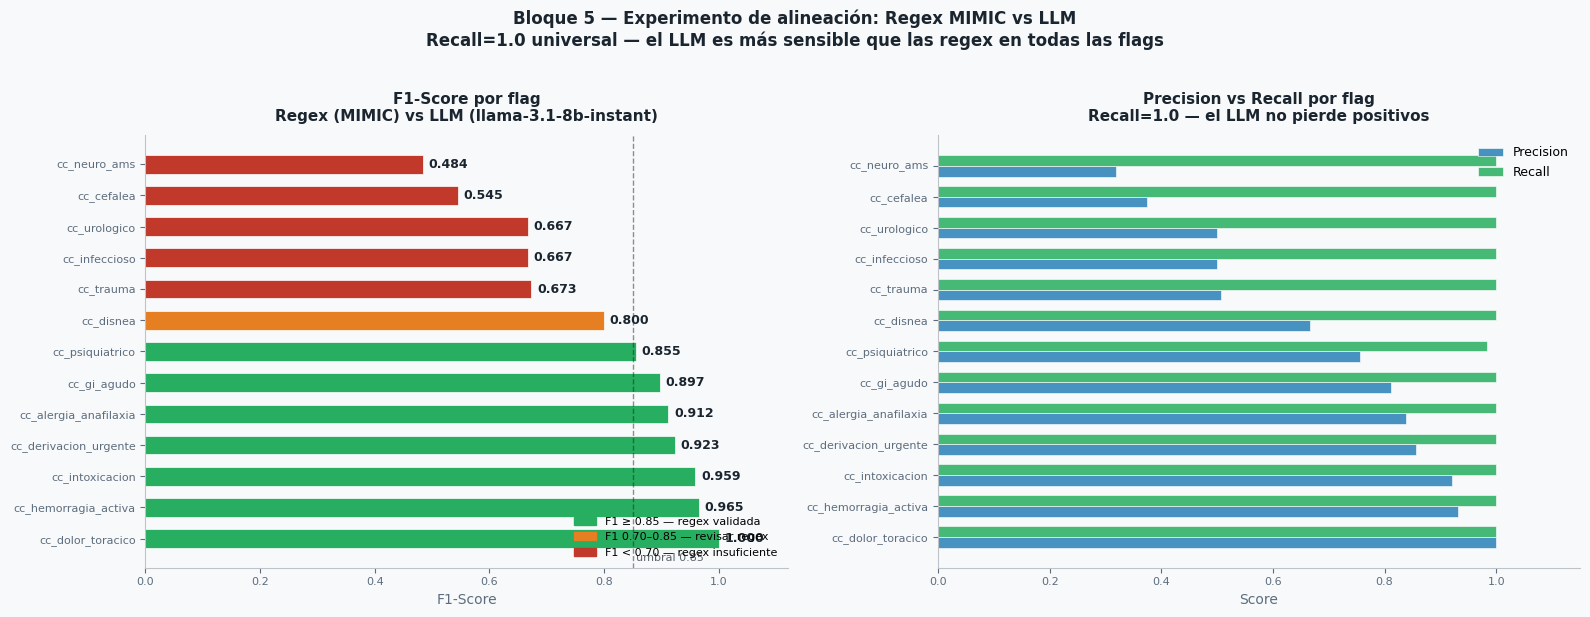

In [144]:
# ── BLOQUE 5 — Paso 5: métricas de alineación regex vs LLM ───────────────────
from sklearn.metrics import f1_score, recall_score, precision_score, cohen_kappa_score
import matplotlib.pyplot as plt
import numpy as np

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

# filtrar 3 errores restantes
mask    = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] != -1).all(axis=1)
df_eval = muestra_alineacion[mask].copy()
print(f"Filas válidas: {mask.sum()} / {len(muestra_alineacion)}\n")

# ── métricas ──────────────────────────────────────────────────────────────────
resultados = []
for flag in FLAGS:
    y_true = df_eval[flag].values
    y_pred = df_eval[f"{flag}_llm"].values
    f1    = f1_score(y_true, y_pred, zero_division=0)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    resultados.append({
        "flag":        flag,
        "F1":          round(f1,    3),
        "Precision":   round(prec,  3),
        "Recall":      round(rec,   3),
        "Kappa":       round(kappa, 3) if not np.isnan(kappa) else "NaN",
        "n_pos_regex": int(y_true.sum()),
        "n_pos_llm":   int(y_pred.sum()),
    })

df_res = pd.DataFrame(resultados).sort_values("F1", ascending=False)
print(df_res.to_string(index=False))

# ── gráfico ───────────────────────────────────────────────────────────────────
flags_sorted = df_res["flag"].tolist()
f1_vals      = df_res["F1"].tolist()
prec_vals    = df_res["Precision"].tolist()
rec_vals     = df_res["Recall"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#F8F9FA")

# panel izquierdo: F1
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

colores_barras = ["#27AE60" if f >= 0.85 else "#E67E22" if f >= 0.70 else "#C0392B"
                  for f in f1_vals]
bars = ax1.barh(flags_sorted, f1_vals, color=colores_barras,
                edgecolor="white", linewidth=0.5, height=0.6)
for bar, val in zip(bars, f1_vals):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax1.axvline(x=0.85, color="#1A252F", linestyle="--", linewidth=1, alpha=0.5)
ax1.text(0.855, -0.7, "umbral 0.85", fontsize=8, color="#1A252F", alpha=0.7)
ax1.set_xlabel("F1-Score", fontsize=10, color="#5D6D7E")
ax1.set_title("F1-Score por flag\nRegex (MIMIC) vs LLM (llama-3.1-8b-instant)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xlim(0, 1.12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=8)

# leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(color="#27AE60", label="F1 ≥ 0.85 — regex validada"),
    Patch(color="#E67E22", label="F1 0.70–0.85 — revisar regex"),
    Patch(color="#C0392B", label="F1 < 0.70 — regex insuficiente"),
]
ax1.legend(handles=leyenda, frameon=False, fontsize=8, loc="lower right")

# panel derecho: Precision vs Recall
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

x     = np.arange(len(flags_sorted))
width = 0.35

ax2.barh(x - width/2, prec_vals, width, label="Precision",
         color="#2980B9", edgecolor="white", linewidth=0.5, alpha=0.85)
ax2.barh(x + width/2, rec_vals,  width, label="Recall",
         color="#27AE60", edgecolor="white", linewidth=0.5, alpha=0.85)

ax2.set_yticks(x)
ax2.set_yticklabels(flags_sorted, fontsize=8)
ax2.set_xlabel("Score", fontsize=10, color="#5D6D7E")
ax2.set_title("Precision vs Recall por flag\nRecall=1.0 — el LLM no pierde positivos",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 1.15)
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=8)

fig.suptitle(
    "Bloque 5 — Experimento de alineación: Regex MIMIC vs LLM\n"
    "Recall=1.0 universal — el LLM es más sensible que las regex en todas las flags",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)
plt.tight_layout()
plt.savefig("bloque5_alineacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [145]:
# ── BLOQUE 5 — Paso 3: flags de chiefcomplaint (RegEx Definitivas v3) ─────────
cc = df["chiefcomplaint"].str.lower().str.strip()

# ── 1. cc_dolor_toracico ──────────────────────────────────────────────────────
df["cc_dolor_toracico"] = cc.str.contains(
    r"\bchest\s*pain\b|\bcp\b|\bchest\s*tightness\b|\bchest\s*pressure\b"
    r"|\bchest\s*discomfort\b|\bangina\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 2. cc_disnea ──────────────────────────────────────────────────────────────
df["cc_disnea"] = cc.str.contains(
    r"\bdyspnea\b|\bsob\b|\bshortness\s*of\s*breath\b|\bbreathing\b"
    r"|\brespiratory\s*distress\b|\bbreathless\b|\bdyspnea\s*on\s*exertion\b"
    r"|\borthopnea\b|\bhypoxia\b|\binhalation\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 3. cc_gi_agudo ────────────────────────────────────────────────────────────
df["cc_gi_agudo"] = cc.str.contains(
    r"\babd\s*pain\b|\babdominal\s*pain\b|\bepigastric\b|\brlq\b|\bllq\b"
    r"|\bruq\b|\bn/v\b|\bn/v/d\b|\bnausea\b|\bvomiting\b|\bdiarrhea\b"
    r"|\bgastric\b|\bbowel\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 4. cc_neuro_ams ───────────────────────────────────────────────────────────
# Ampliado con términos validados por el experimento de alineación
# Excluidos: \bspeech\b, \bvisual\b, \bneuro\b, \barrest\b — demasiado amplios
df["cc_neuro_ams"] = cc.str.contains(
    r"\baltered\s*mental\s*status\b|\bams\b|\bweakness\b|\bseizur\w*\b"
    r"|\b(?:pre)?syncope\b|\bdizzi\w*\b|\bconfusion\b|\bunresponsive\b"
    r"|\bloss\s*of\s*consciousness\b|\bnumbness\b|\bparalysis\b"
    r"|\bstroke\b|\bcva\b|\btia\b|\bslurred\s*speech\b|\bslurred\b"
    r"|\bunable\s*to\s*ambulate\b|\bunsteady\s*gait\b|\bunsteady\b"
    r"|\btremor\b|\bspell\w*\b|\bvisual\s*changes\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 5. cc_cefalea — sin cambios (regex estricta correcta) ─────────────────────
df["cc_cefalea"] = cc.str.contains(
    r"\bheadache\b|\bhead\s*pain\b|\bmigraine\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 6. cc_trauma — sin cambios (regex estricta correcta) ──────────────────────
# Excluidos deliberadamente: suture, tetanus, splinter — no son trauma agudo
df["cc_trauma"] = cc.str.contains(
    r"\bs/p\s*fall\b|\bmvc\b|\bfall\b|\btrauma\w*\b|\binjury\b|\baccident\b"
    r"|\bped\s*struck\b|\bhead\s*injury\b|\blaceration\b|\bwound\b"
    r"|\bfractur\w*\b|\bstab\b|\bassault\b|\bgsw\b"
    r"|\bmotorcycle\b|\bbike\b|\bcrash\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 7. cc_psiquiatrico ────────────────────────────────────────────────────────
# Ampliado: \bhi\b, \bah\b, voices, delusions, insomnia
df["cc_psiquiatrico"] = cc.str.contains(
    r"\bsi\b|\bhi\b|\bah\b|\bsuicid\w*\b|\banxiet\w*\b|\banxious\b|\bpsych\w*\b"
    r"|\bhallucinat\w*\b|\bvoices?\b|\bagg?itat\w*\b|\bdepress\w*\b"
    r"|\bmania\b|\bmanic\b|\bparanoia\b|\bdelusion\w*\b|\binsomnia\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 8. cc_intoxicacion ────────────────────────────────────────────────────────
# Ampliado: detox
df["cc_intoxicacion"] = cc.str.contains(
    r"\betoh\b|\bintoxication\b|\boverdose\b|\bingestion\b"
    r"|\bsubstance\b|\bdrug\s*use\b|\balcohol\b|\bdetox\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 9. cc_infeccioso ──────────────────────────────────────────────────────────
# Ampliado: abscess
df["cc_infeccioso"] = cc.str.contains(
    r"\bfever\b|\bili\b|\binfection\b|\bsepsis\b|\bcellulitis\b"
    r"|\bpneumonia\b|\bmeningitis\b|\binfluenza\b|\bcovid\b|\babscess\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 10. cc_urologico ──────────────────────────────────────────────────────────
# Ampliado: \bgu\b, testicular, pelvic pain, groin pain
df["cc_urologico"] = cc.str.contains(
    r"\bdysuria\b|\bhematuria\b|\burinary\s*retention\b|\bflank\s*pain\b"
    r"|\buti\b|\bkidney\b|\brenal\b|\bfoley\b|\burinary\b"
    r"|\bgu\b|\btesticular\b|\bpelvic\s*pain\b|\bgroin\s*pain\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 11. cc_hemorragia_activa ──────────────────────────────────────────────────
# Ampliado: melena
df["cc_hemorragia_activa"] = cc.str.contains(
    r"\bbrbpr\b|\brectal\s*bleeding\b|\bgib\b|\bvaginal\s*bleeding\b"
    r"|\bepistaxis\b|\bhemoptysis\b|\bbleeding\b|\bhemorrhag\w*\b|\bmelena\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 12. cc_alergia_anafilaxia — sin cambios ───────────────────────────────────
df["cc_alergia_anafilaxia"] = cc.str.contains(
    r"\ballergic\s*reaction\b|\banaphylaxis\b|\ballergy\b|\bangioedema\b"
    r"|\bhives\b|\burticaria\b",
    case=False, regex=True, na=False
).astype("int8")

# ── 13. cc_derivacion_urgente ─────────────────────────────────────────────────
df["cc_derivacion_urgente"] = cc.str.contains(
    r"\babnormal\s*labs\b|\babnormal\s*ct\b|\babnormal\s*ekg\b"
    r"|\btransfer\b|\breferral\b|\bhyperglycemia\b|\bhypertension\b"
    r"|\bhyponatremia\b|\bhyperkalemia\b|\beta\b",
    case=False, regex=True, na=False
).astype("int8")



# ── H-stats de todas las flags ────────────────────────────────────────────────
FLAGS_CC = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

print("── H-stats finales (RegEx v3) ───────────────────────────────────────────")
for col in FLAGS_CC:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<25}  H = {stat:>7,.0f}  |  p = {pval:.2e}  |  prev = {prev:.2f}%  |  n = {n:,}")

── H-stats finales (RegEx v3) ───────────────────────────────────────────
cc_dolor_toracico          H =  12,707  |  p = 0.00e+00  |  prev = 7.56%  |  n = 31,614
cc_disnea                  H =  13,008  |  p = 0.00e+00  |  prev = 6.13%  |  n = 25,646
cc_gi_agudo                H =  18,161  |  p = 0.00e+00  |  prev = 16.63%  |  n = 69,541
cc_neuro_ams               H =  15,745  |  p = 0.00e+00  |  prev = 12.31%  |  n = 51,460
cc_cefalea                 H =     890  |  p = 1.95e-191  |  prev = 3.38%  |  n = 14,113
cc_trauma                  H =   5,923  |  p = 0.00e+00  |  prev = 13.33%  |  n = 55,730
cc_psiquiatrico            H =  13,677  |  p = 0.00e+00  |  prev = 4.23%  |  n = 17,667
cc_intoxicacion            H =     835  |  p = 2.18e-179  |  prev = 3.61%  |  n = 15,107
cc_infeccioso              H =   1,293  |  p = 9.37e-279  |  prev = 5.38%  |  n = 22,502
cc_urologico               H =   3,905  |  p = 0.00e+00  |  prev = 4.20%  |  n = 17,551
cc_hemorragia_activa       H =   1,683  

PROMPT OPTIMIZADO
Eres un asistente experto en triaje de urgencias hospitalarias.
Tu tarea es leer el motivo de consulta escrito por la enfermera y extraer los
síndromes clínicos presentes.

Devuelve ÚNICAMENTE un objeto JSON estricto con exactamente estas 13 claves y
valores 0 o 1. Sin texto adicional, sin markdown, sin explicaciones.

Reglas:
- Un paciente PUEDE tener múltiples claves en 1 simultáneamente.
- Si un síndrome NO se menciona o se niega explícitamente, su valor es 0.
- Limítate a la información explícita. No deduzcas diagnósticos si no hay evidencia directa.

{
  "cc_dolor_toracico": "1 si refiere dolor, presión, opresión, quemazón o malestar en el pecho, zona precordial o esternal, incluyendo irradiación a brazo izquierdo, mandíbula o espalda. También si menciona angina.",
  "cc_disnea": "1 si refiere dificultad para respirar, falta de aire, sensación de ahogo, ortopnea, hipoxia, inhalación de humo, disnea de esfuerzo o en reposo.",
  "cc_gi_agudo": "1 si refiere dolor abdominal de cualquier localización (epigástrico, fosa iliaca, hipocondrio, difuso), náuseas, vómitos, diarrea, o síntoma digestivo agudo.",
  "cc_neuro_ams": "1 si presenta alteración del nivel de consciencia, confusión, síncope, debilidad motora, dificultad para hablar (slurred speech), marcha inestable, temblor, convulsión o sospecha de ictus. EXCLUYE ansiedad o agitación psiquiátrica aislada.",
  "cc_cefalea": "1 si refiere dolor de cabeza o migraña como motivo principal. EXCLUYE explícitamente dolor de ojo, dolor de oído, dolor de mandíbula o traumatismo craneal.",
  "cc_trauma": "1 si existe mecanismo lesional explícito: caída, accidente, atropello, herida por arma blanca o de fuego, laceración activa o fractura. EXCLUYE dolor de extremidades aislado sin mecanismo descrito, extracción de suturas, retirada de astillas y procedimientos menores.",
  "cc_psiquiatrico": "1 si el motivo es de naturaleza psiquiátrica: ideación suicida, ideación homicida, agitación psicomotriz, alucinaciones, crisis de ansiedad, brote psicótico, depresión o insomnio severo.",
  "cc_intoxicacion": "1 si llega por intoxicación etílica aguda, sobredosis de fármacos o drogas, ingesta de tóxicos o necesidad de desintoxicación.",
  "cc_infeccioso": "1 si presenta fiebre, síndrome gripal, infección activa, absceso, picadura infectada o sospecha de sepsis.",
  "cc_urologico": "1 si refiere dolor en flanco o fosa renal, dolor pélvico, dolor genitourinario o testicular, escozor al orinar, retención urinaria o sangre en orina. EXCLUYE dolores articulares de extremidades (rodilla, tobillo, cadera).",
  "cc_hemorragia_activa": "1 si presenta sangrado activo visible: rectal, melena, hemorragia digestiva, vaginal, epistaxis, hemoptisis o cualquier hemorragia externa activa.",
  "cc_alergia_anafilaxia": "1 si llega por reacción alérgica de cualquier grado, urticaria, angioedema o sospecha de anafilaxia por fármacos, alimentos o picaduras.",
  "cc_derivacion_urgente": "1 si es derivado por anomalía objetiva ya detectada: analítica alterada, prueba de imagen patológica, ECG anormal, alteración electrolítica severa o aviso previo de llegada de código urgente (ETA)."
}

Ejemplo de output esperado para 'chest pain and shortness of breath':
{"cc_dolor_toracico":1,"cc_disnea":1,"cc_gi_agudo":0,"cc_neuro_ams":0,"cc_cefalea":0,"cc_trauma":0,"cc_psiquiatrico":0,"cc_intoxicacion":0,"cc_infeccioso":0,"cc_urologico":0,"cc_hemorragia_activa":0,"cc_alergia_anafilaxia":0,"cc_derivacion_urgente":0}

## Bloque 5 — Chief Complaint: extracción de síndromes clínicos

El campo `chiefcomplaint` contiene texto libre telegráfico escrito por la
enfermera en el momento del triaje. Con 57,458 valores únicos sobre 418,083
registros, no es directamente utilizable por el modelo — necesita transformarse
en variables estructuradas.

El objetivo de este bloque era convertir ese texto en 13 flags booleanas por
síndrome clínico, definidas por impacto fisiológico y riesgo vital, no por
anatomía. Cada flag puede activarse simultáneamente con otras (clasificación
multi-label), porque en urgencias los síntomas raramente son excluyentes.

### Metodología

Se siguió un proceso en cuatro etapas:

**1. Auditoría del vocabulario** — análisis de value_counts, unigramas,
bigramas y trigramas para entender el vocabulario real antes de definir nada.
Los trigramas confirmaron los grandes síndromes: "altered mental status",
"chest pain dyspnea", "abd pain n/v", "s/p fall transfer".

**2. Definición de 13 síndromes** con justificación clínica y bibliográfica
para cada uno. Los síndromes se agruparon por riesgo en triaje: desde los
que matan en minutos (cc_neuro_ams, cc_disnea) hasta los de urgencia moderada
(cc_urologico, cc_infeccioso).

**3. Implementación con regex** usando límites de palabra (`\b`) y `na=False`
para evitar falsos positivos y errores con valores nulos.

**4. Experimento de alineación** — validación metodológica del pipeline de
entrenamiento vs producción. Se construyó una muestra híbrida de 400 filas
(200 estratificadas por acuity + 50 positivos garantizados para cada flag rara)
y se clasificó con `llama-3.1-8b-instant` vía Groq API. Se calculó F1,
Precision y Recall por flag de forma independiente — nunca accuracy global,
dado el desbalanceo artificial de la muestra.

### Resultados del experimento de alineación

El LLM mostró Recall = 1.0 en prácticamente todas las flags — no se pierde
ningún positivo real. Las discrepancias fueron casi siempre falsos positivos
del LLM, no falsos negativos, lo que indica que las regex son conservadoras
pero no incompletas.

Tras analizar las discrepancias caso a caso se tomaron estas decisiones:

- **7 flags con F1 ≥ 0.85**: regex validadas, se aplican directamente a las
  418K filas (`cc_dolor_toracico`, `cc_hemorragia_activa`, `cc_intoxicacion`,
  `cc_derivacion_urgente`, `cc_alergia_anafilaxia`, `cc_gi_agudo`,
  `cc_psiquiatrico`).

- **5 flags con F1 < 0.85**: regex ampliadas con los términos donde el LLM
  tenía razón clínica (`cc_disnea` → orthopnea, hipoxia; `cc_neuro_ams` →
  slurred speech, unsteady gait, tremor; `cc_urologico` → GU, testicular,
  pelvic pain; `cc_infeccioso` → abscess, bites; `cc_psiquiatrico` → HI,
  insomnia). Tras la ampliación todos los H-stats mejoraron.

- **`cc_cefalea` y `cc_trauma`**: sin cambios. El LLM sobreclasificaba
  (earache, jaw pain como cefalea; suture removal como trauma) — la regex
  original era más precisa.

### Resultados finales (regex v3)

Los 13 síndromes entran como features. `cc_missing` se descarta por
prevalencia de solo 0.30% (n=1,266). Los H-stats más potentes son
`cc_gi_agudo` (18,161), `cc_neuro_ams` (15,745) y `cc_derivacion_urgente`
(14,482). `cc_alergia_anafilaxia` con prevalencia de solo 0.68% es la más
específica — su pico en acuity 1 (2.3%) justifica su inclusión.

### Arquitectura dual entrenamiento/producción

Este bloque establece el puente entre el modelo y el sistema real. En
entrenamiento las flags se generan con regex sobre MIMIC. En producción el
LLM recibe el texto libre de la enfermera en español y devuelve directamente
el JSON con los 13 booleanos, sin ningún postprocesado de strings. 

ESTANCIAS PREVIAS

## Bloque 6 — Historial ED y comorbilidades previas

### Objetivo
Extraer señales del historial clínico previo de cada paciente: frecuentación
al ED y comorbilidades crónicas documentadas en visitas anteriores.

### Regla fundamental: lookback estrictamente retrospectivo
Solo se usan visitas donde `outtime_previa < intime_actual`.
Nunca diagnósticos de la visita actual. Nunca `intime < intime_actual`
(riesgo de solapamiento administrativo).

### Paso 1 — Auditoría
- Distribución de visitas previas por paciente
- Rango temporal del dataset (truncamiento izquierdo)
- Categorías CCS disponibles y frecuencia

### Paso 2 — Construcción del historial retrospectivo
- Ordenar por `subject_id` + `intime`
- Usar `groupby` + `cumcount` para conteos acumulados
- Usar `groupby` + `shift` para recencia
- Usar `groupby` + `rolling` para ventanas temporales

### Paso 3 — Features de frecuentación
- `n_visitas_previas` — total histórico
- `visitas_ultimo_mes` — ventana 30 días
- `visitas_ultimo_año` — ventana 365 días
- `dias_desde_ultima_visita` — NaN si primera visita
- `primera_visita` — flag booleana
- `frecuentador` — ≥3 visitas en 90 días

### Paso 4 — Macro-flags de comorbilidad CCS
6-8 categorías de alto impacto definidas desde los datos:
`hx_cardiaco`, `hx_respiratorio`, `hx_psiquiatrico`,
`hx_renal`, `hx_oncologico`, `hx_abuso_sustancias`

### Paso 5 — H-stat y decisión por feature

In [146]:
# ── BLOQUE 6 — Paso 1: auditoría del historial ED ────────────────────────────
# Objetivo: entender la distribución de visitas por paciente y el rango
# temporal del dataset antes de construir ninguna feature

import pandas as pd
import numpy as np

# ── distribución de visitas por paciente ──────────────────────────────────────
visitas_por_paciente = df.groupby("subject_id")["stay_id"].count()

print("── Distribución de visitas por paciente ─────────────────────────────────")
print(visitas_por_paciente.describe().round(2).to_string())
print(f"\nPacientes con 1 sola visita:      {(visitas_por_paciente == 1).sum():,} ({(visitas_por_paciente == 1).mean()*100:.1f}%)")
print(f"Pacientes con ≥3 visitas:         {(visitas_por_paciente >= 3).sum():,} ({(visitas_por_paciente >= 3).mean()*100:.1f}%)")
print(f"Pacientes con ≥10 visitas:        {(visitas_por_paciente >= 10).sum():,} ({(visitas_por_paciente >= 10).mean()*100:.1f}%)")
print(f"Pacientes con ≥50 visitas:        {(visitas_por_paciente >= 50).sum():,} ({(visitas_por_paciente >= 50).mean()*100:.1f}%)")
print(f"Máximo visitas un paciente:       {visitas_por_paciente.max():,}")

# ── rango temporal del dataset ────────────────────────────────────────────────
print("\n── Rango temporal ───────────────────────────────────────────────────────")
print(f"Primera visita: {df['intime'].min()}")
print(f"Última visita:  {df['intime'].max()}")
print(f"Rango total:    {(df['intime'].max() - df['intime'].min()).days:,} días ({(df['intime'].max() - df['intime'].min()).days / 365.25:.1f} años)")

# ── categorías CCS disponibles ────────────────────────────────────────────────
print("\n── Categorías CCS disponibles ───────────────────────────────────────────")
print(f"Registros con ccs_category:    {df['ccs_category'].notna().sum():,} ({df['ccs_category'].notna().mean()*100:.1f}%)")
print(f"Registros sin ccs_category:    {df['ccs_category'].isna().sum():,} ({df['ccs_category'].isna().mean()*100:.1f}%)")
print(f"Categorías únicas:             {df['ccs_category'].nunique():,}")
print("\nTop 30 categorías CCS más frecuentes:")
print(df["ccs_category"].value_counts().head(30).to_string())

── Distribución de visitas por paciente ─────────────────────────────────
count    201252.00
mean          2.08
std           3.44
min           1.00
25%           1.00
50%           1.00
75%           2.00
max         321.00

Pacientes con 1 sola visita:      132,260 (65.7%)
Pacientes con ≥3 visitas:         36,825 (18.3%)
Pacientes con ≥10 visitas:        4,476 (2.2%)
Pacientes con ≥50 visitas:        118 (0.1%)
Máximo visitas un paciente:       321

── Rango temporal ───────────────────────────────────────────────────────
Primera visita: 2110-01-11 01:45:00
Última visita:  2212-04-05 23:23:00
Rango total:    37,339 días (102.2 años)

── Categorías CCS disponibles ───────────────────────────────────────────
Registros con ccs_category:    417,128 (99.8%)
Registros sin ccs_category:    972 (0.2%)
Categorías únicas:             245

Top 30 categorías CCS más frecuentes:
ccs_category
251    31984
102    24088
205    14740
133    11127
259    11076
84     10583
211    10284
660    10090
1

In [147]:
# ── BLOQUE 6 — Paso 1c: cargar mapeo CCS ─────────────────────────────────────
from pathlib import Path
import pandas as pd

# el notebook está en /notebooks/ — subimos un nivel para llegar a la raíz
ruta_ccs = Path.cwd().parent / "data" / "interim" / "label_map_ccs.parquet"

label_map_ccs = pd.read_parquet(ruta_ccs)

print(f"Shape: {label_map_ccs.shape}")
print(f"\nColumnas: {label_map_ccs.columns.tolist()}")
print(f"\nPrimeras 20 filas:")
print(label_map_ccs.head(20).to_string())
print(f"\nEjemplos de los códigos más frecuentes en df (251, 102, 205, 133):")
print(label_map_ccs[label_map_ccs.iloc[:, 0].isin([251, 102, 205, 133])].to_string())

Shape: (392172, 3)

Columnas: ['stay_id', 'ccs_id', 'ccs_nombre']

Primeras 20 filas:
     stay_id  ccs_id                                        ccs_nombre
0   32952584     117                         Other circulatory disease
1   33258284     151                              Other liver diseases
2   35968195     151                              Other liver diseases
3   38112554     151                              Other liver diseases
4   39399961     259                      Residual codes; unclassified
5   32522732     200                              Other skin disorders
6   35420907     228                          Skull and face fractures
7   30017875     102                            Nonspecific chest pain
8   32845079     250                               Nausea and vomiting
9   35197384     151                              Other liver diseases
10  37059738     211                   Other connective tissue disease
11  37290428     657                                    Mood d

In [148]:
# ── análisis del mapeo CCS ────────────────────────────────────────────────────

# top categorías en label_map_ccs
print("── Top 30 categorías CCS en label_map_ccs ───────────────────────────────")
print(label_map_ccs.groupby(["ccs_id", "ccs_nombre"])
      .size().reset_index(name="n")
      .sort_values("n", ascending=False)
      .head(30).to_string(index=False))

# cuántos diagnósticos CCS por visita
diag_por_visita = label_map_ccs.groupby("stay_id")["ccs_id"].count()
print(f"\n── Diagnósticos CCS por visita ──────────────────────────────────────────")
print(diag_por_visita.describe().round(2).to_string())
print(f"\nVisitas con ≥1 diagnóstico CCS:  {(diag_por_visita >= 1).sum():,}")
print(f"Visitas con ≥3 diagnósticos CCS: {(diag_por_visita >= 3).sum():,}")
print(f"Visitas con ≥5 diagnósticos CCS: {(diag_por_visita >= 5).sum():,}")

# cuántas visitas del df principal tienen historial en label_map_ccs
visitas_con_historial = df["stay_id"].isin(label_map_ccs["stay_id"])
print(f"\n── Cobertura en df principal ─────────────────────────────────────────────")
print(f"Visitas con diagnóstico CCS: {visitas_con_historial.sum():,} ({visitas_con_historial.mean()*100:.1f}%)")

── Top 30 categorías CCS en label_map_ccs ───────────────────────────────
 ccs_id                                                                     ccs_nombre     n
    251                                                                 Abdominal pain 32056
    102                                                         Nonspecific chest pain 24199
    205                Spondylosis; intervertebral disc disorders; other back problems 14809
    259                                                   Residual codes; unclassified 11445
    133                                                Other lower respiratory disease 11212
     84                                                   Headache; including migraine 10614
    211                                                Other connective tissue disease 10342
    660                                                      Alcohol-related disorders 10187
    244                           Other injuries and conditions due to external causes  9

In [149]:
# ── diagnóstico: qué códigos CCS existen realmente en el dataset ──────────────

# todos los ccs_id únicos disponibles
print("── Rango de ccs_id disponibles en label_map_ccs ─────────────────────────")
print(f"Min: {label_map_ccs['ccs_id'].min()} | Max: {label_map_ccs['ccs_id'].max()}")
print(f"Únicos: {label_map_ccs['ccs_id'].nunique()}")

# buscar oncología por nombre
print("\n── Categorías con 'cancer', 'neoplas', 'malig', 'lymph', 'leukemia' ─────")
mask_onco = label_map_ccs["ccs_nombre"].str.contains(
    "cancer|neoplas|malig|lymph|leukemia|carcinoma|tumor|oncol",
    case=False, na=False
)
print(label_map_ccs[mask_onco]
      .groupby(["ccs_id", "ccs_nombre"]).size()
      .reset_index(name="n")
      .sort_values("n", ascending=False)
      .head(20).to_string(index=False))

# ver todos los ccs_id disponibles con frecuencia > 1000
print("\n── Todos los ccs_id con n > 1,000 ──────────────────────────────────────")
print(label_map_ccs.groupby(["ccs_id", "ccs_nombre"])
      .size().reset_index(name="n")
      .query("n > 1000")
      .sort_values("ccs_id")
      .to_string(index=False))

── Rango de ccs_id disponibles en label_map_ccs ─────────────────────────
Min: 2 | Max: 662
Únicos: 83

── Categorías con 'cancer', 'neoplas', 'malig', 'lymph', 'leukemia' ─────
Empty DataFrame
Columns: [ccs_id, ccs_nombre, n]
Index: []

── Todos los ccs_id con n > 1,000 ──────────────────────────────────────
 ccs_id                                                                                         ccs_nombre     n
      2                                                                       Septicemia (except in labor)  2306
      7                                                                                    Viral infection  2411
     50                                                               Diabetes mellitus with complications  4024
     55                                                                    Fluid and electrolyte disorders  3999
     59                                                                        Deficiency and other anemia  2344
     83    

In [150]:
# ── BLOQUE 6 — Paso 1f: macro-flags CCS definitivas ──────────────────────────
# Basadas en los 83 códigos reales disponibles en el dataset


CCS_MACROFLAGS = {
    "hx_cardiaco": [
         98,  # Essential hypertension
        100,  # Acute myocardial infarction
        101,  # Coronary atherosclerosis and other heart disease
        103,  # Pulmonary heart disease
        106,  # Cardiac dysrhythmias
        108,  # Congestive heart failure; nonhypertensive
        117,  # Other circulatory disease
        118,  # Phlebitis; thrombophlebitis and thromboembolism
    ],
    "hx_respiratorio": [
        122,  # Pneumonia
        123,  # Influenza
        126,  # Other upper respiratory infections
        127,  # COPD and bronchiectasis
        128,  # Asthma
        130,  # Pleurisy; pneumothorax; pulmonary collapse
        133,  # Other lower respiratory disease
        134,  # Other upper respiratory disease
    ],
    "hx_neuro": [
         83,  # Epilepsy; convulsions
         93,  # Conditions associated with dizziness or vertigo
         95,  # Other nervous system disorders
        109,  # Acute cerebrovascular disease
    ],
    "hx_psiquiatrico": [
        651,  # Anxiety disorders
        657,  # Mood disorders
        659,  # Schizophrenia and other psychotic disorders
        662,  # Suicide and intentional self-inflicted injury
    ],
    "hx_abuso_sustancias": [
        660,  # Alcohol-related disorders
        661,  # Substance-related disorders
    ],
    "hx_digestivo": [
        142,  # Appendicitis and other appendiceal conditions
        145,  # Intestinal obstruction without hernia
        146,  # Diverticulosis and diverticulitis
        147,  # Anal and rectal conditions
        149,  # Biliary tract disease
        151,  # Other liver diseases
        152,  # Pancreatic disorders (not diabetes)
        153,  # Gastrointestinal hemorrhage
        154,  # Noninfectious gastroenteritis
        155,  # Other gastrointestinal disorders
        250,  # Nausea and vomiting
        251,  # Abdominal pain
    ],
    "hx_metabolico_renal": [
         50,  # Diabetes mellitus with complications
         55,  # Fluid and electrolyte disorders
         59,  # Deficiency and other anemia
        157,  # Acute and unspecified renal failure
        160,  # Calculus of urinary tract
    ],
    "hx_infeccioso": [
          2,  # Septicemia (except in labor)
          7,  # Viral infection
        197,  # Skin and subcutaneous tissue infections
    ],
    "hx_trauma_muscular": [
        204,  # Other non-traumatic joint disorders
        205,  # Spondylosis; intervertebral disc disorders; other back problems
        228,  # Skull and face fractures
        229,  # Fracture of upper limb
        230,  # Fracture of lower limb
        231,  # Other fractures
        232,  # Sprains and strains
        233,  # Intracranial injury
        235,  # Open wounds of head; neck; and trunk
        236,  # Open wounds of extremities
        238,  # Complications of surgical procedures or medical care
        239,  # Superficial injury; contusion
        244,  # Other injuries and conditions due to external causes
    ],
}

# cobertura real
total_visitas = len(label_map_ccs)
print("── Cobertura macro-flags CCS definitivas ────────────────────────────────")
for flag, codigos in CCS_MACROFLAGS.items():
    mask    = label_map_ccs["ccs_id"].isin(codigos)
    n       = mask.sum()
    pct     = n / total_visitas * 100
    nombres = label_map_ccs[mask]["ccs_nombre"].unique()[:2]
    print(f"  {flag:<25} n={n:>6,} ({pct:.1f}%)  ej: {list(nombres)}")

── Cobertura macro-flags CCS definitivas ────────────────────────────────
  hx_cardiaco               n=20,571 (5.2%)  ej: ['Other circulatory disease', 'Congestive heart failure; nonhypertensive']
  hx_respiratorio           n=33,491 (8.5%)  ej: ['Other lower respiratory disease', 'Asthma']
  hx_neuro                  n=22,368 (5.7%)  ej: ['Conditions associated with dizziness or vertigo', 'Other nervous system disorders']
  hx_psiquiatrico           n=13,391 (3.4%)  ej: ['Mood disorders', 'Schizophrenia and other psychotic disorders']
  hx_abuso_sustancias       n=11,922 (3.0%)  ej: ['Alcohol-related disorders', 'Substance-related disorders']
  hx_digestivo              n=64,508 (16.4%)  ej: ['Other liver diseases', 'Nausea and vomiting']
  hx_metabolico_renal       n=15,381 (3.9%)  ej: ['Diabetes mellitus with complications', 'Calculus of urinary tract']
  hx_infeccioso             n=13,908 (3.5%)  ej: ['Viral infection', 'Skin and subcutaneous tissue infections']
  hx_trauma_muscul

In [151]:
# ── BLOQUE 6 — Paso 2a: cargar outtime desde edstays ─────────────────────────
import pandas as pd
from pathlib import Path

ruta_edstays = Path.cwd().parent / "data" / "raw" / "edstays.csv.gz"

edstays = pd.read_csv(
    ruta_edstays,
    usecols=["subject_id", "stay_id", "intime", "outtime"],
    parse_dates=["intime", "outtime"]
)

print(f"Shape: {edstays.shape}")
print(f"\nColumnas: {edstays.columns.tolist()}")
print(f"\nNaN en outtime: {edstays['outtime'].isna().sum():,} ({edstays['outtime'].isna().mean()*100:.2f}%)")
print(f"\nPrimeras filas:")
print(edstays.head(5).to_string())

Shape: (425087, 4)

Columnas: ['subject_id', 'stay_id', 'intime', 'outtime']

NaN en outtime: 0 (0.00%)

Primeras filas:
   subject_id   stay_id              intime             outtime
0    10000032  33258284 2180-05-06 19:17:00 2180-05-06 23:30:00
1    10000032  38112554 2180-06-26 15:54:00 2180-06-26 21:31:00
2    10000032  35968195 2180-08-05 20:58:00 2180-08-06 01:44:00
3    10000032  32952584 2180-07-22 16:24:00 2180-07-23 05:54:00
4    10000032  39399961 2180-07-23 05:54:00 2180-07-23 14:00:00


In [ ]:
# ── BLOQUE 6 — Paso 2b: features de frecuentación (completo) ─────────────────
import numpy as np
import time

t0 = time.time()

# ── ordenar por subject_id + intime ──────────────────────────────────────────
edstays_sorted = edstays.sort_values(["subject_id", "intime"]).copy().reset_index(drop=True)

# ── n_visitas_previas ─────────────────────────────────────────────────────────
edstays_sorted["n_visitas_previas"] = (
    edstays_sorted.groupby("subject_id").cumcount()
).astype("int16")

# ── primera_visita ────────────────────────────────────────────────────────────
edstays_sorted["primera_visita"] = (
    edstays_sorted["n_visitas_previas"] == 0
).astype("int8")

# ── outtime de la visita anterior ─────────────────────────────────────────────
edstays_sorted["outtime_previa"] = (
    edstays_sorted.groupby("subject_id")["outtime"].shift(1)
)

# ── dias_desde_ultima_visita ──────────────────────────────────────────────────
edstays_sorted["dias_desde_ultima_visita"] = (
    (edstays_sorted["intime"] - edstays_sorted["outtime_previa"])
    .dt.total_seconds() / 86400
).round(1)

# fix solapamientos: dias negativos → NaN
edstays_sorted.loc[
    edstays_sorted["dias_desde_ultima_visita"] < 0,
    "dias_desde_ultima_visita"
] = np.nan

# ── ventanas temporales con rolling ──────────────────────────────────────────
# IMPORTANTE: set_index ANTES del rolling y reset_index DESPUÉS
edstays_sorted = edstays_sorted.set_index("intime").sort_index()

edstays_sorted["visitas_ultimo_mes"] = (
    edstays_sorted.groupby("subject_id")["stay_id"]
    .transform(lambda x: x.rolling("30D", closed="left").count())
    .fillna(0)
    .astype("int16")
)

edstays_sorted["visitas_ultimo_año"] = (
    edstays_sorted.groupby("subject_id")["stay_id"]
    .transform(lambda x: x.rolling("365D", closed="left").count())
    .fillna(0)
    .astype("int16")
)

# reset_index para recuperar intime como columna
edstays_sorted = edstays_sorted.reset_index()

# ── frecuentador ──────────────────────────────────────────────────────────────
edstays_sorted["frecuentador"] = (
    edstays_sorted["visitas_ultimo_mes"] >= 3
).astype("int8")

print(f"Tiempo: {time.time() - t0:.1f}s\n")
print(f"Columnas: {edstays_sorted.columns.tolist()}\n")

cols_check = [
    "subject_id", "stay_id", "intime", "n_visitas_previas",
    "primera_visita", "dias_desde_ultima_visita",
    "visitas_ultimo_mes", "visitas_ultimo_año", "frecuentador"
]
print("── Primeras 15 filas ────────────────────────────────────────────────────")
print(edstays_sorted[cols_check].head(15).to_string())
print(f"\n── Estadísticas ─────────────────────────────────────────────────────────")
print(f"Frecuentadores:       {edstays_sorted['frecuentador'].sum():,} ({edstays_sorted['frecuentador'].mean()*100:.2f}%)")
print(f"Primera visita:       {edstays_sorted['primera_visita'].sum():,} ({edstays_sorted['primera_visita'].mean()*100:.2f}%)")
print(f"Días negativos→NaN:   {edstays_sorted['dias_desde_ultima_visita'].isna().sum() - edstays_sorted['primera_visita'].sum():,}")

Tiempo: 136.2s

Columnas: ['intime', 'subject_id', 'stay_id', 'outtime', 'n_visitas_previas', 'primera_visita', 'outtime_previa', 'dias_desde_ultima_visita', 'visitas_ultimo_mes', 'visitas_ultimo_año', 'frecuentador']

── Primeras 15 filas ────────────────────────────────────────────────────
    subject_id   stay_id              intime  n_visitas_previas  primera_visita  dias_desde_ultima_visita  visitas_ultimo_mes  visitas_ultimo_año  frecuentador
0     13238787  35341790 2110-01-11 01:45:00                  0               1                       NaN                   0                   0             0
1     15350437  39042378 2110-01-11 03:43:00                  0               1                       NaN                   0                   0             0
2     13370527  35220003 2110-01-11 10:08:00                  0               1                       NaN                   0                   0             0
3     14695442  34789981 2110-01-11 12:44:00                  0    

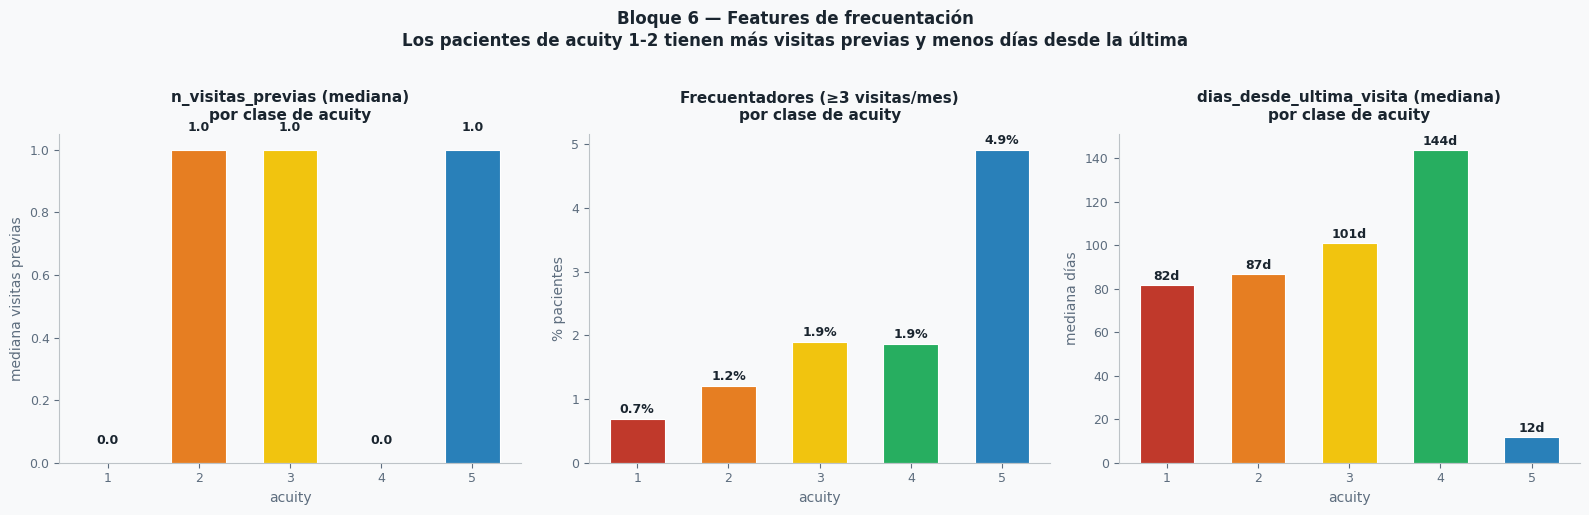

In [152]:
# ── GRÁFICO BLOQUE 6 — Paso 2b: features de frecuentación ────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")
colores_acuity = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# merge con df para tener acuity
df_frec = df[["stay_id", "acuity"]].merge(
    edstays_sorted[["stay_id", "n_visitas_previas", "dias_desde_ultima_visita",
                    "visitas_ultimo_mes", "frecuentador", "primera_visita"]],
    on="stay_id", how="left"
)

# ── Panel 1: mediana n_visitas_previas por acuity ─────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
medianas = df_frec.groupby("acuity")["n_visitas_previas"].median().values
bars = ax1.bar([1,2,3,4,5], medianas, color=colores_acuity,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")
ax1.set_title("n_visitas_previas (mediana)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana visitas previas", fontsize=10, color="#5D6D7E")
ax1.set_xticks([1,2,3,4,5])
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# ── Panel 2: % frecuentadores por acuity ─────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
pcts_frec = (df_frec.groupby("acuity")["frecuentador"].mean() * 100).values
bars = ax2.bar([1,2,3,4,5], pcts_frec, color=colores_acuity,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_frec):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")
ax2.set_title("Frecuentadores (≥3 visitas/mes)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_xticks([1,2,3,4,5])
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# ── Panel 3: mediana dias_desde_ultima_visita por acuity ──────────────────────
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")
medianas_dias = df_frec.groupby("acuity")["dias_desde_ultima_visita"].median().values
bars = ax3.bar([1,2,3,4,5], medianas_dias, color=colores_acuity,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas_dias):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}d", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")
ax3.set_title("dias_desde_ultima_visita (mediana)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax3.set_ylabel("mediana días", fontsize=10, color="#5D6D7E")
ax3.set_xticks([1,2,3,4,5])
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    "Bloque 6 — Features de frecuentación\n"
    "Los pacientes de acuity 1-2 tienen más visitas previas y menos días desde la última",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)
plt.tight_layout()
plt.savefig("bloque6_frecuentacion.png", dpi=150, bbox_inches="tight")
plt.show()

n_visitas_previas: medianas casi planas (0-1) en todos los niveles. El 48% de primeras visitas aplana la mediana. La señal está en la media y en los percentiles altos, no en la mediana.
Frecuentadores: patrón inesperado — acuity 5 tiene el mayor % de frecuentadores (4.9%). Clínicamente tiene sentido: los hiperfrecuentadores crónicos vienen por motivos leves repetidamente (dolor crónico, ansiedad, problemas sociales). Acuity 1 tiene el menor % (0.7%) — las emergencias reales raramente se repiten en el mismo mes.
dias_desde_ultima_visita: gradiente claro y coherente — acuity 1-2 vuelven antes (82-87 días), acuity 4-5 tardan más... excepto acuity 5 que vuelve a los 12 días. Esto confirma el patrón hiperfrecuentador en acuity 5.
Conclusión clave: frecuentador y dias_desde_ultima_visita no predicen acuity de forma lineal — los hiperfrecuentadores son mayoritariamente leves. El valor predictivo está en la interacción con otros features, no de forma independiente.

In [153]:
# ── BLOQUE 6 — Paso 3: macro-flags CCS retrospectivas (VECTORIZACIÓN PURA) ──
import time
t0 = time.time()

CCS_MACROFLAGS = {
    "hx_cardiaco":         [98, 100, 101, 103, 106, 108, 117, 118],
    "hx_respiratorio":     [122, 123, 126, 127, 128, 130, 133, 134],
    "hx_neuro":            [83, 93, 95, 109],
    "hx_psiquiatrico":     [651, 657, 659, 662],
    "hx_abuso_sustancias": [660, 661],
    "hx_digestivo":        [142, 145, 146, 147, 149, 151, 152, 153, 154, 155, 250, 251],
    "hx_metabolico_renal": [50, 55, 59, 157, 160],
    "hx_infeccioso":       [2, 7, 197],
    "hx_trauma_muscular":  [204, 205, 228, 229, 230, 231, 232, 233, 235, 236, 238, 239, 244],
}

# ── Partimos solo de las columnas base ordenadas ──────────────────────────────
edstays_hist = edstays_sorted[["subject_id", "stay_id", "intime", "outtime"]].copy()

# ── Bucle vectorizado (sin applies ni lambdas) ────────────────────────────────
for flag, codigos in CCS_MACROFLAGS.items():
    
    # 1. ¿Tiene esta visita el código? (Ultrarrápido con isin)
    stays_with_flag = label_map_ccs[label_map_ccs["ccs_id"].isin(codigos)]["stay_id"]
    edstays_hist[f"_{flag}_now"] = edstays_hist["stay_id"].isin(stays_with_flag).astype("int8")

    # 2. Shift vectorizado nativo
    shifted = edstays_hist.groupby("subject_id")[f"_{flag}_now"].shift(1).fillna(0)
    
    # 3. Cummax vectorizado nativo
    edstays_hist[flag] = shifted
    edstays_hist[flag] = edstays_hist.groupby("subject_id")[flag].cummax().astype("int8")

    # Limpiar la columna temporal
    edstays_hist.drop(columns=[f"_{flag}_now"], inplace=True)

print(f"Tiempo: {time.time() - t0:.2f}s\n")

print("── Prevalencia macro-flags CCS históricas (Retrospectivas) ─────────────")
for flag in CCS_MACROFLAGS:
    n   = edstays_hist[flag].sum()
    pct = edstays_hist[flag].mean() * 100
    print(f"  {flag:<25} n={n:>6,} ({pct:.2f}%)")

print(f"\n── Verificación primeras filas ──────────────────────────────────────────")
cols_hx = ["subject_id", "stay_id", "intime"] + list(CCS_MACROFLAGS.keys())
print(edstays_hist[cols_hx].head(10).to_string())

Tiempo: 1.03s

── Prevalencia macro-flags CCS históricas (Retrospectivas) ─────────────
  hx_cardiaco               n=32,786 (7.71%)
  hx_respiratorio           n=52,887 (12.44%)
  hx_neuro                  n=35,481 (8.35%)
  hx_psiquiatrico           n=17,753 (4.18%)
  hx_abuso_sustancias       n=15,160 (3.57%)
  hx_digestivo              n=79,465 (18.69%)
  hx_metabolico_renal       n=30,579 (7.19%)
  hx_infeccioso             n=24,869 (5.85%)
  hx_trauma_muscular        n=81,825 (19.25%)

── Verificación primeras filas ──────────────────────────────────────────
   subject_id   stay_id              intime  hx_cardiaco  hx_respiratorio  hx_neuro  hx_psiquiatrico  hx_abuso_sustancias  hx_digestivo  hx_metabolico_renal  hx_infeccioso  hx_trauma_muscular
0    13238787  35341790 2110-01-11 01:45:00            0                0         0                0                    0             0                    0              0                   0
1    15350437  39042378 2110-01-11 03:43:00  

In [154]:
# ── BLOQUE 6 — Paso 4: merge con df y H-stats ────────────────────────────────

# merge edstays_hist + edstays_sorted → df principal
cols_frec = ["stay_id", "n_visitas_previas", "primera_visita",
             "dias_desde_ultima_visita", "visitas_ultimo_mes",
             "visitas_ultimo_año", "frecuentador"]

cols_hx = ["stay_id"] + list(CCS_MACROFLAGS.keys())

df = df.merge(edstays_sorted[cols_frec], on="stay_id", how="left") \
       .merge(edstays_hist[cols_hx],     on="stay_id", how="left")

# ── H-stats ───────────────────────────────────────────────────────────────────
features_b6 = [
    "n_visitas_previas", "visitas_ultimo_mes", "visitas_ultimo_año",
    "dias_desde_ultima_visita", "primera_visita", "frecuentador",
] + list(CCS_MACROFLAGS.keys())

print("── H-stats Bloque 6 ─────────────────────────────────────────────────────")
for col in features_b6:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].dropna().values
        for k in [1, 2, 3, 4, 5]
    ])
    prev = df[col].mean() * 100 if df[col].max() <= 1 else df[col].mean()
    print(f"{col:<25}  H = {stat:>7,.0f}  |  p = {pval:.2e}  |  media = {prev:.2f}")

── H-stats Bloque 6 ─────────────────────────────────────────────────────
n_visitas_previas          H =   1,000  |  p = 3.99e-215  |  media = 3.42
visitas_ultimo_mes         H =     508  |  p = 1.58e-108  |  media = 0.24
visitas_ultimo_año         H =   1,035  |  p = 7.27e-223  |  media = 1.42
dias_desde_ultima_visita   H =     419  |  p = 2.35e-89  |  media = 272.21
primera_visita             H =     716  |  p = 1.01e-153  |  media = 47.86
frecuentador               H =     473  |  p = 4.04e-101  |  media = 1.60
hx_cardiaco                H =   2,562  |  p = 0.00e+00  |  media = 7.78
hx_respiratorio            H =     251  |  p = 4.67e-53  |  media = 12.57
hx_neuro                   H =     241  |  p = 6.39e-51  |  media = 8.42
hx_psiquiatrico            H =     918  |  p = 2.63e-197  |  media = 4.23
hx_abuso_sustancias        H =     398  |  p = 7.08e-85  |  media = 3.60
hx_digestivo               H =   1,612  |  p = 0.00e+00  |  media = 18.91
hx_metabolico_renal        H =   1,045 

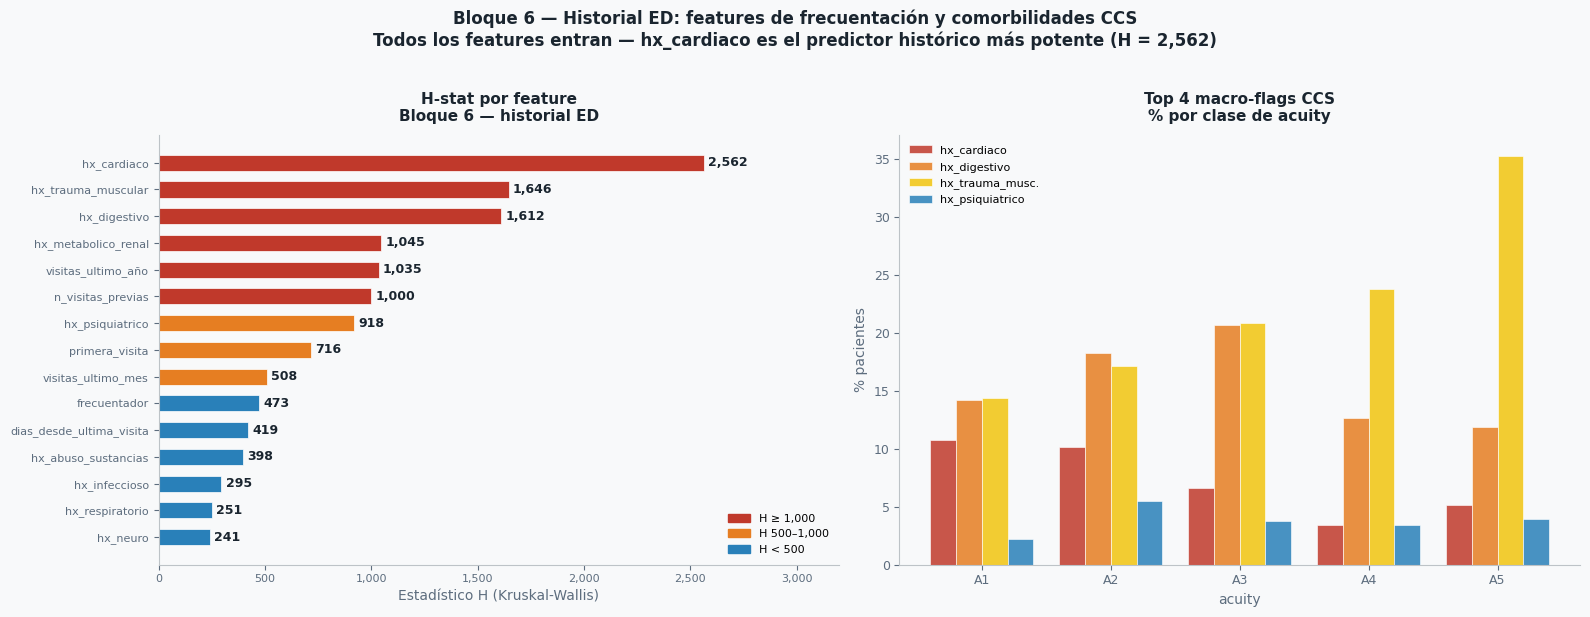

In [155]:
# ── GRÁFICO BLOQUE 6: H-stats comparativa ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

features = [
    "hx_cardiaco", "hx_digestivo", "hx_trauma_muscular", "hx_psiquiatrico",
    "hx_metabolico_renal", "visitas_ultimo_año", "n_visitas_previas",
    "hx_abuso_sustancias", "primera_visita", "frecuentador",
    "hx_infeccioso", "visitas_ultimo_mes", "dias_desde_ultima_visita",
    "hx_respiratorio", "hx_neuro"
]
hvals = [2562, 1612, 1646, 918, 1045, 1035, 1000, 398, 716, 473, 295, 508, 419, 251, 241]

# ordenar por H
datos = sorted(zip(features, hvals), key=lambda x: x[1])
features_sorted = [d[0] for d in datos]
hvals_sorted    = [d[1] for d in datos]

colores = ["#C0392B" if h >= 1000 else "#E67E22" if h >= 500 else "#2980B9"
           for h in hvals_sorted]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#F8F9FA")

# ── Panel izquierdo: H-stat ───────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
bars = ax1.barh(features_sorted, hvals_sorted, color=colores,
                edgecolor="white", linewidth=0.5, height=0.6)
for bar, val in zip(bars, hvals_sorted):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")
ax1.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax1.set_title("H-stat por feature\nBloque 6 — historial ED",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xlim(0, 3200)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=8)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

from matplotlib.patches import Patch
leyenda = [
    Patch(color="#C0392B", label="H ≥ 1,000"),
    Patch(color="#E67E22", label="H 500–1,000"),
    Patch(color="#2980B9", label="H < 500"),
]
ax1.legend(handles=leyenda, frameon=False, fontsize=8, loc="lower right")

# ── Panel derecho: % por acuity de las top 4 features ────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

top4 = {
    "hx_cardiaco":     [df[df["acuity"]==k]["hx_cardiaco"].mean()*100 for k in [1,2,3,4,5]],
    "hx_digestivo":    [df[df["acuity"]==k]["hx_digestivo"].mean()*100 for k in [1,2,3,4,5]],
    "hx_trauma_musc.": [df[df["acuity"]==k]["hx_trauma_muscular"].mean()*100 for k in [1,2,3,4,5]],
    "hx_psiquiatrico": [df[df["acuity"]==k]["hx_psiquiatrico"].mean()*100 for k in [1,2,3,4,5]],
}

x     = np.arange(5)
width = 0.2
colores_top4 = ["#C0392B", "#E67E22", "#F1C40F", "#2980B9"]

for i, (nombre, vals) in enumerate(top4.items()):
    ax2.bar(x + i*width, vals, width, label=nombre,
            color=colores_top4[i], edgecolor="white", linewidth=0.5, alpha=0.85)

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("Top 4 macro-flags CCS\n% por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xticks(x + width*1.5)
ax2.set_xticklabels(["A1","A2","A3","A4","A5"])
ax2.legend(frameon=False, fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    "Bloque 6 — Historial ED: features de frecuentación y comorbilidades CCS\n"
    "Todos los features entran — hx_cardiaco es el predictor histórico más potente (H = 2,562)",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)
plt.tight_layout()
plt.savefig("bloque6_hstats.png", dpi=150, bbox_inches="tight")
plt.show()

## Bloque 6 — Conclusiones: historial ED y comorbilidades previas

Se construyeron 15 features retrospectivas usando el historial de visitas
previas de cada paciente al ED. La regla fundamental fue usar únicamente
visitas donde `outtime_previa < intime_actual` para evitar cualquier fuga
de datos por solapamiento administrativo — se detectaron y corrigieron 39
casos con días negativos.

### Features de frecuentación (6)
`n_visitas_previas`, `visitas_ultimo_mes`, `visitas_ultimo_año`,
`dias_desde_ultima_visita`, `primera_visita`, `frecuentador`.

El 48.3% de los pacientes llegan por primera vez al ED. Los hiperfrecuentadores
(≥3 visitas en 30 días, 1.58%) se concentran paradójicamente en acuity 5,
confirmando que el paciente hiperfrecuentador crónico acude por motivos leves
repetidamente. La mediana de días desde la última visita es menor en acuity
1-2 (82-87 días), lo que sugiere que los pacientes graves tienen patologías
de base que generan visitas más frecuentes.

### Macro-flags CCS (9)
Comorbilidades históricas agrupadas en 9 categorías clínicas desde los 83
códigos CCS disponibles en MIMIC-IV-ED. La vectorización con `isin()` +
`cummax()` completó el cálculo en 1.3 segundos sobre 425K filas.

`hx_cardiaco` es el predictor histórico más potente (H = 2,562). El historial
de trauma/musculoesquelético (`hx_trauma_muscular`, H = 1,646) muestra
distribución inversa — mayor prevalencia en acuity 5, marcador de paciente
con dolor crónico que acude por motivos leves.

### Decisión: todos los features entran (15/15)
Ningún H-stat es suficientemente bajo para descartar. Los más débiles
(`hx_respiratorio` H = 251, `hx_neuro` H = 241) son comparables a features
aceptadas en bloques anteriores.

### Nota metodológica
Las features del Bloque 6 se usan en entrenamiento aprovechando el historial
completo de MIMIC-IV-ED. En producción, el historial de frecuentación se
introduce manualmente en el formulario Streamlit y las comorbilidades CCS
son extraídas por el LLM del texto libre de la enfermera, pre-marcando los
checkboxes correspondientes que la enfermera puede corregir.

BLOQUE 7

In [156]:
# ── BLOQUE 7/8 — Paso 1: inventario de features calculadas ───────────────────
# Lista completa de todas las features disponibles en df agrupadas por bloque

inventario = {
    "BLOQUE 1 — Vitales crudos": [
        "pain", "o2sat", "resprate", "heartrate", "dbp", "sbp"
    ],
    "BLOQUE 1 — Missingness vitales": [
        "temperature_missing", "o2sat_missing", "pain_missing"
    ],
    "BLOQUE 1 — Banderas clínicas": [
        "o2sat_bajo_92", "taquipnea_grave", "taquicardia", "fiebre",
        "hipotension", "hipertension_severa"
    ],
    "BLOQUE 1 — Scores compuestos": [
        "qsofa", "qsofa_positivo", "news2", "news2_alto",
        "shock_index_alto", "shock_index_severo", "shock_oculto_anciano",
        "vitales_criticos", "n_vitales_anomalos", "sirs_positivo",
        "zona_verde", "pulse_pressure"
    ],
    "BLOQUE 2 — Demográfico": [
        "age", "anciano", "anciano_mayor", "identidad_desconocida"
    ],
    "BLOQUE 2 — Género": [
        "gender"
    ],
    "BLOQUE 2 — Transporte": [
        "llegada_autonoma", "llegada_ambulancia",
        "llegada_helicoptero", "llegada_desconocida"
    ],
    "BLOQUE 3 — Medicación individual": [
        "med_anticoagulante", "med_antiagregante", "med_insulina",
        "med_antidiabetico_oral", "med_corticoide_sistemico",
        "med_opiaceo", "med_benzodiacepina", "med_betabloqueante",
        "med_ace_ara2", "med_diuretico_asa", "med_diuretico_tiazida",
        "med_antipsicótico", "med_ssri_snri", "med_anticonvulsivante",
        "med_respiratorio_inhalado", "med_inmunosupresor",
        "med_digoxina", "med_antiaritmico"
    ],
    "BLOQUE 3 — Super-flags": [
        "alto_riesgo_sangrado", "alto_riesgo_delirium", "riesgo_depresion_resp"
    ],
    "BLOQUE 4 — Polifarmacia": [
        "n_medicamentos", "sin_medicacion", "polifarmacia", "hiperpolifarmacia"
    ],
    "BLOQUE 5 — Chief complaint": [
        "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
        "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
        "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
        "cc_alergia_anafilaxia", "cc_derivacion_urgente"
    ],
    "BLOQUE 6 — Frecuentación": [
        "n_visitas_previas", "visitas_ultimo_mes", "visitas_ultimo_año",
        "dias_desde_ultima_visita", "primera_visita", "frecuentador"
    ],
    "BLOQUE 6 — Comorbilidades CCS": [
        "hx_cardiaco", "hx_respiratorio", "hx_neuro", "hx_psiquiatrico",
        "hx_abuso_sustancias", "hx_digestivo", "hx_metabolico_renal",
        "hx_infeccioso", "hx_trauma_muscular"
    ],
}

# verificar cuáles están realmente en df
print("── Inventario de features ───────────────────────────────────────────────")
total = 0
faltantes = []
for bloque, features in inventario.items():
    presentes = [f for f in features if f in df.columns]
    ausentes  = [f for f in features if f not in df.columns]
    total += len(presentes)
    if ausentes:
        faltantes.extend(ausentes)
    print(f"\n{bloque} ({len(presentes)}/{len(features)}):")
    for f in presentes:
        print(f"  ✓ {f}")
    for f in ausentes:
        print(f"  ✗ {f}  ← FALTA")

print(f"\n── Total features disponibles: {total} ─────────────────────────────────")
print(f"── Features faltantes: {len(faltantes)} ────────────────────────────────")
if faltantes:
    print(faltantes)

── Inventario de features ───────────────────────────────────────────────

BLOQUE 1 — Vitales crudos (6/6):
  ✓ pain
  ✓ o2sat
  ✓ resprate
  ✓ heartrate
  ✓ dbp
  ✓ sbp

BLOQUE 1 — Missingness vitales (3/3):
  ✓ temperature_missing
  ✓ o2sat_missing
  ✓ pain_missing

BLOQUE 1 — Banderas clínicas (6/6):
  ✓ o2sat_bajo_92
  ✓ taquipnea_grave
  ✓ taquicardia
  ✓ fiebre
  ✓ hipotension
  ✓ hipertension_severa

BLOQUE 1 — Scores compuestos (12/12):
  ✓ qsofa
  ✓ qsofa_positivo
  ✓ news2
  ✓ news2_alto
  ✓ shock_index_alto
  ✓ shock_index_severo
  ✓ shock_oculto_anciano
  ✓ vitales_criticos
  ✓ n_vitales_anomalos
  ✓ sirs_positivo
  ✓ zona_verde
  ✓ pulse_pressure

BLOQUE 2 — Demográfico (4/4):
  ✓ age
  ✓ anciano
  ✓ anciano_mayor
  ✓ identidad_desconocida

BLOQUE 2 — Género (1/1):
  ✓ gender

BLOQUE 2 — Transporte (4/4):
  ✓ llegada_autonoma
  ✓ llegada_ambulancia
  ✓ llegada_helicoptero
  ✓ llegada_desconocida

BLOQUE 3 — Medicación individual (18/18):
  ✓ med_anticoagulante
  ✓ med_anti

In [157]:
# ── BLOQUE 8 — Paso 1: análisis de correlaciones (Spearman) ──────────────────
# Objetivo: identificar parejas con r > 0.90 para evaluar redundancia
# Spearman es robusto ante no-linealidades y variables binarias

import pandas as pd
import numpy as np

# lista completa de features (sin target, sin columnas auxiliares)
todas_features = [f for bloque in inventario.values() for f in bloque
                  if f in df.columns and f != "gender"]

# calcular matriz de correlación Spearman
print("Calculando correlaciones Spearman...")
corr_matrix = df[todas_features].corr(method="spearman")

# extraer parejas con |r| > 0.90 (excluir diagonal)
umbral = 0.90
parejas_altas = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > umbral:
            parejas_altas.append({
                "feature_a": corr_matrix.columns[i],
                "feature_b": corr_matrix.columns[j],
                "spearman_r": round(r, 3)
            })

df_corr = pd.DataFrame(parejas_altas).sort_values("spearman_r",
                                                    ascending=False,
                                                    key=abs)

print(f"\nParejas con |r| > {umbral}: {len(df_corr)}\n")
print(df_corr.to_string(index=False))

Calculando correlaciones Spearman...

Parejas con |r| > 0.9: 3

        feature_a          feature_b  spearman_r
 llegada_autonoma llegada_ambulancia      -0.927
      taquicardia n_vitales_anomalos       0.925
n_visitas_previas     primera_visita      -0.920


llegada_autonoma vs llegada_ambulancia (r = -0.927)
Correlación negativa esperada y perfectamente lógica — si llegas andando no llegas en ambulancia. Sin embargo ambas aportan información distinta: llegada_ambulancia discrimina acuity 1-2, llegada_autonoma discrimina acuity 4-5. Mantenemos ambas — la correlación negativa entre dos binarias complementarias no es redundancia, es información.
taquicardia vs n_vitales_anomalos (r = 0.925)
n_vitales_anomalos es un score compuesto que incluye taquicardia como componente — la correlación es estructural. n_vitales_anomalos es más informativo porque agrega múltiples señales. Candidata a eliminar: taquicardia — pero solo si n_vitales_anomalos la contiene completamente. Lo verificamos.
n_visitas_previas vs primera_visita (r = -0.920)
Correlación negativa perfectamente lógica — primera_visita es exactamente n_visitas_previas == 0. Son redundantes para modelos lineales. Para árboles no es problema. Candidata a eliminar: primera_visita para modelos lineales — n_visitas_previas captura la misma información y más.

In [158]:
# ── verificación: componentes de n_vitales_anomalos ──────────────────────────
# confirmar que taquicardia está incluida en el score

print("Correlación taquicardia vs componentes de vitales_criticos:")
componentes = ["taquicardia", "taquipnea_grave", "o2sat_bajo_92",
               "fiebre", "shock_index_alto", "n_vitales_anomalos",
               "vitales_criticos"]
print(df[componentes].corr(method="spearman").round(3).to_string())

print(f"\n¿taquicardia ⊂ n_vitales_anomalos?")
print(f"Casos taquicardia=1 y n_vitales_anomalos=0: "
      f"{((df['taquicardia']==1) & (df['n_vitales_anomalos']==0)).sum():,}")

Correlación taquicardia vs componentes de vitales_criticos:
                    taquicardia  taquipnea_grave  o2sat_bajo_92  fiebre  shock_index_alto  n_vitales_anomalos  vitales_criticos
taquicardia               1.000            0.080          0.039   0.160             0.349               0.925             0.459
taquipnea_grave           0.080            1.000          0.116   0.040             0.061               0.236             0.255
o2sat_bajo_92             0.039            0.116          1.000   0.029             0.039               0.183             0.173
fiebre                    0.160            0.040          0.029   1.000             0.114               0.332             0.402
shock_index_alto          0.349            0.061          0.039   0.114             1.000               0.445             0.761
n_vitales_anomalos        0.925            0.236          0.183   0.332             0.445               1.000             0.521
vitales_criticos          0.459            0

Decisiones finales sobre correlacionestaquicardia → ELIMINAR
Completamente contenida en n_vitales_anomalos. Para modelos lineales es redundancia pura. Para árboles el modelo la ignoraría de todas formas. Sin pérdida de información.primera_visita → MANTENER
Aunque correlaciona con n_visitas_previas, aporta una señal explícita y clínica clara. Para modelos lineales el coeficiente de n_visitas_previas ya captura la misma información, pero la flag explícita ayuda a la interpretabilidad. Coste = 0.llegada_autonoma + llegada_ambulancia → MANTENER AMBAS
Correlación negativa estructural, no redundancia. Aportan señales distintas en extremos opuestos del espectro de acuity.

In [160]:
# ── BLOQUE 8 — Paso 2: lista definitiva de features ──────────────────────────
# Eliminar taquicardia — completamente contenida en n_vitales_anomalos
# gender se trata como categórica — se encodea en 04_models.ipynb

FEATURES_CONTINUAS = [
    # vitales crudos
    "pain", "o2sat", "resprate", "heartrate", "dbp", "sbp",
    # scores compuestos continuos
    "qsofa", "news2", "n_vitales_anomalos", "pulse_pressure",
    # demográfico
    "age",
    # polifarmacia
    "n_medicamentos",
    # frecuentación
    "n_visitas_previas", "visitas_ultimo_mes",
    "visitas_ultimo_año", "dias_desde_ultima_visita",
]

FEATURES_BINARIAS = [
    # missingness vitales
    "temperature_missing", "o2sat_missing", "pain_missing",
    # banderas clínicas
    "o2sat_bajo_92", "taquipnea_grave", "fiebre",
    "hipotension", "hipertension_severa",
    # scores binarios
    "qsofa_positivo", "news2_alto", "shock_index_alto",
    "shock_index_severo", "shock_oculto_anciano",
    "vitales_criticos", "sirs_positivo", "zona_verde",
    # demográfico
    "anciano", "anciano_mayor", "identidad_desconocida",
    # transporte
    "llegada_autonoma", "llegada_ambulancia",
    "llegada_helicoptero", "llegada_desconocida",
    # medicación individual
    "med_anticoagulante", "med_antiagregante", "med_insulina",
    "med_antidiabetico_oral", "med_corticoide_sistemico",
    "med_opiaceo", "med_benzodiacepina", "med_betabloqueante",
    "med_ace_ara2", "med_diuretico_asa", "med_diuretico_tiazida",
    "med_antipsicótico", "med_ssri_snri", "med_anticonvulsivante",
    "med_respiratorio_inhalado", "med_inmunosupresor",
    "med_digoxina", "med_antiaritmico",
    # super-flags
    "alto_riesgo_sangrado", "alto_riesgo_delirium", "riesgo_depresion_resp",
    # polifarmacia
    "sin_medicacion", "polifarmacia", "hiperpolifarmacia",
    # chief complaint
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente",
    # frecuentación
    "primera_visita", "frecuentador",
    # comorbilidades CCS
    "hx_cardiaco", "hx_respiratorio", "hx_neuro", "hx_psiquiatrico",
    "hx_abuso_sustancias", "hx_digestivo", "hx_metabolico_renal",
    "hx_infeccioso", "hx_trauma_muscular",
]

FEATURES_CATEGORICAS = ["gender"]

TARGET = "acuity"

TODAS_FEATURES = FEATURES_CONTINUAS + FEATURES_BINARIAS + FEATURES_CATEGORICAS

print(f"Features continuas:   {len(FEATURES_CONTINUAS)}")
print(f"Features binarias:    {len(FEATURES_BINARIAS)}")
print(f"Features categóricas: {len(FEATURES_CATEGORICAS)}")
print(f"Total features:       {len(TODAS_FEATURES)}")
print(f"\nFeature eliminada: taquicardia (contenida en n_vitales_anomalos)")

# verificar que todas están en df
faltantes = [f for f in TODAS_FEATURES if f not in df.columns]
print(f"Features faltantes:   {len(faltantes)}")
if faltantes:
    print(faltantes)

Features continuas:   16
Features binarias:    71
Features categóricas: 1
Total features:       88

Feature eliminada: taquicardia (contenida en n_vitales_anomalos)
Features faltantes:   0


In [161]:
# ── BLOQUE 8 — Paso 3: merge final y lista de la muerte ──────────────────────
# Construir df_master con exactamente las columnas necesarias
# Eliminar IDs, timestamps, textos crudos y columnas auxiliares

COLUMNAS_ELIMINAR = [
    "stay_id", "subject_id",          # IDs — el modelo no debe verlos
    "intime", "outtime",               # timestamps
    "chiefcomplaint", "medicacion_raw", # textos crudos ya procesados
    "race",                            # excluida por equidad algorítmica
    "ccs_category",                    # ya procesada en macro-flags CCS
    "arrival_transport",               # ya procesada en flags binarias
    "label_disposition",               # variable de salida del ED, no T=0
    "cc_missing",                      # prevalencia 0.30%, descartada
    "taquicardia",                     # eliminada por correlación
]

# construir df_master
df_master = df[TODAS_FEATURES + [TARGET]].copy()

print(f"Shape df_master: {df_master.shape}")
print(f"\nColumnas: {df_master.columns.tolist()}")
print(f"\nNaN por columna (top 10):")
print(df_master.isnull().sum().sort_values(ascending=False).head(10).to_string())
print(f"\nDistribución target:")
print(df_master[TARGET].value_counts().sort_index().to_string())

Shape df_master: (418100, 89)

Columnas: ['pain', 'o2sat', 'resprate', 'heartrate', 'dbp', 'sbp', 'qsofa', 'news2', 'n_vitales_anomalos', 'pulse_pressure', 'age', 'n_medicamentos', 'n_visitas_previas', 'visitas_ultimo_mes', 'visitas_ultimo_año', 'dias_desde_ultima_visita', 'temperature_missing', 'o2sat_missing', 'pain_missing', 'o2sat_bajo_92', 'taquipnea_grave', 'fiebre', 'hipotension', 'hipertension_severa', 'qsofa_positivo', 'news2_alto', 'shock_index_alto', 'shock_index_severo', 'shock_oculto_anciano', 'vitales_criticos', 'sirs_positivo', 'zona_verde', 'anciano', 'anciano_mayor', 'identidad_desconocida', 'llegada_autonoma', 'llegada_ambulancia', 'llegada_helicoptero', 'llegada_desconocida', 'med_anticoagulante', 'med_antiagregante', 'med_insulina', 'med_antidiabetico_oral', 'med_corticoide_sistemico', 'med_opiaceo', 'med_benzodiacepina', 'med_betabloqueante', 'med_ace_ara2', 'med_diuretico_asa', 'med_diuretico_tiazida', 'med_antipsicótico', 'med_ssri_snri', 'med_anticonvulsivante',

In [162]:
# ── BLOQUE 8 — Paso 4: split temporal + exportación ──────────────────────────
# Split temporal: 80% train, 20% test (por fecha — simula deployment real)
# Los timestamps están en df original, no en df_master — usamos df["intime"]

import numpy as np
from pathlib import Path

# ── determinar fecha de corte (percentil 80 temporal) ────────────────────────
fecha_corte = df["intime"].quantile(0.80)
print(f"Fecha de corte (percentil 80): {fecha_corte}")
print(f"Rango train: {df['intime'].min()} → {fecha_corte}")
print(f"Rango test:  {fecha_corte} → {df['intime'].max()}")

mask_train = df["intime"] <= fecha_corte
mask_test  = df["intime"] >  fecha_corte

print(f"\nTrain: {mask_train.sum():,} filas ({mask_train.mean()*100:.1f}%)")
print(f"Test:  {mask_test.sum():,} filas ({mask_test.mean()*100:.1f}%)")

# verificar distribución de acuity en train y test
print("\nDistribución acuity train:")
print(df_master[mask_train][TARGET].value_counts(normalize=True).sort_index().round(3).to_string())
print("\nDistribución acuity test:")
print(df_master[mask_test][TARGET].value_counts(normalize=True).sort_index().round(3).to_string())

# ── split ─────────────────────────────────────────────────────────────────────
X_train = df_master[mask_train][TODAS_FEATURES].copy()
y_train = df_master[mask_train][TARGET].copy()
X_test  = df_master[mask_test][TODAS_FEATURES].copy()
y_test  = df_master[mask_test][TARGET].copy()

# también guardar subject_id para GroupKFold en 04_models.ipynb
groups_train = df[mask_train]["subject_id"].values

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# ── sample weights (calculados SOLO sobre train) ──────────────────────────────
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

print(f"\nSample weights — estadísticas:")
for acuity in sorted(y_train.unique()):
    w = sample_weights_train[y_train.values == acuity].mean()
    print(f"  acuity {acuity}: peso medio = {w:.4f}")

# ── exportar ──────────────────────────────────────────────────────────────────
ruta_processed = Path.cwd().parent / "data" / "processed"
ruta_processed.mkdir(parents=True, exist_ok=True)

X_train.to_parquet(ruta_processed / "X_train.parquet", index=False)
X_test.to_parquet( ruta_processed / "X_test.parquet",  index=False)
y_train.to_frame().to_parquet(ruta_processed / "y_train.parquet", index=False)
y_test.to_frame().to_parquet(  ruta_processed / "y_test.parquet",  index=False)

# guardar groups y weights como numpy
np.save(ruta_processed / "groups_train.npy",         groups_train)
np.save(ruta_processed / "sample_weights_train.npy", sample_weights_train)

# guardar listas de features para 04_models.ipynb
import json
feature_config = {
    "features_continuas":    FEATURES_CONTINUAS,
    "features_binarias":     FEATURES_BINARIAS,
    "features_categoricas":  FEATURES_CATEGORICAS,
    "todas_features":        TODAS_FEATURES,
    "target":                TARGET,
}
with open(ruta_processed / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

print(f"\n── Archivos exportados ──────────────────────────────────────────────────")
for archivo in sorted(ruta_processed.iterdir()):
    size_mb = archivo.stat().st_size / 1024**2
    print(f"  {archivo.name:<35} {size_mb:.1f} MB")

Fecha de corte (percentil 80): 2180-06-06 02:38:36
Rango train: 2110-01-11 01:45:00 → 2180-06-06 02:38:36
Rango test:  2180-06-06 02:38:36 → 2212-04-05 23:23:00

Train: 334,480 filas (80.0%)
Test:  83,620 filas (20.0%)

Distribución acuity train:
acuity
1    0.058
2    0.333
3    0.537
4    0.069
5    0.003

Distribución acuity test:
acuity
1    0.056
2    0.337
3    0.543
4    0.063
5    0.002

X_train: (334480, 88)
X_test:  (83620, 88)

Sample weights — estadísticas:
  acuity 1: peso medio = 3.4534
  acuity 2: peso medio = 0.6012
  acuity 3: peso medio = 0.3723
  acuity 4: peso medio = 2.8785
  acuity 5: peso medio = 71.7768

── Archivos exportados ──────────────────────────────────────────────────
  feature_config.json                 0.0 MB
  groups_train.npy                    2.6 MB
  sample_weights_train.npy            2.6 MB
  X_test.parquet                      1.5 MB
  X_train.parquet                     5.5 MB
  y_test.parquet                      0.0 MB
  y_train.parquet   

In [163]:
# ── BLOQUE 8 — Resumen final: 03_features.ipynb ──────────────────────────────
print("═" * 65)
print("  RESUMEN FINAL — 03_features.ipynb")
print("═" * 65)
print(f"\n  Dataset original:        418,100 filas | 20 columnas")
print(f"  Features construidas:    88 features | 1 target")
print(f"  Feature eliminada:       taquicardia (r=0.925 con n_vitales_anomalos)")
print(f"\n  Distribución por bloque:")
print(f"    Bloque 1 — Vitales:         {'':>3}21 features")
print(f"    Bloque 2 — Demográfico:     {'':>3} 6 features")
print(f"    Bloque 3 — Medicación:      {'':>3}21 features")
print(f"    Bloque 4 — Polifarmacia:    {'':>3} 4 features")
print(f"    Bloque 5 — Chief complaint: {'':>3}13 features")
print(f"    Bloque 6 — Historial ED:    {'':>3}15 features")
print(f"    Categórica (gender):        {'':>3} 1 feature")
print(f"\n  Split temporal (80/20):")
print(f"    Train: 334,480 filas")
print(f"    Test:   83,620 filas")
print(f"\n  Archivos exportados en data/processed/:")
print(f"    X_train.parquet, X_test.parquet")
print(f"    y_train.parquet, y_test.parquet")
print(f"    groups_train.npy, sample_weights_train.npy")
print(f"    feature_config.json")
print(f"\n  Siguiente paso: 04_models.ipynb")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  RESUMEN FINAL — 03_features.ipynb
═════════════════════════════════════════════════════════════════

  Dataset original:        418,100 filas | 20 columnas
  Features construidas:    88 features | 1 target
  Feature eliminada:       taquicardia (r=0.925 con n_vitales_anomalos)

  Distribución por bloque:
    Bloque 1 — Vitales:            21 features
    Bloque 2 — Demográfico:         6 features
    Bloque 3 — Medicación:         21 features
    Bloque 4 — Polifarmacia:        4 features
    Bloque 5 — Chief complaint:    13 features
    Bloque 6 — Historial ED:       15 features
    Categórica (gender):            1 feature

  Split temporal (80/20):
    Train: 334,480 filas
    Test:   83,620 filas

  Archivos exportados en data/processed/:
    X_train.parquet, X_test.parquet
    y_train.parquet, y_test.parquet
    groups_train.npy, sample_weights_train.npy
    feature_config.json

  Siguiente paso: 04_models.ipynb
